In [1]:
import google.protobuf
import tensorflow as tf

print("Protobuf version:", google.protobuf.__version__)
print("TensorFlow version:", tf.__version__)

I0000 00:00:1790757539.877520  506745 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790757539.878544  506745 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790757539.922832  506745 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790757541.074200  506745 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Protobuf version: 6.32.0
TensorFlow version: 2.21.0


In [2]:
# import necessary packages
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt
import numpy as np
import glob
from PIL import Image
import ipywidgets as widgets
from IPython.display import display
import matplotlib.image as mpimg
from sklearn.utils import shuffle
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint

In [3]:
filepath = './Early_NSD_Dataset'
filelist = sorted(glob.glob(filepath+'/**/*.JPG', recursive=True)) 
print(len(filelist))
print(filelist[0])

2700
./Early_NSD_Dataset/test/ashgourd_fresh/RGB (105).JPG


In [4]:
# A funciton to normalize images
def Normalize(img):
  return (img - np.min(img))/(np.max(img)-np.min(img)) if np.max(img) != np.min(img) else img


In [5]:
import os
import matplotlib.pyplot as plt
from collections import Counter

print("Dataset path:", filepath)
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

# Total image counter
total_images = 0

# List files and folders
for root, dirs, files in os.walk(filepath):

    # Count images in this folder
    image_files = [
        file for file in files
        if file.lower().endswith(image_extensions)
    ]

    total_images += len(image_files)

    print("\nFolder:", root)
    print("Number of files:", len(files))
    print("Number of images:", len(image_files))
    print("Files:", files[:10])

# Final total
print("\n" + "=" * 15)
print("TOTAL IMAGES IN DATASET:", total_images)
print("=" * 15)

Dataset path: ./Early_NSD_Dataset

Folder: ./Early_NSD_Dataset
Number of files: 0
Number of images: 0
Files: []

Folder: ./Early_NSD_Dataset/val
Number of files: 0
Number of images: 0
Files: []

Folder: ./Early_NSD_Dataset/val/snakegourd_nitrogen
Number of files: 45
Number of images: 45
Files: ['RGB (198).JPG', 'RGB (241).JPG', 'RGB (123).JPG', 'RGB (98).JPG', 'RGB (203).JPG', 'RGB (212).JPG', 'RGB (91).JPG', 'RGB (90).JPG', 'RGB (133).JPG', 'RGB (126).JPG']

Folder: ./Early_NSD_Dataset/val/snakegourd_potassium
Number of files: 45
Number of images: 45
Files: ['RGB (198).JPG', 'RGB (241).JPG', 'RGB (123).JPG', 'RGB (98).JPG', 'RGB (203).JPG', 'RGB (212).JPG', 'RGB (91).JPG', 'RGB (90).JPG', 'RGB (133).JPG', 'RGB (126).JPG']

Folder: ./Early_NSD_Dataset/val/bittergourd_potassium
Number of files: 45
Number of images: 45
Files: ['RGB (198).JPG', 'RGB (241).JPG', 'RGB (123).JPG', 'RGB (98).JPG', 'RGB (203).JPG', 'RGB (212).JPG', 'RGB (91).JPG', 'RGB (90).JPG', 'RGB (133).JPG', 'RGB (126).JP

In [6]:
import os
import matplotlib.pyplot as plt

# Dataset location
dataset_path = filepath

# Classes in the dataset
classes = [
    "ashgourd_fresh",
    "ashgourd_nitrogen",
    "ashgourd_potassium",
    "bittergourd_fresh",
    "bittergourd_nitrogen",
    "bittergourd_potassium",
    "snakegourd_fresh",
    "snakegourd_nitrogen",
    "snakegourd_potassium"
]

# Count images in each class
train_count = []
val_count = []
test_count = []

for cls in classes:

    train_folder = os.path.join(dataset_path, "train", cls)
    val_folder = os.path.join(dataset_path, "val", cls)
    test_folder = os.path.join(dataset_path, "test", cls)

    train_images = os.listdir(train_folder)
    val_images = os.listdir(val_folder)
    test_images = os.listdir(test_folder)

    train_count.append(len(train_images))
    val_count.append(len(val_images))
    test_count.append(len(test_images))


# Print the number of images
print("Number of images in each class:\n")

for i in range(len(classes)):

    total = train_count[i] + val_count[i] + test_count[i]

    print(
        classes[i],
        "-> Train:", train_count[i],
        "Val:", val_count[i],
        "Test:", test_count[i],
        "Total:", total
    )

Number of images in each class:

ashgourd_fresh -> Train: 210 Val: 45 Test: 45 Total: 300
ashgourd_nitrogen -> Train: 210 Val: 45 Test: 45 Total: 300
ashgourd_potassium -> Train: 210 Val: 45 Test: 45 Total: 300
bittergourd_fresh -> Train: 210 Val: 45 Test: 45 Total: 300
bittergourd_nitrogen -> Train: 210 Val: 45 Test: 45 Total: 300
bittergourd_potassium -> Train: 210 Val: 45 Test: 45 Total: 300
snakegourd_fresh -> Train: 210 Val: 45 Test: 45 Total: 300
snakegourd_nitrogen -> Train: 210 Val: 45 Test: 45 Total: 300
snakegourd_potassium -> Train: 210 Val: 45 Test: 45 Total: 300


In [7]:
import os
from PIL import Image
from collections import Counter


folders = {
    "TRAIN": "/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Train_256",
    "TEST": "/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Test_resized312",
    "VALIDATION": "/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Val_resized312"
}

# Supported image extensions
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")


# FUNCTION TO CHECK ONE FOLDER
def check_image_folder(folder_path, folder_name):

    print("\n" + "=" * 15)
    print(f"{folder_name} DATASET")
    print("=" * 15)

    if not os.path.exists(folder_path):
        print(" Folder does not exist:")
        print(folder_path)
        return

    image_sizes = Counter()

    total_images = 0
    corrupted_images = []
    non_image_files = []

    # Walk through all subfolders
    for root, dirs, files in os.walk(folder_path):

        for file in files:

            file_path = os.path.join(root, file)

            # Check whether file is an image
            if file.lower().endswith(IMAGE_EXTENSIONS):

                try:
                    with Image.open(file_path) as img:

                        width, height = img.size

                        image_sizes[(width, height)] += 1

                        total_images += 1

                except Exception as e:
                    corrupted_images.append(file_path)

            else:
                non_image_files.append(file_path)


    # RESULTS

    print(f"\n Folder:")
    print(folder_path)

    print(f"\n Total Images: {total_images}")

    print("\n Image Size Distribution:")
    print("-" * 15)

    if image_sizes:

        for size, count in image_sizes.most_common():

            width, height = size

            print(f"({width} , {height})  -->  {count} images")

    else:
        print("No valid images found.")


    # MIN / MAX SIZE
    if image_sizes:

        widths = [size[0] for size in image_sizes]
        heights = [size[1] for size in image_sizes]

        print("\n Dimension Range:")
        print(f"Minimum Width  : {min(widths)}")
        print(f"Maximum Width  : {max(widths)}")
        print(f"Minimum Height : {min(heights)}")
        print(f"Maximum Height : {max(heights)}")


# CHECK ALL THREE DATASETS
for name, path in folders.items():
    check_image_folder(path, name)



TRAIN DATASET

 Folder:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Train_256

 Total Images: 1890

 Image Size Distribution:
---------------
(312 , 312)  -->  1890 images

 Dimension Range:
Minimum Width  : 312
Maximum Width  : 312
Minimum Height : 312
Maximum Height : 312

TEST DATASET

 Folder:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Test_resized312

 Total Images: 405

 Image Size Distribution:
---------------
(312 , 312)  -->  405 images

 Dimension Range:
Minimum Width  : 312
Maximum Width  : 312
Minimum Height : 312
Maximum Height : 312

VALIDATION DATASET

 Folder:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Val_resized312

 Total Images: 405

 Image Size Distribution:
---------------
(312 , 312)  -->  405 images

 Dimension Range:
Minimum Width  : 312
Maximum Width  : 312
Minimum Height : 312
Maximum Height : 312


In [8]:
import os
import cv2
import numpy as np
from PIL import Image
from collections import Counter
from pathlib import Path
from itertools import combinations

# ============================================================
# DATASET PATHS
# ============================================================

DATASET_PATHS = {
    "TRAIN": "/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Train_256",

    "VALIDATION": "/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Val_resized312",

    "TEST": "/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Test_resized312"
}

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
)



# BASIC DATASET CHECK

for dataset_name, dataset_path in DATASET_PATHS.items():

    print("\n" + "=" * 20)
    print(dataset_name)
    print("=" * 20)

    total_images = 0
    class_counts = {}
    image_sizes = Counter()

    for class_name in sorted(os.listdir(dataset_path)):

        class_path = os.path.join( dataset_path, class_name)

        if not os.path.isdir(class_path):
            continue

        count = 0

        for file in os.listdir(class_path):

            if file.lower().endswith( IMAGE_EXTENSIONS):

                file_path = os.path.join( class_path, file)

                try:

                    with Image.open(file_path) as img:

                        image_sizes[img.size] += 1

                    count += 1

                except Exception:
                    pass

        class_counts[class_name] = count

        total_images += count

    print("\nTotal images:", total_images)

    print("\nImages per class:")

    for class_name, count in class_counts.items():

        print(f"{class_name:<35} {count}")

    print("\nImage sizes:")

    for size, count in image_sizes.items():

        print(f"{size[0]} x {size[1]} : {count}")



# EXACT DUPLICATE CHECK

print("=" * 20)
print("EXACT DUPLICATE CHECK")
print("=" * 20)


def calculate_md5(file_path):

    import hashlib

    md5 = hashlib.md5()

    with open(file_path,"rb") as f:

        while True:

            chunk = f.read(8192)

            if not chunk:
                break

            md5.update(chunk)

    return md5.hexdigest()


for dataset_name, dataset_path in DATASET_PATHS.items():

    print("\n" + "-" * 20)

    print(f"{dataset_name} DATASET")

    hashes = {}
    total = 0
    duplicate_count = 0

    for root, dirs, files in os.walk(dataset_path):

        for file in files:

            if not file.lower().endswith(IMAGE_EXTENSIONS):
                continue

            file_path = os.path.join(root,file)

            try:

                file_hash = calculate_md5(file_path)

                total += 1

                if file_hash in hashes:

                    duplicate_count += 1

                    print("\nDUPLICATE:")

                    print(file_path)

                    print("Same as:")

                    print( hashes[file_hash])
            

                else:

                    hashes[file_hash] = file_path

            except Exception:

                pass

    print(f"\nTotal images: {total}")

    print(f"Exact duplicates: {duplicate_count}")


print("\n")
print("=" * 20)
print("PERCEPTUAL SIMILARITY CHECK")
print("=" * 20)


def image_hash(image_path):

    img = cv2.imread( image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        return None

    img = cv2.resize( img, (32, 32))

    return img.astype(np.float32)


def image_similarity( hash1, hash2):

    difference = np.mean(np.abs(hash1 - hash2))

    return difference


for dataset_name, dataset_path in DATASET_PATHS.items():

    print("\n" + "-" * 20)

    print(f"{dataset_name} DATASET")


    # Check class by class
    for class_name in sorted(os.listdir(dataset_path)):

        class_path = os.path.join(dataset_path,class_name)

        if not os.path.isdir(class_path):
            continue

        image_files = [os.path.join(class_path,f)

            for f in os.listdir(class_path)

            if f.lower().endswith(IMAGE_EXTENSIONS)]

        print(f"\nClass: {class_name}")

        print( "Images:", len(image_files))

   
        # Don't perform expensive comparison if very large
        if len(image_files) > 500:

            print( "Skipping pairwise similarity " "because class contains >500 images.")
            continue

        hashes = {}

        for image_file in image_files:

            h = image_hash(image_file)

            if h is not None:

                hashes[image_file] = h

        similar_pairs = []

        files = list(hashes.keys())

        for i in range(len(files)):

            for j in range(i + 1,len(files)):

                similarity = image_similarity( hashes[files[i]], hashes[files[j]])

                # Smaller difference =
                # more visually similar

                if similarity < 5:

                    similar_pairs.append(( files[i], files[j], similarity))

        print( "Highly similar pairs:", len(similar_pairs))

        # Show first 10

        for pair in similar_pairs[:10]:

            print("\nPossible augmented pair:")

            print( "Image 1:", pair[0])

            print( "Image 2:", pair[1])

            print( "Difference:", pair[2])



TRAIN

Total images: 1890

Images per class:
ashgourd_fresh                      210
ashgourd_nitrogen                   210
ashgourd_potassium                  210
bittergourd_fresh                   210
bittergourd_nitrogen                210
bittergourd_potassium               210
snakegourd_fresh                    210
snakegourd_nitrogen                 210
snakegourd_potassium                210

Image sizes:
312 x 312 : 1890

VALIDATION

Total images: 405

Images per class:
ashgourd_fresh                      45
ashgourd_nitrogen                   45
ashgourd_potassium                  45
bittergourd_fresh                   45
bittergourd_nitrogen                45
bittergourd_potassium               45
snakegourd_fresh                    45
snakegourd_nitrogen                 45
snakegourd_potassium                45

Image sizes:
312 x 312 : 405

TEST

Total images: 405

Images per class:
ashgourd_fresh                      45
ashgourd_nitrogen                   45
ashgourd_p

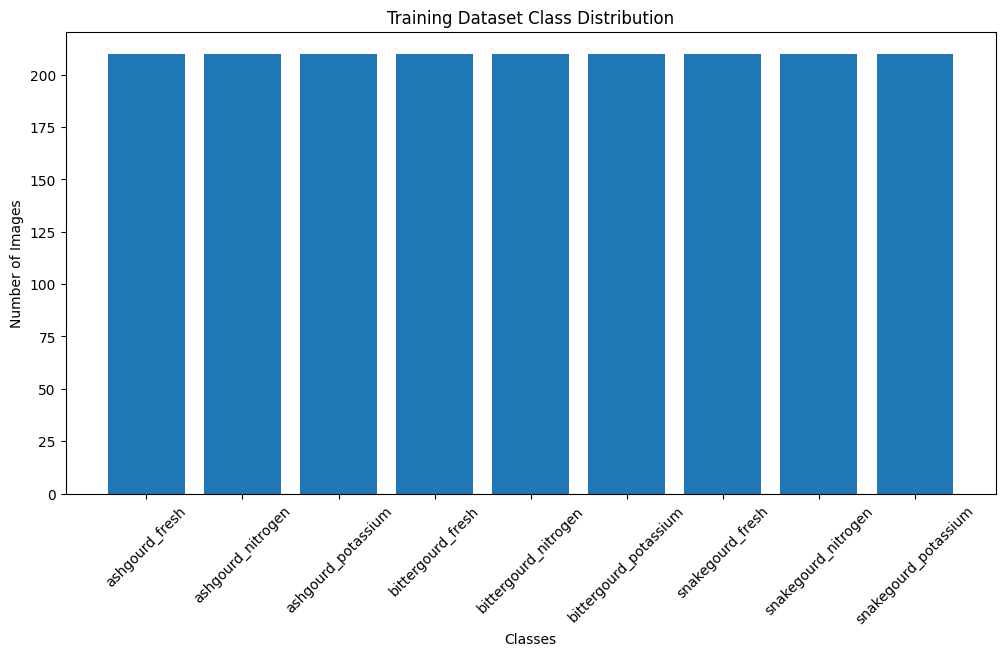

In [9]:
plt.figure(figsize=(12, 6))

plt.bar(classes, train_count)

plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Training Dataset Class Distribution")

plt.xticks(rotation=45)

plt.show()

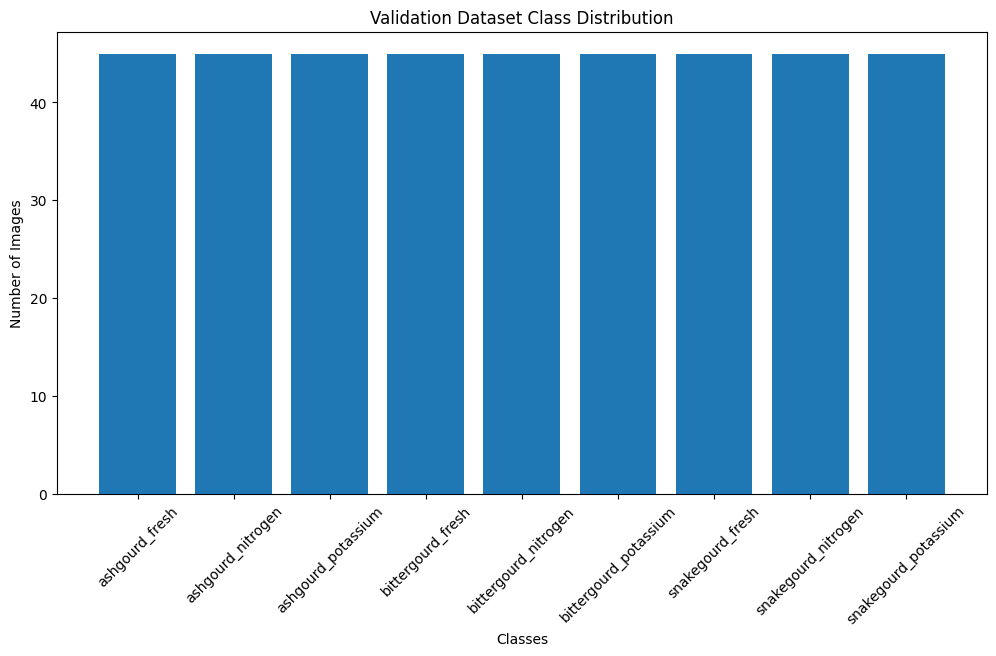

In [10]:
plt.figure(figsize=(12, 6))

plt.bar(classes, val_count)

plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Validation Dataset Class Distribution")

plt.xticks(rotation=45)

plt.show()

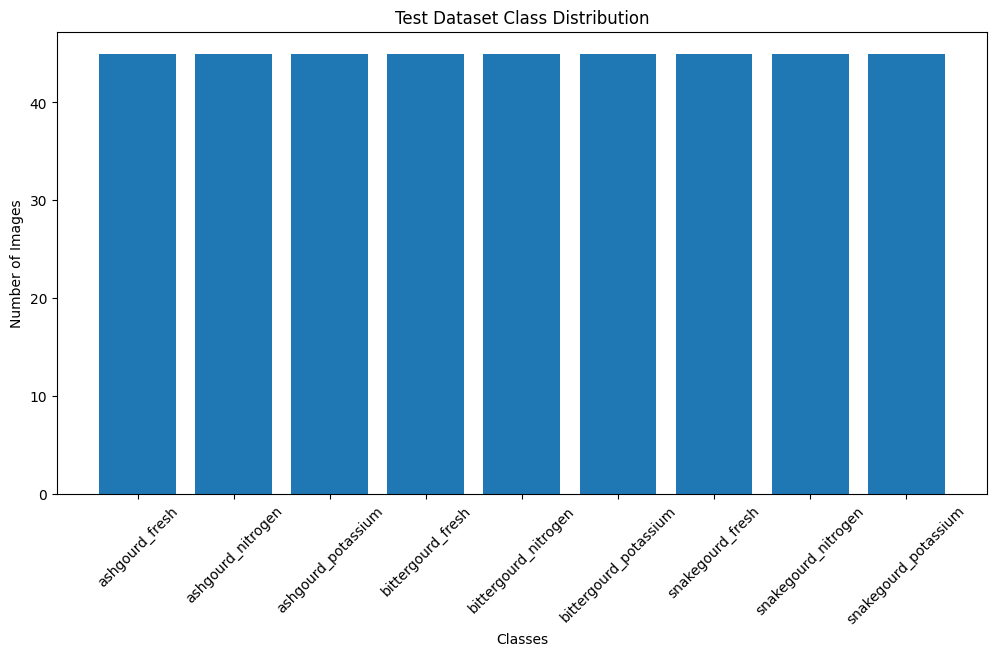

In [11]:
plt.figure(figsize=(12, 6))

plt.bar(classes, test_count)

plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Test Dataset Class Distribution")

plt.xticks(rotation=45)

plt.show()

# slider needs images should be in folder


In [12]:

import os
import cv2
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display




dataset_path = "/home/mtech_atul/atul/Early_NSD_Dataset"
datasets = {
    "Train": "train",
    "Val": "val",
    "Test": "test"
}

classes = [
    "ashgourd_fresh",
    "ashgourd_nitrogen",
    "ashgourd_potassium",
    "bittergourd_fresh",
    "bittergourd_nitrogen",
    "bittergourd_potassium",
    "snakegourd_fresh",
    "snakegourd_nitrogen",
    "snakegourd_potassium"
]

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
)

print("Dataset path:")
print(dataset_path)

if os.path.exists(dataset_path):

    print("\nDataset path found!")

    print("\nDataset contents:")
    print(os.listdir(dataset_path))

else:

    print("\nERROR: Dataset path not found!")



# GET IMAGES
def get_images(dataset, cls):

    # Convert display name to actual folder name
    dataset_folder = datasets[dataset]

    folder = os.path.join( dataset_path, dataset_folder, cls)

    # Check folder
    if not os.path.exists(folder):

        print("Folder not found:")
        print(folder)

        return []

    # Get only image files
    images = sorted([
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith(IMAGE_EXTENSIONS)
    ])

    return images



# SHOW IMAGE
def show_image(dataset, cls, index):

    images = get_images(dataset, cls)

    if not images:

        print("No images found.")

        return

    # Make sure index is valid
    index = max(0, min(index, len(images) - 1))

    # Get selected image
    image_path = images[index]

    # Read image
    img = cv2.imread(image_path)

    if img is None:

        print("Could not read image:")
        print(image_path)

        return

    # BGR → RGB
    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    # Display
    plt.figure(figsize=(7, 7))

    plt.imshow(img)

    plt.title(
        f"{dataset} / {cls}\n"
        f"Image {index + 1} / {len(images)}\n"
        f"{os.path.basename(image_path)}"
    )

    plt.axis("off")
    plt.show()


# ============================================================
# DATASET DROPDOWN
# ============================================================

dataset_dropdown = widgets.Dropdown(
    options=list(datasets.keys()),
    value="Train",
    description="Dataset:",
    style={"description_width": "initial"}
)


# CLASS DROPDOWN
class_dropdown = widgets.Dropdown(
    options=classes,
    value=classes[0],
    description="Class:",
    style={"description_width": "initial"}
)



# IMAGE SLIDER
image_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=0,
    step=1,
    description="Image:",
    continuous_update=False,
    style={"description_width": "initial"},
    layout=widgets.Layout(width="600px")
)



# INFORMATION
image_info = widgets.HTML(
    value="<b>Select a dataset and class.</b>"
)


# UPDATE SLIDER
def update_slider(*args):

    images = get_images(
        dataset_dropdown.value,
        class_dropdown.value
    )

    # Update slider range
    image_slider.max = max(len(images) - 1, 0)

    # Reset image index
    image_slider.value = 0

    # Update information
    if images:

        image_info.value = (f"<b>{len(images)} images found</b>")

    else:

        image_info.value = ("<b style='color:red;'>No images found</b>")


# CONNECT DROPDOWNS
dataset_dropdown.observe(
    update_slider,
    names="value"
)

class_dropdown.observe(
    update_slider,
    names="value"
)


# IMAGE OUTPUT
output = widgets.interactive_output(
    show_image,{ "dataset": dataset_dropdown, "cls": class_dropdown, "index": image_slider})



# DISPLAY
display(
    widgets.VBox([ dataset_dropdown, class_dropdown, image_slider, image_info, output]))

update_slider()

Dataset path:
/home/mtech_atul/atul/Early_NSD_Dataset

Dataset path found!

Dataset contents:
['val', 'train', 'test']


In [13]:
from PIL import Image

img = Image.open(filelist[0])

print("Image resolution:", img.size)

Image resolution: (5544, 5544)


# Preparation of different color representations

RGB, HUV, CIELUV, Nutrisapce


The Need fo developing Nutrispace was early detection of nutritional deficiency can produce subtle visual changes that may be difficult to distinguish using conventional RGB representation

In [18]:
import numpy as np
import cv2


class Converter:

    # All conversions require BGR input
    def __init__(self):
        pass

    # ---------------------------------------------------------
    # HSV
    # ---------------------------------------------------------
    def to_hsv(self, im):
        return cv2.cvtColor(im, cv2.COLOR_BGR2HSV)

    # ---------------------------------------------------------
    # CIELAB
    # ---------------------------------------------------------
    def to_cielab(self, im):
        return cv2.cvtColor(im, cv2.COLOR_BGR2Lab)

    # ---------------------------------------------------------
    # NUTRISPACE
    # ---------------------------------------------------------
    def to_nutrispace(self, im):

        # Suppress invalid-value warnings
        np.seterr(invalid='ignore')

        # BGR -> RGB
        im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

        # -----------------------------------------------------
        # Convert image from uint8 [0,255]
        # to float64 [0,1]
        # -----------------------------------------------------

        def im2double(im):
            info = np.iinfo(im.dtype)
            return im.astype(np.float64) / info.max

        # Extract RGB channels
        r = im2double(im[:, :, 0])
        g = im2double(im[:, :, 1])
        b = im2double(im[:, :, 2])

        # -----------------------------------------------------
        # CAM16 chromatic adaptation transformation
        # -----------------------------------------------------

        CAT16 = np.matrix(
            '0.401288 0.650173 -0.051461;'
            '-0.250268 1.204414 0.045854;'
            '-0.002079 0.048952 0.953127'
        )

        CAT16_inv = np.linalg.inv(CAT16)

        # -----------------------------------------------------
        # RGB -> XYZ
        # -----------------------------------------------------

        X = (
            CAT16_inv[0, 0] * r +
            CAT16_inv[0, 1] * g +
            CAT16_inv[0, 2] * b
        )

        Y = (
            CAT16_inv[1, 0] * r +
            CAT16_inv[1, 1] * g +
            CAT16_inv[1, 2] * b
        )

        Z = (
            CAT16_inv[2, 0] * r +
            CAT16_inv[2, 1] * g +
            CAT16_inv[2, 2] * b
        )

        # -----------------------------------------------------
        # Reference white point D65
        # -----------------------------------------------------

        WhitePoint = np.matrix(
            '95.047 100.000 108.883'
        )

        WhitePointU = (
            4 * WhitePoint[0, 0]
        ) / (
            WhitePoint[0, 0] +
            15 * WhitePoint[0, 1] +
            3 * WhitePoint[0, 2]
        )

        # -----------------------------------------------------
        # Channel 1
        # -----------------------------------------------------

        U = (
            4 * X
        ) / (
            X + 15 * Y + 3 * Z
        )

        y = Y / WhitePoint[0, 1]

        y_dash = y ** (1 / 3)

        if y.all() > 0.008856:
            L = (116 * y_dash) - 16
        else:
            L = 903.3 * y

        Channel_1 = 13 * (
            L * (U - WhitePointU)
        )

        # -----------------------------------------------------
        # Channel 2
        # -----------------------------------------------------

        Channel_2 = (
            0.40024 * X +
            0.7076 * Y -
            0.08081 * Z
        )

        # -----------------------------------------------------
        # Channel 3
        # -----------------------------------------------------

        def f(t):

            if t.all() > 0.008856:
                return np.real(t ** (1 / 3))
            else:
                return (
                    7.787 * t
                ) + (4 / 29)

        xr = X / WhitePoint[0, 0]
        yr = Y / WhitePoint[0, 1]

        Channel_3 = 500 * (f(xr) - f(yr))

        # -----------------------------------------------------
        # Final Nutrispace image
        # -----------------------------------------------------

        NSPACE = np.zeros(
            (len(im), len(im), 3)
        )

        NSPACE[:, :, 0] = Channel_1
        NSPACE[:, :, 1] = Channel_2
        NSPACE[:, :, 2] = Channel_3

        return NSPACE

In [14]:
converter = Converter()

# Replace "your_image.jpg" with a valid image path.
# For example, using the first image from filelist:
image_path = filelist[0]
image = cv2.imread(image_path)

# Check if the image was loaded successfully
if image is None:
    print(f"Error: Could not load image from {image_path}. Please check the path and file integrity.")
else:
    # 1. RGB
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 2. HSV
    hsv = converter.to_hsv(image)

    # 3. CIELAB
    cielab = converter.to_cielab(image)

    # 4. Nutrispace
    nutrispace = converter.to_nutrispace(image)

    print("RGB shape:", rgb.shape)
    print("HSV shape:", hsv.shape)
    print("CIELAB shape:", cielab.shape)
    print("Nutrispace shape:", nutrispace.shape)


RGB shape: (5544, 5544, 3)
HSV shape: (5544, 5544, 3)
CIELAB shape: (5544, 5544, 3)
Nutrispace shape: (5544, 5544, 3)


## Modified RGB --Mobilenet


Number of classes: 9

Image size: (312, 312)
Batch size: 32
Dropout: 0.2
TRAIN DATASET
Found 1890 files belonging to 9 classes.
 VALIDATION DATASET
Found 405 files belonging to 9 classes.
TEST DATASET
Found 405 files belonging to 9 classes.


E0000 00:00:1790757638.851947  506745 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1790757638.852400  507073 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1790757638.882187  506745 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/tmp/ipykernel_506745/1491053137.py:152: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 22

CREATING RGB + MOBILENETV2
MODEL SUMMARY


Model: "RGB_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_normalization       │ (None, 312, 312, 3)    │             0 │
│ (Lambda)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 10, 10, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,513 (8.66 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


RGB + MOBILENETV2
STAGE 1
LEARNING RATE = 1e-3
NORMALIZATION = [-1, 1]

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 24s 364ms/step - accuracy: 0.4328 - loss: 1.4980 - val_accuracy: 0.6049 - val_loss: 1.0409
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 351ms/step - accuracy: 0.6132 - loss: 0.9762 - val_accuracy: 0.6790 - val_loss: 0.8949
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 350ms/step - accuracy: 0.6619 - loss: 0.8418 - val_accuracy: 0.6667 - val_loss: 0.8170
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 22s 363ms/step - accuracy: 0.7026 - loss: 0.7538 - val_accuracy: 0.6889 - val_loss: 0.7603
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 22s 359ms/step - accuracy: 0.7180 - loss: 0.6876 - val_accuracy: 0.7062 - val_loss: 0.7214
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 350ms/step - accuracy: 0.7423 - loss: 0.6548 - val_accuracy: 0.7259 - val_loss: 0.6989
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 340ms/step - accuracy: 0.7630 - loss: 0.6235 - val_accuracy: 0.7531 - val_loss: 0.6615
Epoch 8/20
60/60 ━━━━━━━

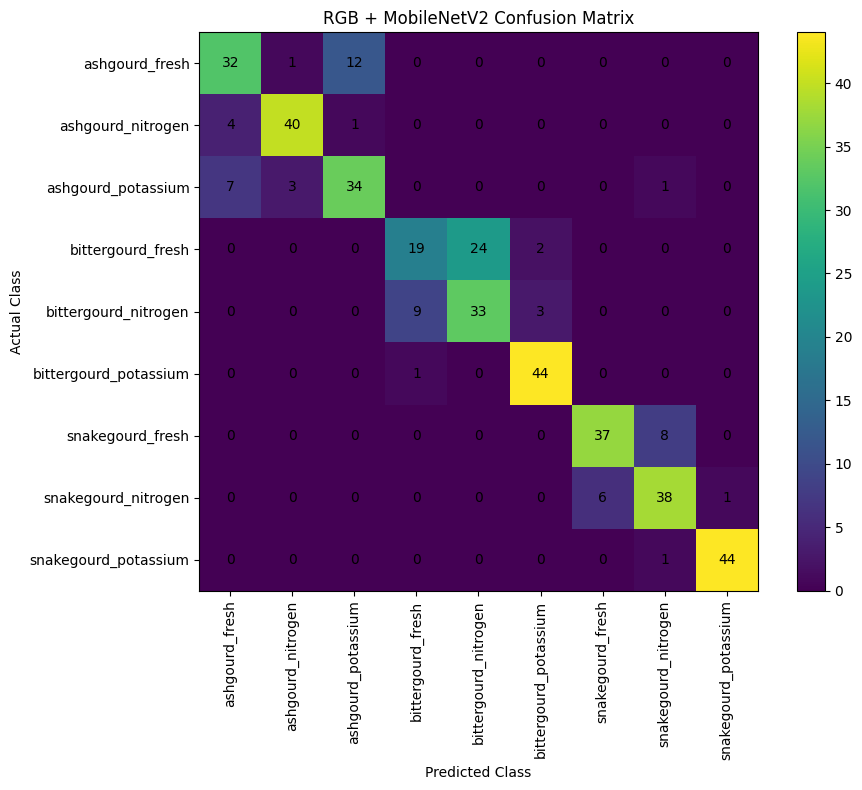

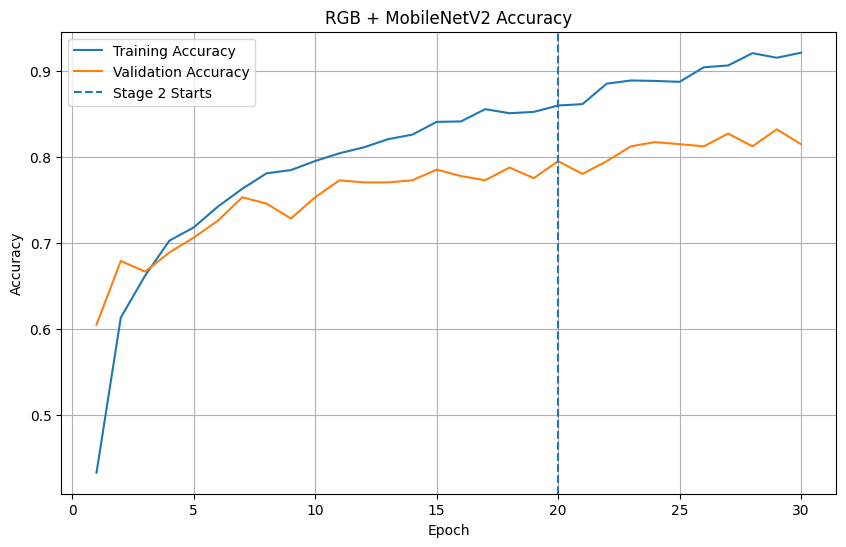

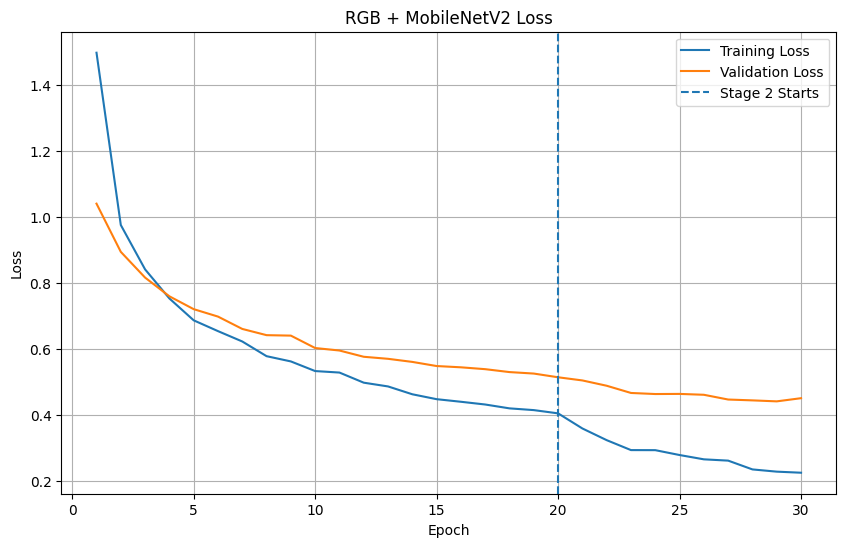

MODEL SAVED
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/RGB_312/RGB_MobileNetV2_Controlled_FT/RGB_MobileNetV2_312x312_Dropout03_StableFT.keras
FINAL RGB + MOBILENETV2 RESULTS
Model                Accuracy        Macro F1        MCC            
MobileNetV2          0.7926          0.7887          0.7678         


In [14]:
import os  
import numpy as np  
import tensorflow as tf  
import matplotlib.pyplot as plt  
from tensorflow.keras import layers, models  
from tensorflow.keras.applications import MobileNetV2  
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input  
from tensorflow.keras.layers import BatchNormalization  
  
from sklearn.metrics import ( accuracy_score, f1_score, matthews_corrcoef, confusion_matrix, classification_report)  
  
 
BASE_ROOT = ( "/home/mtech_atul/atul/" "Early_Output-20260923T172757Z-1-001/" "Early_Output" ) 
 
 
TRAIN_DIR = os.path.join( 
    BASE_ROOT, 
    "Train_256" 
) 
 
 
VAL_DIR = os.path.join( 
    BASE_ROOT, 
    "Val_resized312" 
) 
 
 
TEST_DIR = os.path.join( 
    BASE_ROOT, 
    "Test_resized312" 
) 
 
 

# OUTPUT DIRECTORY 
OUTPUT_DIR = os.path.join( 
    BASE_ROOT, 
    "RGB_312", 
    "RGB_MobileNetV2_Controlled_FT" 
) 
 
 
os.makedirs( 
    OUTPUT_DIR, 
    exist_ok=True 
) 
  
  
# Classes  
classes = [  
  
    "ashgourd_fresh",  
    "ashgourd_nitrogen",  
    "ashgourd_potassium",  
  
    "bittergourd_fresh",  
    "bittergourd_nitrogen",  
    "bittergourd_potassium",  
  
    "snakegourd_fresh",  
    "snakegourd_nitrogen",  
    "snakegourd_potassium"  
  
]  
  
num_classes = len(classes)  
print("\nNumber of classes:", num_classes)  
  
  
  
IMG_SIZE = (312, 312)  
  
BATCH_SIZE = 32  
  
DROPOUT_RATE = 0.2  
  
  
print("\nImage size:", IMG_SIZE)  
  
print("Batch size:", BATCH_SIZE)  
  
print("Dropout:", DROPOUT_RATE)  
  
  
  
# TRAIN DATASET  
print("TRAIN DATASET")  
  
  
train_ds = tf.keras.utils.image_dataset_from_directory(  
  
    TRAIN_DIR,  
    labels="inferred",  
    label_mode="categorical",  
    class_names=classes,  
    image_size=IMG_SIZE,  
    batch_size=BATCH_SIZE,  
    shuffle=True,  
    seed=42  
)  
  
  
# VALIDATION DATASET  
print(" VALIDATION DATASET")  
  
  
val_ds = tf.keras.utils.image_dataset_from_directory(  
  
    VAL_DIR,  
    labels="inferred",  
    label_mode="categorical",  
    class_names=classes,  
    image_size=IMG_SIZE,  
    batch_size=BATCH_SIZE,  
    shuffle=False  
)  
  
  
  
# TEST DATASET  
print("TEST DATASET")  
  
  
test_ds = tf.keras.utils.image_dataset_from_directory(  
  
    TEST_DIR,  
    labels="inferred",  
    label_mode="categorical",  
    class_names=classes,  
    image_size=IMG_SIZE,  
    batch_size=BATCH_SIZE,  
    shuffle=False  
)  
  
  
normalization_layer = layers.Lambda(preprocess_input, name="mobilenetv2_normalization")  
  
  
  
# PREFETCH DATA  
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)  
  
val_ds = val_ds.prefetch( tf.data.AUTOTUNE)  
  
test_ds = test_ds.prefetch( tf.data.AUTOTUNE)  
  
  
# CREATE MOBILENETV2 MODEL  
  
  
def create_mobilenet_model():  
    base_model = MobileNetV2( weights="imagenet", include_top=False, input_shape=( IMG_SIZE[0], IMG_SIZE[1], 3))  
  
  
  
    # Stage 1:  
    # Freeze entire MobileNetV2  
  
    base_model.trainable = False  
  
    # Build complete model  
  
    model = models.Sequential([layers.Input(shape=(IMG_SIZE[0],IMG_SIZE[1],3),name="rgb_input"),  
  
            # RGB normalization  
            layers.Lambda(preprocess_input,name="mobilenetv2_normalization"), base_model,  
            layers.GlobalAveragePooling2D(name="global_average_pooling2d"),  
  
            # Dropout  
            layers.Dropout( DROPOUT_RATE, name="dropout"),  
  
            # 9-class classifier  
            layers.Dense( num_classes, activation="softmax", name="classification")],name="RGB_MobileNetV2")  
  
    return model, base_model  
  
  
# CREATE MODEL  
print("CREATING RGB + MOBILENETV2")  
model, base_model = create_mobilenet_model()  
  
# MODEL SUMMARY  
print("MODEL SUMMARY")  
model.summary()  
  
  
print("\n======================================")  
print("RGB + MOBILENETV2")  
print("STAGE 1")  
print("LEARNING RATE = 1e-3")  
print("NORMALIZATION = [-1, 1]")  
print("======================================\n")  
  
  
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),loss="categorical_crossentropy",metrics=["accuracy"])  
  
  
# TRAIN STAGE 1  
history1 = model.fit( train_ds, validation_data=val_ds, epochs=20, verbose=1)  
  
  
  
# STAGE 2  
# STABLE FINE-TUNING  
  
print("\n======================================")  
print("RGB + MOBILENETV2")  
print("STAGE 2")  
print("STABLE FINE-TUNING")  
print("INITIAL LEARNING RATE = 5e-6")  
print("======================================\n")  
  
  
  
# UNFREEZE MOBILE NETV2  
base_model.trainable = True  
  
  
# FINE-TUNE ONLY LAST 30 LAYERS  
fine_tune_at = len(base_model.layers) - 30  
  
  
for layer_index, layer in enumerate(base_model.layers):  
  
    if layer_index < fine_tune_at:  
  
        # Freeze earlier layers  
        layer.trainable = False  
  
    else:  
  
        # Unfreeze last 30 layers  
        layer.trainable = True  
  
  
# KEEP BATCH NORMALIZATION LAYERS FROZEN  
  
for layer in base_model.layers:  
  
    if isinstance(layer, BatchNormalization):  
        layer.trainable = False  
  
  
# PRINT FINE-TUNING INFORMATION  
trainable_layers = 0  
frozen_layers = 0  
  
  
for layer in base_model.layers:  
  
    if layer.trainable:  
        trainable_layers += 1  
    else:  
        frozen_layers += 1  
  
  
print("\nMobileNetV2 fine-tuning configuration:")  
  
print( "Trainable layers:", trainable_layers)  
  
print( "Frozen layers:", frozen_layers)  
  
print( "Fine-tuning from layer:", fine_tune_at)  
  
  
  
# RECOMPILE MODEL  
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6), loss="categorical_crossentropy",metrics=["accuracy"])  
  
  
# REDUCE LEARNING RATE ON PLATEAU  
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau( monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7, verbose=1)  
  
  
# TRAIN STAGE 2  
history2 = model.fit( train_ds, validation_data=val_ds, epochs=10, verbose=1, callbacks=[reduce_lr])  
  
# TEST MODEL  
print("RGB + MOBILENETV2   TESTING")  
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)  
  
# GENERATE PREDICTIONS  
print("GENERATING PREDICTIONS")  
predictions = model.predict( test_ds, verbose=1)  
  
  
# PREDICTED LABELS  
y_pred = np.argmax( predictions, axis=1)  
  
  
# TRUE LABELS  
y_true = []  
  
for images, labels in test_ds:  
  
    labels = labels.numpy()  
    labels = np.argmax(labels, axis=1)  
  
    y_true.extend(labels)  
  
y_true = np.array(y_true)  
  
  
# CALCULATE METRICS  
accuracy = accuracy_score( y_true, y_pred)  
macro_f1 = f1_score( y_true, y_pred, average="macro")  
mcc = matthews_corrcoef( y_true, y_pred)  
  
  
# FINAL TEST RESULTS  
print("RGB + MOBILENETV2     FINAL TEST RESULTS")  
  
print( "Test Loss :", test_loss)  
  
print( "Accuracy  :", accuracy)  
  
print("Macro F1  :", macro_f1)  
  
print("MCC       :",mcc)  
  
  
  
# CLASSIFICATION REPORT  
print("RGB + MOBILENETV2    CLASSIFICATION REPORT")  
  
print(classification_report(y_true,y_pred,target_names=classes))  
  
  
  
# CONFUSION MATRIX  
  
cm = confusion_matrix( y_true, y_pred)  
  
plt.figure(figsize=(10, 8))  
plt.imshow(cm) 
  
plt.title("RGB + MobileNetV2 Confusion Matrix")  
plt.xlabel("Predicted Class")  
plt.ylabel("Actual Class")  
plt.colorbar()  
plt.xticks(np.arange(num_classes),classes,rotation=90)  
plt.yticks(np.arange(num_classes),classes)  
  
  
for i in range(num_classes):  
  
    for j in range(num_classes):  
  
        plt.text( j, i, cm[i, j], ha="center", va="center")  
  
plt.tight_layout()  
plt.show()  
  
  
# COMBINE TRAINING HISTORY  
train_accuracy = (history1.history["accuracy"]+history2.history["accuracy"])  
  
val_accuracy = ( history1.history["val_accuracy"] + history2.history["val_accuracy"])  
  
train_loss = ( history1.history["loss"] + history2.history["loss"])  
  
val_loss = ( history1.history["val_loss"] + history2.history["val_loss"])  
  
  
  
# ACCURACY    
plt.figure(figsize=(10, 6))  
epochs_range = range(1,len(train_accuracy) + 1)  
plt.plot(epochs_range,train_accuracy,label="Training Accuracy")  
  
plt.plot( epochs_range, val_accuracy, label="Validation Accuracy")  
  
plt.axvline(x=20,linestyle="--",label="Stage 2 Starts")  
  
plt.title("RGB + MobileNetV2 Accuracy")  
  
plt.xlabel("Epoch")  
plt.ylabel("Accuracy")  
plt.legend()  
plt.grid()  
plt.show()  
  
# LOSS PLOT  
plt.figure(figsize=(10, 6))  
plt.plot(epochs_range, train_loss, label="Training Loss")  
  
plt.plot( epochs_range, val_loss, label="Validation Loss")  
  
plt.axvline(x=20,linestyle="--",label="Stage 2 Starts")  
  
plt.title("RGB + MobileNetV2 Loss")  
plt.xlabel("Epoch")  
plt.ylabel("Loss")  
plt.legend()  
plt.grid()  
plt.show()  
  
  
# SAVE MODEL  
save_path = os.path.join( 
    OUTPUT_DIR, 
    "RGB_MobileNetV2_312x312_Dropout03_StableFT.keras" 
)  
  
model.save(save_path)  
print("MODEL SAVED")  
print(save_path)  
  
  
  
# FINAL SUMMARY  
  
print("FINAL RGB + MOBILENETV2 RESULTS")  
  
print("{:<20} {:<15} {:<15} {:<15}".format( "Model", "Accuracy", "Macro F1", "MCC"))  
  
print("{:<20} {:<15.4f} {:<15.4f} {:<15.4f}".format( "MobileNetV2", accuracy, macro_f1, mcc))

## RGB MobileNet ---> Testing

In [20]:
def predict_early_nutrient_stress(image_path):

    print("\n==============================================")
    print("EARLY NUTRIENT STRESS DETECTION")
    print("==============================================")

    image = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    image_array = tf.keras.utils.img_to_array(
        image
    )

    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    probabilities = model.predict(
        image_array,
        verbose=0
    )[0]

    predicted_index = np.argmax(
        probabilities
    )

    predicted_class = classes[
        predicted_index
    ]

    confidence = (
        probabilities[predicted_index] * 100
    )

    actual_class = os.path.basename(
        os.path.dirname(image_path)
    )

    print("\nImage:")
    print(image_path)

    print("\nActual Class:")
    print(actual_class)

    print("\nPredicted Class:")
    print(predicted_class)

    print("\nConfidence:")
    print(f"{confidence:.2f}%")

    if predicted_class == actual_class:

        print("\nPrediction:")
        print("CORRECT")

    else:

        print("\nPrediction:")
        print("INCORRECT")

    if "nitrogen" in predicted_class:

        print("\nEARLY NUTRIENT STRESS:")
        print("Nitrogen deficiency class detected.")

    elif "potassium" in predicted_class:

        print("\nEARLY NUTRIENT STRESS:")
        print("Potassium deficiency class detected.")

    elif "fresh" in predicted_class:

        print("\nEARLY NUTRIENT STRESS:")
        print("No nutrient-deficiency class detected.")

    print("\n----------------------------------------------")
    print("ALL CLASS PROBABILITIES")
    print("----------------------------------------------")

    for i, class_name in enumerate(classes):

        print(
            f"{class_name:<25}"
            f"{probabilities[i] * 100:.2f}%"
        )

    return (
        actual_class,
        predicted_class,
        confidence,
        probabilities
    )


image_path = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/Test_resized312/"
    "ashgourd_nitrogen/RGB (65).JPG"
)

predict_early_nutrient_stress(
    image_path
)


EARLY NUTRIENT STRESS DETECTION

Image:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Test_resized312/ashgourd_nitrogen/RGB (65).JPG

Actual Class:
ashgourd_nitrogen

Predicted Class:
ashgourd_nitrogen

Confidence:
99.44%

Prediction:
CORRECT

EARLY NUTRIENT STRESS:
Nitrogen deficiency class detected.

----------------------------------------------
ALL CLASS PROBABILITIES
----------------------------------------------
ashgourd_fresh           0.39%
ashgourd_nitrogen        99.44%
ashgourd_potassium       0.11%
bittergourd_fresh        0.00%
bittergourd_nitrogen     0.00%
bittergourd_potassium    0.00%
snakegourd_fresh         0.05%
snakegourd_nitrogen      0.00%
snakegourd_potassium     0.00%


('ashgourd_nitrogen',
 'ashgourd_nitrogen',
 np.float32(99.44483),
 array([3.90406698e-03, 9.94448304e-01, 1.14556809e-03, 1.11684085e-05,
        1.28625315e-05, 4.81551410e-07, 4.64503013e-04, 1.24586877e-05,
        6.51121695e-07], dtype=float32))

## Early Nutrient Deficiency stress

In [ ]:

# IMAGE → CROP + CONDITION PREDICTION


image_path = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/Test_resized312/"
    "ashgourd_nitrogen/RGB (65).JPG"
)


image = tf.keras.utils.load_img(
    image_path,
    target_size=IMG_SIZE
)

image_array = tf.keras.utils.img_to_array(
    image
)

image_array = np.expand_dims(
    image_array,
    axis=0
)


# CNN PREDICTION
probabilities = model.predict(
    image_array,
    verbose=0
)[0]


# CROP PROBABILITIES
ashgourd = np.sum(
    probabilities[0:3]
)

bittergourd = np.sum(
    probabilities[3:6]
)

snakegourd = np.sum(
    probabilities[6:9]
)

crop_probs = {
    "ashgourd": ashgourd,
    "bittergourd": bittergourd,
    "snakegourd": snakegourd
}

predicted_crop = max(
    crop_probs,
    key=crop_probs.get
)


# CONDITION PROBABILITIES
start = {
    "ashgourd": 0,
    "bittergourd": 3,
    "snakegourd": 6
}[predicted_crop]

fresh = probabilities[start]
nitrogen = probabilities[start + 1]
potassium = probabilities[start + 2]

condition_probs = {
    "fresh": fresh,
    "nitrogen": nitrogen,
    "potassium": potassium
}

predicted_condition = max(
    condition_probs,
    key=condition_probs.get
)


# RESULTS
print("\n" + "=" * 55)
print("LEAF CLASSIFICATION RESULT")
print("=" * 55)

print("\nImage:")
print(image_path)

print("\nCROP PROBABILITIES")
print("-" * 55)

print(f"Ashgourd    : {ashgourd * 100:.2f}%")

print(f"Bittergourd : {bittergourd * 100:.2f}%")

print(f"Snakegourd  : {snakegourd * 100:.2f}%")

print(f"\nPredicted Crop: {predicted_crop.upper()}")

print("\nCONDITION PROBABILITIES")
print("-" * 55)

print(f"Fresh      : {fresh * 100:.2f}%")

print(f"Nitrogen   : {nitrogen * 100:.2f}%")

print(f"Potassium  : {potassium * 100:.2f}%")

print("\nFINAL RESULT")
print("-" * 55)

print(f"Crop      : {predicted_crop.upper()}")

print(f"Condition : {predicted_condition.upper()}")

print(f"Final Class: "f"{predicted_crop}_{predicted_condition}")



LEAF CLASSIFICATION RESULT

Image:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Test_resized312/ashgourd_nitrogen/RGB (65).JPG

CROP PROBABILITIES
-------------------------------------------------------
Ashgourd    : 99.95%
Bittergourd : 0.00%
Snakegourd  : 0.05%

Predicted Crop: ASHGOURD

CONDITION PROBABILITIES
-------------------------------------------------------
Fresh      : 0.39%
Nitrogen   : 99.44%
Potassium  : 0.11%

FINAL RESULT
-------------------------------------------------------
Crop      : ASHGOURD
Condition : NITROGEN
Final Class: ashgourd_nitrogen


In [ ]:
# EARLY NUTRIENT STRESS PREDICTION

CONFIDENCE_THRESHOLD = 0.50


def predict_early_nutrient_stress(image_path):

    print("\n==============================================")
    print("EARLY NUTRIENT STRESS PREDICTION")
    print("==============================================")

    image = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    image_array = tf.keras.utils.img_to_array(
        image
    )

    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    probabilities = model.predict(
        image_array,
        verbose=0
    )[0]

    predicted_index = np.argmax(
        probabilities
    )

    predicted_class = classes[
        predicted_index
    ]

    confidence = probabilities[
        predicted_index
    ]

    confidence_percent = (
        confidence * 100
    )

    actual_class = os.path.basename(
        os.path.dirname(image_path)
    )

    print("\nImage:")
    print(image_path)

    print("\nActual Class:")
    print(actual_class)

    print("\nPredicted Class:")
    print(predicted_class)

    print("\nConfidence:")
    print(
        f"{confidence_percent:.2f}%"
    )

    print("\nConfidence Threshold:")
    print(
        f"{CONFIDENCE_THRESHOLD * 100:.2f}%"
    )

    if confidence < CONFIDENCE_THRESHOLD:

        stress_status = "UNCERTAIN"

        print("\nEARLY-STRESS PREDICTION:")
        print("UNCERTAIN")

        print(
            "Model confidence is below "
            "the defined threshold."
        )

    elif "nitrogen" in predicted_class:

        stress_status = "EARLY NITROGEN STRESS"

        print("\nEARLY-STRESS PREDICTION:")
        print("EARLY NITROGEN STRESS")

        print(
            "Predicted as an early "
            "nitrogen-deficiency class."
        )

    elif "potassium" in predicted_class:

        stress_status = "EARLY POTASSIUM STRESS"

        print("\nEARLY-STRESS PREDICTION:")
        print("EARLY POTASSIUM STRESS")

        print(
            "Predicted as an early "
            "potassium-deficiency class."
        )

    elif "fresh" in predicted_class:

        stress_status = "NO EARLY NUTRIENT STRESS"

        print("\nEARLY-STRESS PREDICTION:")
        print("NO EARLY NUTRIENT STRESS")

        print(
            "Predicted as a fresh/healthy class."
        )

    else:

        stress_status = "UNCERTAIN"

        print("\nEARLY-STRESS PREDICTION:")
        print("UNCERTAIN")

    if predicted_class == actual_class:

        print("\nPrediction:")
        print("CORRECT")

    else:

        print("\nPrediction:")
        print("INCORRECT")

    print("\n----------------------------------------------")
    print("ALL CLASS PROBABILITIES")
    print("----------------------------------------------")

    for i, class_name in enumerate(classes):

        print(
            f"{class_name:<25}"
            f"{probabilities[i] * 100:.2f}%"
        )

    print("\n----------------------------------------------")
    print("FINAL DECISION")
    print("----------------------------------------------")

    print(
        f"Predicted Class : {predicted_class}"
    )

    print(
        f"Confidence      : "
        f"{confidence_percent:.2f}%"
    )

    print(
        f"Decision        : {stress_status} found"
    )

    return (
        actual_class,
        predicted_class,
        confidence,
        probabilities,
        stress_status
    )



# TEST EARLY NUTRIENT STRESS PREDICTION
image_path = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/Test_resized312/"
    "ashgourd_nitrogen/RGB (65).JPG"
)

predict_early_nutrient_stress(
    image_path
)


EARLY NUTRIENT STRESS PREDICTION

Image:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Test_resized312/ashgourd_nitrogen/RGB (65).JPG

Actual Class:
ashgourd_nitrogen

Predicted Class:
ashgourd_nitrogen

Confidence:
99.44%

Confidence Threshold:
50.00%

EARLY-STRESS PREDICTION:
EARLY NITROGEN STRESS
Predicted as an early nitrogen-deficiency class.

Prediction:
CORRECT

----------------------------------------------
ALL CLASS PROBABILITIES
----------------------------------------------
ashgourd_fresh           0.39%
ashgourd_nitrogen        99.44%
ashgourd_potassium       0.11%
bittergourd_fresh        0.00%
bittergourd_nitrogen     0.00%
bittergourd_potassium    0.00%
snakegourd_fresh         0.05%
snakegourd_nitrogen      0.00%
snakegourd_potassium     0.00%

----------------------------------------------
FINAL DECISION
----------------------------------------------
Predicted Class : ashgourd_nitrogen
Confidence      : 99.44%
Decision        : EARLY NITROGEN 

('ashgourd_nitrogen',
 'ashgourd_nitrogen',
 np.float32(0.9944483),
 array([3.90406698e-03, 9.94448304e-01, 1.14556809e-03, 1.11684085e-05,
        1.28625315e-05, 4.81551410e-07, 4.64503013e-04, 1.24586877e-05,
        6.51121695e-07], dtype=float32),
 'EARLY NITROGEN STRESS')

## Modified RGB --- EfficientnetB0

I0000 00:00:1790765805.395840  519674 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790765805.396864  519674 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790765805.439993  519674 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790765806.619344  519674 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Number of classes: 9

Image size: (312, 312)
Batch size: 32
Dropout: 0.2

 TRAIN DATASET
Found 1890 files belonging to 9 classes.

 VALIDATION DATASET
Found 405 files belonging to 9 classes.

 TEST DATASET
Found 405 files belonging to 9 classes.


E0000 00:00:1790765807.819352  519674 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1790765807.819840  519893 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1790765807.849112  519674 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


EFFICIENTNETB0 PREPROCESSING
RGB input: [0,255]

CREATING RGB + EFFICIENTNETB0

MODEL SUMMARY



Model: "RGB_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 10, 10, 1280)   │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,061,100 (15.49 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


RGB + EFFICIENTNETB0
STAGE 1
LEARNING RATE = 1e-3

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 34s 491ms/step - accuracy: 0.3772 - loss: 1.6668 - val_accuracy: 0.6049 - val_loss: 1.2300
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 30s 508ms/step - accuracy: 0.5868 - loss: 1.1310 - val_accuracy: 0.6667 - val_loss: 0.9917
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 466ms/step - accuracy: 0.6423 - loss: 0.9657 - val_accuracy: 0.6864 - val_loss: 0.8846
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 471ms/step - accuracy: 0.6815 - loss: 0.8755 - val_accuracy: 0.6864 - val_loss: 0.8191
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 467ms/step - accuracy: 0.6804 - loss: 0.8227 - val_accuracy: 0.7012 - val_loss: 0.7724
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 467ms/step - accuracy: 0.7095 - loss: 0.7755 - val_accuracy: 0.7160 - val_loss: 0.7358
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 466ms/step - accuracy: 0.7153 - loss: 0.7321 - val_accuracy: 0.7309 - val_loss: 0.7112
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 27s 459

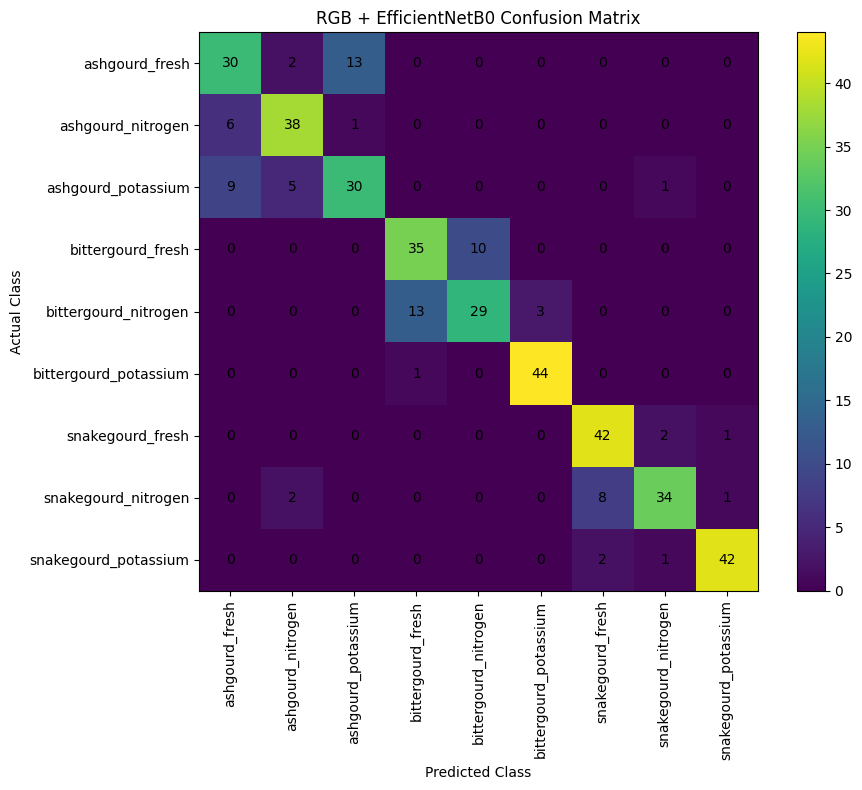

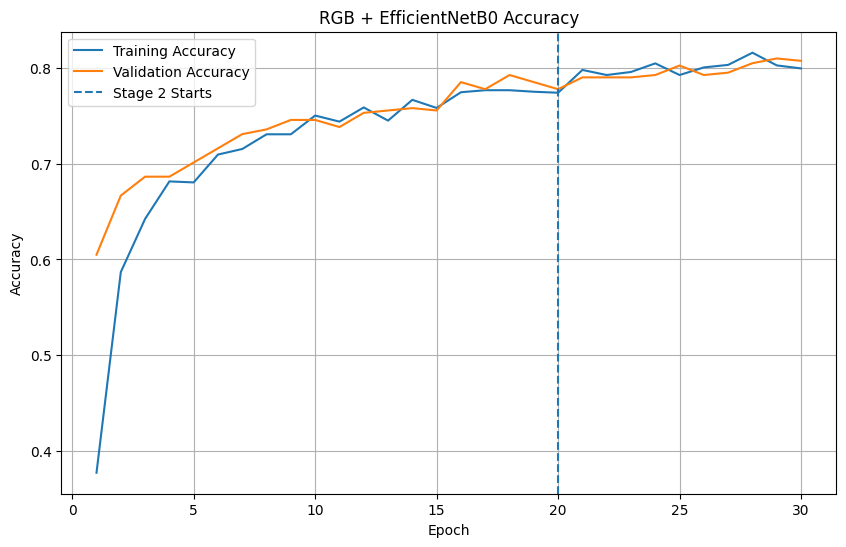

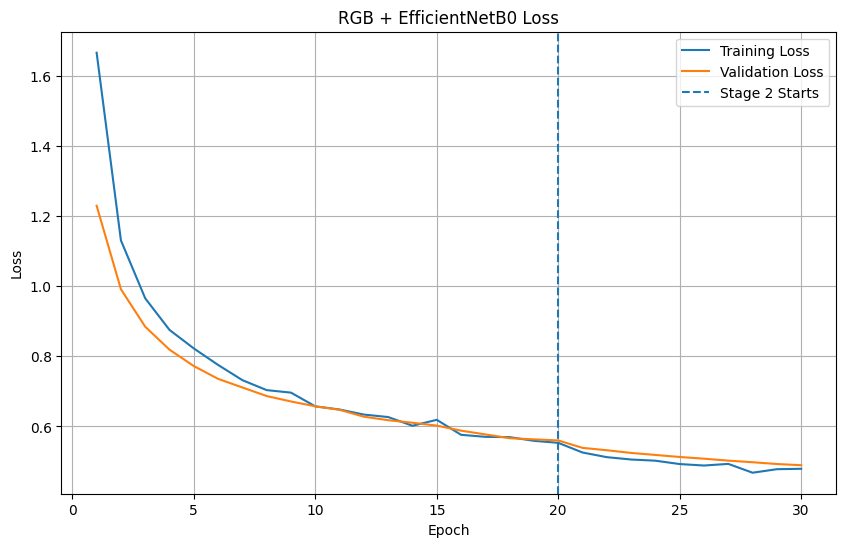


MODEL SAVED
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/RGB_312/RGB_EfficientNetB0_Controlled_FT/RGB_EfficientNetB0_312x312_Dropout03_StableFT.keras

FINAL RGB + EFFICIENTNETB0 RESULTS
Model                Accuracy        Macro F1        MCC            
-----------------------------------------------------------------
EfficientNetB0       0.8000          0.7986          0.7754         


In [1]:
import os 
import numpy as np 
import tensorflow as tf 
import matplotlib.pyplot as plt 
 
from tensorflow.keras import layers, models 
from tensorflow.keras.applications import EfficientNetB0 
from tensorflow.keras.layers import BatchNormalization 
 
 
from sklearn.metrics import ( accuracy_score, f1_score, matthews_corrcoef, confusion_matrix, classification_report) 
 
BASE_ROOT = ( "/home/mtech_atul/atul/" "Early_Output-20260923T172757Z-1-001/" "Early_Output" )  
  
  
TRAIN_DIR = os.path.join(  
    BASE_ROOT,  
    "Train_256"  
)  
  
  
VAL_DIR = os.path.join(  
    BASE_ROOT,  
    "Val_resized312"  
)  
  
  
TEST_DIR = os.path.join(  
    BASE_ROOT,  
    "Test_resized312"  
)  
  
  
# OUTPUT DIRECTORY  
OUTPUT_DIR = os.path.join(  
    BASE_ROOT,  
    "RGB_312",  
    "RGB_EfficientNetB0_Controlled_FT"  
)  
  
  
os.makedirs(  
    OUTPUT_DIR,  
    exist_ok=True  
) 
 
 
classes = [ 
 
    "ashgourd_fresh", 
    "ashgourd_nitrogen", 
    "ashgourd_potassium", 
    "bittergourd_fresh", 
    "bittergourd_nitrogen", 
    "bittergourd_potassium", 
    "snakegourd_fresh", 
    "snakegourd_nitrogen", 
    "snakegourd_potassium" 
 
] 
 
num_classes = len(classes) 
print("\nNumber of classes:", num_classes) 
 
IMG_SIZE = (312, 312) 
BATCH_SIZE = 32 
DROPOUT_RATE = 0.2
 
print("\nImage size:", IMG_SIZE) 
print("Batch size:", BATCH_SIZE) 
print("Dropout:", DROPOUT_RATE) 
 
 
print("\n======================================") 
print(" TRAIN DATASET") 
print("======================================") 
 
train_ds = tf.keras.utils.image_dataset_from_directory( 
 
    TRAIN_DIR, 
 
    labels="inferred", 
 
    label_mode="categorical", 
 
    class_names=classes, 
 
    image_size=IMG_SIZE, 
 
    batch_size=BATCH_SIZE, 
 
    shuffle=True, 
 
    seed=42 
 
) 
 
 
print("\n======================================") 
print(" VALIDATION DATASET") 
print("======================================") 
 
val_ds = tf.keras.utils.image_dataset_from_directory( 
 
    VAL_DIR, 
 
    labels="inferred", 
 
    label_mode="categorical", 
 
    class_names=classes, 
 
    image_size=IMG_SIZE, 
 
    batch_size=BATCH_SIZE, 
 
    shuffle=False 
 
) 
 
print("\n======================================") 
print(" TEST DATASET") 
print("======================================") 
 
test_ds = tf.keras.utils.image_dataset_from_directory( 
 
    TEST_DIR, 
 
    labels="inferred", 
 
    label_mode="categorical", 
 
    class_names=classes, 
 
    image_size=IMG_SIZE, 
 
    batch_size=BATCH_SIZE, 
 
    shuffle=False 
 
) 
 
 
print("EFFICIENTNETB0 PREPROCESSING") 
print("RGB input: [0,255]") 
 
# PREFETCH DATA 
train_ds = train_ds.prefetch( tf.data.AUTOTUNE) 
 
val_ds = val_ds.prefetch(tf.data.AUTOTUNE) 
 
test_ds = test_ds.prefetch(tf.data.AUTOTUNE) 
 
 
# CREATE EFFICIENTNETB0 MODEL 
def create_efficientnet_model(): 
  
    base_model = EfficientNetB0( weights="imagenet", include_top=False, input_shape=( IMG_SIZE[0], IMG_SIZE[1], 3)) 
 
    # Freeze entire EfficientNetB0 
    base_model.trainable = False 
 
    # Build complete model 
    model = models.Sequential([ 
 
            layers.Input(shape=( IMG_SIZE[0], IMG_SIZE[1], 3),name="rgb_input"), 
 
            base_model, layers.GlobalAveragePooling2D(name="global_average_pooling2d"), layers.Dropout( DROPOUT_RATE, name="dropout"), 
 
            # 9-class classifier 
            layers.Dense( num_classes, activation="softmax", name="classification")],name="RGB_EfficientNetB0") 
 
    return model, base_model 
 
 
print("\n============================") 
print("CREATING RGB + EFFICIENTNETB0") 
print("==============================") 
 
model, base_model = create_efficientnet_model() 
 
print("\n============") 
print("MODEL SUMMARY") 
print("============\n") 
 
model.summary() 
 
print("\n===================") 
print("RGB + EFFICIENTNETB0") 
print("STAGE 1") 
print("LEARNING RATE = 1e-3") 
print("===================\n") 
 
 
model.compile( 
 
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss="categorical_crossentropy", metrics=["accuracy"]) 
 
 
 
# TRAIN STAGE 1 
history1 = model.fit( train_ds, validation_data=val_ds, epochs=20, verbose=1) 
 
 
 
# STAGE 2 STABLE FINE-TUNING 
 
print("\n============================") 
print("RGB + EFFICIENTNETB0") 
print("STAGE 2") 
print("STABLE FINE-TUNING") 
print("INITIAL LEARNING RATE = 5e-6") 
print("=============================\n") 
 
base_model.trainable = True 
 
# FINE-TUNE ONLY LAST 30 LAYERS 
fine_tune_at = len(base_model.layers) - 30 
 
 
for layer_index, layer in enumerate(base_model.layers): 
 
    if layer_index < fine_tune_at: 
 
        # Freeze earlier layers 
        layer.trainable = False 
 
    else: 
 
        # Unfreeze last 30 layers 
        layer.trainable = True 
 
 
 
# KEEP BATCH NORMALIZATION LAYERS FROZEN 
for layer in base_model.layers: 
 
    if isinstance(layer, BatchNormalization): 
 
        layer.trainable = False 
 
 
 
# COUNT TRAINABLE / FROZEN LAYERS 
 
trainable_layers = 0 
frozen_layers = 0 
 
 
for layer in base_model.layers: 
 
    if layer.trainable: 
        trainable_layers += 1 
 
    else: 
        frozen_layers += 1 
 
 
print("\nEfficientNetB0 fine-tuning configuration:") 
 
print( "Trainable layers:", trainable_layers) 
 
print( "Frozen layers:", frozen_layers) 
 
print( "Fine-tuning from layer:", fine_tune_at) 
 
 
 
# RECOMPILE MODEL for 2nd stage of training 
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),loss="categorical_crossentropy",metrics=["accuracy"]) 
 
 
# REDUCE LEARNING RATE ON PLATEAU 
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau( monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7, verbose=1) 
 
 
# TRAIN STAGE 2 
history2 = model.fit( train_ds, validation_data=val_ds, epochs=10, verbose=1, callbacks=[reduce_lr]) 
 
 
 
# TEST MODEL 
print("\n===================") 
print("RGB + EFFICIENTNETB0") 
print("TESTING") 
print("===================\n") 
 
 
test_loss, test_accuracy = model.evaluate(test_ds,verbose=1) 
 
 
# GENERATE PREDICTIONS 
print("\n=====================") 
print("GENERATING PREDICTIONS") 
print("======================\n") 
 
predictions = model.predict( test_ds, verbose=1) 
 
 
 
# PREDICTED LABELS 
y_pred = np.argmax( predictions, axis=1) 
 
 
 
# TRUE LABELS 
y_true = [] 
 
 
for images, labels in test_ds: 
 
    labels = labels.numpy() 
 
    labels = np.argmax(labels,axis=1) 
 
    y_true.extend(labels) 
 
y_true = np.array(y_true) 
 
 
 
# CALCULATE METRICS 
accuracy = accuracy_score(y_true,y_pred) 
 
macro_f1 = f1_score( y_true, y_pred, average="macro") 
 
mcc = matthews_corrcoef( y_true, y_pred) 
 
 
 
# FINAL TEST RESULTS 
 
 
print("\n=================") 
print("RGB + EFFICIENTNETB0") 
print("FINAL TEST RESULTS") 
print("====================") 
 
print( "Test Loss :", test_loss) 
 
print( "Accuracy  :", accuracy) 
 
print( "Macro F1  :", macro_f1) 
 
print( "MCC       :", mcc) 
 
 
 
# CLASSIFICATION REPORT 
 
 
print("\n====================") 
print("RGB + EFFICIENTNETB0") 
print("CLASSIFICATION REPORT") 
print("====================\n") 
 
 
print(classification_report( y_true, y_pred, target_names=classes)) 
 
 
# CONFUSION MATRIX 
 
 
cm = confusion_matrix( y_true, y_pred) 
plt.figure(figsize=(10, 8)) 
plt.imshow(cm) 
plt.title("RGB + EfficientNetB0 Confusion Matrix") 
 
plt.xlabel( "Predicted Class") 
plt.ylabel( "Actual Class") 
plt.colorbar() 
 
 
plt.xticks( np.arange(num_classes), classes, rotation=90 
) 
 
 
plt.yticks( np.arange(num_classes), classes) 
 
 
for i in range(num_classes): 
 
    for j in range(num_classes): 
 
        plt.text( j, i,  cm[i, j], ha="center",  va="center") 
 
plt.tight_layout() 
plt.show() 
 
 
 
# COMBINE TRAINING HISTORY 
train_accuracy = ( history1.history["accuracy"] + history2.history["accuracy"]) 
 
 
val_accuracy = ( history1.history["val_accuracy"] + history2.history["val_accuracy"]) 
 
 
train_loss = ( history1.history["loss"] + history2.history["loss"]) 
 
 
val_loss = (history1.history["val_loss"]+history2.history["val_loss"]) 
 
 
# ACCURACY PLOT 
plt.figure(figsize=(10, 6)) 
epochs_range = range(1,len(train_accuracy) + 1) 
plt.plot( epochs_range, train_accuracy, label="Training Accuracy") 
plt.plot( epochs_range, val_accuracy, label="Validation Accuracy") 
 
 
plt.axvline( x=20, linestyle="--", label="Stage 2 Starts") 
plt.title("RGB + EfficientNetB0 Accuracy") 
 
plt.xlabel("Epoch") 
plt.ylabel("Accuracy") 
plt.legend() 
plt.grid() 
plt.show() 
 
 
 
# LOSS PLOT 
plt.figure(figsize=(10, 6)) 
plt.plot(epochs_range,train_loss,label="Training Loss") 
plt.plot( epochs_range, val_loss, label="Validation Loss") 
 
 
plt.axvline( x=20, linestyle="--", label="Stage 2 Starts") 
plt.title("RGB + EfficientNetB0 Loss") 
plt.xlabel("Epoch") 
plt.ylabel("Loss") 
plt.legend() 
plt.grid() 
plt.show() 
 
 
# SAVE MODEL
save_path = os.path.join(
    OUTPUT_DIR,
    "RGB_EfficientNetB0_312x312_Dropout03_StableFT.keras"
)
 
 
model.save(save_path) 
 
print("\n======================================") 
print("MODEL SAVED") 
print("======================================") 
 
print(save_path) 
 
# FINAL SUMMARY 
print("\n======================================") 
print("FINAL RGB + EFFICIENTNETB0 RESULTS") 
print("======================================") 
 
print("{:<20} {:<15} {:<15} {:<15}".format( "Model", "Accuracy", "Macro F1", "MCC")) 
print("-" * 65) 
print("{:<20} {:<15.4f} {:<15.4f} {:<15.4f}".format( "EfficientNetB0",  accuracy, macro_f1,  mcc))

In [2]:
def predict_early_nutrient_stress(image_path):

    print("\n==============================================")
    print("EARLY NUTRIENT STRESS DETECTION")
    print("==============================================")

    image = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    image_array = tf.keras.utils.img_to_array(
        image
    )

    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    probabilities = model.predict(
        image_array,
        verbose=0
    )[0]

    predicted_index = np.argmax(
        probabilities
    )

    predicted_class = classes[
        predicted_index
    ]

    confidence = (
        probabilities[predicted_index] * 100
    )

    actual_class = os.path.basename(
        os.path.dirname(image_path)
    )

    print("\nImage:")
    print(image_path)

    print("\nActual Class:")
    print(actual_class)

    print("\nPredicted Class:")
    print(predicted_class)

    print("\nConfidence:")
    print(f"{confidence:.2f}%")

    if predicted_class == actual_class:

        print("\nPrediction:")
        print("CORRECT")

    else:

        print("\nPrediction:")
        print("INCORRECT")

    if "nitrogen" in predicted_class:

        print("\nEARLY NUTRIENT STRESS:")
        print("Nitrogen deficiency class detected.")

    elif "potassium" in predicted_class:

        print("\nEARLY NUTRIENT STRESS:")
        print("Potassium deficiency class detected.")

    elif "fresh" in predicted_class:

        print("\nEARLY NUTRIENT STRESS:")
        print("No nutrient-deficiency class detected.")

    print("\n----------------------------------------------")
    print("ALL CLASS PROBABILITIES")
    print("----------------------------------------------")

    for i, class_name in enumerate(classes):

        print(
            f"{class_name:<25}"
            f"{probabilities[i] * 100:.2f}%"
        )

    return (
        actual_class,
        predicted_class,
        confidence,
        probabilities
    )


image_path = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/Test_resized312/"
    "snakegourd_potassium/RGB (115).JPG"
)

predict_early_nutrient_stress(
    image_path
)


EARLY NUTRIENT STRESS DETECTION

Image:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Test_resized312/snakegourd_potassium/RGB (115).JPG

Actual Class:
snakegourd_potassium

Predicted Class:
snakegourd_potassium

Confidence:
97.64%

Prediction:
CORRECT

EARLY NUTRIENT STRESS:
Potassium deficiency class detected.

----------------------------------------------
ALL CLASS PROBABILITIES
----------------------------------------------
ashgourd_fresh           0.00%
ashgourd_nitrogen        0.00%
ashgourd_potassium       0.00%
bittergourd_fresh        0.00%
bittergourd_nitrogen     0.00%
bittergourd_potassium    0.00%
snakegourd_fresh         0.58%
snakegourd_nitrogen      1.77%
snakegourd_potassium     97.64%


('snakegourd_potassium',
 'snakegourd_potassium',
 np.float32(97.63739),
 array([6.0355546e-07, 4.2504977e-05, 1.8964367e-05, 3.8215657e-07,
        2.9442010e-06, 1.1142221e-05, 5.8448813e-03, 1.7704690e-02,
        9.7637391e-01], dtype=float32))

## Early nutrient stress

In [3]:

# IMAGE → CROP + CONDITION PREDICTION


image_path = (
     "/home/mtech_atul/atul/"
       "Early_Output-20260923T172757Z-1-001/"
       "Early_Output/Test_resized312/"
       "snakegourd_potassium/RGB (115).JPG"
)


image = tf.keras.utils.load_img(
    image_path,
    target_size=IMG_SIZE
)

image_array = tf.keras.utils.img_to_array(
    image
)

image_array = np.expand_dims(
    image_array,
    axis=0
)


# CNN PREDICTION
probabilities = model.predict(
    image_array,
    verbose=0
)[0]


# CROP PROBABILITIES
ashgourd = np.sum(
    probabilities[0:3]
)

bittergourd = np.sum(
    probabilities[3:6]
)

snakegourd = np.sum(
    probabilities[6:9]
)

crop_probs = {
    "ashgourd": ashgourd,
    "bittergourd": bittergourd,
    "snakegourd": snakegourd
}

predicted_crop = max(
    crop_probs,
    key=crop_probs.get
)


# CONDITION PROBABILITIES
start = {
    "ashgourd": 0,
    "bittergourd": 3,
    "snakegourd": 6
}[predicted_crop]

fresh = probabilities[start]
nitrogen = probabilities[start + 1]
potassium = probabilities[start + 2]

condition_probs = {
    "fresh": fresh,
    "nitrogen": nitrogen,
    "potassium": potassium
}

predicted_condition = max(
    condition_probs,
    key=condition_probs.get
)


# RESULTS
print("\n" + "=" * 55)
print("LEAF CLASSIFICATION RESULT")
print("=" * 55)

print("\nImage:")
print(image_path)

print("\nCROP PROBABILITIES")
print("-" * 55)

print(f"Ashgourd    : {ashgourd * 100:.2f}%")

print(f"Bittergourd : {bittergourd * 100:.2f}%")

print(f"Snakegourd  : {snakegourd * 100:.2f}%")

print(f"\nPredicted Crop: {predicted_crop.upper()}")

print("\nCONDITION PROBABILITIES")
print("-" * 55)

print(f"Fresh      : {fresh * 100:.2f}%")

print(f"Nitrogen   : {nitrogen * 100:.2f}%")

print(f"Potassium  : {potassium * 100:.2f}%")

print("\nFINAL RESULT")
print("-" * 55)

print(f"Crop      : {predicted_crop.upper()}")

print(f"Condition : {predicted_condition.upper()}")

print(f"Final Class: "f"{predicted_crop}_{predicted_condition}")



LEAF CLASSIFICATION RESULT

Image:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Test_resized312/snakegourd_potassium/RGB (115).JPG

CROP PROBABILITIES
-------------------------------------------------------
Ashgourd    : 0.01%
Bittergourd : 0.00%
Snakegourd  : 99.99%

Predicted Crop: SNAKEGOURD

CONDITION PROBABILITIES
-------------------------------------------------------
Fresh      : 0.58%
Nitrogen   : 1.77%
Potassium  : 97.64%

FINAL RESULT
-------------------------------------------------------
Crop      : SNAKEGOURD
Condition : POTASSIUM
Final Class: snakegourd_potassium


## RGB -- DenceNet

## Modified RGB --- DenceNet


Number of classes: 9

Image size: (312, 312)
Batch size: 32
Dropout: 0.2

LOADING TRAIN DATASET
Found 1890 files belonging to 9 classes.

 VALIDATION DATASET
Found 405 files belonging to 9 classes.

 TEST DATASET
Found 405 files belonging to 9 classes.

DENSENET121 NORMALIZATION
RGB input range: [0,255]

CREATING RGB + DENSENET121

MODEL SUMMARY



Model: "RGB_DenseNet121"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121_normalization       │ (None, 312, 312, 3)    │             0 │
│ (Lambda)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 9, 9, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 9)              │         9,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,046,729 (26.88 MB)

 Trainable params: 9,225 (36.04 KB)

 Non-trainable params: 7,037,504 (26.85 MB)


RGB + DENSENET121
STAGE 1
LEARNING RATE = 1e-3

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 61s 903ms/step - accuracy: 0.2905 - loss: 1.8753 - val_accuracy: 0.5877 - val_loss: 1.2703
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 51s 846ms/step - accuracy: 0.5323 - loss: 1.2238 - val_accuracy: 0.6296 - val_loss: 1.0203
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 51s 847ms/step - accuracy: 0.5937 - loss: 1.0242 - val_accuracy: 0.6840 - val_loss: 0.8949
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 50s 839ms/step - accuracy: 0.6370 - loss: 0.9189 - val_accuracy: 0.6889 - val_loss: 0.8376
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 51s 845ms/step - accuracy: 0.6714 - loss: 0.8323 - val_accuracy: 0.7037 - val_loss: 0.7862
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 50s 839ms/step - accuracy: 0.7101 - loss: 0.7830 - val_accuracy: 0.7210 - val_loss: 0.7688
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 50s 842ms/step - accuracy: 0.7190 - loss: 0.7490 - val_accuracy: 0.6914 - val_loss: 0.7345
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 51s 851ms/

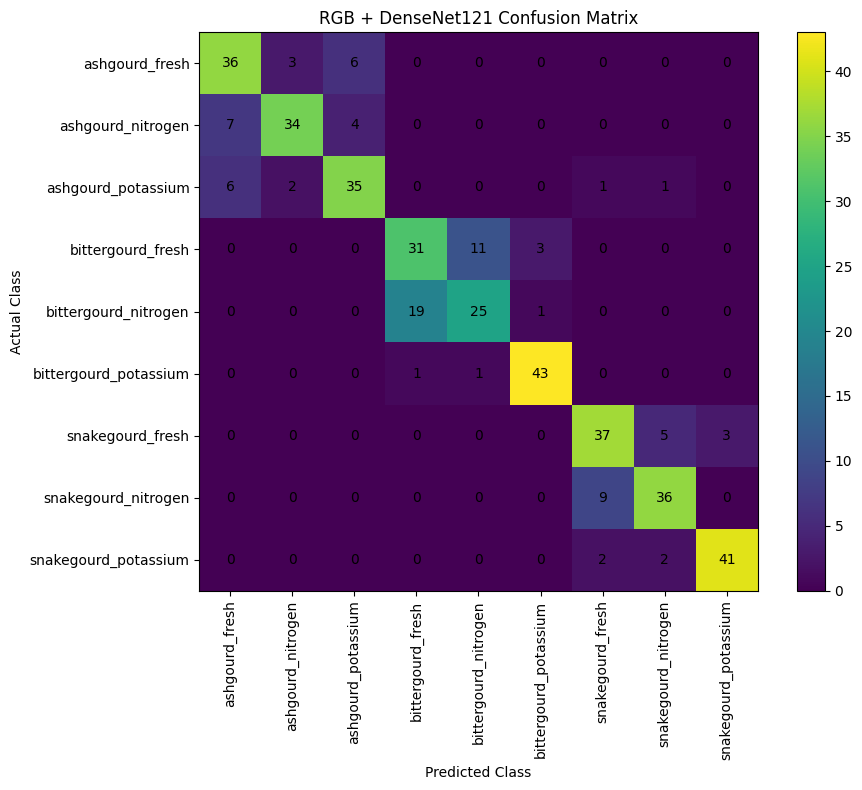

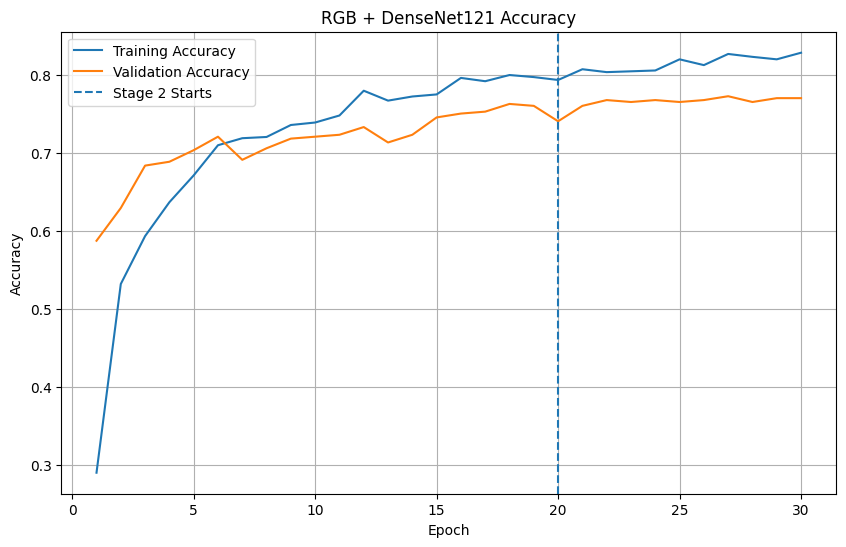

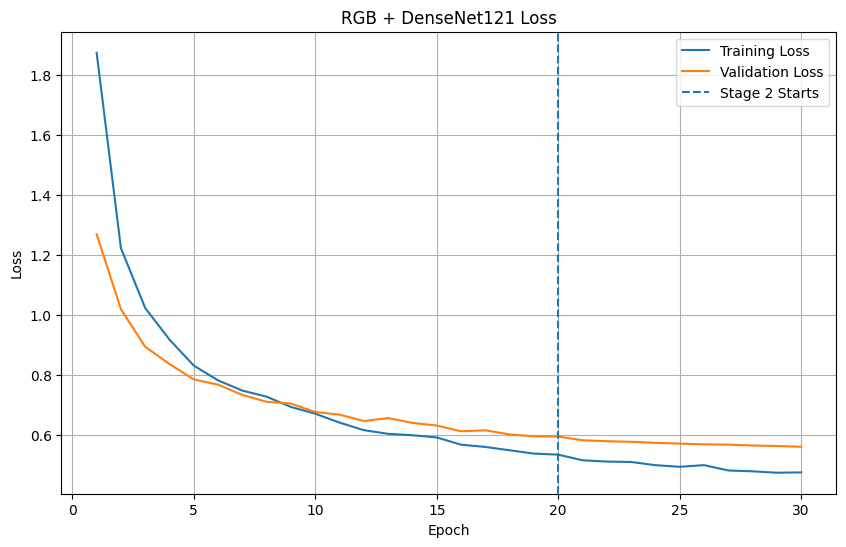


MODEL SAVED
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/RGB_312/RGB_DenseNet121_Controlled_FT/RGB_DenseNet121_312x312_Dropout02_Normalized_StableFT.keras

FINAL RGB + DENSENET121 RESULTS
Model                Accuracy        Macro F1        MCC            
DenseNet121          0.7852          0.7846          0.7588         


In [4]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import (preprocess_input)
from tensorflow.keras.layers import BatchNormalization

from sklearn.metrics import ( accuracy_score, f1_score, matthews_corrcoef, confusion_matrix, classification_report)


BASE_ROOT = ( "/home/mtech_atul/atul/" "Early_Output-20260923T172757Z-1-001/" "Early_Output" )


TRAIN_DIR = os.path.join(
    BASE_ROOT,
    "Train_256"
)


VAL_DIR = os.path.join(
    BASE_ROOT,
    "Val_resized312"
)


TEST_DIR = os.path.join(
    BASE_ROOT,
    "Test_resized312"
)


OUTPUT_DIR = os.path.join(
    BASE_ROOT,
    "RGB_312",
    "RGB_DenseNet121_Controlled_FT"
)


os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# CLASS NAMES
classes = [

    "ashgourd_fresh",
    "ashgourd_nitrogen",
    "ashgourd_potassium",

    "bittergourd_fresh",
    "bittergourd_nitrogen",
    "bittergourd_potassium",

    "snakegourd_fresh",
    "snakegourd_nitrogen",
    "snakegourd_potassium"

]


num_classes = len(classes)

print("\nNumber of classes:", num_classes)


IMG_SIZE = (312, 312)
BATCH_SIZE = 32
DROPOUT_RATE = 0.2

print("\nImage size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Dropout:", DROPOUT_RATE)


print("\n===================")
print("LOADING TRAIN DATASET")
print("=====================")

train_ds = tf.keras.utils.image_dataset_from_directory(

    TRAIN_DIR,

    labels="inferred",

    label_mode="categorical",

    class_names=classes,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=42

)


print("\n==================")
print(" VALIDATION DATASET")
print("====================")

val_ds = tf.keras.utils.image_dataset_from_directory(

    VAL_DIR,

    labels="inferred",

    label_mode="categorical",

    class_names=classes,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False

)


print("\n============")
print(" TEST DATASET")
print("==============")

test_ds = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    labels="inferred",

    label_mode="categorical",

    class_names=classes,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False

)


print("\n========================")
print("DENSENET121 NORMALIZATION")
print("==========================")
print("RGB input range: [0,255]")



# PREFETCH DATA


train_ds = train_ds.prefetch(

    tf.data.AUTOTUNE

)

val_ds = val_ds.prefetch(

    tf.data.AUTOTUNE

)

test_ds = test_ds.prefetch(

    tf.data.AUTOTUNE

)



# CREATE DENSENET121 MODEL


def create_densenet_model():
    base_model = DenseNet121(

        weights="imagenet",

        include_top=False,

        input_shape=( IMG_SIZE[0], IMG_SIZE[1], 3))



    # Freeze entire DenseNet121 for Stage 1
    base_model.trainable = False

    # Build complete model
    model = models.Sequential(

        [

            layers.Input(

                shape=( IMG_SIZE[0], IMG_SIZE[1], 3),name="rgb_input"),

            # DenseNet121 normalization
            layers.Lambda( preprocess_input, name="densenet121_normalization"),base_model,

            layers.GlobalAveragePooling2D(name="global_average_pooling2d"),

            layers.Dropout( DROPOUT_RATE, name="dropout"),

            layers.Dense( num_classes, activation="softmax", name="classification")],name="RGB_DenseNet121")

    return model, base_model


print("\n==========================")
print("CREATING RGB + DENSENET121")
print("============================")

model, base_model = create_densenet_model()



# MODEL SUMMARY


print("\n=============")
print("MODEL SUMMARY")
print("=============\n")

model.summary()


print("\n======================================")
print("RGB + DENSENET121")
print("STAGE 1")
print("LEARNING RATE = 1e-3")
print("======================================\n")


model.compile(

    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),loss="categorical_crossentropy",metrics=[ "accuracy"])



# TRAIN STAGE 1


history1 = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=20,

    verbose=1

)



# STAGE 2
# STABLE FINE-TUNING


print("\n======================================")
print("RGB + DENSENET121")
print("STAGE 2")
print("STABLE FINE-TUNING")
print("INITIAL LEARNING RATE = 5e-6")
print("======================================\n")

base_model.trainable = True


# FINE-TUNE ONLY LAST 30 LAYERS
fine_tune_at = len(base_model.layers) - 30


for layer_index, layer in enumerate(base_model.layers):

    if layer_index < fine_tune_at:

        # Freeze earlier layers
        layer.trainable = False

    else:

        # Unfreeze last 30 layers
        layer.trainable = True


# Normalization
for layer in base_model.layers:

    if isinstance(layer, BatchNormalization):

        layer.trainable = False



# COUNT TRAINABLE / FROZEN LAYERS


trainable_layers = 0
frozen_layers = 0


for layer in base_model.layers:

    if layer.trainable:

        trainable_layers += 1

    else:

        frozen_layers += 1


print("\nDenseNet121 fine-tuning configuration:")

print(
    "Trainable layers:",
    trainable_layers
)

print(
    "Frozen layers:",
    frozen_layers
)

print(
    "Fine-tuning from layer:",
    fine_tune_at
)


# RECOMPILE MODEL
model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=5e-6

    ),

    loss="categorical_crossentropy",

    metrics=[

        "accuracy"

    ]

)



# REDUCE LEARNING RATE ON PLATEAU


reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=2,

    min_lr=1e-7,

    verbose=1

)



# TRAIN STAGE 2


history2 = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=10,

    verbose=1,

    callbacks=[

        reduce_lr

    ]

)



# TEST MODEL
print("RGB + DENSENET121 ---> TESTING")

test_loss, test_accuracy = model.evaluate(

    test_ds,

    verbose=1

)



# GENERATE PREDICTIONS


print("\n======================================")
print("GENERATING PREDICTIONS")
print("======================================\n")


predictions = model.predict(

    test_ds,

    verbose=1

)



# PREDICTED LABELS


y_pred = np.argmax(

    predictions,

    axis=1

)



# TRUE LABELS


y_true = []


for images, labels in test_ds:

    labels = labels.numpy()

    labels = np.argmax(

        labels,

        axis=1

    )

    y_true.extend(labels)


y_true = np.array(y_true)



# CALCULATE METRICS


accuracy = accuracy_score(

    y_true,

    y_pred

)


macro_f1 = f1_score(

    y_true,

    y_pred,

    average="macro"

)


mcc = matthews_corrcoef(

    y_true,

    y_pred

)



# FINAL TEST RESULTS
print("RGB + DENSENET121   FINAL TEST RESULTS")



print(

    "Test Loss :",

    test_loss

)

print(

    "Accuracy  :",

    accuracy

)

print(

    "Macro F1  :",

    macro_f1

)

print(

    "MCC       :",

    mcc

)



# CLASSIFICATION REPORT
print("RGB + DENSENET121   CLASSIFICATION REPORT")



print(

    classification_report(

        y_true,

        y_pred,

        target_names=classes

    )

)



# CONFUSION MATRIX


cm = confusion_matrix(

    y_true,

    y_pred

)


plt.figure(

    figsize=(10, 8)

)


plt.imshow(cm)


plt.title(

    "RGB + DenseNet121 Confusion Matrix"

)


plt.xlabel(

    "Predicted Class"

)


plt.ylabel(

    "Actual Class"

)


plt.colorbar()


plt.xticks(

    np.arange(num_classes),

    classes,

    rotation=90

)


plt.yticks(

    np.arange(num_classes),

    classes

)


for i in range(num_classes):

    for j in range(num_classes):

        plt.text(

            j,

            i,

            cm[i, j],

            ha="center",

            va="center"

        )


plt.tight_layout()

plt.show()



# COMBINE TRAINING HISTORY


train_accuracy = (

    history1.history["accuracy"]

    +

    history2.history["accuracy"]

)


val_accuracy = (

    history1.history["val_accuracy"]

    +

    history2.history["val_accuracy"]

)


train_loss = (

    history1.history["loss"]

    +

    history2.history["loss"]

)


val_loss = (

    history1.history["val_loss"]

    +

    history2.history["val_loss"]

)



# ACCURACY PLOT


plt.figure(

    figsize=(10, 6)

)


epochs_range = range(

    1,

    len(train_accuracy) + 1

)


plt.plot(

    epochs_range,

    train_accuracy,

    label="Training Accuracy"

)


plt.plot(

    epochs_range,

    val_accuracy,

    label="Validation Accuracy"

)


plt.axvline(

    x=20,

    linestyle="--",

    label="Stage 2 Starts"

)


plt.title(

    "RGB + DenseNet121 Accuracy"

)


plt.xlabel(

    "Epoch"

)


plt.ylabel(

    "Accuracy"

)


plt.legend()

plt.grid()

plt.show()



# LOSS PLOT


plt.figure(

    figsize=(10, 6)

)


plt.plot(

    epochs_range,

    train_loss,

    label="Training Loss"

)


plt.plot(

    epochs_range,

    val_loss,

    label="Validation Loss"

)


plt.axvline(

    x=20,

    linestyle="--",

    label="Stage 2 Starts"

)


plt.title(

    "RGB + DenseNet121 Loss"

)


plt.xlabel(

    "Epoch"

)


plt.ylabel(

    "Loss"

)


plt.legend()

plt.grid()

plt.show()



# SAVE MODEL


save_path = os.path.join(
    OUTPUT_DIR,
    "RGB_DenseNet121_312x312_Dropout02_Normalized_StableFT.keras"
)


model.save(

    save_path

)


print("\n======================================")
print("MODEL SAVED")
print("======================================")

print(save_path)


# FINAL SUMMARY
print("\n======================================")
print("FINAL RGB + DENSENET121 RESULTS")
print("======================================")

print("{:<20} {:<15} {:<15} {:<15}".format( "Model", "Accuracy", "Macro F1", "MCC"))

print("{:<20} {:<15.4f} {:<15.4f} {:<15.4f}".format( "DenseNet121", accuracy, macro_f1, mcc))

In [7]:
def predict_early_nutrient_stress(image_path):

    print("\n==============================================")
    print("EARLY NUTRIENT STRESS DETECTION")
    print("==============================================")

    image = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    image_array = tf.keras.utils.img_to_array(
        image
    )

    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    probabilities = model.predict(
        image_array,
        verbose=0
    )[0]

    predicted_index = np.argmax(
        probabilities
    )

    predicted_class = classes[
        predicted_index
    ]

    confidence = (
        probabilities[predicted_index] * 100
    )

    actual_class = os.path.basename(
        os.path.dirname(image_path)
    )

    print("\nImage:")
    print(image_path)

    print("\nActual Class:")
    print(actual_class)

    print("\nPredicted Class:")
    print(predicted_class)

    print("\nConfidence:")
    print(f"{confidence:.2f}%")

    if predicted_class == actual_class:

        print("\nPrediction:")
        print("CORRECT")

    else:

        print("\nPrediction:")
        print("INCORRECT")

    if "nitrogen" in predicted_class:

        print("\nEARLY NUTRIENT STRESS:")
        print("Nitrogen deficiency class detected.")

    elif "potassium" in predicted_class:

        print("\nEARLY NUTRIENT STRESS:")
        print("Potassium deficiency class detected.")

    elif "fresh" in predicted_class:

        print("\nEARLY NUTRIENT STRESS:")
        print("No nutrient-deficiency class detected.")

    print("\n----------------------------------------------")
    print("ALL CLASS PROBABILITIES")
    print("----------------------------------------------")

    for i, class_name in enumerate(classes):

        print(
            f"{class_name:<25}"
            f"{probabilities[i] * 100:.2f}%"
        )

    return (
        actual_class,
        predicted_class,
        confidence,
        probabilities
    )


image_path = ("/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Test_resized312/snakegourd_nitrogen/RGB (115).JPG")

predict_early_nutrient_stress(
    image_path
)


EARLY NUTRIENT STRESS DETECTION

Image:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Test_resized312/snakegourd_nitrogen/RGB (115).JPG

Actual Class:
snakegourd_nitrogen

Predicted Class:
snakegourd_nitrogen

Confidence:
88.49%

Prediction:
CORRECT

EARLY NUTRIENT STRESS:
Nitrogen deficiency class detected.

----------------------------------------------
ALL CLASS PROBABILITIES
----------------------------------------------
ashgourd_fresh           0.01%
ashgourd_nitrogen        0.06%
ashgourd_potassium       0.03%
bittergourd_fresh        0.01%
bittergourd_nitrogen     0.00%
bittergourd_potassium    0.31%
snakegourd_fresh         2.17%
snakegourd_nitrogen      88.49%
snakegourd_potassium     8.91%


('snakegourd_nitrogen',
 'snakegourd_nitrogen',
 np.float32(88.493034),
 array([1.34485468e-04, 6.30508643e-04, 3.13768571e-04, 1.02373706e-04,
        4.98976224e-05, 3.05400533e-03, 2.17311792e-02, 8.84930372e-01,
        8.90535042e-02], dtype=float32))

## Early Nutrient Stress RGB DenceNet

In [ ]:

# IMAGE → CROP + CONDITION PREDICTION

image_path = ("/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Test_resized312/snakegourd_nitrogen/RGB (115).JPG")


image = tf.keras.utils.load_img(
    image_path,
    target_size=IMG_SIZE
)

image_array = tf.keras.utils.img_to_array(
    image
)

image_array = np.expand_dims(
    image_array,
    axis=0
)


# CNN PREDICTION
probabilities = model.predict(
    image_array,
    verbose=0
)[0]


# CROP PROBABILITIES
ashgourd = np.sum(
    probabilities[0:3]
)

bittergourd = np.sum(
    probabilities[3:6]
)

snakegourd = np.sum(
    probabilities[6:9]
)

crop_probs = {
    "ashgourd": ashgourd,
    "bittergourd": bittergourd,
    "snakegourd": snakegourd
}

predicted_crop = max(
    crop_probs,
    key=crop_probs.get
)


# CONDITION PROBABILITIES
start = {
    "ashgourd": 0,
    "bittergourd": 3,
    "snakegourd": 6
}[predicted_crop]

fresh = probabilities[start]
nitrogen = probabilities[start + 1]
potassium = probabilities[start + 2]

condition_probs = {
    "fresh": fresh,
    "nitrogen": nitrogen,
    "potassium": potassium
}

predicted_condition = max(
    condition_probs,
    key=condition_probs.get
)


# RESULTS
print("\n" + "=" * 55)
print("LEAF CLASSIFICATION RESULT")
print("=" * 55)

print("\nImage:")
print(image_path)

print("\nCROP PROBABILITIES")
print("-" * 55)

print(f"Ashgourd    : {ashgourd * 100:.2f}%")

print(f"Bittergourd : {bittergourd * 100:.2f}%")

print(f"Snakegourd  : {snakegourd * 100:.2f}%")

print(f"\nPredicted Crop: {predicted_crop.upper()}")

print("\nCONDITION PROBABILITIES")
print("-" * 55)

print(f"Fresh      : {fresh * 100:.2f}%")

print(f"Nitrogen   : {nitrogen * 100:.2f}%")

print(f"Potassium  : {potassium * 100:.2f}%")

print("\nFINAL RESULT")
print("-" * 55)

print(f"Crop      : {predicted_crop.upper()}")

print(f"Condition : {predicted_condition.upper()}")

print(f"Final Class: "f"{predicted_crop}_{predicted_condition}")



LEAF CLASSIFICATION RESULT

Image:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Test_resized312/snakegourd_nitrogen/RGB (115).JPG

CROP PROBABILITIES
-------------------------------------------------------
Ashgourd    : 0.11%
Bittergourd : 0.32%
Snakegourd  : 99.57%

Predicted Crop: SNAKEGOURD

CONDITION PROBABILITIES
-------------------------------------------------------
Fresh      : 2.17%
Nitrogen   : 88.49%
Potassium  : 8.91%

FINAL RESULT
-------------------------------------------------------
Crop      : SNAKEGOURD
Condition : NITROGEN
Final Class: snakegourd_nitrogen


## Modified HSV --MobileNet


Loading training dataset...
Found 1890 files belonging to 9 classes.

Loading validation dataset...
Found 405 files belonging to 9 classes.

Loading test dataset...
Found 405 files belonging to 9 classes.

Number of classes: 9


HSV REPRESENTATION VISUALIZATION
Found 405 files belonging to 9 classes.

Sample class: ashgourd_fresh
Image size: (312, 312, 3)
HSV H range: 0 - 135
HSV S range: 0 - 255
HSV V range: 0 - 255


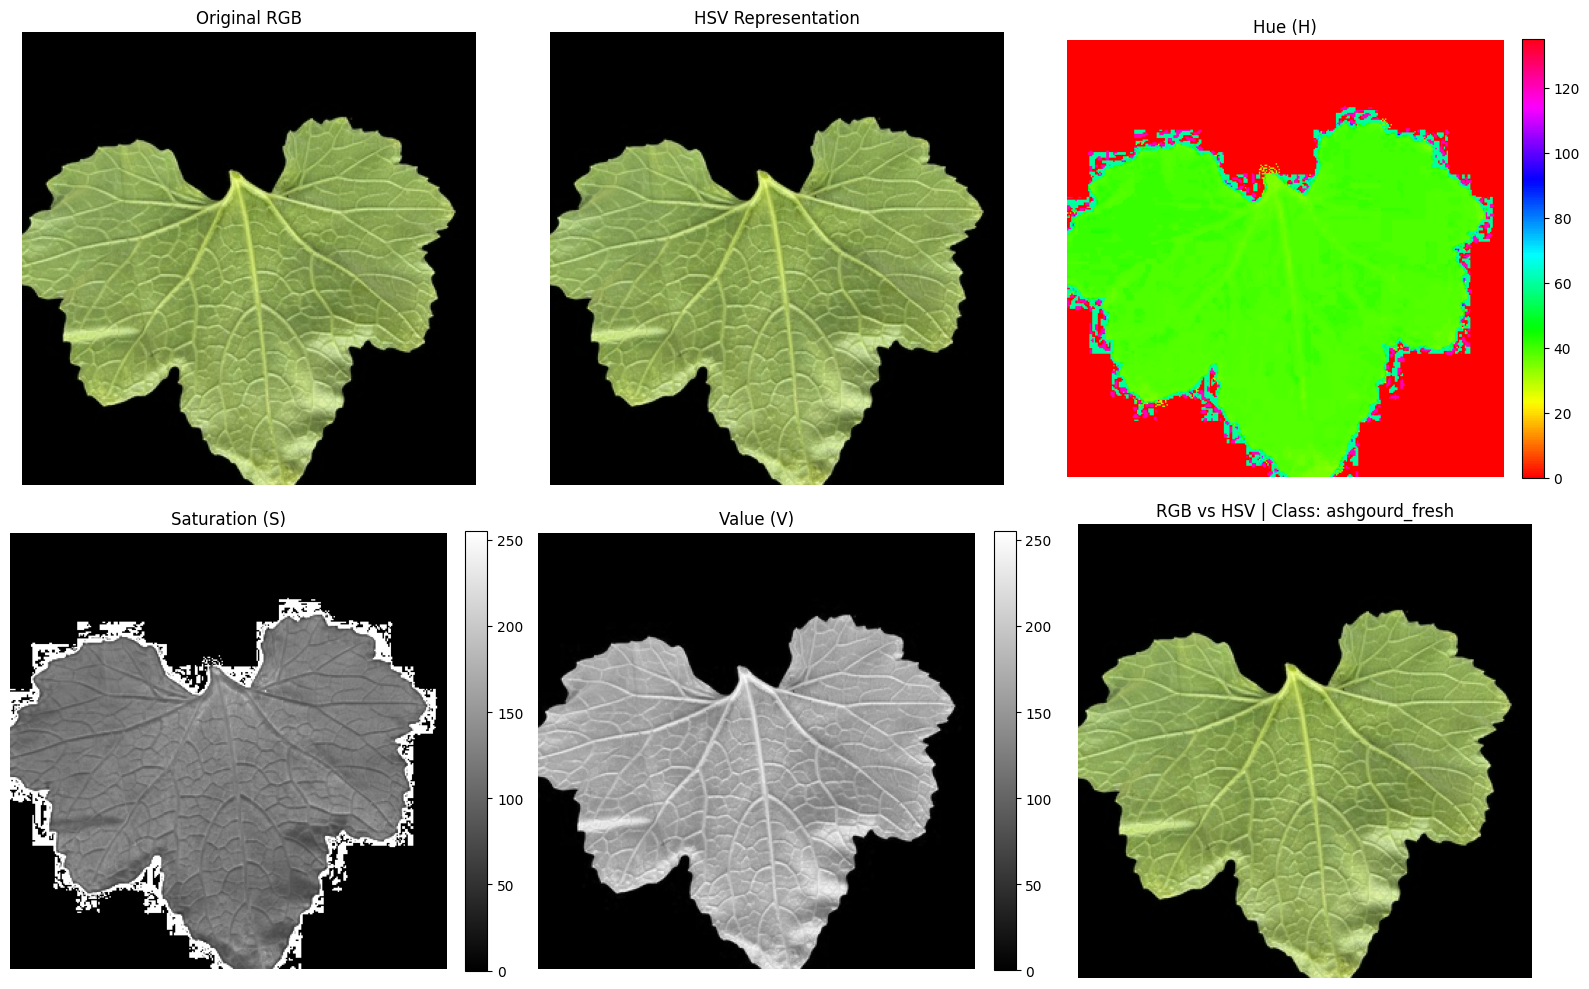


Applying HSV preprocessing...


/tmp/ipykernel_519674/2850896153.py:477: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(



Model Summary:



Model: "HSV_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 10, 10, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,513 (8.66 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)



STAGE 1: FROZEN MOBILENETV2


Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 370ms/step - accuracy: 0.3963 - loss: 1.5820 - val_accuracy: 0.5975 - val_loss: 1.1066
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 341ms/step - accuracy: 0.5979 - loss: 1.0450 - val_accuracy: 0.6222 - val_loss: 0.9342
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 340ms/step - accuracy: 0.6466 - loss: 0.9056 - val_accuracy: 0.6395 - val_loss: 0.8692
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 334ms/step - accuracy: 0.6720 - loss: 0.8190 - val_accuracy: 0.6815 - val_loss: 0.8244
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 334ms/step - accuracy: 0.7127 - loss: 0.7495 - val_accuracy: 0.7012 - val_loss: 0.7770
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 22s 353ms/step - accuracy: 0.7180 - loss: 0.7259 - val_accuracy: 0.6889 - val_loss: 0.7816
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 342ms/step - accuracy: 0.7524 - loss: 0.6601 - val_accuracy: 0.7185 - val_loss: 0.7327
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 340ms/step - accuracy: 

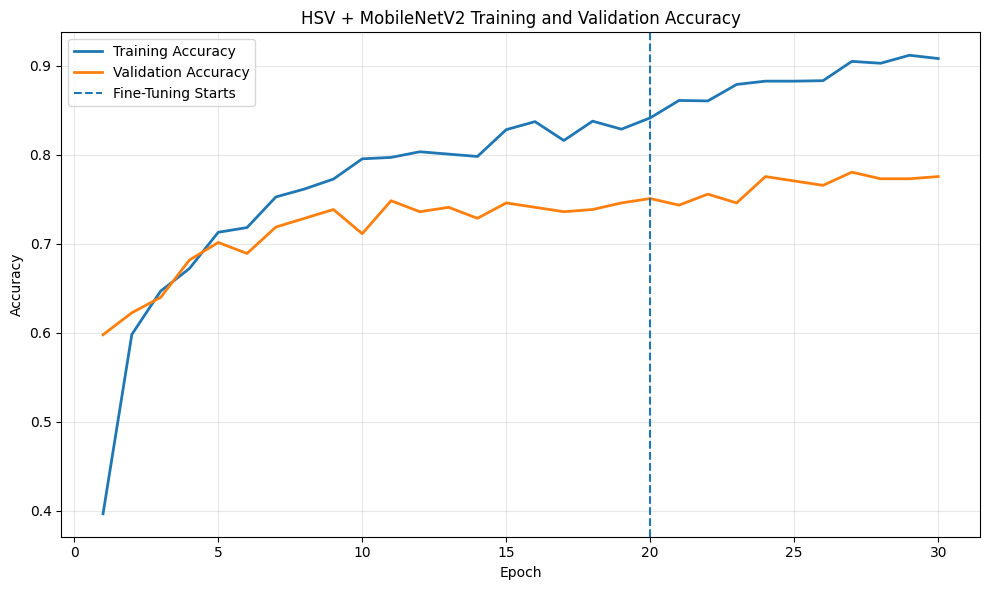

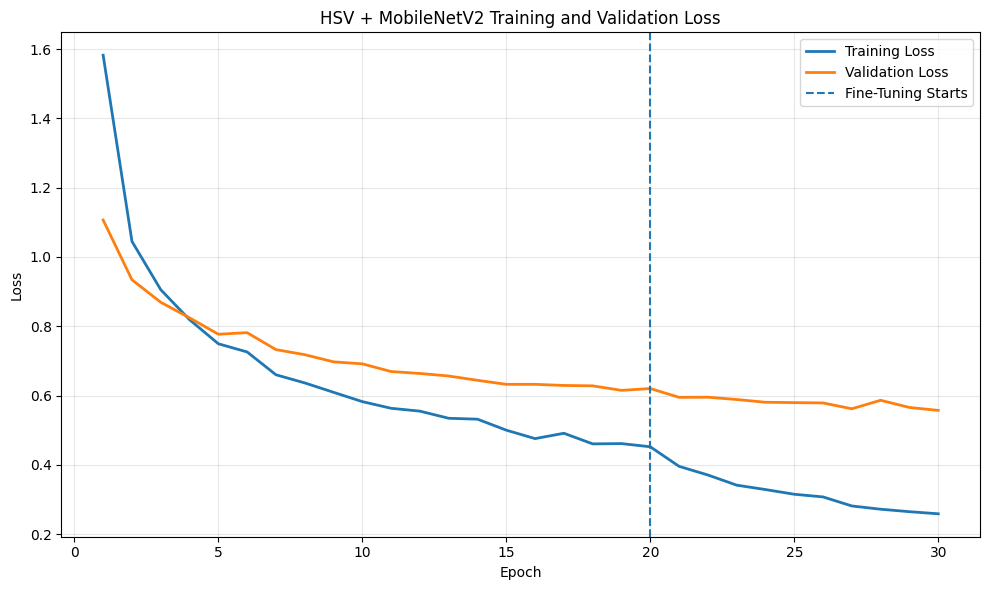



TEST SET EVALUATION
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 249ms/step - accuracy: 0.7827 - loss: 0.4910

Test Loss: 0.49095433950424194
Test Accuracy: 0.7827160358428955

Generating predictions...

Macro F1 Score: 0.7840057805243171
Matthews Correlation Coefficient: 0.7562665105299065


CLASSIFICATION REPORT
                       precision    recall  f1-score   support

       ashgourd_fresh     0.6735    0.7333    0.7021        45
    ashgourd_nitrogen     0.9000    0.8000    0.8471        45
   ashgourd_potassium     0.7500    0.7333    0.7416        45
    bittergourd_fresh     0.6667    0.8000    0.7273        45
 bittergourd_nitrogen     0.7500    0.6000    0.6667        45
bittergourd_potassium     0.9556    0.9556    0.9556        45
     snakegourd_fresh     0.7000    0.7778    0.7368        45
  snakegourd_nitrogen     0.7500    0.8000    0.7742        45
 snakegourd_potassium     0.9744    0.8444    0.9048        45

             accuracy                         0.7827       405
  

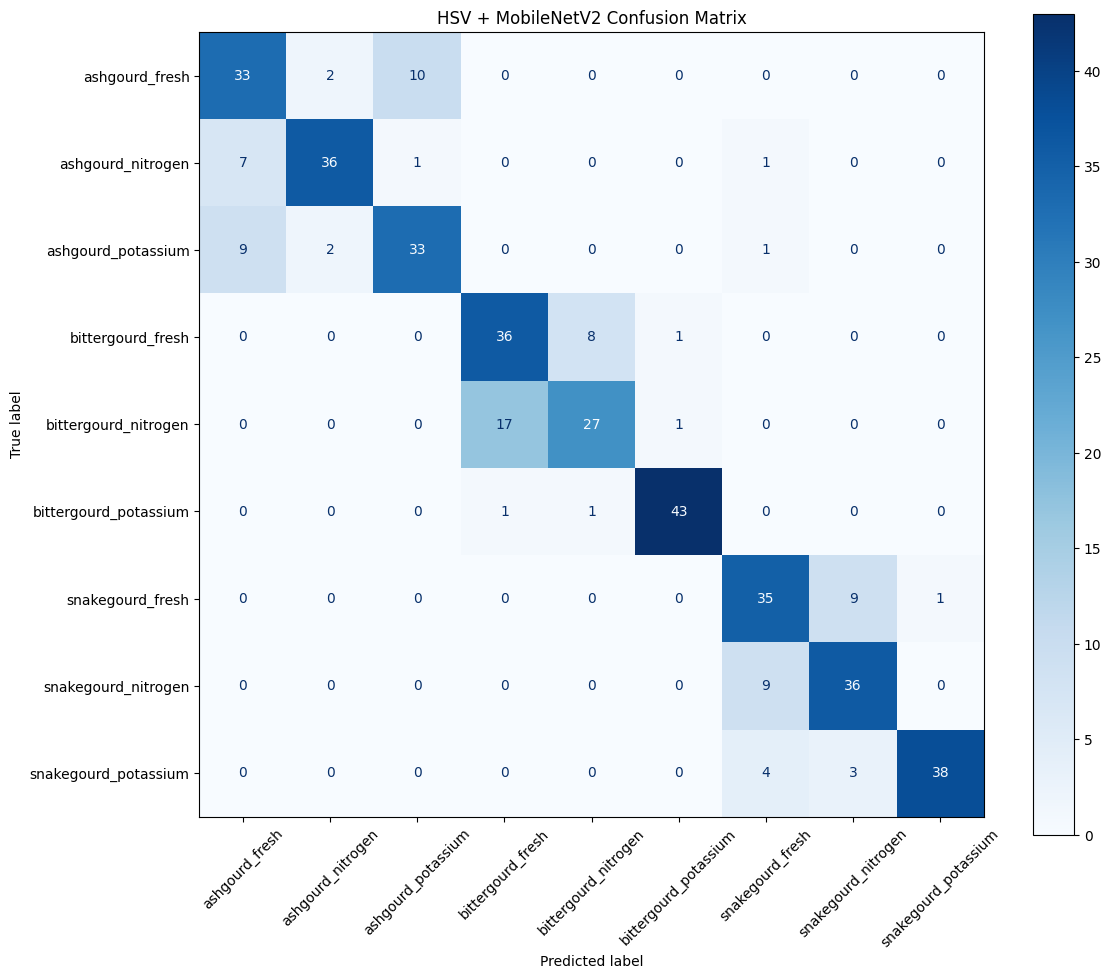



PER-CLASS ACCURACY
ashgourd_fresh: 0.7333
ashgourd_nitrogen: 0.8000
ashgourd_potassium: 0.7333
bittergourd_fresh: 0.8000
bittergourd_nitrogen: 0.6000
bittergourd_potassium: 0.9556
snakegourd_fresh: 0.7778
snakegourd_nitrogen: 0.8000
snakegourd_potassium: 0.8444


MODEL SAVED SUCCESSFULLY
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/HSV_312/HSV_MobileNet_Controlled_FT/HSV_MobileNetV2_312x312_Dropout02_Normalized_StableFT.keras


FINAL RESULTS
Test Loss       : 0.4910
Test Accuracy   : 0.7827
Macro F1        : 0.7840
MCC             : 0.7563
Total Epochs    : 30
Stage 1         : 20 epochs
Stage 2         : 10 epochs


In [9]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ReduceLROnPlateau

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    matthews_corrcoef
)


SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)


BASE_ROOT = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output"
)

TRAIN_DIR = os.path.join(
    BASE_ROOT,
    "Train_256"
)

VAL_DIR = os.path.join(
    BASE_ROOT,
    "Val_resized312"
)

TEST_DIR = os.path.join(
    BASE_ROOT,
    "Test_resized312"
)

OUTPUT_DIR = os.path.join(
    BASE_ROOT,
    "HSV_312",
    "HSV_MobileNet_Controlled_FT"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


IMG_SIZE = (312, 312)

BATCH_SIZE = 32

NUM_CLASSES = 9

DROPOUT_RATE = 0.20

INITIAL_EPOCHS = 20

FINE_TUNE_EPOCHS = 10

TOTAL_EPOCHS = INITIAL_EPOCHS + FINE_TUNE_EPOCHS


print("\nLoading training dataset...")

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)


print("\nLoading validation dataset...")

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


print("\nLoading test dataset...")

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


class_names = train_ds.class_names

print(
    "\nNumber of classes:",
    len(class_names)
)


def convert_batch_bgr_to_hsv(batch):

    hsv_batch = np.empty_like(batch)

    for i in range(batch.shape[0]):

        hsv_batch[i] = cv2.cvtColor(
            batch[i],
            cv2.COLOR_BGR2HSV
        )

    return hsv_batch


def rgb_to_hsv_normalized(images):

    images = tf.cast(
        images,
        tf.float32
    )

    images_uint8 = tf.cast(
        tf.clip_by_value(
            images,
            0,
            255
        ),
        tf.uint8
    )

    bgr_images = tf.reverse(
        images_uint8,
        axis=[-1]
    )

    hsv_images = tf.numpy_function(
        func=convert_batch_bgr_to_hsv,
        inp=[bgr_images],
        Tout=tf.uint8
    )

    hsv_images.set_shape(
        images.shape
    )

    hsv_images = tf.cast(
        hsv_images,
        tf.float32
    )

    H = hsv_images[
        :, :, :, 0:1
    ] / 179.0

    S = hsv_images[
        :, :, :, 1:2
    ] / 255.0

    V = hsv_images[
        :, :, :, 2:3
    ] / 255.0

    hsv_normalized = tf.concat(
        [
            H,
            S,
            V
        ],
        axis=-1
    )

    return hsv_normalized


print("\n")
print("=" * 70)
print("HSV REPRESENTATION VISUALIZATION")
print("=" * 70)


visualization_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=1,
    shuffle=False
)


sample_rgb_tensor, sample_label = next(
    iter(visualization_ds)
)


sample_rgb = sample_rgb_tensor[0].numpy()

sample_rgb_uint8 = np.clip(
    sample_rgb,
    0,
    255
).astype(np.uint8)


sample_bgr = cv2.cvtColor(
    sample_rgb_uint8,
    cv2.COLOR_RGB2BGR
)


sample_hsv = cv2.cvtColor(
    sample_bgr,
    cv2.COLOR_BGR2HSV
)


sample_h = sample_hsv[:, :, 0]

sample_s = sample_hsv[:, :, 1]

sample_v = sample_hsv[:, :, 2]


sample_hsv_display = cv2.cvtColor(
    sample_hsv,
    cv2.COLOR_HSV2RGB
)


sample_class_index = np.argmax(
    sample_label.numpy()[0]
)

sample_class_name = class_names[
    sample_class_index
]


print(
    "\nSample class:",
    sample_class_name
)

print(
    "Image size:",
    sample_rgb_uint8.shape
)

print(
    "HSV H range:",
    sample_h.min(),
    "-",
    sample_h.max()
)

print(
    "HSV S range:",
    sample_s.min(),
    "-",
    sample_s.max()
)

print(
    "HSV V range:",
    sample_v.min(),
    "-",
    sample_v.max()
)


plt.figure(
    figsize=(16, 10)
)


plt.subplot(
    2,
    3,
    1
)

plt.imshow(
    sample_rgb_uint8
)

plt.title(
    "Original RGB"
)

plt.axis(
    "off"
)


plt.subplot(
    2,
    3,
    2
)

plt.imshow(
    sample_hsv_display
)

plt.title(
    "HSV Representation"
)

plt.axis(
    "off"
)


plt.subplot(
    2,
    3,
    3
)

plt.imshow(
    sample_h,
    cmap="hsv"
)

plt.title(
    "Hue (H)"
)

plt.colorbar(
    fraction=0.046,
    pad=0.04
)

plt.axis(
    "off"
)


plt.subplot(
    2,
    3,
    4
)

plt.imshow(
    sample_s,
    cmap="gray"
)

plt.title(
    "Saturation (S)"
)

plt.colorbar(
    fraction=0.046,
    pad=0.04
)

plt.axis(
    "off"
)


plt.subplot(
    2,
    3,
    5
)

plt.imshow(
    sample_v,
    cmap="gray"
)

plt.title(
    "Value (V)"
)

plt.colorbar(
    fraction=0.046,
    pad=0.04
)

plt.axis(
    "off"
)


plt.subplot(
    2,
    3,
    6
)

plt.imshow(
    sample_hsv_display
)

plt.title(
    f"RGB vs HSV | Class: {sample_class_name}"
)

plt.axis(
    "off"
)


plt.tight_layout()

plt.show()


print("\nApplying HSV preprocessing...")


train_ds_hsv = train_ds.map(
    lambda x, y: (
        rgb_to_hsv_normalized(x),
        y
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)


val_ds_hsv = val_ds.map(
    lambda x, y: (
        rgb_to_hsv_normalized(x),
        y
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)


test_ds_hsv = test_ds.map(
    lambda x, y: (
        rgb_to_hsv_normalized(x),
        y
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)


train_ds_hsv = train_ds_hsv.prefetch(
    tf.data.AUTOTUNE
)

val_ds_hsv = val_ds_hsv.prefetch(
    tf.data.AUTOTUNE
)

test_ds_hsv = test_ds_hsv.prefetch(
    tf.data.AUTOTUNE
)


def create_mobilenetv2_model():

    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(312, 312, 3)
    )

    base_model.trainable = False

    model = models.Sequential(
        [

            layers.Input(
                shape=(312, 312, 3),
                name="hsv_input"
            ),

            base_model,

            layers.GlobalAveragePooling2D(
                name="global_average_pooling2d"
            ),

            layers.Dropout(
                DROPOUT_RATE,
                name="dropout"
            ),

            layers.Dense(
                NUM_CLASSES,
                activation="softmax",
                name="classification"
            )

        ],
        name="HSV_MobileNetV2"
    )

    return model, base_model


model, base_model = create_mobilenetv2_model()


print("\nModel Summary:\n")

model.summary()


model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)


print("\n")
print("=" * 70)
print("STAGE 1: FROZEN MOBILENETV2")
print("=" * 70)
print("\n")


history_stage1 = model.fit(

    train_ds_hsv,

    validation_data=val_ds_hsv,

    epochs=INITIAL_EPOCHS,

    verbose=1
)


print("\n")
print("=" * 70)
print("STAGE 2: STABLE FINE-TUNING")
print("=" * 70)
print("\n")


base_model.trainable = True


fine_tune_at = len(
    base_model.layers
) - 30


print(
    "Total MobileNetV2 layers:",
    len(base_model.layers)
)

print(
    "Fine-tuning from layer:",
    fine_tune_at
)


for layer_index, layer in enumerate(
    base_model.layers
):

    if layer_index < fine_tune_at:

        layer.trainable = False

    else:

        layer.trainable = True


for layer in base_model.layers:

    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):

        layer.trainable = False


model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=5e-6
    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)


reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=2,

    min_lr=1e-7,

    verbose=1
)


history_stage2 = model.fit(

    train_ds_hsv,

    validation_data=val_ds_hsv,

    epochs=FINE_TUNE_EPOCHS,

    callbacks=[
        reduce_lr
    ],

    verbose=1
)


train_accuracy = (
    history_stage1.history["accuracy"]
    +
    history_stage2.history["accuracy"]
)

val_accuracy = (
    history_stage1.history["val_accuracy"]
    +
    history_stage2.history["val_accuracy"]
)

train_loss = (
    history_stage1.history["loss"]
    +
    history_stage2.history["loss"]
)

val_loss = (
    history_stage1.history["val_loss"]
    +
    history_stage2.history["val_loss"]
)


epochs_range = range(
    1,
    TOTAL_EPOCHS + 1
)


plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs_range,
    train_accuracy,
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    epochs_range,
    val_accuracy,
    label="Validation Accuracy",
    linewidth=2
)

plt.axvline(
    x=20,
    linestyle="--",
    linewidth=1.5,
    label="Fine-Tuning Starts"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "HSV + MobileNetV2 Training and Validation Accuracy"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs_range,
    train_loss,
    label="Training Loss",
    linewidth=2
)

plt.plot(
    epochs_range,
    val_loss,
    label="Validation Loss",
    linewidth=2
)

plt.axvline(
    x=20,
    linestyle="--",
    linewidth=1.5,
    label="Fine-Tuning Starts"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "HSV + MobileNetV2 Training and Validation Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


print("\n")
print("=" * 70)
print("TEST SET EVALUATION")
print("=" * 70)


test_loss, test_accuracy = model.evaluate(

    test_ds_hsv,

    verbose=1
)


print(
    "\nTest Loss:",
    test_loss
)

print(
    "Test Accuracy:",
    test_accuracy
)


print("\nGenerating predictions...")


y_true = []

y_pred = []


for images, labels in test_ds_hsv:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    true_classes = np.argmax(
        labels.numpy(),
        axis=1
    )

    y_true.extend(
        true_classes
    )

    y_pred.extend(
        predicted_classes
    )


y_true = np.array(
    y_true
)

y_pred = np.array(
    y_pred
)


macro_f1 = f1_score(

    y_true,

    y_pred,

    average="macro"
)


print(
    "\nMacro F1 Score:",
    macro_f1
)


mcc = matthews_corrcoef(

    y_true,

    y_pred
)


print(
    "Matthews Correlation Coefficient:",
    mcc
)


print("\n")
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)


print(
    classification_report(

        y_true,

        y_pred,

        target_names=class_names,

        digits=4
    )
)


cm = confusion_matrix(

    y_true,

    y_pred
)


plt.figure(
    figsize=(12, 10)
)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_names
)

disp.plot(

    cmap="Blues",

    xticks_rotation=45,

    ax=plt.gca(),

    values_format="d"

)

plt.title(
    "HSV + MobileNetV2 Confusion Matrix"
)

plt.tight_layout()

plt.show()


print("\n")
print("=" * 70)
print("PER-CLASS ACCURACY")
print("=" * 70)


for i, class_name in enumerate(
    class_names
):

    total = np.sum(
        cm[i]
    )

    correct = cm[i, i]

    if total > 0:

        class_accuracy = (
            correct / total
        )

    else:

        class_accuracy = 0.0

    print(
        f"{class_name}: "
        f"{class_accuracy:.4f}"
    )


MODEL_SAVE_PATH = os.path.join(
    OUTPUT_DIR,
    "HSV_MobileNetV2_312x312_Dropout02_Normalized_StableFT.keras"
)


model.save(
    MODEL_SAVE_PATH
)


print("\n")
print("=" * 70)
print("MODEL SAVED SUCCESSFULLY")
print("=" * 70)

print(
    MODEL_SAVE_PATH
)


print("\n")
print("=" * 70)
print("FINAL RESULTS")
print("=" * 70)

print(
    f"Test Loss       : {test_loss:.4f}"
)

print(
    f"Test Accuracy   : {test_accuracy:.4f}"
)

print(
    f"Macro F1        : {macro_f1:.4f}"
)

print(
    f"MCC             : {mcc:.4f}"
)

print(
    f"Total Epochs    : {TOTAL_EPOCHS}"
)

print(
    "Stage 1         : 20 epochs"
)

print(
    "Stage 2         : 10 epochs"
)

In [11]:
def predict_early_nutrient_stress(image_path):

    print("\n==============================================")
    print("HSV MOBILENETV2 - EARLY NUTRIENT STRESS")
    print("==============================================")

    image = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    image_array = tf.keras.utils.img_to_array(
        image
    )

    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    hsv_image = rgb_to_hsv_normalized(
        tf.convert_to_tensor(
            image_array
        )
    )

    probabilities = model.predict(
        hsv_image,
        verbose=0
    )[0]

    predicted_index = np.argmax(
        probabilities
    )

    predicted_class = class_names[
        predicted_index
    ]

    confidence = (
        probabilities[predicted_index] * 100
    )

    actual_class = os.path.basename(
        os.path.dirname(image_path)
    )

    print("\nImage:")
    print(image_path)

    print("\nActual Class:")
    print(actual_class)

    print("\nPredicted Class:")
    print(predicted_class)

    print("\nConfidence:")
    print(
        f"{confidence:.2f}%"
    )

    if predicted_class == actual_class:

        print("\nPrediction:")
        print("CORRECT")

    else:

        print("\nPrediction:")
        print("INCORRECT")

    if "nitrogen" in predicted_class:

        print("\nEARLY NUTRIENT STRESS:")
        print(
            "Nitrogen deficiency class detected."
        )

    elif "potassium" in predicted_class:

        print("\nEARLY NUTRIENT STRESS:")
        print(
            "Potassium deficiency class detected."
        )

    elif "fresh" in predicted_class:

        print("\nEARLY NUTRIENT STRESS:")
        print(
            "No nutrient-deficiency class detected."
        )

    print("\n----------------------------------------------")
    print("ALL CLASS PROBABILITIES")
    print("----------------------------------------------")

    for i, class_name in enumerate(
        class_names
    ):

        print(
            f"{class_name:<25}"
            f"{probabilities[i] * 100:.2f}%"
        )

    return (
        actual_class,
        predicted_class,
        confidence,
        probabilities
    )


image_path = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/Test_resized312/"
    "ashgourd_nitrogen/"
    "RGB (125).JPG"
)


predict_early_nutrient_stress(
    image_path
)


HSV MOBILENETV2 - EARLY NUTRIENT STRESS

Image:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Test_resized312/ashgourd_nitrogen/RGB (125).JPG

Actual Class:
ashgourd_nitrogen

Predicted Class:
ashgourd_nitrogen

Confidence:
99.41%

Prediction:
CORRECT

EARLY NUTRIENT STRESS:
Nitrogen deficiency class detected.

----------------------------------------------
ALL CLASS PROBABILITIES
----------------------------------------------
ashgourd_fresh           0.18%
ashgourd_nitrogen        99.41%
ashgourd_potassium       0.40%
bittergourd_fresh        0.00%
bittergourd_nitrogen     0.00%
bittergourd_potassium    0.00%
snakegourd_fresh         0.00%
snakegourd_nitrogen      0.00%
snakegourd_potassium     0.00%


('ashgourd_nitrogen',
 'ashgourd_nitrogen',
 np.float32(99.414406),
 array([1.7961921e-03, 9.9414402e-01, 4.0003429e-03, 1.3160830e-05,
        2.6447003e-07, 1.8922656e-06, 6.1721348e-06, 3.7882721e-05,
        5.4018017e-08], dtype=float32))

## Early Nutrient deficiency HSV_MobileNet

In [12]:
# IMAGE → CROP + CONDITION PREDICTION

image_path = (
    "/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Test_resized312/ashgourd_nitrogen/RGB (125).JPG"
)


image = tf.keras.utils.load_img(
    image_path,
    target_size=IMG_SIZE
)

image_array = tf.keras.utils.img_to_array(
    image
)

image_array = np.expand_dims(
    image_array,
    axis=0
)


# RGB → NORMALIZED HSV

hsv_image = rgb_to_hsv_normalized(
    tf.convert_to_tensor(
        image_array
    )
)


# CNN PREDICTION

probabilities = model.predict(
    hsv_image,
    verbose=0
)[0]


# CROP PROBABILITIES

ashgourd = np.sum(
    probabilities[0:3]
)

bittergourd = np.sum(
    probabilities[3:6]
)

snakegourd = np.sum(
    probabilities[6:9]
)


crop_probs = {
    "ashgourd": ashgourd,
    "bittergourd": bittergourd,
    "snakegourd": snakegourd
}


predicted_crop = max(
    crop_probs,
    key=crop_probs.get
)


# CONDITION PROBABILITIES

start = {
    "ashgourd": 0,
    "bittergourd": 3,
    "snakegourd": 6
}[predicted_crop]


fresh = probabilities[start]

nitrogen = probabilities[start + 1]

potassium = probabilities[start + 2]


condition_probs = {
    "fresh": fresh,
    "nitrogen": nitrogen,
    "potassium": potassium
}


predicted_condition = max(
    condition_probs,
    key=condition_probs.get
)


# RESULTS

print("\n" + "=" * 55)
print("HSV MOBILENETV2 - LEAF CLASSIFICATION RESULT")
print("=" * 55)


print("\nImage:")
print(image_path)


print("\nInput Representation:")
print("RGB → HSV → Normalized HSV")


print("\nModel:")
print("MobileNetV2")


print("\nCROP PROBABILITIES")
print("-" * 55)


print(
    f"Ashgourd    : "
    f"{ashgourd * 100:.2f}%"
)


print(
    f"Bittergourd : "
    f"{bittergourd * 100:.2f}%"
)


print(
    f"Snakegourd  : "
    f"{snakegourd * 100:.2f}%"
)


print(
    f"\nPredicted Crop: "
    f"{predicted_crop.upper()}"
)


print("\nCONDITION PROBABILITIES")
print("-" * 55)


print(
    f"Fresh      : "
    f"{fresh * 100:.2f}%"
)


print(
    f"Nitrogen   : "
    f"{nitrogen * 100:.2f}%"
)


print(
    f"Potassium  : "
    f"{potassium * 100:.2f}%"
)


print("\nFINAL RESULT")
print("-" * 55)


print(
    f"Crop      : "
    f"{predicted_crop.upper()}"
)


print(
    f"Condition : "
    f"{predicted_condition.upper()}"
)


print(
    f"Final Class: "
    f"{predicted_crop}_{predicted_condition}"
)


HSV MOBILENETV2 - LEAF CLASSIFICATION RESULT

Image:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Test_resized312/ashgourd_nitrogen/RGB (125).JPG

Input Representation:
RGB → HSV → Normalized HSV

Model:
MobileNetV2

CROP PROBABILITIES
-------------------------------------------------------
Ashgourd    : 99.99%
Bittergourd : 0.00%
Snakegourd  : 0.00%

Predicted Crop: ASHGOURD

CONDITION PROBABILITIES
-------------------------------------------------------
Fresh      : 0.18%
Nitrogen   : 99.41%
Potassium  : 0.40%

FINAL RESULT
-------------------------------------------------------
Crop      : ASHGOURD
Condition : NITROGEN
Final Class: ashgourd_nitrogen


## HSV -- EfficientNet


Loading training dataset...
Found 1890 files belonging to 9 classes.

Loading validation dataset...
Found 405 files belonging to 9 classes.

Loading test dataset...
Found 405 files belonging to 9 classes.

Number of classes: 9

Applying HSV preprocessing...


HSV PREPROCESSING SANITY CHECK
HSV tensor shape: (32, 312, 312, 3)
HSV minimum: 0.0
HSV maximum: 1.0
HSV mean: 0.18266049027442932
Contains NaN: False
Contains Inf: False

Model Summary:



Model: "HSV_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hsv_input (InputLayer)          │ (None, 312, 312, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hsv_to_efficientnet_adapter     │ (None, 312, 312, 3)    │            12 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ adapter_sigmoid (Activation)    │ (None, 312, 312, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ restore_efficientnet_input_ran… │ (None, 312, 312, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 10, 10, 1280)   │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,061,112 (15.49 MB)

 Trainable params: 11,541 (45.08 KB)

 Non-trainable params: 4,049,571 (15.45 MB)



STAGE 1: HSV ADAPTER + CLASSIFICATION HEAD


Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.3735 - loss: 1.6485 - val_accuracy: 0.5383 - val_loss: 1.2178 - learning_rate: 0.0010
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.5190 - loss: 1.1887 - val_accuracy: 0.5704 - val_loss: 1.0529 - learning_rate: 0.0010
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.5677 - loss: 1.0504 - val_accuracy: 0.6173 - val_loss: 0.9562 - learning_rate: 0.0010
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.5915 - loss: 0.9910 - val_accuracy: 0.6074 - val_loss: 0.9197 - learning_rate: 0.0010
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.6238 - loss: 0.9147 - val_accuracy: 0.6420 - val_loss: 0.8727 - learning_rate: 0.0010
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.6450 - loss: 0.8624 - val_accuracy: 0.6272 - val_loss: 0.8489 - learning_rate: 0.0010
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - a

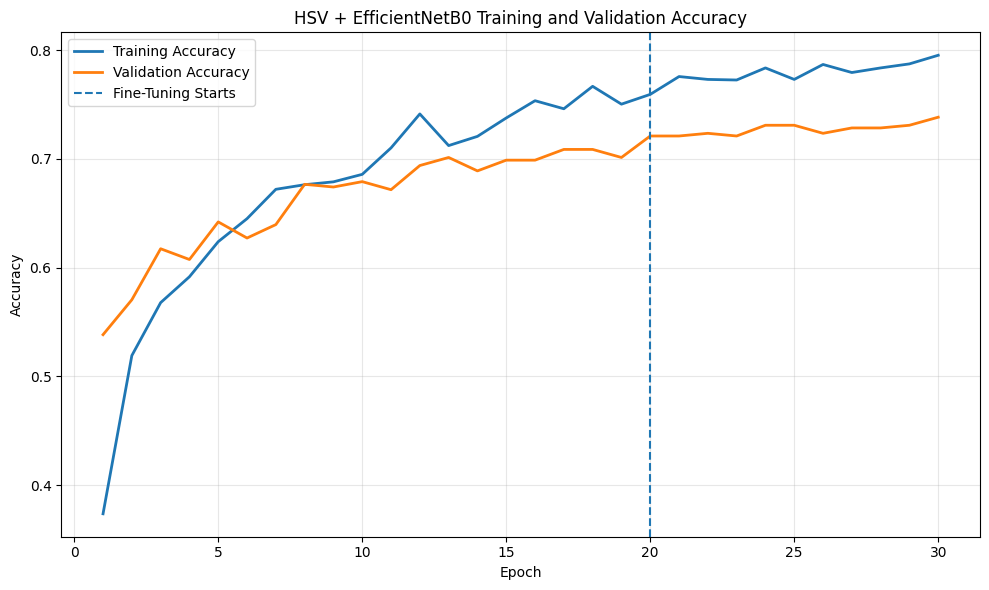

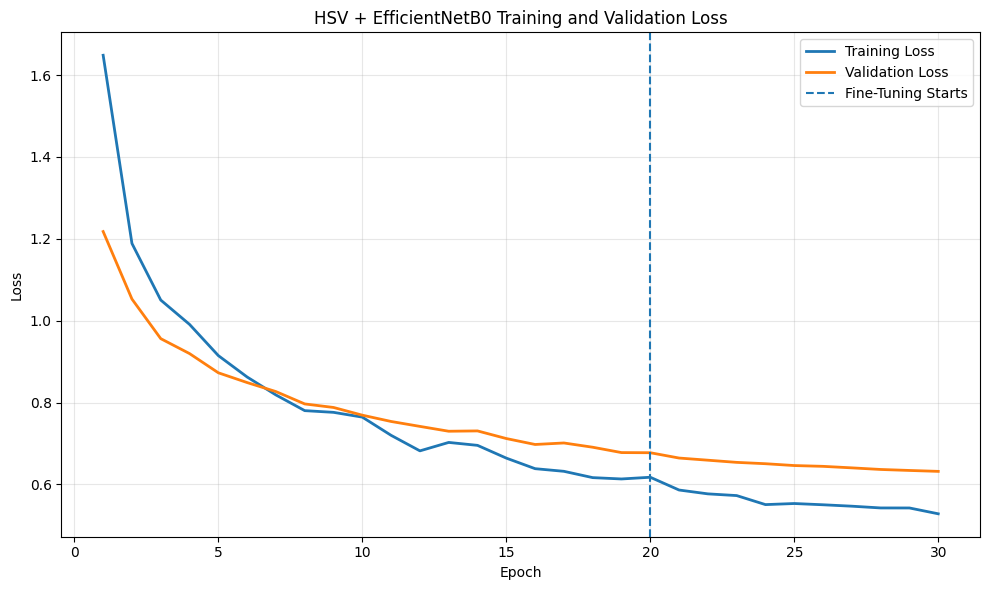



TEST SET EVALUATION
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 347ms/step - accuracy: 0.7654 - loss: 0.5497

Test Loss: 0.5497297644615173
Test Accuracy: 0.7654321193695068

Generating predictions...

Macro F1 Score: 0.7638417170318654
Matthews Correlation Coefficient: 0.7367379587653106


CLASSIFICATION REPORT
                       precision    recall  f1-score   support

       ashgourd_fresh     0.6744    0.6444    0.6591        45
    ashgourd_nitrogen     0.8750    0.7778    0.8235        45
   ashgourd_potassium     0.6154    0.7111    0.6598        45
    bittergourd_fresh     0.7111    0.7111    0.7111        45
 bittergourd_nitrogen     0.6757    0.5556    0.6098        45
bittergourd_potassium     0.7925    0.9333    0.8571        45
     snakegourd_fresh     0.8293    0.7556    0.7907        45
  snakegourd_nitrogen     0.8000    0.8889    0.8421        45
 snakegourd_potassium     0.9318    0.9111    0.9213        45

             accuracy                         0.7654       405
   

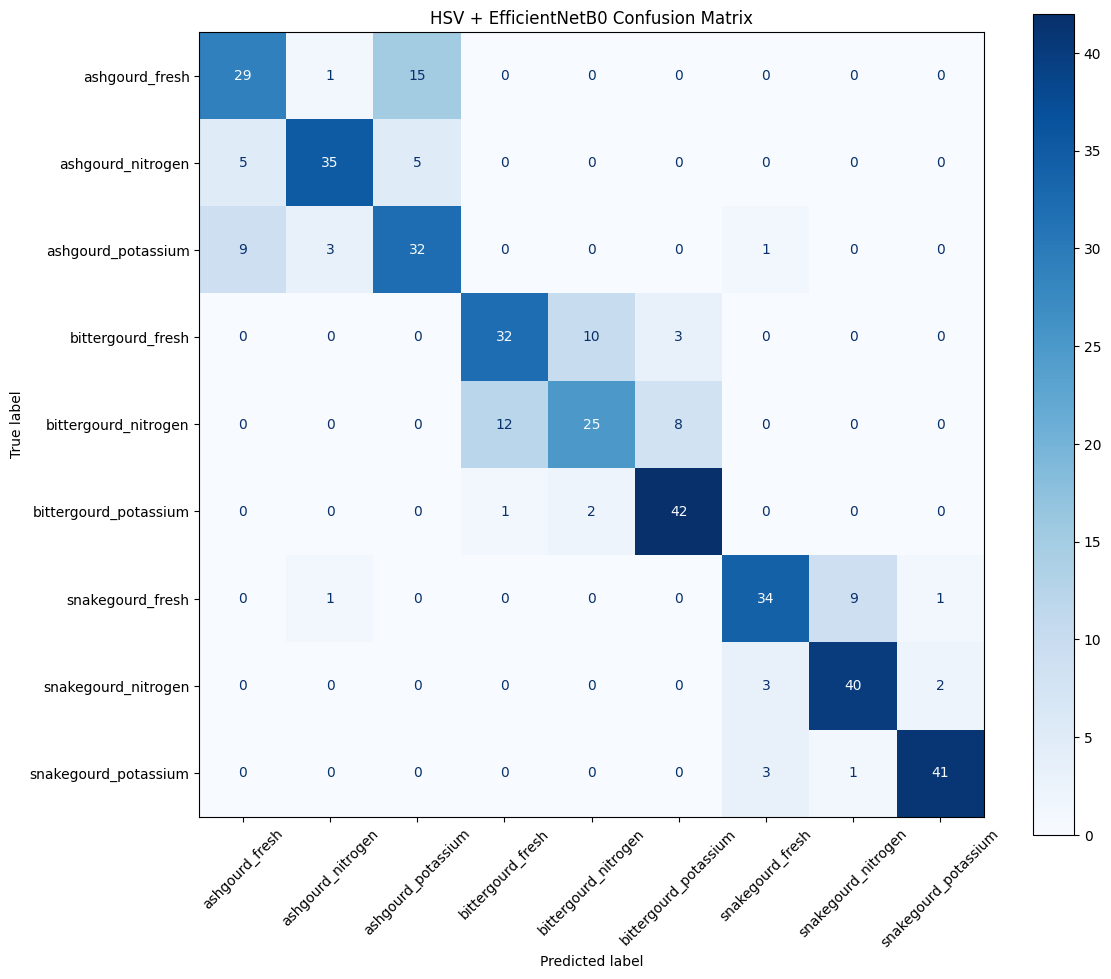



PER-CLASS ACCURACY
ashgourd_fresh: 0.6444
ashgourd_nitrogen: 0.7778
ashgourd_potassium: 0.7111
bittergourd_fresh: 0.7111
bittergourd_nitrogen: 0.5556
bittergourd_potassium: 0.9333
snakegourd_fresh: 0.7556
snakegourd_nitrogen: 0.8889
snakegourd_potassium: 0.9111


MODEL SAVED SUCCESSFULLY
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/HSV_EfficientNetB0_312x312_Dropout03_Normalized_StableFT.keras


FINAL RESULTS
Test Loss       : 0.5497
Test Accuracy   : 0.7654
Macro F1        : 0.7638
MCC             : 0.7367
Total Epochs    : 30
Stage 1         : 20 epochs
Stage 2         : 10 epochs
HSV Adapter     : Trainable
Fine-tuned      : Last 30 EfficientNetB0 layers
BatchNorm       : Frozen
Input           : HSV
HSV Normalized  : H/179, S/255, V/255
EfficientNet    : Internal preprocessing retained
Image Size      : 312 x 312
Dropout         : 0.30


In [ ]:


import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

from tensorflow.keras.callbacks import ReduceLROnPlateau

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    matthews_corrcoef
)


SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)


TRAIN_DIR = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/Train_256"
)

VAL_DIR = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/Val_resized312"
)

TEST_DIR = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/Test_resized312"
)


IMG_SIZE = (312, 312)

BATCH_SIZE = 32

NUM_CLASSES = 9

DROPOUT_RATE = 0.30

INITIAL_EPOCHS = 20

FINE_TUNE_EPOCHS = 10

TOTAL_EPOCHS = ( INITIAL_EPOCHS + FINE_TUNE_EPOCHS)


# Learning rates
STAGE1_LR = 1e-3

STAGE2_LR = 5e-6

print("\nLoading training dataset...")

train_ds = tf.keras.utils.image_dataset_from_directory(

    TRAIN_DIR,

    labels="inferred",

    label_mode="categorical",

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=SEED
)



#  VALIDATION DATASET

print("\nLoading validation dataset...")

val_ds = tf.keras.utils.image_dataset_from_directory(

    VAL_DIR,

    labels="inferred",

    label_mode="categorical",

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False
)


# ============================================================
# 7. LOAD TEST DATASET
# ============================================================

print("\nLoading test dataset...")

test_ds = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    labels="inferred",

    label_mode="categorical",

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False
)


# ============================================================
# 8. CLASS INFORMATION
# ============================================================

class_names = train_ds.class_names

print(
    "\nNumber of classes:",
    len(class_names)
)


# ============================================================
# 9. HSV CONVERSION
#
# IMPORTANT:
# tf.numpy_function already passes a NumPy ndarray.
#
# DO NOT use:
#
# batch = batch.numpy()
#
# ============================================================

def convert_batch_bgr_to_hsv(batch):

    hsv_batch = np.empty_like(batch)

    for i in range(batch.shape[0]):

        hsv_batch[i] = cv2.cvtColor(
            batch[i],
            cv2.COLOR_BGR2HSV
        )

    return hsv_batch


# ============================================================
# 10. RGB -> HSV + NORMALIZATION
# ============================================================

def rgb_to_hsv_normalized(images):

    # --------------------------------------------------------
    # Convert to float32
    # --------------------------------------------------------

    images = tf.cast(
        images,
        tf.float32
    )


    # --------------------------------------------------------
    # Keep valid image range
    # --------------------------------------------------------

    images_uint8 = tf.cast(
        tf.clip_by_value(
            images,
            0,
            255
        ),
        tf.uint8
    )


    # --------------------------------------------------------
    # RGB -> BGR
    # --------------------------------------------------------

    bgr_images = tf.reverse(
        images_uint8,
        axis=[-1]
    )


    # --------------------------------------------------------
    # BGR -> HSV using OpenCV
    # --------------------------------------------------------

    hsv_images = tf.numpy_function(
        func=convert_batch_bgr_to_hsv,
        inp=[bgr_images],
        Tout=tf.uint8
    )


    # --------------------------------------------------------
    # Restore static shape
    # --------------------------------------------------------

    hsv_images.set_shape(
        images.shape
    )


    # --------------------------------------------------------
    # uint8 -> float32
    # --------------------------------------------------------

    hsv_images = tf.cast(
        hsv_images,
        tf.float32
    )


    # --------------------------------------------------------
    # H: 0-179 -> 0-1
    # --------------------------------------------------------

    H = (
        hsv_images[:, :, :, 0:1]
        / 179.0
    )


    # --------------------------------------------------------
    # S: 0-255 -> 0-1
    # --------------------------------------------------------

    S = (
        hsv_images[:, :, :, 1:2]
        / 255.0
    )


    # --------------------------------------------------------
    # V: 0-255 -> 0-1
    # --------------------------------------------------------

    V = (
        hsv_images[:, :, :, 2:3]
        / 255.0
    )


    # --------------------------------------------------------
    # Combine HSV
    # --------------------------------------------------------

    hsv_normalized = tf.concat(
        [
            H,
            S,
            V
        ],
        axis=-1
    )


    return hsv_normalized


# ============================================================
# 11. APPLY HSV PREPROCESSING
# ============================================================

print(
    "\nApplying HSV preprocessing..."
)


train_ds_hsv = train_ds.map(

    lambda x, y: (
        rgb_to_hsv_normalized(x),
        y
    ),

    num_parallel_calls=tf.data.AUTOTUNE

)


val_ds_hsv = val_ds.map(

    lambda x, y: (
        rgb_to_hsv_normalized(x),
        y
    ),

    num_parallel_calls=tf.data.AUTOTUNE

)


test_ds_hsv = test_ds.map(

    lambda x, y: (
        rgb_to_hsv_normalized(x),
        y
    ),

    num_parallel_calls=tf.data.AUTOTUNE

)


# ============================================================
# 12. PREFETCH
# ============================================================

train_ds_hsv = train_ds_hsv.prefetch(
    tf.data.AUTOTUNE
)

val_ds_hsv = val_ds_hsv.prefetch(
    tf.data.AUTOTUNE
)

test_ds_hsv = test_ds_hsv.prefetch(
    tf.data.AUTOTUNE
)


# ============================================================
# 13. HSV INPUT SANITY CHECK
#
# This checks that preprocessing itself is working.
# ============================================================

print("\n")
print("=" * 70)
print("HSV PREPROCESSING SANITY CHECK")
print("=" * 70)


for sample_images, sample_labels in train_ds_hsv.take(1):

    print(
        "HSV tensor shape:",
        sample_images.shape
    )

    print(
        "HSV minimum:",
        float(tf.reduce_min(sample_images).numpy())
    )

    print(
        "HSV maximum:",
        float(tf.reduce_max(sample_images).numpy())
    )

    print(
        "HSV mean:",
        float(tf.reduce_mean(sample_images).numpy())
    )

    print(
        "Contains NaN:",
        bool(
            tf.reduce_any(
                tf.math.is_nan(sample_images)
            ).numpy()
        )
    )

    print(
        "Contains Inf:",
        bool(
            tf.reduce_any(
                tf.math.is_inf(sample_images)
            ).numpy()
        )
    )

    break


# ============================================================
# 14. CREATE EFFICIENTNETB0
# ============================================================

def create_efficientnet_model():

    # --------------------------------------------------------
    # ImageNet pretrained EfficientNetB0
    # --------------------------------------------------------

    base_model = EfficientNetB0(

        weights="imagenet",

        include_top=False,

        input_shape=(312, 312, 3)

    )


    # --------------------------------------------------------
    # Freeze EfficientNet initially
    # --------------------------------------------------------

    base_model.trainable = False


    # --------------------------------------------------------
    # Input
    # --------------------------------------------------------

    inputs = layers.Input(

        shape=(312, 312, 3),

        name="hsv_input"

    )


    # --------------------------------------------------------
    # LEARNABLE HSV ADAPTER
    #
    # A 1x1 convolution learns how HSV channels should be
    # transformed before entering ImageNet EfficientNet.
    #
    # This is important because ImageNet filters expect
    # RGB-like channel relationships.
    # --------------------------------------------------------

    hsv_adapter = layers.Conv2D(

        filters=3,

        kernel_size=1,

        padding="same",

        use_bias=True,

        name="hsv_to_efficientnet_adapter"

    )(inputs)


    # --------------------------------------------------------
    # Keep values in a stable range
    # --------------------------------------------------------

    hsv_adapter = layers.Activation(

        "sigmoid",

        name="adapter_sigmoid"

    )(hsv_adapter)


    # --------------------------------------------------------
    # EfficientNet Keras preprocessing expects the usual
    # image value range.
    #
    # Our HSV data is [0,1], therefore restore [0,255].
    # EfficientNet then applies its own internal rescaling.
    # --------------------------------------------------------

    efficientnet_input = layers.Rescaling(

        255.0,

        name="restore_efficientnet_input_range"

    )(hsv_adapter)


    # --------------------------------------------------------
    # EfficientNetB0
    # --------------------------------------------------------

    x = base_model(

        efficientnet_input,

        training=False

    )


    # --------------------------------------------------------
    # Global Average Pooling
    # --------------------------------------------------------

    x = layers.GlobalAveragePooling2D(

        name="global_average_pooling2d"

    )(x)


    # --------------------------------------------------------
    # Dropout
    # --------------------------------------------------------

    x = layers.Dropout(

        DROPOUT_RATE,

        name="dropout"

    )(x)


    # --------------------------------------------------------
    # Classification
    # --------------------------------------------------------

    outputs = layers.Dense(

        NUM_CLASSES,

        activation="softmax",

        name="classification"

    )(x)


    # --------------------------------------------------------
    # Complete model
    # --------------------------------------------------------

    model = models.Model(

        inputs=inputs,

        outputs=outputs,

        name="HSV_EfficientNetB0"

    )


    return model, base_model


# ============================================================
# 15. CREATE MODEL
# ============================================================

model, base_model = create_efficientnet_model()


# ============================================================
# 16. MODEL SUMMARY
# ============================================================

print("\nModel Summary:\n")

model.summary()


# ============================================================
# 17. STAGE 1 COMPILATION
#
# EfficientNet frozen.
#
# Only:
# - HSV adapter
# - classification head
#
# are trained.
# ============================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=STAGE1_LR

    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy"
    ]

)


# ============================================================
# 18. STAGE 1 LR SCHEDULER
#
# Requested configuration:
#
# monitor = val_loss
# factor = 0.5
# patience = 5
# min_lr = 1e-5
# ============================================================

lr_scheduler_stage1 = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=5,

    min_lr=1e-5,

    verbose=1

)


# ============================================================
# 19. STAGE 1 TRAINING
# ============================================================

print("\n")
print("=" * 70)
print("STAGE 1: HSV ADAPTER + CLASSIFICATION HEAD")
print("=" * 70)
print("\n")


history_stage1 = model.fit(

    train_ds_hsv,

    validation_data=val_ds_hsv,

    epochs=INITIAL_EPOCHS,

    callbacks=[
        lr_scheduler_stage1
    ],

    verbose=1

)


# ============================================================
# 20. STAGE 2
# STABLE FINE-TUNING
#
# Unfreeze only last 30 EfficientNet layers.
# ============================================================

print("\n")
print("=" * 70)
print("STAGE 2: EFFICIENTNET FINE-TUNING")
print("=" * 70)
print("\n")


base_model.trainable = True


# ============================================================
# 21. FIND FINE-TUNING POINT
# ============================================================

fine_tune_at = (

    len(base_model.layers)

    - 30

)


print(
    "Total EfficientNetB0 layers:",
    len(base_model.layers)
)

print(
    "Fine-tuning from layer:",
    fine_tune_at
)


# ============================================================
# 22. FREEZE EARLY LAYERS
# ============================================================

for layer_index, layer in enumerate(
    base_model.layers
):

    if layer_index < fine_tune_at:

        layer.trainable = False

    else:

        layer.trainable = True


# ============================================================
# 23. FREEZE ALL BATCH NORMALIZATION LAYERS
# ============================================================

for layer in base_model.layers:

    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):

        layer.trainable = False


# ============================================================
# 24. RECOMPILE
#
# Small LR for fine-tuning.
# ============================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=STAGE2_LR

    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy"
    ]

)


# ============================================================
# 25. STAGE 2 LR SCHEDULER
# ============================================================

lr_scheduler_stage2 = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=5,

    min_lr=1e-5,

    verbose=1

)


# ============================================================
# 26. STAGE 2 TRAINING
# ============================================================

history_stage2 = model.fit(

    train_ds_hsv,

    validation_data=val_ds_hsv,

    epochs=FINE_TUNE_EPOCHS,

    callbacks=[
        lr_scheduler_stage2
    ],

    verbose=1

)


# ============================================================
# 27. COMBINE HISTORIES
# ============================================================

train_accuracy = (

    history_stage1.history["accuracy"]

    +

    history_stage2.history["accuracy"]

)


val_accuracy = (

    history_stage1.history["val_accuracy"]

    +

    history_stage2.history["val_accuracy"]

)


train_loss = (

    history_stage1.history["loss"]

    +

    history_stage2.history["loss"]

)


val_loss = (

    history_stage1.history["val_loss"]

    +

    history_stage2.history["val_loss"]

)


epochs_range = range(

    1,

    TOTAL_EPOCHS + 1

)


# ============================================================
# 28. COMBINED ACCURACY PLOT
# ============================================================

plt.figure(

    figsize=(10, 6)

)

plt.plot(

    epochs_range,

    train_accuracy,

    label="Training Accuracy",

    linewidth=2

)

plt.plot(

    epochs_range,

    val_accuracy,

    label="Validation Accuracy",

    linewidth=2

)

plt.axvline(

    x=20,

    linestyle="--",

    linewidth=1.5,

    label="Fine-Tuning Starts"

)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "HSV + EfficientNetB0 Training and Validation Accuracy"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 29. COMBINED LOSS PLOT
# ============================================================

plt.figure(

    figsize=(10, 6)

)

plt.plot(

    epochs_range,

    train_loss,

    label="Training Loss",

    linewidth=2

)

plt.plot(

    epochs_range,

    val_loss,

    label="Validation Loss",

    linewidth=2

)

plt.axvline(

    x=20,

    linestyle="--",

    linewidth=1.5,

    label="Fine-Tuning Starts"

)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "HSV + EfficientNetB0 Training and Validation Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 30. TEST SET EVALUATION
# ============================================================

print("\n")
print("=" * 70)
print("TEST SET EVALUATION")
print("=" * 70)


test_loss, test_accuracy = model.evaluate(

    test_ds_hsv,

    verbose=1

)


print(
    "\nTest Loss:",
    test_loss
)

print(
    "Test Accuracy:",
    test_accuracy
)


# ============================================================
# 31. GENERATE TEST PREDICTIONS
# ============================================================

print(
    "\nGenerating predictions..."
)


y_true = []

y_pred = []


for images, labels in test_ds_hsv:

    predictions = model.predict(

        images,

        verbose=0

    )


    predicted_classes = np.argmax(

        predictions,

        axis=1

    )


    true_classes = np.argmax(

        labels.numpy(),

        axis=1

    )


    y_true.extend(
        true_classes
    )

    y_pred.extend(
        predicted_classes
    )


y_true = np.array(
    y_true
)

y_pred = np.array(
    y_pred
)


# ============================================================
# 32. MACRO F1
# ============================================================

macro_f1 = f1_score(

    y_true,

    y_pred,

    average="macro"

)


print(
    "\nMacro F1 Score:",
    macro_f1
)


# ============================================================
# 33. MCC
# ============================================================

mcc = matthews_corrcoef(

    y_true,

    y_pred

)


print(
    "Matthews Correlation Coefficient:",
    mcc
)


# ============================================================
# 34. CLASSIFICATION REPORT
# ============================================================

print("\n")
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)


print(

    classification_report(

        y_true,

        y_pred,

        target_names=class_names,

        digits=4

    )

)


# ============================================================
# 35. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_true,

    y_pred

)


# ============================================================
# 36. CONFUSION MATRIX DISPLAY
# ============================================================

plt.figure(

    figsize=(12, 10)

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_names

)

disp.plot(

    cmap="Blues",

    xticks_rotation=45,

    ax=plt.gca(),

    values_format="d"

)

plt.title(

    "HSV + EfficientNetB0 Confusion Matrix"

)

plt.tight_layout()

plt.show()


# ============================================================
# 37. PER-CLASS ACCURACY
# ============================================================

print("\n")
print("=" * 70)
print("PER-CLASS ACCURACY")
print("=" * 70)


for i, class_name in enumerate(
    class_names
):

    total = np.sum(
        cm[i]
    )

    correct = cm[i, i]

    if total > 0:

        class_accuracy = (
            correct / total
        )

    else:

        class_accuracy = 0.0

    print(
        f"{class_name}: "
        f"{class_accuracy:.4f}"
    )


# ============================================================
# 38. SAVE MODEL
# ============================================================

MODEL_SAVE_PATH = (

    "/home/mtech_atul/atul/"

    "Early_Output-20260923T172757Z-1-001/"

    "Early_Output/"

    "HSV_EfficientNetB0_312x312_"
    "Dropout03_Normalized_StableFT.keras"

)


model.save(

    MODEL_SAVE_PATH

)


# ============================================================
# 39. FINAL RESULTS
# ============================================================

print("\n")
print("=" * 70)
print("MODEL SAVED SUCCESSFULLY")
print("=" * 70)


print(
    MODEL_SAVE_PATH
)


print("\n")
print("=" * 70)
print("FINAL RESULTS")
print("=" * 70)


print(
    f"Test Loss       : {test_loss:.4f}"
)

print(
    f"Test Accuracy   : {test_accuracy:.4f}"
)

print(
    f"Macro F1        : {macro_f1:.4f}"
)

print(
    f"MCC             : {mcc:.4f}"
)

print(
    f"Total Epochs    : {TOTAL_EPOCHS}"
)

print(
    "Stage 1         : 20 epochs"
)

print(
    "Stage 2         : 10 epochs"
)

print(
    "HSV Adapter     : Trainable"
)

print(
    "Fine-tuned      : Last 30 EfficientNetB0 layers"
)

print(
    "BatchNorm       : Frozen"
)

print(
    "Input           : HSV"
)

print(
    "HSV Normalized  : H/179, S/255, V/255"
)

print(
    "EfficientNet    : Internal preprocessing retained"
)

print(
    "Image Size      : 312 x 312"
)

print(
    "Dropout         : 0.30"
)

print("=" * 70)

## Modified HSV --Efficientnet


Loading training dataset...
Found 1890 files belonging to 9 classes.



Loading validation dataset...
Found 405 files belonging to 9 classes.
Found 405 files belonging to 9 classes.

Number of classes: 9


HSV IMAGE REPRESENTATION
Found 405 files belonging to 9 classes.

Sample Class: ashgourd_fresh
Image Shape: (312, 312, 3)
H Range: 0 - 135
S Range: 0 - 255
V Range: 0 - 255


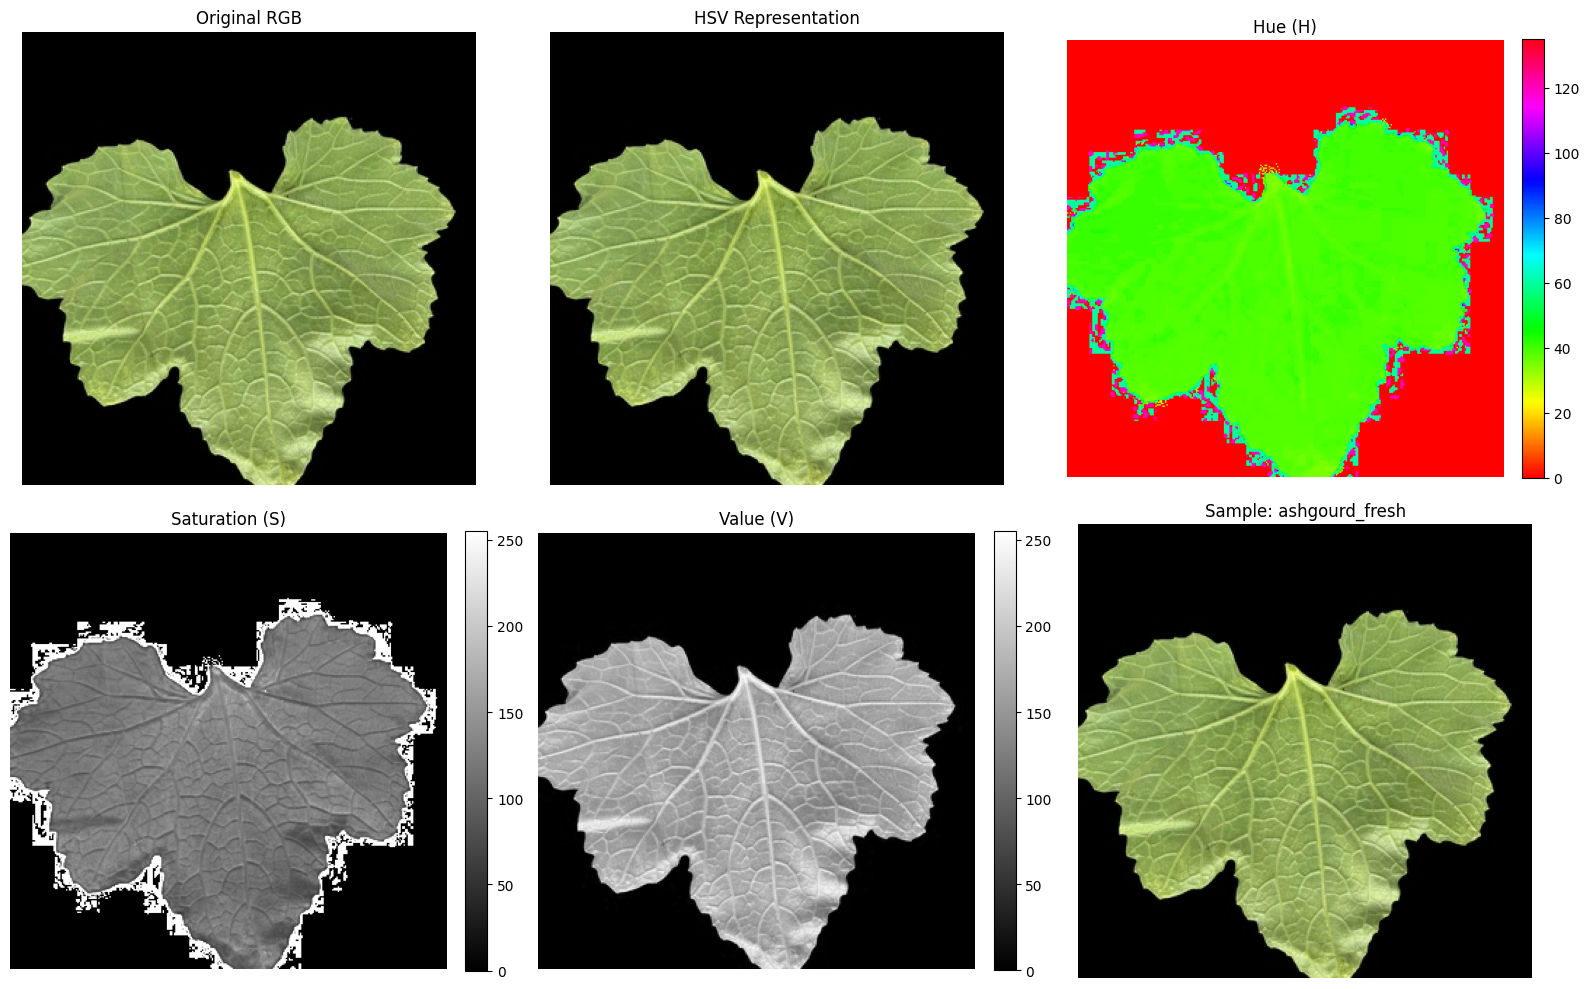


Applying HSV preprocessing...


HSV PREPROCESSING SANITY CHECK
HSV tensor shape: (32, 312, 312, 3)
HSV minimum: 0.0
HSV maximum: 1.0
HSV mean: 0.18266049027442932
Contains NaN: False
Contains Inf: False

Model Summary:



Model: "HSV_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hsv_input (InputLayer)          │ (None, 312, 312, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hsv_to_efficientnet_adapter     │ (None, 312, 312, 3)    │            12 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ adapter_sigmoid (Activation)    │ (None, 312, 312, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ restore_efficientnet_input_ran… │ (None, 312, 312, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 10, 10, 1280)   │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,061,112 (15.49 MB)

 Trainable params: 11,541 (45.08 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

STAGE 1: HSV ADAPTER + CLASSIFICATION HEAD
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.3323 - loss: 1.7832 - val_accuracy: 0.4889 - val_loss: 1.3922 - learning_rate: 0.0010
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.5000 - loss: 1.2954 - val_accuracy: 0.5901 - val_loss: 1.1127 - learning_rate: 0.0010
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.5566 - loss: 1.0929 - val_accuracy: 0.6346 - val_loss: 0.9667 - learning_rate: 0.0010
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.6153 - loss: 0.9645 - val_accuracy: 0.6247 - val_loss: 0.9012 - learning_rate: 0.0010
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.6344 - loss: 0.8985 - val_accuracy: 0.6716 - val_loss: 0.8465 - learning_rate: 0.0010
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.6651 - loss: 0.8462 - val_accuracy: 0.6790 - val_loss: 0.8222 - learning_rate: 0.0010
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accur

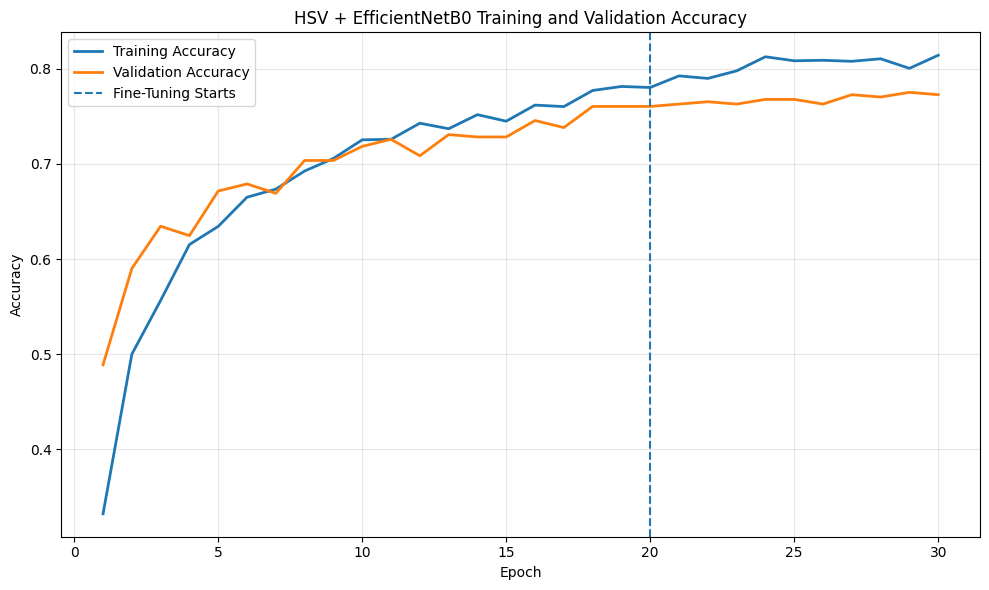

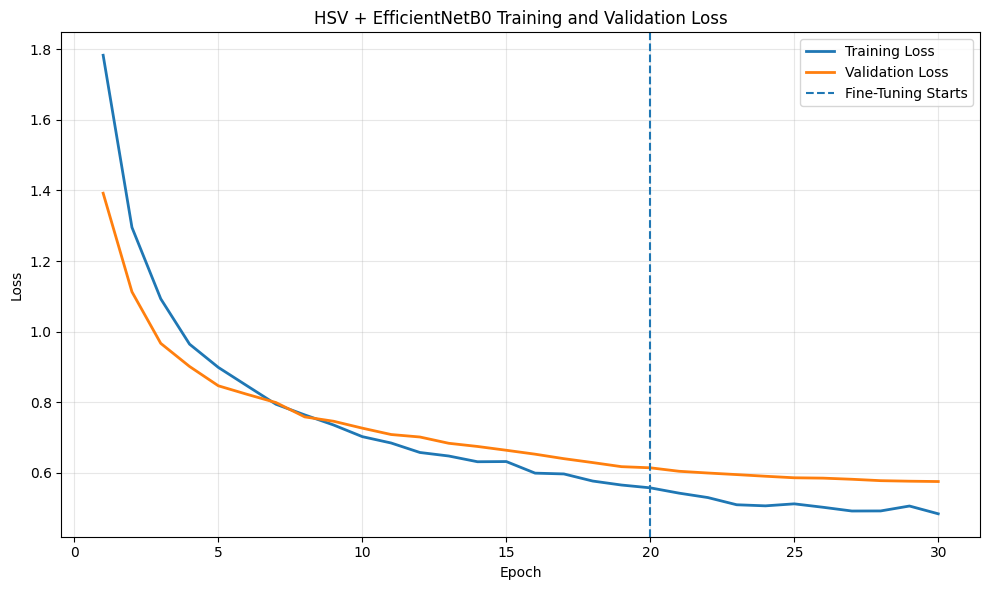



TEST SET EVALUATION
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 372ms/step - accuracy: 0.7728 - loss: 0.5381

Test Loss: 0.5380696058273315
Test Accuracy: 0.7728394865989685

Generating predictions...

Macro F1 Score: 0.7749080848607117
Matthews Correlation Coefficient: 0.7449606797501622


CLASSIFICATION REPORT
                       precision    recall  f1-score   support

       ashgourd_fresh     0.7174    0.7333    0.7253        45
    ashgourd_nitrogen     0.9474    0.8000    0.8675        45
   ashgourd_potassium     0.7059    0.8000    0.7500        45
    bittergourd_fresh     0.5660    0.6667    0.6122        45
 bittergourd_nitrogen     0.6250    0.5556    0.5882        45
bittergourd_potassium     0.9286    0.8667    0.8966        45
     snakegourd_fresh     0.7708    0.8222    0.7957        45
  snakegourd_nitrogen     0.8571    0.8000    0.8276        45
 snakegourd_potassium     0.9111    0.9111    0.9111        45

             accuracy                         0.7728       405
   

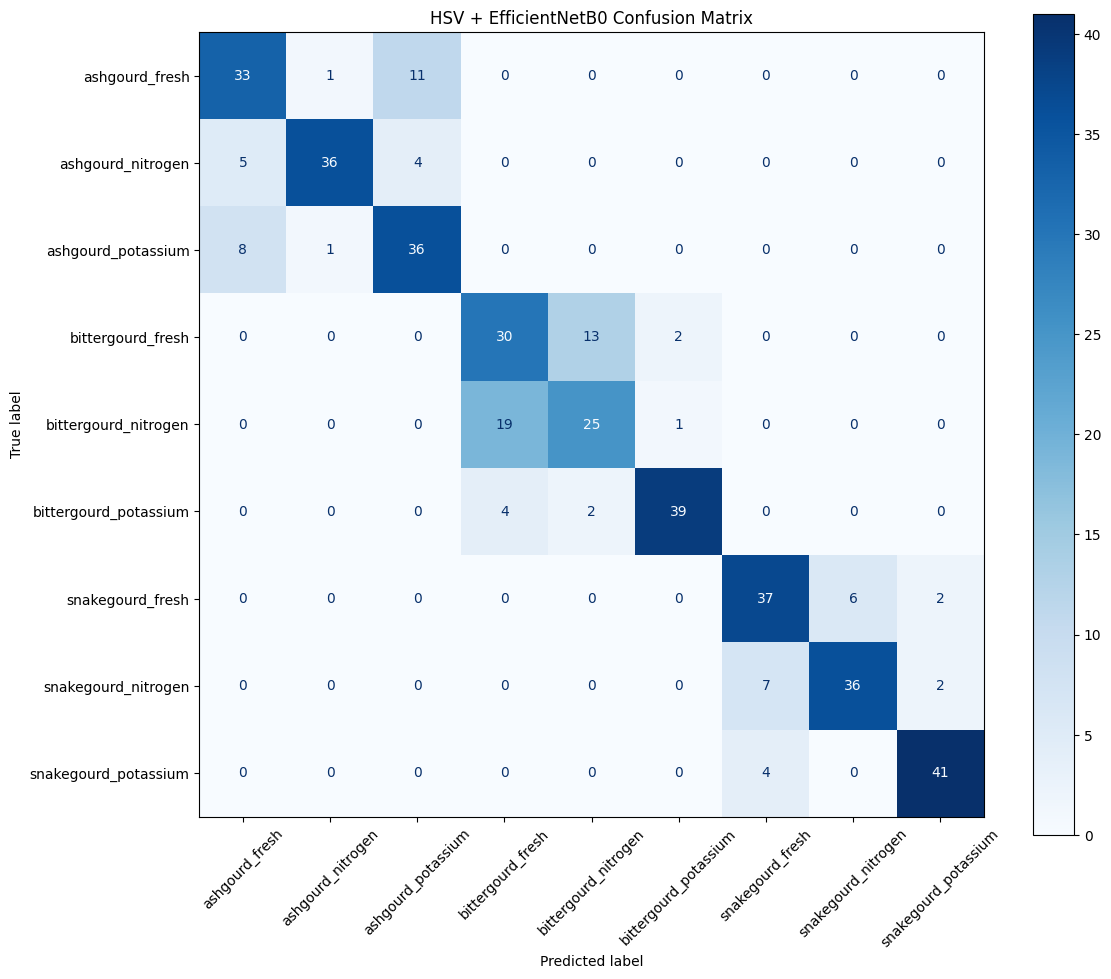



PER-CLASS ACCURACY
ashgourd_fresh: 0.7333
ashgourd_nitrogen: 0.8000
ashgourd_potassium: 0.8000
bittergourd_fresh: 0.6667
bittergourd_nitrogen: 0.5556
bittergourd_potassium: 0.8667
snakegourd_fresh: 0.8222
snakegourd_nitrogen: 0.8000
snakegourd_potassium: 0.9111


MODEL SAVED SUCCESSFULLY
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/HSV_312/HSV_EfficientnetB0_Controlled_FT/HSV_EfficientNetB0_312x312_Dropout02_Normalized_StableFT.keras


FINAL RESULTS
Test Loss       : 0.5381
Test Accuracy   : 0.7728
Macro F1        : 0.7749
MCC             : 0.7450
Total Epochs    : 30
Stage 1         : 20 epochs
Stage 2         : 10 epochs
HSV Adapter     : Trainable
Fine-tuned      : Last 30 EfficientNetB0 layers
BatchNorm       : Frozen
Input           : HSV
HSV Normalized  : H/179, S/255, V/255
Image Size      : 312 x 312
Dropout         : 0.20
ReduceLR        : Factor 0.5, Patience 2, Min LR 1e-7


In [15]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import ReduceLROnPlateau

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    matthews_corrcoef
)


SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)


BASE_ROOT = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output"
)


TRAIN_DIR = os.path.join(
    BASE_ROOT,
    "Train_256"
)


VAL_DIR = os.path.join(
    BASE_ROOT,
    "Val_resized312"
)


TEST_DIR = os.path.join(
    BASE_ROOT,
    "Test_resized312"
)


OUTPUT_DIR = os.path.join(
    BASE_ROOT,
    "HSV_312",
    "HSV_EfficientnetB0_Controlled_FT"
)


os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


IMG_SIZE = (312, 312)

BATCH_SIZE = 32

NUM_CLASSES = 9

DROPOUT_RATE = 0.20

INITIAL_EPOCHS = 20

FINE_TUNE_EPOCHS = 10

TOTAL_EPOCHS = (
    INITIAL_EPOCHS +
    FINE_TUNE_EPOCHS
)


STAGE1_LR = 1e-3

STAGE2_LR = 5e-6


print("\nLoading training dataset...")


train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)


print("\nLoading validation dataset...")


val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


class_names = train_ds.class_names


print(
    "\nNumber of classes:",
    len(class_names)
)


def convert_batch_bgr_to_hsv(batch):

    hsv_batch = np.empty_like(
        batch
    )

    for i in range(
        batch.shape[0]
    ):

        hsv_batch[i] = cv2.cvtColor(
            batch[i],
            cv2.COLOR_BGR2HSV
        )

    return hsv_batch


def rgb_to_hsv_normalized(images):

    images = tf.cast(
        images,
        tf.float32
    )


    images_uint8 = tf.cast(
        tf.clip_by_value(
            images,
            0,
            255
        ),
        tf.uint8
    )


    bgr_images = tf.reverse(
        images_uint8,
        axis=[-1]
    )


    hsv_images = tf.numpy_function(
        func=convert_batch_bgr_to_hsv,
        inp=[bgr_images],
        Tout=tf.uint8
    )


    hsv_images.set_shape(
        images.shape
    )


    hsv_images = tf.cast(
        hsv_images,
        tf.float32
    )


    H = (
        hsv_images[:, :, :, 0:1]
        / 179.0
    )


    S = (
        hsv_images[:, :, :, 1:2]
        / 255.0
    )


    V = (
        hsv_images[:, :, :, 2:3]
        / 255.0
    )


    hsv_normalized = tf.concat(
        [
            H,
            S,
            V
        ],
        axis=-1
    )


    return hsv_normalized


print("\n")
print("=" * 70)
print("HSV IMAGE REPRESENTATION")
print("=" * 70)


visualization_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=1,
    shuffle=False
)


sample_images, sample_labels = next(
    iter(visualization_ds)
)


sample_rgb = sample_images[0].numpy()


sample_rgb_uint8 = np.clip(
    sample_rgb,
    0,
    255
).astype(np.uint8)


sample_bgr = cv2.cvtColor(
    sample_rgb_uint8,
    cv2.COLOR_RGB2BGR
)


sample_hsv = cv2.cvtColor(
    sample_bgr,
    cv2.COLOR_BGR2HSV
)


sample_h = sample_hsv[:, :, 0]

sample_s = sample_hsv[:, :, 1]

sample_v = sample_hsv[:, :, 2]


sample_hsv_display = cv2.cvtColor(
    sample_hsv,
    cv2.COLOR_HSV2RGB
)


sample_class_index = np.argmax(
    sample_labels.numpy()[0]
)


sample_class_name = class_names[
    sample_class_index
]


print(
    "\nSample Class:",
    sample_class_name
)


print(
    "Image Shape:",
    sample_rgb_uint8.shape
)


print(
    "H Range:",
    sample_h.min(),
    "-",
    sample_h.max()
)


print(
    "S Range:",
    sample_s.min(),
    "-",
    sample_s.max()
)


print(
    "V Range:",
    sample_v.min(),
    "-",
    sample_v.max()
)


plt.figure(
    figsize=(16, 10)
)


plt.subplot(
    2,
    3,
    1
)

plt.imshow(
    sample_rgb_uint8
)

plt.title(
    "Original RGB"
)

plt.axis(
    "off"
)


plt.subplot(
    2,
    3,
    2
)

plt.imshow(
    sample_hsv_display
)

plt.title(
    "HSV Representation"
)

plt.axis(
    "off"
)


plt.subplot(
    2,
    3,
    3
)

plt.imshow(
    sample_h,
    cmap="hsv"
)

plt.title(
    "Hue (H)"
)

plt.colorbar(
    fraction=0.046,
    pad=0.04
)

plt.axis(
    "off"
)


plt.subplot(
    2,
    3,
    4
)

plt.imshow(
    sample_s,
    cmap="gray"
)

plt.title(
    "Saturation (S)"
)

plt.colorbar(
    fraction=0.046,
    pad=0.04
)

plt.axis(
    "off"
)


plt.subplot(
    2,
    3,
    5
)

plt.imshow(
    sample_v,
    cmap="gray"
)

plt.title(
    "Value (V)"
)

plt.colorbar(
    fraction=0.046,
    pad=0.04
)

plt.axis(
    "off"
)


plt.subplot(
    2,
    3,
    6
)

plt.imshow(
    sample_rgb_uint8
)

plt.title(
    f"Sample: {sample_class_name}"
)

plt.axis(
    "off"
)


plt.tight_layout()

plt.show()


print("\nApplying HSV preprocessing...")


train_ds_hsv = train_ds.map(
    lambda x, y: (
        rgb_to_hsv_normalized(x),
        y
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)


val_ds_hsv = val_ds.map(
    lambda x, y: (
        rgb_to_hsv_normalized(x),
        y
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)


test_ds_hsv = test_ds.map(
    lambda x, y: (
        rgb_to_hsv_normalized(x),
        y
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)


train_ds_hsv = train_ds_hsv.prefetch(
    tf.data.AUTOTUNE
)


val_ds_hsv = val_ds_hsv.prefetch(
    tf.data.AUTOTUNE
)


test_ds_hsv = test_ds_hsv.prefetch(
    tf.data.AUTOTUNE
)


print("\n")

print("HSV PREPROCESSING SANITY CHECK")



for sample_images, sample_labels in train_ds_hsv.take(1):

    print(
        "HSV tensor shape:",
        sample_images.shape
    )

    print(
        "HSV minimum:",
        float(
            tf.reduce_min(
                sample_images
            ).numpy()
        )
    )

    print(
        "HSV maximum:",
        float(
            tf.reduce_max(
                sample_images
            ).numpy()
        )
    )

    print(
        "HSV mean:",
        float(
            tf.reduce_mean(
                sample_images
            ).numpy()
        )
    )

    print(
        "Contains NaN:",
        bool(
            tf.reduce_any(
                tf.math.is_nan(
                    sample_images
                )
            ).numpy()
        )
    )

    print(
        "Contains Inf:",
        bool(
            tf.reduce_any(
                tf.math.is_inf(
                    sample_images
                )
            ).numpy()
        )
    )

    break


def create_efficientnet_model():

    base_model = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(312, 312, 3)
    )


    base_model.trainable = False


    inputs = layers.Input(
        shape=(312, 312, 3),
        name="hsv_input"
    )


    hsv_adapter = layers.Conv2D(
        filters=3,
        kernel_size=1,
        padding="same",
        use_bias=True,
        name="hsv_to_efficientnet_adapter"
    )(inputs)


    hsv_adapter = layers.Activation(
        "sigmoid",
        name="adapter_sigmoid"
    )(hsv_adapter)


    efficientnet_input = layers.Rescaling(
        255.0,
        name="restore_efficientnet_input_range"
    )(hsv_adapter)


    x = base_model(
        efficientnet_input,
        training=False
    )


    x = layers.GlobalAveragePooling2D(
        name="global_average_pooling2d"
    )(x)


    x = layers.Dropout(
        DROPOUT_RATE,
        name="dropout"
    )(x)


    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="classification"
    )(x)


    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="HSV_EfficientNetB0"
    )


    return model, base_model


model, base_model = create_efficientnet_model()


print("\nModel Summary:\n")

model.summary()


model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=STAGE1_LR
    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)


lr_scheduler_stage1 = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=2,

    min_lr=1e-7,

    verbose=1
)




print("STAGE 1: HSV ADAPTER + CLASSIFICATION HEAD")
history_stage1 = model.fit(

    train_ds_hsv,

    validation_data=val_ds_hsv,

    epochs=INITIAL_EPOCHS,

    callbacks=[
        lr_scheduler_stage1
    ],

    verbose=1
)


print("\n")
print("=" * 70)
print("STAGE 2: EFFICIENTNETB0 FINE-TUNING")
print("=" * 70)
print("\n")


base_model.trainable = True


fine_tune_at = (
    len(base_model.layers)
    - 30
)


print(
    "Total EfficientNetB0 layers:",
    len(base_model.layers)
)


print(
    "Fine-tuning from layer:",
    fine_tune_at
)


for layer_index, layer in enumerate(
    base_model.layers
):

    if layer_index < fine_tune_at:

        layer.trainable = False

    else:

        layer.trainable = True


for layer in base_model.layers:

    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):

        layer.trainable = False


model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=STAGE2_LR
    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)


lr_scheduler_stage2 = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=2,

    min_lr=1e-7,

    verbose=1
)


history_stage2 = model.fit(

    train_ds_hsv,

    validation_data=val_ds_hsv,

    epochs=FINE_TUNE_EPOCHS,

    callbacks=[
        lr_scheduler_stage2
    ],

    verbose=1
)


train_accuracy = (
    history_stage1.history["accuracy"]
    +
    history_stage2.history["accuracy"]
)


val_accuracy = (
    history_stage1.history["val_accuracy"]
    +
    history_stage2.history["val_accuracy"]
)


train_loss = (
    history_stage1.history["loss"]
    +
    history_stage2.history["loss"]
)


val_loss = (
    history_stage1.history["val_loss"]
    +
    history_stage2.history["val_loss"]
)


epochs_range = range(
    1,
    TOTAL_EPOCHS + 1
)


plt.figure(
    figsize=(10, 6)
)


plt.plot(
    epochs_range,
    train_accuracy,
    label="Training Accuracy",
    linewidth=2
)


plt.plot(
    epochs_range,
    val_accuracy,
    label="Validation Accuracy",
    linewidth=2
)


plt.axvline(
    x=20,
    linestyle="--",
    linewidth=1.5,
    label="Fine-Tuning Starts"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Accuracy"
)


plt.title(
    "HSV + EfficientNetB0 Training and Validation Accuracy"
)


plt.legend()


plt.grid(
    True,
    alpha=0.3
)


plt.tight_layout()


plt.show()


plt.figure(
    figsize=(10, 6)
)


plt.plot(
    epochs_range,
    train_loss,
    label="Training Loss",
    linewidth=2
)


plt.plot(
    epochs_range,
    val_loss,
    label="Validation Loss",
    linewidth=2
)


plt.axvline(
    x=20,
    linestyle="--",
    linewidth=1.5,
    label="Fine-Tuning Starts"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.title(
    "HSV + EfficientNetB0 Training and Validation Loss"
)


plt.legend()


plt.grid(
    True,
    alpha=0.3
)


plt.tight_layout()


plt.show()


print("\n")
print("=" * 70)
print("TEST SET EVALUATION")
print("=" * 70)


test_loss, test_accuracy = model.evaluate(

    test_ds_hsv,

    verbose=1
)


print(
    "\nTest Loss:",
    test_loss
)


print(
    "Test Accuracy:",
    test_accuracy
)


print("\nGenerating predictions...")


y_true = []

y_pred = []


for images, labels in test_ds_hsv:

    predictions = model.predict(
        images,
        verbose=0
    )


    predicted_classes = np.argmax(
        predictions,
        axis=1
    )


    true_classes = np.argmax(
        labels.numpy(),
        axis=1
    )


    y_true.extend(
        true_classes
    )


    y_pred.extend(
        predicted_classes
    )


y_true = np.array(
    y_true
)


y_pred = np.array(
    y_pred
)


macro_f1 = f1_score(

    y_true,

    y_pred,

    average="macro"
)


print(
    "\nMacro F1 Score:",
    macro_f1
)


mcc = matthews_corrcoef(

    y_true,

    y_pred
)


print(
    "Matthews Correlation Coefficient:",
    mcc
)


print("\n")
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)


print(
    classification_report(

        y_true,

        y_pred,

        target_names=class_names,

        digits=4
    )
)


cm = confusion_matrix(

    y_true,

    y_pred
)


plt.figure(
    figsize=(12, 10)
)


disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_names
)


disp.plot(

    cmap="Blues",

    xticks_rotation=45,

    ax=plt.gca(),

    values_format="d"
)


plt.title(
    "HSV + EfficientNetB0 Confusion Matrix"
)


plt.tight_layout()


plt.show()


print("\n")
print("=" * 70)
print("PER-CLASS ACCURACY")
print("=" * 70)


for i, class_name in enumerate(
    class_names
):

    total = np.sum(
        cm[i]
    )


    correct = cm[i, i]


    if total > 0:

        class_accuracy = (
            correct /
            total
        )

    else:

        class_accuracy = 0.0


    print(
        f"{class_name}: "
        f"{class_accuracy:.4f}"
    )


MODEL_SAVE_PATH = os.path.join(
    OUTPUT_DIR,
    "HSV_EfficientNetB0_312x312_Dropout02_Normalized_StableFT.keras"
)


model.save(
    MODEL_SAVE_PATH
)


print("\n")
print("=" * 70)
print("MODEL SAVED SUCCESSFULLY")
print("=" * 70)


print(
    MODEL_SAVE_PATH
)


print("\n")
print("=" * 70)
print("FINAL RESULTS")
print("=" * 70)


print(
    f"Test Loss       : "
    f"{test_loss:.4f}"
)


print(
    f"Test Accuracy   : "
    f"{test_accuracy:.4f}"
)


print(
    f"Macro F1        : "
    f"{macro_f1:.4f}"
)


print(
    f"MCC             : "
    f"{mcc:.4f}"
)


print(
    f"Total Epochs    : "
    f"{TOTAL_EPOCHS}"
)


print(
    "Stage 1         : "
    "20 epochs"
)


print(
    "Stage 2         : "
    "10 epochs"
)


print(
    "HSV Adapter     : "
    "Trainable"
)


print(
    "Fine-tuned      : "
    "Last 30 EfficientNetB0 layers"
)


print(
    "BatchNorm       : "
    "Frozen"
)


print(
    "Input           : "
    "HSV"
)


print(
    "HSV Normalized  : "
    "H/179, S/255, V/255"
)


print(
    "Image Size      : "
    "312 x 312"
)


print(
    "Dropout         : "
    "0.20"
)


print(
    "ReduceLR        : "
    "Factor 0.5, Patience 2, Min LR 1e-7"
)


print("=" * 70)

## HSV -- DenceNet


Loading training dataset...
Found 1890 files belonging to 9 classes.

Loading validation dataset...
Found 405 files belonging to 9 classes.

Loading test dataset...
Found 405 files belonging to 9 classes.


E0000 00:00:1790312614.110375  185806 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1790312614.110949  186138 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1790312614.143420  185806 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...



Number of classes: 9

Applying HSV preprocessing...


HSV PREPROCESSING SANITY CHECK
HSV tensor shape: (32, 312, 312, 3)
HSV minimum: 0.0
HSV maximum: 1.0
HSV mean: 0.18266049027442932
Contains NaN: False
Contains Inf: False

Model Summary:



Model: "HSV_DenseNet121"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hsv_input (InputLayer)          │ (None, 312, 312, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hsv_to_densenet_adapter         │ (None, 312, 312, 3)    │            12 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ adapter_sigmoid (Activation)    │ (None, 312, 312, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ restore_densenet_input_range    │ (None, 312, 312, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121_normalization       │ (None, 312, 312, 3)    │             0 │
│ (Lambda)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 9, 9, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 9)              │         9,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,046,741 (26.88 MB)

 Trainable params: 9,237 (36.08 KB)

 Non-trainable params: 7,037,504 (26.85 MB)



STAGE 1: HSV ADAPTER + CLASSIFICATION HEAD


Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.2984 - loss: 1.8523 - val_accuracy: 0.5605 - val_loss: 1.2436 - learning_rate: 0.0010
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.4878 - loss: 1.2761 - val_accuracy: 0.6000 - val_loss: 1.0221 - learning_rate: 0.0010
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.6048 - loss: 1.0396 - val_accuracy: 0.6519 - val_loss: 0.9180 - learning_rate: 0.0010
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.6095 - loss: 0.9722 - val_accuracy: 0.6519 - val_loss: 0.8758 - learning_rate: 0.0010
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.6587 - loss: 0.8865 - val_accuracy: 0.6741 - val_loss: 0.8159 - learning_rate: 0.0010
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.6656 - loss: 0.8449 - val_accuracy: 0.6889 - val_loss: 0.7832 - learning_rate: 0.0010
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/s

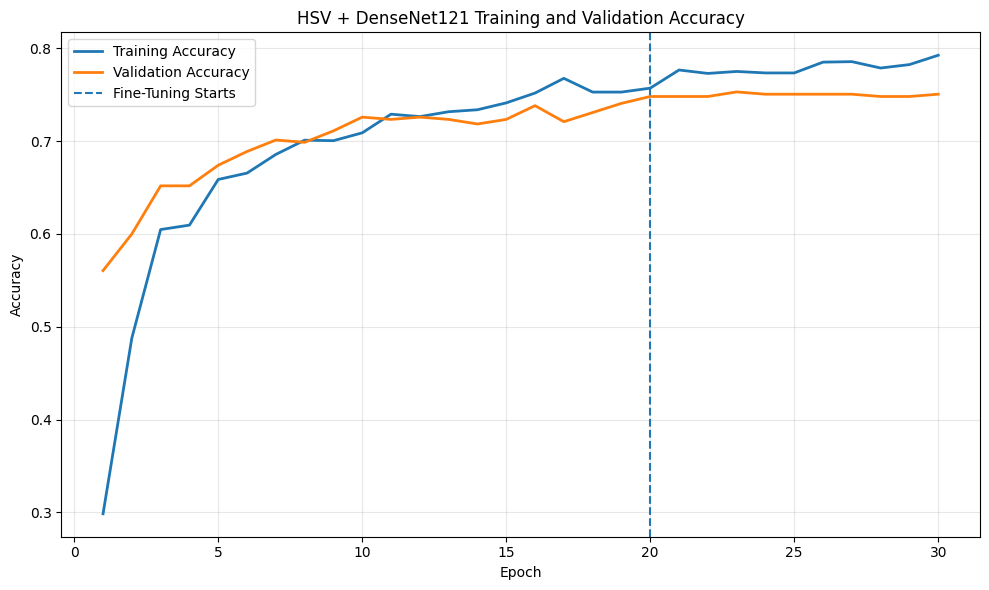

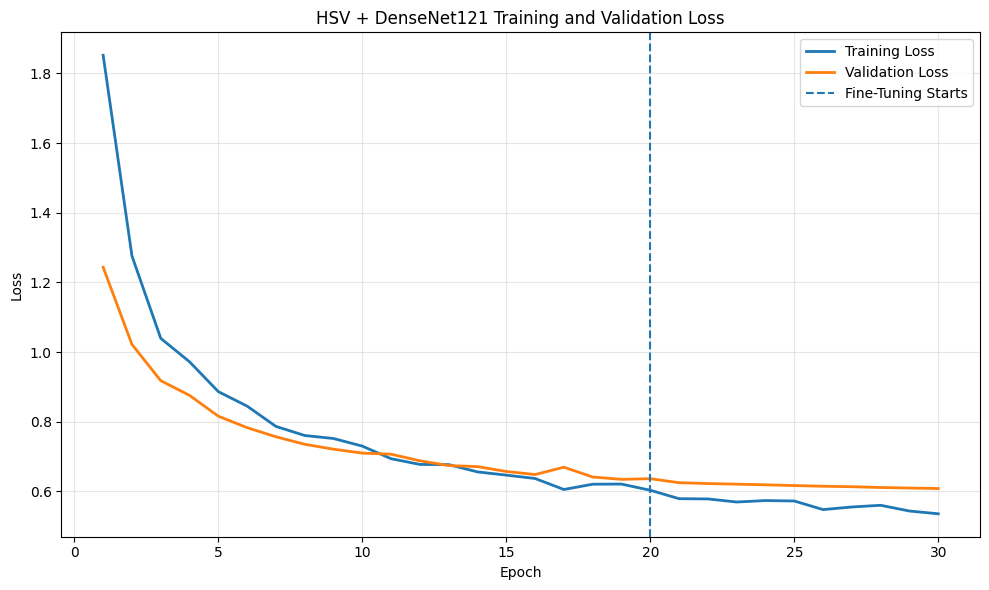



TEST SET EVALUATION
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 872ms/step - accuracy: 0.7728 - loss: 0.5335

Test Loss: 0.5334956645965576
Test Accuracy: 0.7728394865989685

Generating predictions...

Macro F1 Score: 0.7740271151421492
Matthews Correlation Coefficient: 0.7450323219020173


CLASSIFICATION REPORT
                       precision    recall  f1-score   support

       ashgourd_fresh     0.6939    0.7556    0.7234        45
    ashgourd_nitrogen     0.8750    0.7778    0.8235        45
   ashgourd_potassium     0.6383    0.6667    0.6522        45
    bittergourd_fresh     0.6111    0.7333    0.6667        45
 bittergourd_nitrogen     0.6842    0.5778    0.6265        45
bittergourd_potassium     0.9302    0.8889    0.9091        45
     snakegourd_fresh     0.7800    0.8667    0.8211        45
  snakegourd_nitrogen     0.8500    0.7556    0.8000        45
 snakegourd_potassium     0.9545    0.9333    0.9438        45

             accuracy                         0.7728       405
  

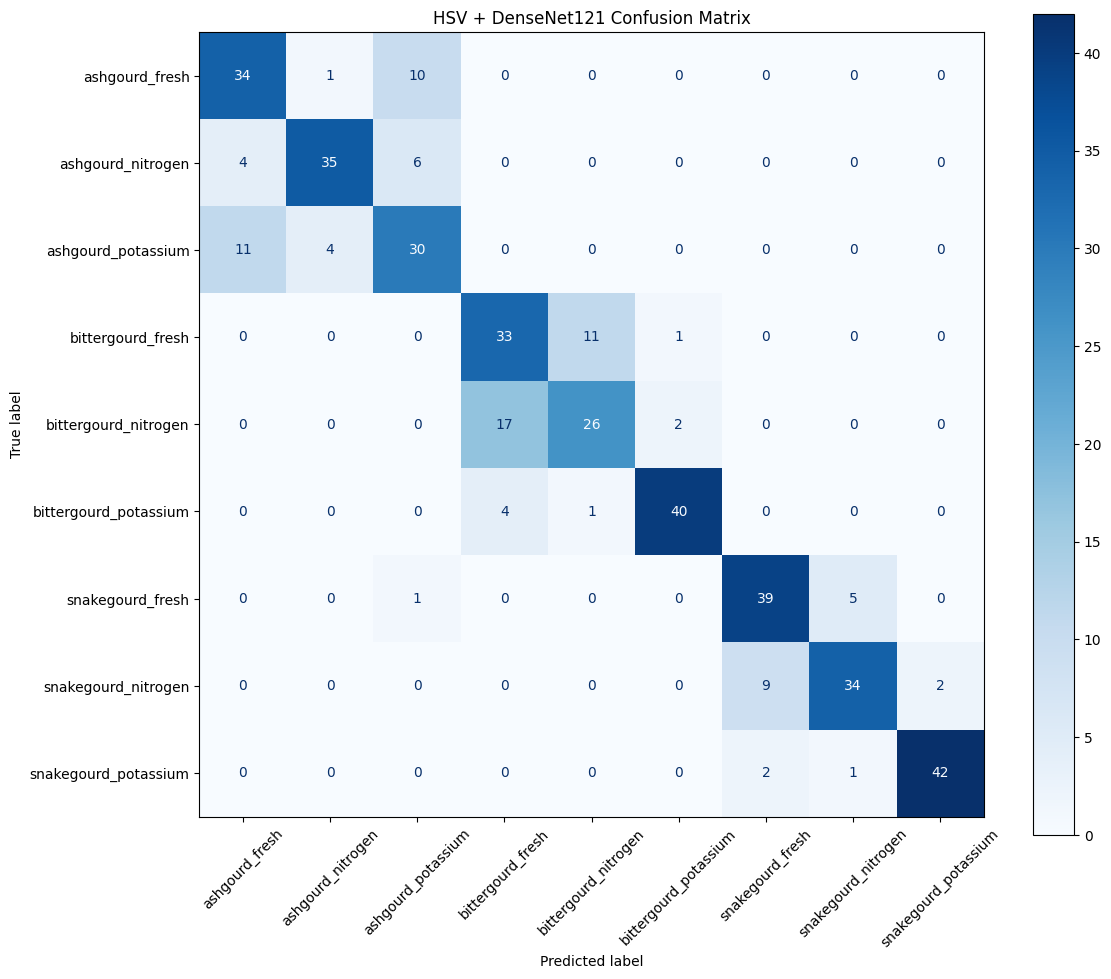



PER-CLASS ACCURACY
ashgourd_fresh: 0.7556
ashgourd_nitrogen: 0.7778
ashgourd_potassium: 0.6667
bittergourd_fresh: 0.7333
bittergourd_nitrogen: 0.5778
bittergourd_potassium: 0.8889
snakegourd_fresh: 0.8667
snakegourd_nitrogen: 0.7556
snakegourd_potassium: 0.9333


MODEL SAVED SUCCESSFULLY
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/HSV_DenseNet121_312x312_Dropout03_Normalized_StableFT.keras


FINAL RESULTS
Test Loss       : 0.5335
Test Accuracy   : 0.7728
Macro F1        : 0.7740
MCC             : 0.7450
Total Epochs    : 30
Stage 1         : 20 epochs
Stage 2         : 10 epochs
HSV Adapter     : Trainable
Fine-tuned      : Last 30 DenseNet121 layers
BatchNorm       : Frozen
Input           : HSV
HSV Normalized  : H/179, S/255, V/255
DenseNet        : ImageNet preprocessing applied
Image Size      : 312 x 312
Dropout         : 0.30


In [ ]:


import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models

from tensorflow.keras.applications import DenseNet121

from tensorflow.keras.callbacks import ReduceLROnPlateau

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    matthews_corrcoef
)


SEED = 42

np.random.seed(SEED)

tf.random.set_seed(SEED)

TRAIN_DIR = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/Train_256"
)

VAL_DIR = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/Val_resized312"
)

TEST_DIR = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/Test_resized312"
)


IMG_SIZE = (312, 312)

BATCH_SIZE = 32

NUM_CLASSES = 9

DROPOUT_RATE = 0.30

INITIAL_EPOCHS = 20

FINE_TUNE_EPOCHS = 10

TOTAL_EPOCHS = (
    INITIAL_EPOCHS +
    FINE_TUNE_EPOCHS
)



STAGE1_LR = 1e-3

STAGE2_LR = 5e-6



print("\nLoading training dataset...")

train_ds = tf.keras.utils.image_dataset_from_directory(

    TRAIN_DIR,

    labels="inferred",

    label_mode="categorical",

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=SEED
)


print("\nLoading validation dataset...")

val_ds = tf.keras.utils.image_dataset_from_directory(

    VAL_DIR,

    labels="inferred",

    label_mode="categorical",

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False
)


print("\nLoading test dataset...")

test_ds = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    labels="inferred",

    label_mode="categorical",

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False
)


class_names = train_ds.class_names

print(
    "\nNumber of classes:",
    len(class_names)
)


def convert_batch_bgr_to_hsv(batch):

    hsv_batch = np.empty_like(batch)

    for i in range(
        batch.shape[0]
    ):

        hsv_batch[i] = cv2.cvtColor(

            batch[i],

            cv2.COLOR_BGR2HSV

        )

    return hsv_batch


# RGB -> HSV + NORMALIZATION


def rgb_to_hsv_normalized(images):



    images = tf.cast(

        images,

        tf.float32

    )

    images_uint8 = tf.cast(

        tf.clip_by_value(

            images,

            0,

            255

        ),

        tf.uint8

    )



    # RGB -> BGR


    bgr_images = tf.reverse(

        images_uint8,

        axis=[-1]

    )



    # BGR -> HSV


    hsv_images = tf.numpy_function(

        func=convert_batch_bgr_to_hsv,

        inp=[bgr_images],

        Tout=tf.uint8

    )


    hsv_images.set_shape(

        images.shape

    )

    hsv_images = tf.cast(

        hsv_images,

        tf.float32

    )


   
    # H CHANNEL
    # OpenCV H = 0-179

    H = (

        hsv_images[:, :, :, 0:1]

        / 179.0

    )


    # S CHANNEL
    # OpenCV S = 0-255


    S = (

        hsv_images[:, :, :, 1:2]

        / 255.0

    )



    # V CHANNEL
    # OpenCV V = 0-255

    V = (

        hsv_images[:, :, :, 2:3]

        / 255.0

    )



    # Combine HSV


    hsv_normalized = tf.concat(

        [

            H,

            S,

            V

        ],

        axis=-1

    )


    return hsv_normalized



# APPLY HSV PREPROCESSING


print(
    "\nApplying HSV preprocessing..."
)


train_ds_hsv = train_ds.map(

    lambda x, y: (

        rgb_to_hsv_normalized(x),

        y

    ),

    num_parallel_calls=tf.data.AUTOTUNE

)


val_ds_hsv = val_ds.map(

    lambda x, y: (

        rgb_to_hsv_normalized(x),

        y

    ),

    num_parallel_calls=tf.data.AUTOTUNE

)


test_ds_hsv = test_ds.map(

    lambda x, y: (

        rgb_to_hsv_normalized(x),

        y

    ),

    num_parallel_calls=tf.data.AUTOTUNE

)



# PREFETCH


train_ds_hsv = train_ds_hsv.prefetch(

    tf.data.AUTOTUNE

)

val_ds_hsv = val_ds_hsv.prefetch(

    tf.data.AUTOTUNE

)

test_ds_hsv = test_ds_hsv.prefetch(

    tf.data.AUTOTUNE

)



# HSV PREPROCESSING SANITY CHECK


print("\n")
print("=" * 70)
print("HSV PREPROCESSING SANITY CHECK")
print("=" * 70)


for sample_images, sample_labels in train_ds_hsv.take(1):

    print(
        "HSV tensor shape:",
        sample_images.shape
    )

    print(
        "HSV minimum:",
        float(
            tf.reduce_min(
                sample_images
            ).numpy()
        )
    )

    print(
        "HSV maximum:",
        float(
            tf.reduce_max(
                sample_images
            ).numpy()
        )
    )

    print(
        "HSV mean:",
        float(
            tf.reduce_mean(
                sample_images
            ).numpy()
        )
    )

    print(
        "Contains NaN:",
        bool(
            tf.reduce_any(
                tf.math.is_nan(
                    sample_images
                )
            ).numpy()
        )
    )

    print(
        "Contains Inf:",
        bool(
            tf.reduce_any(
                tf.math.is_inf(
                    sample_images
                )
            ).numpy()
        )
    )

    break



# CREATE DENSENET121 MODEL


def create_densenet_model():


    # ImageNet pretrained DenseNet121


    base_model = DenseNet121(

        weights="imagenet",

        include_top=False,

        input_shape=(312, 312, 3)

    )


   
    # Freeze DenseNet initially

    base_model.trainable = False



    # Input


    inputs = layers.Input(

        shape=(312, 312, 3),

        name="hsv_input"

    )


    hsv_adapter = layers.Conv2D(

        filters=3,

        kernel_size=1,

        padding="same",

        use_bias=True,

        name="hsv_to_densenet_adapter"

    )(inputs)


    # Keep adapter output in [0,1]


    hsv_adapter = layers.Activation(

        "sigmoid",

        name="adapter_sigmoid"

    )(hsv_adapter)


    densenet_input = layers.Rescaling(

        255.0,

        name="restore_densenet_input_range"

    )(hsv_adapter)



    # DenseNet121 ImageNet preprocessing


    densenet_input = layers.Lambda(

        tf.keras.applications.densenet.preprocess_input,

        name="densenet121_normalization"

    )(densenet_input)


    x = base_model(

        densenet_input,

        training=False

    )


    x = layers.GlobalAveragePooling2D(

        name="global_average_pooling2d"

    )(x)


    x = layers.Dropout(

        DROPOUT_RATE,

        name="dropout"

    )(x)

    outputs = layers.Dense(

        NUM_CLASSES,

        activation="softmax",

        name="classification"

    )(x)


    model = models.Model(

        inputs=inputs,

        outputs=outputs,

        name="HSV_DenseNet121"

    )


    return model, base_model


model, base_model = create_densenet_model()




print("\nModel Summary:\n")

model.summary()


# ============================================================
# STAGE 1 COMPILATION
#
# DenseNet121 frozen.
#
# Trainable:
# - HSV adapter
# - Classification head
# ============================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=STAGE1_LR

    ),

    loss="categorical_crossentropy",

    metrics=[

        "accuracy"

    ]

)


# ============================================================
# STAGE 1 LR SCHEDULER
#
# Requested:
#
# monitor = val_loss
# factor = 0.5
# patience = 5
# min_lr = 1e-5
# ============================================================

lr_scheduler_stage1 = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=5,

    min_lr=1e-5,

    verbose=1

)


# ============================================================
#  STAGE 1 TRAINING
# 20 EPOCHS
# ============================================================

print("\n")
print("=" * 70)
print("STAGE 1: HSV ADAPTER + CLASSIFICATION HEAD")
print("=" * 70)
print("\n")


history_stage1 = model.fit(

    train_ds_hsv,

    validation_data=val_ds_hsv,

    epochs=INITIAL_EPOCHS,

    callbacks=[

        lr_scheduler_stage1

    ],

    verbose=1

)


# ============================================================
# STAGE 2
# STABLE DENSENET121 FINE-TUNING
# ============================================================

print("\n")
print("=" * 70)
print("STAGE 2: DENSENET121 FINE-TUNING")
print("=" * 70)
print("\n")


base_model.trainable = True


# ============================================================
# FIND FINE-TUNING POINT
# ============================================================

fine_tune_at = (

    len(base_model.layers)

    - 30

)


print(

    "Total DenseNet121 layers:",

    len(base_model.layers)

)

print(

    "Fine-tuning from layer:",

    fine_tune_at

)


# ============================================================
# FREEZE EARLIER LAYERS
# ============================================================

for layer_index, layer in enumerate(

    base_model.layers

):

    if layer_index < fine_tune_at:

        layer.trainable = False

    else:

        layer.trainable = True


# ============================================================
# FREEZE ALL BATCH NORMALIZATION LAYERS
# ============================================================

for layer in base_model.layers:

    if isinstance(

        layer,

        tf.keras.layers.BatchNormalization

    ):

        layer.trainable = False


# ============================================================
# RECOMPILE FOR FINE-TUNING
# ============================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=STAGE2_LR

    ),

    loss="categorical_crossentropy",

    metrics=[

        "accuracy"

    ]

)


# ============================================================
# STAGE 2 LR SCHEDULER
# ============================================================

lr_scheduler_stage2 = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=5,

    min_lr=1e-5,

    verbose=1

)


# ============================================================
# STAGE 2 TRAINING
#
# 10 ADDITIONAL EPOCHS
# ============================================================

history_stage2 = model.fit(

    train_ds_hsv,

    validation_data=val_ds_hsv,

    epochs=FINE_TUNE_EPOCHS,

    callbacks=[

        lr_scheduler_stage2

    ],

    verbose=1

)



# COMBINE HISTORIES


train_accuracy = (

    history_stage1.history["accuracy"]

    +

    history_stage2.history["accuracy"]

)


val_accuracy = (

    history_stage1.history["val_accuracy"]

    +

    history_stage2.history["val_accuracy"]

)


train_loss = (

    history_stage1.history["loss"]

    +

    history_stage2.history["loss"]

)


val_loss = (

    history_stage1.history["val_loss"]

    +

    history_stage2.history["val_loss"]

)


epochs_range = range(

    1,

    TOTAL_EPOCHS + 1

)



# COMBINED ACCURACY PLOT


plt.figure(

    figsize=(10, 6)

)

plt.plot(

    epochs_range,

    train_accuracy,

    label="Training Accuracy",

    linewidth=2

)

plt.plot(

    epochs_range,

    val_accuracy,

    label="Validation Accuracy",

    linewidth=2

)

plt.axvline(

    x=20,

    linestyle="--",

    linewidth=1.5,

    label="Fine-Tuning Starts"

)

plt.xlabel(

    "Epoch"

)

plt.ylabel(

    "Accuracy"

)

plt.title(

    "HSV + DenseNet121 Training and Validation Accuracy"

)

plt.legend()

plt.grid(

    True,

    alpha=0.3

)

plt.tight_layout()

plt.show()



# COMBINED LOSS PLOT


plt.figure(

    figsize=(10, 6)

)

plt.plot(

    epochs_range,

    train_loss,

    label="Training Loss",

    linewidth=2

)

plt.plot(

    epochs_range,

    val_loss,

    label="Validation Loss",

    linewidth=2

)

plt.axvline(

    x=20,

    linestyle="--",

    linewidth=1.5,

    label="Fine-Tuning Starts"

)

plt.xlabel(

    "Epoch"

)

plt.ylabel(

    "Loss"

)

plt.title(

    "HSV + DenseNet121 Training and Validation Loss"

)

plt.legend()

plt.grid(

    True,

    alpha=0.3

)

plt.tight_layout()

plt.show()


# TEST SET EVALUATION


print("\n")
print("=" * 70)
print("TEST SET EVALUATION")
print("=" * 70)


test_loss, test_accuracy = model.evaluate(

    test_ds_hsv,

    verbose=1

)


print(

    "\nTest Loss:",

    test_loss

)

print(

    "Test Accuracy:",

    test_accuracy

)


# GENERATE TEST PREDICTIONS


print(

    "\nGenerating predictions..."

)


y_true = []

y_pred = []


for images, labels in test_ds_hsv:

    predictions = model.predict(

        images,

        verbose=0

    )


    predicted_classes = np.argmax(

        predictions,

        axis=1

    )


    true_classes = np.argmax(

        labels.numpy(),

        axis=1

    )


    y_true.extend(

        true_classes

    )


    y_pred.extend(

        predicted_classes

    )


y_true = np.array(

    y_true

)

y_pred = np.array(

    y_pred

)



# MACRO F1


macro_f1 = f1_score(

    y_true,

    y_pred,

    average="macro"

)


print(

    "\nMacro F1 Score:",

    macro_f1

)



# MCC


mcc = matthews_corrcoef(

    y_true,

    y_pred

)


print(

    "Matthews Correlation Coefficient:",

    mcc

)



#  CLASSIFICATION REPORT


print("\n")
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)


print(

    classification_report(

        y_true,

        y_pred,

        target_names=class_names,

        digits=4

    )

)


# CONFUSION MATRIX


cm = confusion_matrix(

    y_true,

    y_pred

)



# CONFUSION MATRIX DISPLAY


plt.figure(

    figsize=(12, 10)

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_names

)

disp.plot(

    cmap="Blues",

    xticks_rotation=45,

    ax=plt.gca(),

    values_format="d"

)

plt.title(

    "HSV + DenseNet121 Confusion Matrix"

)

plt.tight_layout()

plt.show()


# PER-CLASS ACCURACY


print("\n")
print("=" * 70)
print("PER-CLASS ACCURACY")
print("=" * 70)


for i, class_name in enumerate(

    class_names

):

    total = np.sum(

        cm[i]

    )

    correct = cm[i, i]


    if total > 0:

        class_accuracy = (

            correct / total

        )

    else:

        class_accuracy = 0.0


    print(

        f"{class_name}: "

        f"{class_accuracy:.4f}"

    )



# SAVE MODEL


MODEL_SAVE_PATH = (

    "/home/mtech_atul/atul/"

    "Early_Output-20260923T172757Z-1-001/"

    "Early_Output/"

    "HSV_DenseNet121_312x312_"
    "Dropout03_Normalized_StableFT.keras"

)


model.save(

    MODEL_SAVE_PATH

)


# FINAL RESULTS


print("\n")
print("=" * 70)
print("MODEL SAVED SUCCESSFULLY")
print("=" * 70)


print(

    MODEL_SAVE_PATH

)


print("\n")
print("=" * 70)
print("FINAL RESULTS")
print("=" * 70)


print(

    f"Test Loss       : {test_loss:.4f}"

)

print(

    f"Test Accuracy   : {test_accuracy:.4f}"

)

print(

    f"Macro F1        : {macro_f1:.4f}"

)

print(

    f"MCC             : {mcc:.4f}"

)

print(

    f"Total Epochs    : {TOTAL_EPOCHS}"

)

print(

    "Stage 1         : 20 epochs"

)

print(

    "Stage 2         : 10 epochs"

)

print(
a
    "HSV Adapter     : Trainable"

)

print(

    "Fine-tuned      : Last 30 DenseNet121 layers"

)

print(

    "BatchNorm       : Frozen"

)

print(

    "Input           : HSV"

)

print(

    "HSV Normalized  : H/179, S/255, V/255"

)

print(

    "DenseNet        : ImageNet preprocessing applied"

)

print(

    "Image Size      : 312 x 312"

)

print(

    "Dropout         : 0.30"

)


## CIELUV -- MobileNet

CIELUV + MOBILENETV2
CONTROLLED FINE-TUNING + REGULARIZATION
TensorFlow version: 2.21.0
Random Seed: 42

CLASS MAPPING
0 -> ashgourd_fresh
1 -> ashgourd_nitrogen
2 -> ashgourd_potassium
3 -> bittergourd_fresh
4 -> bittergourd_nitrogen
5 -> bittergourd_potassium
6 -> snakegourd_fresh
7 -> snakegourd_nitrogen
8 -> snakegourd_potassium

Checking dataset directories...
FOUND: /home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Train_256
FOUND: /home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Val_resized312
FOUND: /home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Test_resized312

Loading TRAIN dataset...
Found 1890 files belonging to 9 classes.

Loading VALIDATION dataset...
Found 405 files belonging to 9 classes.

Loading TEST dataset...
Found 405 files belonging to 9 classes.

Dataset class order:
['ashgourd_fresh', 'ashgourd_nitrogen', 'ashgourd_potassium', 'bittergourd_fresh', 'bittergourd_nitrogen', 'bittergourd_potassium', 

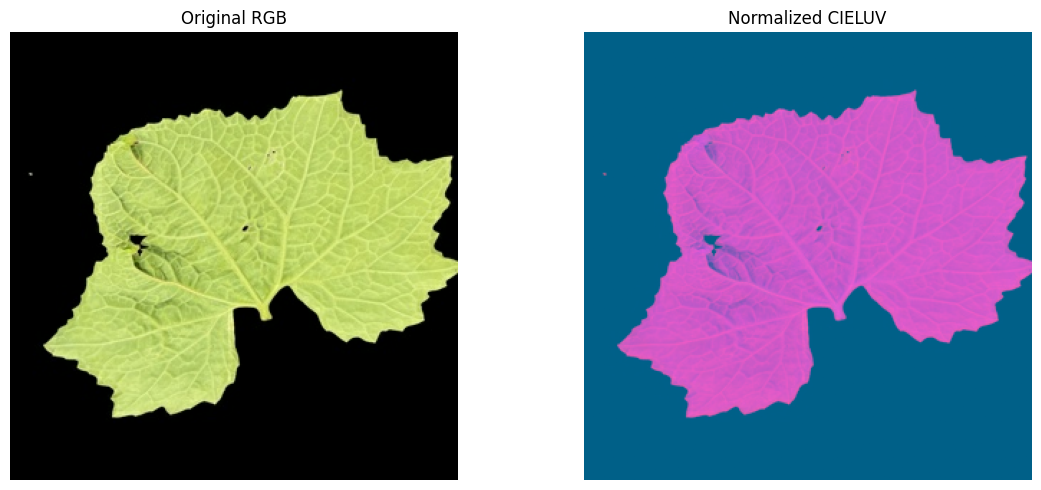



BUILDING MOBILENETV2


/tmp/ipykernel_185806/1745734038.py:887: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "CIELUV_MobileNetV2_Controlled_FT"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ CIELUV_Input (InputLayer)       │ (None, 312, 312, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CIELUV_to_MobileNet_Range       │ (None, 312, 312, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 10, 10, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GlobalAveragePooling            │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Feature_BatchNormalization      │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_128 (Dense)               │ (None, 128)            │       163,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_BatchNormalization        │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ReLU (Activation)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_40 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Classification_Head (Dense)     │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,617 (9.26 MB)

 Trainable params: 167,817 (655.54 KB)

 Non-trainable params: 2,260,800 (8.62 MB)



STAGE 1 — FROZEN MOBILENETV2
Color Space        : CIELUV
Image Size         : 312 x 312
Batch Size         : 32
Epochs             : 20
Initial LR         : 0.001
Backbone           : FROZEN
Dropout            : 0.40
Batch Normalization: ENABLED
ReduceLROnPlateau  : ENABLED
Training Shuffle   : TRUE
Shuffle Seed       : 42
Epoch 1/20
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.4311 - loss: 1.5838
Epoch 1: val_loss improved from None to 1.00222, saving model to /home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/CIELUV_312/MobileNetV2_Controlled_FT/stage1_best.keras

STAGE 1 | Epoch 1/20
Train Loss: 1.1890 | Train Accuracy: 0.5540
Val Loss: 1.0022 | Val Accuracy: 0.6519
Learning Rate: 0.0010000000
60/60 ━━━━━━━━━━━━━━━━━━━━ 26s 383ms/step - accuracy: 0.5540 - loss: 1.1890 - val_accuracy: 0.6519 - val_loss: 1.0022 - learning_rate: 0.0010
Epoch 2/20
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.7143 - loss: 0.7188
Epoch 2: val_loss improved from 1.

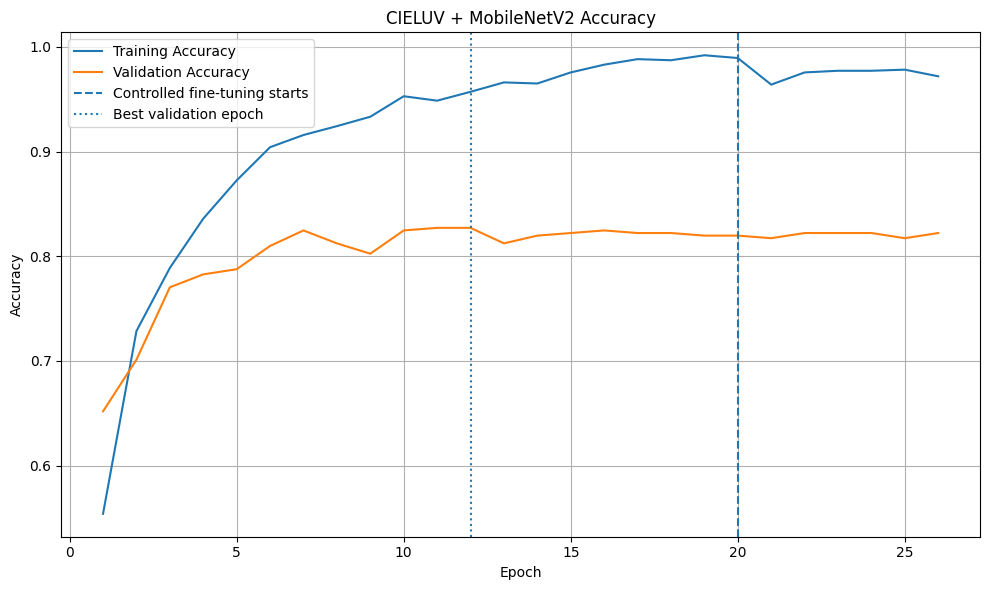

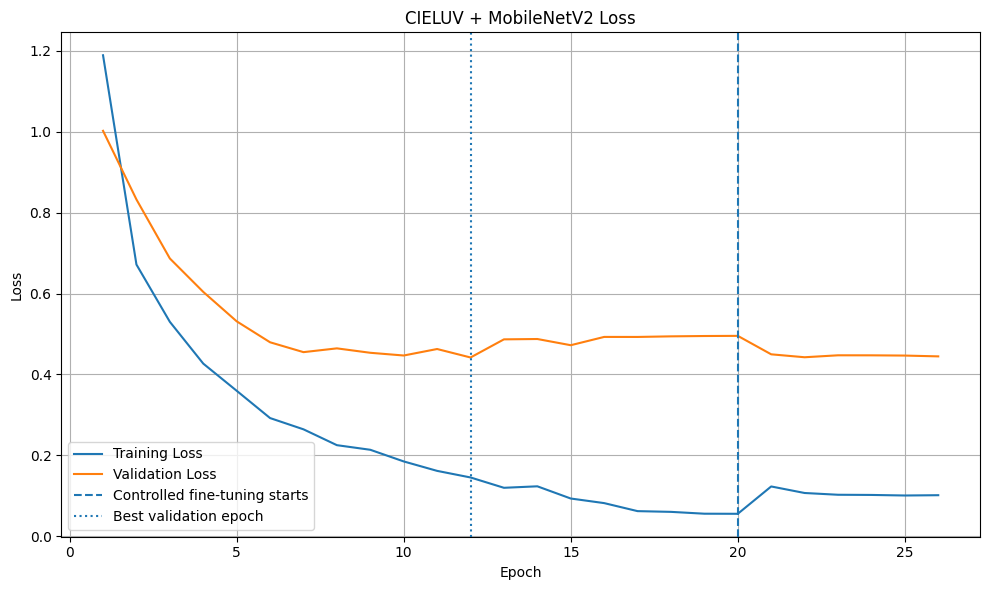



GENERATING TEST PREDICTIONS


CIELUV + MOBILENETV2 TEST RESULTS
Test Accuracy : 0.8222
Macro F1      : 0.8225
MCC           : 0.8000

CLASSIFICATION REPORT

                       precision    recall  f1-score   support

       ashgourd_fresh     0.7273    0.7111    0.7191        45
    ashgourd_nitrogen     0.8936    0.9333    0.9130        45
   ashgourd_potassium     0.7333    0.7333    0.7333        45
    bittergourd_fresh     0.6444    0.6444    0.6444        45
 bittergourd_nitrogen     0.6522    0.6667    0.6593        45
bittergourd_potassium     0.9545    0.9333    0.9438        45
     snakegourd_fresh     0.8723    0.9111    0.8913        45
  snakegourd_nitrogen     0.9302    0.8889    0.9091        45
 snakegourd_potassium     1.0000    0.9778    0.9888        45

             accuracy                         0.8222       405
            macro avg     0.8231    0.8222    0.8225       405
         weighted avg     0.8231    0.8222    0.8225       405



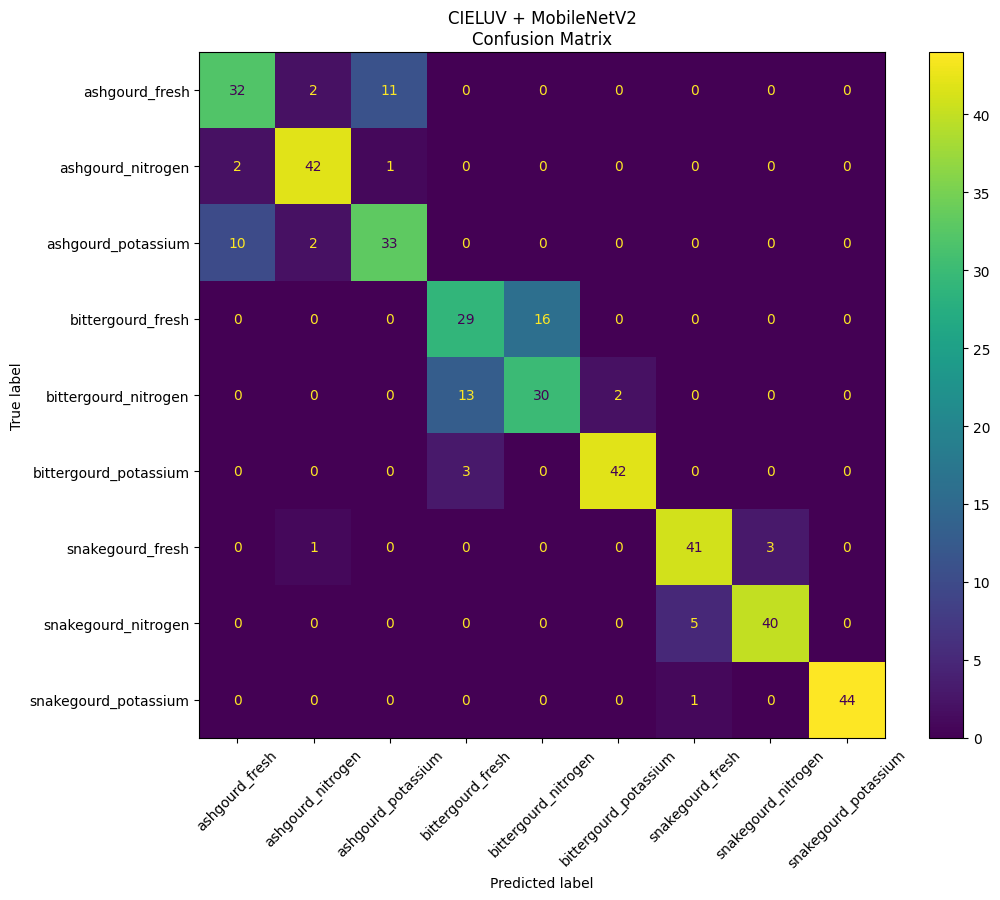



CIELUV + MOBILENETV2 EXPERIMENT COMPLETED
Color Space           : CIELUV
Model                 : MobileNetV2
Input Size            : 312 x 312
Batch Size            : 32
Stage 1               : 20 epochs
Stage 1 Initial LR    : 0.001
Stage 2 Maximum       : 10 epochs
Stage 2 Initial LR    : 0.000001
Fine-tuned Layers     : Last 30
MobileNetV2 BN        : FROZEN
Dropout               : 0.40
Batch Normalization   : ENABLED
ReduceLROnPlateau     : ENABLED
EarlyStopping         : ENABLED
Gradient Clipnorm     : 1.0
Training Shuffle      : TRUE
Validation Shuffle    : FALSE
Test Shuffle          : FALSE
Random Seed           : 42
Best Epoch            : 12
Best Val Loss         : 0.4418
Best Val Accuracy     : 0.8272
Test Accuracy         : 0.8222
Macro F1              : 0.8225
MCC                   : 0.8000

Final model:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/CIELUV_312/MobileNetV2_Controlled_FT/CIELUV_MobileNetV2_Controlled_FT_final.keras

Output director

In [ ]:


import os
import random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    CSVLogger,
    ReduceLROnPlateau,
    EarlyStopping
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)

np.random.seed(SEED)

tf.random.set_seed(SEED)


print("=" * 75)
print("CIELUV + MOBILENETV2")
print("CONTROLLED FINE-TUNING + REGULARIZATION")
print("=" * 75)

print("TensorFlow version:", tf.__version__)
print("Random Seed:", SEED)

print("=" * 75)




BASE_ROOT = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output"
)


TRAIN_DIR = os.path.join(
    BASE_ROOT,
    "Train_256"
)


VAL_DIR = os.path.join(
    BASE_ROOT,
    "Val_resized312"
)


TEST_DIR = os.path.join(
    BASE_ROOT,
    "Test_resized312"
)


OUTPUT_DIR = os.path.join(
    BASE_ROOT,
    "CIELUV_312",
    "MobileNetV2_Controlled_FT"
)


os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


IMG_SIZE = 312

BATCH_SIZE = 32

NUM_CLASSES = 9



# TWO-STAGE TRAINING


STAGE1_EPOCHS = 20

STAGE2_EPOCHS = 10


# LEARNING RATES


STAGE1_LR = 1e-3

STAGE2_LR = 1e-6

# REGULARIZATION
DROPOUT_RATE = 0.40

DENSE_UNITS = 128



# CONTROLLED FINE-TUNING
FINE_TUNE_LAYERS = 30



# REDUCE LR SETTINGS

LR_REDUCTION_FACTOR = 0.5

LR_PATIENCE = 2

MIN_LR = 1e-8



# EARLY STOPPING


EARLY_STOP_PATIENCE = 4

CLASS_NAMES = [

    "ashgourd_fresh",

    "ashgourd_nitrogen",

    "ashgourd_potassium",

    "bittergourd_fresh",

    "bittergourd_nitrogen",

    "bittergourd_potassium",

    "snakegourd_fresh",

    "snakegourd_nitrogen",

    "snakegourd_potassium"
]


print("\nCLASS MAPPING")

for i, name in enumerate(CLASS_NAMES):

    print(
        f"{i} -> {name}"
    )



print("\nLoading TRAIN dataset...")


train_ds = tf.keras.utils.image_dataset_from_directory(

    TRAIN_DIR,

    labels="inferred",

    label_mode="int",

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    batch_size=BATCH_SIZE,


    # TRAINING SHUFFLING


    shuffle=True,

    seed=SEED
)


# LOAD VALIDATION DATASET


print("\nLoading VALIDATION dataset...")


val_ds = tf.keras.utils.image_dataset_from_directory(

    VAL_DIR,

    labels="inferred",

    label_mode="int",

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    batch_size=BATCH_SIZE,

    # No validation shuffling

    shuffle=False
)



# LOAD TEST DATASET


print("\nLoading TEST dataset...")


test_ds = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    labels="inferred",

    label_mode="int",

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    batch_size=BATCH_SIZE,

    # No test shuffling

    shuffle=False
)



# VERIFY CLASS ORDER


print("\nDataset class order:")

print(
    train_ds.class_names
)



# DATASET INFORMATION


print("\nDataset information:")


print(
    "Training batches:",
    tf.data.experimental.cardinality(
        train_ds
    ).numpy()
)


print(
    "Validation batches:",
    tf.data.experimental.cardinality(
        val_ds
    ).numpy()
)


print(
    "Test batches:",
    tf.data.experimental.cardinality(
        test_ds
    ).numpy()
)



# CIELUV CONVERTER


class Converter:

    """
    CIELUV converter.

    Input:
        BGR uint8 image [0,255]

    Output:
        normalized CIELUV [0,1]
    """


    def __init__(self):

        pass


    # HSV
    def to_hsv(
        self,
        im
    ):

        return cv2.cvtColor(
            im,
            cv2.COLOR_BGR2HSV
        )



    # CIELAB


    def to_cielab(
        self,
        im
    ):

        return cv2.cvtColor(
            im,
            cv2.COLOR_BGR2Lab
        )


 
    # CIELUV

    def to_cieluv(
        self,
        im
    ):

        return cv2.cvtColor(
            im,
            cv2.COLOR_BGR2Luv
        )


  
    # NORMALIZED CIELUV

    def to_cieluv_normalized(
        self,
        im
    ):

        # BGR -> CIELUV

        luv = cv2.cvtColor(
            im,
            cv2.COLOR_BGR2Luv
        )


        luv = luv.astype(
            np.float32
        ) / 255.0


        return luv


# Create converter

converter = Converter()


# TEST CIELUV CONVERSION


print(
    "\nTesting CIELUV conversion..."
)


for images, labels in train_ds.take(1):


    sample_rgb = images[0].numpy().astype(
        np.uint8
    )


    # RGB -> BGR

    sample_bgr = cv2.cvtColor(
        sample_rgb,
        cv2.COLOR_RGB2BGR
    )


    # BGR -> CIELUV

    sample_cieluv = converter.to_cieluv_normalized(
        sample_bgr
    )


    print(
        "\nOriginal RGB shape:",
        sample_rgb.shape
    )


    print(
        "CIELUV shape:",
        sample_cieluv.shape
    )


    print(
        "CIELUV dtype:",
        sample_cieluv.dtype
    )


    print(
        "CIELUV minimum:",
        sample_cieluv.min()
    )


    print(
        "CIELUV maximum:",
        sample_cieluv.max()
    )


    break


# CIELUV BATCH CONVERSION


def convert_batch_to_cieluv(
    images
):


    def convert_numpy(
        batch
    ):

        batch = batch.astype(
            np.uint8
        )


        output = []


        for image in batch:


            # RGB -> BGR

            bgr = cv2.cvtColor(
                image,
                cv2.COLOR_RGB2BGR
            )


            # BGR -> CIELUV

            luv = converter.to_cieluv_normalized(
                bgr
            )


            output.append(
                luv
            )


        return np.stack(
            output
        ).astype(
            np.float32
        )


    cieluv_images = tf.numpy_function(

        convert_numpy,

        [images],

        tf.float32
    )


    # Restore shape

    cieluv_images.set_shape(
        images.shape
    )


    return cieluv_images



# CIELUV PREPROCESSING


def cieluv_preprocessing(
    images,
    labels
):

    images = convert_batch_to_cieluv(
        images
    )


    return (
        images,
        labels
    )



# APPLY CIELUV TO TRAIN


print(
    "\nConverting TRAIN images to CIELUV..."
)


train_cieluv = train_ds.map(

    cieluv_preprocessing,

    num_parallel_calls=tf.data.AUTOTUNE
)



# APPLY CIELUV TO VALIDATION


print(
    "Converting VALIDATION images to CIELUV..."
)


val_cieluv = val_ds.map(

    cieluv_preprocessing,

    num_parallel_calls=tf.data.AUTOTUNE
)



# APPLY CIELUV TO TEST


print(
    "Converting TEST images to CIELUV..."
)


test_cieluv = test_ds.map(

    cieluv_preprocessing,

    num_parallel_calls=tf.data.AUTOTUNE
)


# PREFETCH


train_cieluv = train_cieluv.prefetch(
    tf.data.AUTOTUNE
)


val_cieluv = val_cieluv.prefetch(
    tf.data.AUTOTUNE
)


test_cieluv = test_cieluv.prefetch(
    tf.data.AUTOTUNE
)



# CIELUV DATASET VERIFICATION


print("\n")

print("=" * 75)

print(
    "CIELUV DATASET VERIFICATION"
)

print("=" * 75)


for images, labels in train_cieluv.take(1):


    print(
        "Image shape:",
        images.shape
    )


    print(
        "Image dtype:",
        images.dtype
    )


    print(
        "Minimum value:",
        tf.reduce_min(
            images
        ).numpy()
    )


    print(
        "Maximum value:",
        tf.reduce_max(
            images
        ).numpy()
    )


    print(
        "Labels:",
        labels.numpy()
    )


    break


print("=" * 75)



# VISUALIZE RGB VS CIELUV


for images, labels in train_ds.take(1):


    rgb_image = images[0].numpy().astype(
        np.uint8
    )


    bgr_image = cv2.cvtColor(
        rgb_image,
        cv2.COLOR_RGB2BGR
    )


    cieluv_image = converter.to_cieluv_normalized(
        bgr_image
    )


    break



# DISPLAY RGB AND CIELUV


plt.figure(
    figsize=(12, 5)
)


plt.subplot(
    1,
    2,
    1
)


plt.imshow(
    rgb_image
)


plt.title(
    "Original RGB"
)


plt.axis(
    "off"
)


plt.subplot(
    1,
    2,
    2
)


plt.imshow(
    cieluv_image
)


plt.title(
    "Normalized CIELUV"
)


plt.axis(
    "off"
)


plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "RGB_vs_CIELUV.png"
    ),

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# BUILD MOBILENETV2


print("\n")

print("=" * 75)

print(
    "BUILDING MOBILENETV2"
)

print("=" * 75)


base_model = MobileNetV2(

    include_top=False,

    weights="imagenet",

    input_shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    )
)



# FREEZE BACKBONE FOR STAGE 1


base_model.trainable = False



# MODEL INPUT
inputs = layers.Input(

    shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    ),

    name="CIELUV_Input"
)



# CIELUV [0,1] -> MOBILENETV2 [-1,1]


x = layers.Rescaling(

    scale=2.0,

    offset=-1.0,

    name="CIELUV_to_MobileNet_Range"

)(inputs)


x = base_model(

    x,

    training=False
)


x = layers.GlobalAveragePooling2D(

    name="GlobalAveragePooling"

)(x)


x = layers.BatchNormalization(

    name="Feature_BatchNormalization"

)(x)




x = layers.Dense(

    DENSE_UNITS,

    use_bias=False,

    name="Dense_128"

)(x)



x = layers.BatchNormalization(

    name="Dense_BatchNormalization"

)(x)


x = layers.Activation(

    "relu",

    name="ReLU"

)(x)

=

x = layers.Dropout(

    DROPOUT_RATE,

    name="Dropout_40"

)(x)




outputs = layers.Dense(

    NUM_CLASSES,

    activation="softmax",

    name="Classification_Head"

)(x)


# CREATE MODEL


model = models.Model(

    inputs=inputs,

    outputs=outputs,

    name="CIELUV_MobileNetV2_Controlled_FT"

)




model.summary()



# STAGE 1 COMPILE


model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=STAGE1_LR,

        clipnorm=1.0

    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)



# EPOCH PERFORMANCE CALLBACK


class EpochPerformanceCallback(
    tf.keras.callbacks.Callback
):


    def __init__(
        self,
        stage_name,
        total_epochs
    ):

        super().__init__()

        self.stage_name = stage_name

        self.total_epochs = total_epochs


    def on_epoch_end(
        self,
        epoch,
        logs=None
    ):

        logs = logs or {}


        train_loss = logs.get(
            "loss",
            0
        )


        train_acc = logs.get(
            "accuracy",
            0
        )


        val_loss = logs.get(
            "val_loss",
            0
        )


        val_acc = logs.get(
            "val_accuracy",
            0
        )


        try:

            current_lr = float(
                tf.keras.backend.get_value(
                    self.model.optimizer.learning_rate
                )
            )

        except Exception:

            current_lr = 0.0


        print(
            f"\n{self.stage_name} | "
            f"Epoch {epoch + 1}/{self.total_epochs}"
        )


        print(
            f"Train Loss: {train_loss:.4f} | "
            f"Train Accuracy: {train_acc:.4f}"
        )


        print(
            f"Val Loss: {val_loss:.4f} | "
            f"Val Accuracy: {val_acc:.4f}"
        )


        print(
            f"Learning Rate: {current_lr:.10f}"
        )



# STAGE 1 CALLBACKS


stage1_checkpoint = os.path.join(

    OUTPUT_DIR,

    "stage1_best.keras"
)


stage1_csv = os.path.join(

    OUTPUT_DIR,

    "stage1_training_log.csv"
)


stage1_callbacks = [

    ModelCheckpoint(

        stage1_checkpoint,

        monitor="val_loss",

        save_best_only=True,

        mode="min",

        verbose=1
    ),


    CSVLogger(

        stage1_csv,

        append=False
    ),


    ReduceLROnPlateau(

        monitor="val_loss",

        factor=LR_REDUCTION_FACTOR,

        patience=LR_PATIENCE,

        min_lr=MIN_LR,

        verbose=1
    ),


    EpochPerformanceCallback(

        "STAGE 1",

        STAGE1_EPOCHS
    )
]



#  STAGE 1 TRAINING


print("\n")

print("=" * 75)

print(
    "STAGE 1 — FROZEN MOBILENETV2"
)

print("=" * 75)


print(
    "Color Space        : CIELUV"
)

print(
    "Image Size         : 312 x 312"
)

print(
    "Batch Size         : 32"
)

print(
    "Epochs             : 20"
)

print(
    "Initial LR         : 0.001"
)

print(
    "Backbone           : FROZEN"
)

print(
    "Dropout            : 0.40"
)

print(
    "Batch Normalization: ENABLED"
)

print(
    "ReduceLROnPlateau  : ENABLED"
)

print(
    "Training Shuffle   : TRUE"
)

print(
    "Shuffle Seed       : 42"
)

print("=" * 75)


history_stage1 = model.fit(

    train_cieluv,

    validation_data=val_cieluv,

    epochs=STAGE1_EPOCHS,

    callbacks=stage1_callbacks,

    verbose=1
)



#  LOAD BEST STAGE 1 MODEL


print(
    "\nLoading best Stage 1 model..."
)


model = tf.keras.models.load_model(

    stage1_checkpoint
)


base_model = None


for layer in model.layers:

    if "mobilenetv2" in layer.name.lower():

        base_model = layer

        break



# FALLBACK


if base_model is None:

    for layer in model.layers:

        if isinstance(
            layer,
            tf.keras.Model
        ):

            if "mobilenet" in layer.name.lower():

                base_model = layer

                break


if base_model is None:

    raise RuntimeError(
        "MobileNetV2 backbone could not be found."
    )


print(
    "\nMobileNetV2 backbone found:"
)

print(
    base_model.name
)



#  CONTROLLED FINE-TUNING


print("\n")

print("=" * 75)

print(
    "CONTROLLED FINE-TUNING"
)

print("=" * 75)



# STEP 1
# Freeze entire backbone


base_model.trainable = False


# STEP 2


for layer in base_model.layers[-FINE_TUNE_LAYERS:]:


    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):

        layer.trainable = False

    else:

        layer.trainable = True



# PRINT FINE-TUNING


trainable_count = 0

frozen_count = 0

trainable_names = []


for layer in base_model.layers:

    if layer.trainable:

        trainable_count += 1

        trainable_names.append(
            layer.name
        )

    else:

        frozen_count += 1


print(
    "Total MobileNetV2 layers:",
    len(base_model.layers)
)


print(
    "Frozen layers:",
    frozen_count
)


print(
    "Trainable layers:",
    trainable_count
)


print(
    "Requested last layers:",
    FINE_TUNE_LAYERS
)


print(
    "MobileNetV2 BatchNorm: FROZEN"
)


print(
    "\nTrainable MobileNetV2 layers:"
)


for name in trainable_names:

    print(
        "  ",
        name
    )


print("=" * 75)


# COMPILE STAGE 2


model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=STAGE2_LR,

        clipnorm=1.0

    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)


# STAGE 2 CALLBACKS


stage2_checkpoint = os.path.join(

    OUTPUT_DIR,

    "best_model.keras"
)


stage2_csv = os.path.join(

    OUTPUT_DIR,

    "stage2_training_log.csv"
)


stage2_callbacks = [


    # BEST VALIDATION LOSS


    ModelCheckpoint(

        stage2_checkpoint,

        monitor="val_loss",

        save_best_only=True,

        mode="min",

        verbose=1
    ),


    # CSV LOG


    CSVLogger(

        stage2_csv,

        append=False
    ),



    # REDUCE LR
  

    ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.5,

        patience=2,

        min_lr=1e-8,

        verbose=1
    ),


    # EARLY STOPPING


    EarlyStopping(

        monitor="val_loss",

        patience=4,

        mode="min",

        restore_best_weights=True,

        verbose=1
    ),



    # EPOCH OUTPUT


    EpochPerformanceCallback(

        "STAGE 2",

        STAGE2_EPOCHS
    )
]


# STAGE 2 TRAINING


print("\n")

print("=" * 75)

print(
    "STAGE 2 — CONTROLLED FINE-TUNING"
)

print("=" * 75)


print(
    "Color Space        : CIELUV"
)

print(
    "Epochs Maximum     : 10"
)

print(
    "Initial LR         : 0.000001"
)

print(
    "Trainable Layers   : LAST 30"
)

print(
    "MobileNetV2 BN     : FROZEN"
)

print(
    "Dropout            : 0.40"
)

print(
    "Batch Normalization: ENABLED"
)

print(
    "ReduceLROnPlateau  : ENABLED"
)

print(
    "EarlyStopping      : ENABLED"
)

print(
    "Gradient Clipping  : 1.0"
)

print("=" * 75)


history_stage2 = model.fit(

    train_cieluv,

    validation_data=val_cieluv,

    epochs=STAGE2_EPOCHS,

    callbacks=stage2_callbacks,

    verbose=1
)



#  LOAD BEST FINAL MODEL

print(
    "\nLoading best final model..."
)


model = tf.keras.models.load_model(

    stage2_checkpoint
)



# COMBINE TRAINING HISTORIES


history1 = history_stage1.history

history2 = history_stage2.history


combined_history = {

    "accuracy":
        history1["accuracy"]
        +
        history2["accuracy"],


    "val_accuracy":
        history1["val_accuracy"]
        +
        history2["val_accuracy"],


    "loss":
        history1["loss"]
        +
        history2["loss"],


    "val_loss":
        history1["val_loss"]
        +
        history2["val_loss"]
}


history_df = pd.DataFrame(

    combined_history
)


history_df.insert(

    0,

    "epoch",

    range(
        1,
        len(history_df) + 1
    )
)


history_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "training_history.csv"
    ),

    index=False
)



# FIND BEST EPOCH


best_epoch_index = history_df[
    "val_loss"
].idxmin()


best_epoch = int(
    history_df.loc[
        best_epoch_index,
        "epoch"
    ]
)


best_val_loss = history_df.loc[
    best_epoch_index,
    "val_loss"
]


best_val_accuracy = history_df.loc[
    best_epoch_index,
    "val_accuracy"
]


print("\n")

print("=" * 75)

print(
    "BEST VALIDATION PERFORMANCE"
)

print("=" * 75)


print(
    "Best Epoch:",
    best_epoch
)


print(
    f"Best Validation Loss: "
    f"{best_val_loss:.4f}"
)


print(
    f"Validation Accuracy at Best Epoch: "
    f"{best_val_accuracy:.4f}"
)


print("=" * 75)



# ACCURACY CURVE


plt.figure(
    figsize=(10, 6)
)


plt.plot(

    history_df["epoch"],

    history_df["accuracy"],

    label="Training Accuracy"
)


plt.plot(

    history_df["epoch"],

    history_df["val_accuracy"],

    label="Validation Accuracy"
)


plt.axvline(

    x=STAGE1_EPOCHS,

    linestyle="--",

    label="Controlled fine-tuning starts"
)


plt.axvline(

    x=best_epoch,

    linestyle=":",

    label="Best validation epoch"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Accuracy"
)


plt.title(
    "CIELUV + MobileNetV2 Accuracy"
)


plt.legend()


plt.grid(
    True
)


plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "accuracy_curve.png"
    ),

    dpi=300
)


plt.show()



# LOSS CURVE


plt.figure(
    figsize=(10, 6)
)


plt.plot(

    history_df["epoch"],

    history_df["loss"],

    label="Training Loss"
)


plt.plot(

    history_df["epoch"],

    history_df["val_loss"],

    label="Validation Loss"
)


plt.axvline(

    x=STAGE1_EPOCHS,

    linestyle="--",

    label="Controlled fine-tuning starts"
)


plt.axvline(

    x=best_epoch,

    linestyle=":",

    label="Best validation epoch"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.title(
    "CIELUV + MobileNetV2 Loss"
)


plt.legend()


plt.grid(
    True
)


plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "loss_curve.png"
    ),

    dpi=300
)


plt.show()


# TEST SET PREDICTION


print("\n")

print("=" * 75)

print(
    "GENERATING TEST PREDICTIONS"
)

print("=" * 75)


y_true = []

y_pred = []


for images, labels in test_cieluv:


    predictions = model.predict(

        images,

        verbose=0
    )


    predicted_classes = np.argmax(

        predictions,

        axis=1
    )


    y_true.extend(
        labels.numpy()
    )


    y_pred.extend(
        predicted_classes
    )


y_true = np.array(
    y_true
)


y_pred = np.array(
    y_pred
)



# TEST ACCURACY


test_accuracy = accuracy_score(

    y_true,

    y_pred
)



# MACRO F1


macro_f1 = f1_score(

    y_true,

    y_pred,

    average="macro"
)


# MCC


mcc = matthews_corrcoef(

    y_true,

    y_pred
)



# FINAL TEST RESULTS


print("\n")

print("=" * 75)

print(
    "CIELUV + MOBILENETV2 TEST RESULTS"
)

print("=" * 75)


print(
    f"Test Accuracy : {test_accuracy:.4f}"
)


print(
    f"Macro F1      : {macro_f1:.4f}"
)


print(
    f"MCC           : {mcc:.4f}"
)


print("=" * 75)



# CLASSIFICATION REPORT


report = classification_report(

    y_true,

    y_pred,

    target_names=CLASS_NAMES,

    digits=4
)


print(
    "\nCLASSIFICATION REPORT\n"
)


print(
    report
)


with open(

    os.path.join(
        OUTPUT_DIR,
        "classification_report.txt"
    ),

    "w"

) as f:

    f.write(
        report
    )


# CONFUSION MATRIX


cm = confusion_matrix(

    y_true,

    y_pred
)


fig, ax = plt.subplots(

    figsize=(11, 9)
)


disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=CLASS_NAMES
)


disp.plot(

    ax=ax,

    xticks_rotation=45,

    values_format="d"
)


plt.title(

    "CIELUV + MobileNetV2\n"
    "Confusion Matrix"
)


plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "confusion_matrix.png"
    ),

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# PER-CLASS METRICS


report_dict = classification_report(

    y_true,

    y_pred,

    target_names=CLASS_NAMES,

    output_dict=True
)


per_class_df = pd.DataFrame(

    report_dict
).transpose()


per_class_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "per_class_metrics.csv"
    )
)



# FINAL RESULTS TABLE


final_results = pd.DataFrame({

    "Color Space": [
        "CIELUV"
    ],

    "Model": [
        "MobileNetV2"
    ],

    "Image Size": [
        IMG_SIZE
    ],

    "Batch Size": [
        BATCH_SIZE
    ],

    "Stage 1 Epochs": [
        STAGE1_EPOCHS
    ],

    "Stage 2 Epochs Maximum": [
        STAGE2_EPOCHS
    ],

    "Stage 1 Initial LR": [
        STAGE1_LR
    ],

    "Stage 2 Initial LR": [
        STAGE2_LR
    ],

    "Fine Tune Layers": [
        FINE_TUNE_LAYERS
    ],

    "MobileNetV2 BN Frozen": [
        "YES"
    ],

    "Dropout": [
        DROPOUT_RATE
    ],

    "Batch Normalization": [
        "YES"
    ],

    "ReduceLROnPlateau": [
        "YES"
    ],

    "LR Factor": [
        LR_REDUCTION_FACTOR
    ],

    "LR Patience": [
        LR_PATIENCE
    ],

    "EarlyStopping": [
        "YES"
    ],

    "EarlyStop Patience": [
        EARLY_STOP_PATIENCE
    ],

    "Gradient Clipnorm": [
        1.0
    ],

    "Training Shuffle": [
        "YES"
    ],

    "Validation Shuffle": [
        "NO"
    ],

    "Test Shuffle": [
        "NO"
    ],

    "Seed": [
        SEED
    ],

    "Best Epoch": [
        best_epoch
    ],

    "Best Val Loss": [
        best_val_loss
    ],

    "Best Val Accuracy": [
        best_val_accuracy
    ],

    "Test Accuracy": [
        test_accuracy
    ],

    "Macro F1": [
        macro_f1
    ],

    "MCC": [
        mcc
    ]
})


final_results.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "final_results.csv"
    ),

    index=False
)



# SAVE FINAL MODEL


final_model_path = os.path.join(

    OUTPUT_DIR,

    "CIELUV_MobileNetV2_Controlled_FT_final.keras"
)


model.save(

    final_model_path
)



# FINAL SUMMARY


print("\n")

print("=" * 75)

print(
    "CIELUV + MOBILENETV2 EXPERIMENT COMPLETED"
)

print("=" * 75)


print(
    "Color Space           : CIELUV"
)


print(
    "Model                 : MobileNetV2"
)


print(
    "Input Size            : 312 x 312"
)


print(
    "Batch Size            : 32"
)


print(
    "Stage 1               : 20 epochs"
)


print(
    "Stage 1 Initial LR    : 0.001"
)


print(
    "Stage 2 Maximum       : 10 epochs"
)


print(
    "Stage 2 Initial LR    : 0.000001"
)


print(
    "Fine-tuned Layers     : Last 30"
)


print(
    "MobileNetV2 BN        : FROZEN"
)


print(
    "Dropout               : 0.40"
)


print(
    "Batch Normalization   : ENABLED"
)


print(
    "ReduceLROnPlateau     : ENABLED"
)


print(
    "EarlyStopping         : ENABLED"
)


print(
    "Gradient Clipnorm     : 1.0"
)


print(
    "Training Shuffle      : TRUE"
)


print(
    "Validation Shuffle    : FALSE"
)


print(
    "Test Shuffle          : FALSE"
)


print(
    "Random Seed           : 42"
)


print(
    f"Best Epoch            : {best_epoch}"
)


print(
    f"Best Val Loss         : {best_val_loss:.4f}"
)


print(
    f"Best Val Accuracy     : {best_val_accuracy:.4f}"
)


print(
    f"Test Accuracy         : {test_accuracy:.4f}"
)


print(
    f"Macro F1              : {macro_f1:.4f}"
)


print(
    f"MCC                   : {mcc:.4f}"
)


print("\nFinal model:")


print(
    final_model_path
)


print("\nOutput directory:")


print(
    OUTPUT_DIR
)


print("=" * 75)

## CIELUV -- EfficientNet

GPU INFORMATION
No GPU detected. Training will use CPU.

CHECKING PATHS

TRAIN DATASET:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Train_256
✓ EXISTS

VALIDATION DATASET:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Val_resized312
✓ EXISTS

TEST DATASET:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Test_resized312
✓ EXISTS

EFFICIENTNET WEIGHTS:
/home/mtech_atul/efficientnetb0_notop.h5
✓ EXISTS

CONVERTER INITIALIZED
✓ HSV converter available
✓ CIELAB converter available
✓ CIELUV converter available
✓ Nutrispace converter available

LOADING DATASETS
Found 1890 files belonging to 9 classes.
Found 405 files belonging to 9 classes.
Found 405 files belonging to 9 classes.

✓ Training shuffle: TRUE
✓ Validation shuffle: FALSE
✓ Test shuffle: FALSE

APPLYING CIELUV CONVERSION
✓ CIELUV datasets created.

ORIGINAL RGB vs CIELUV


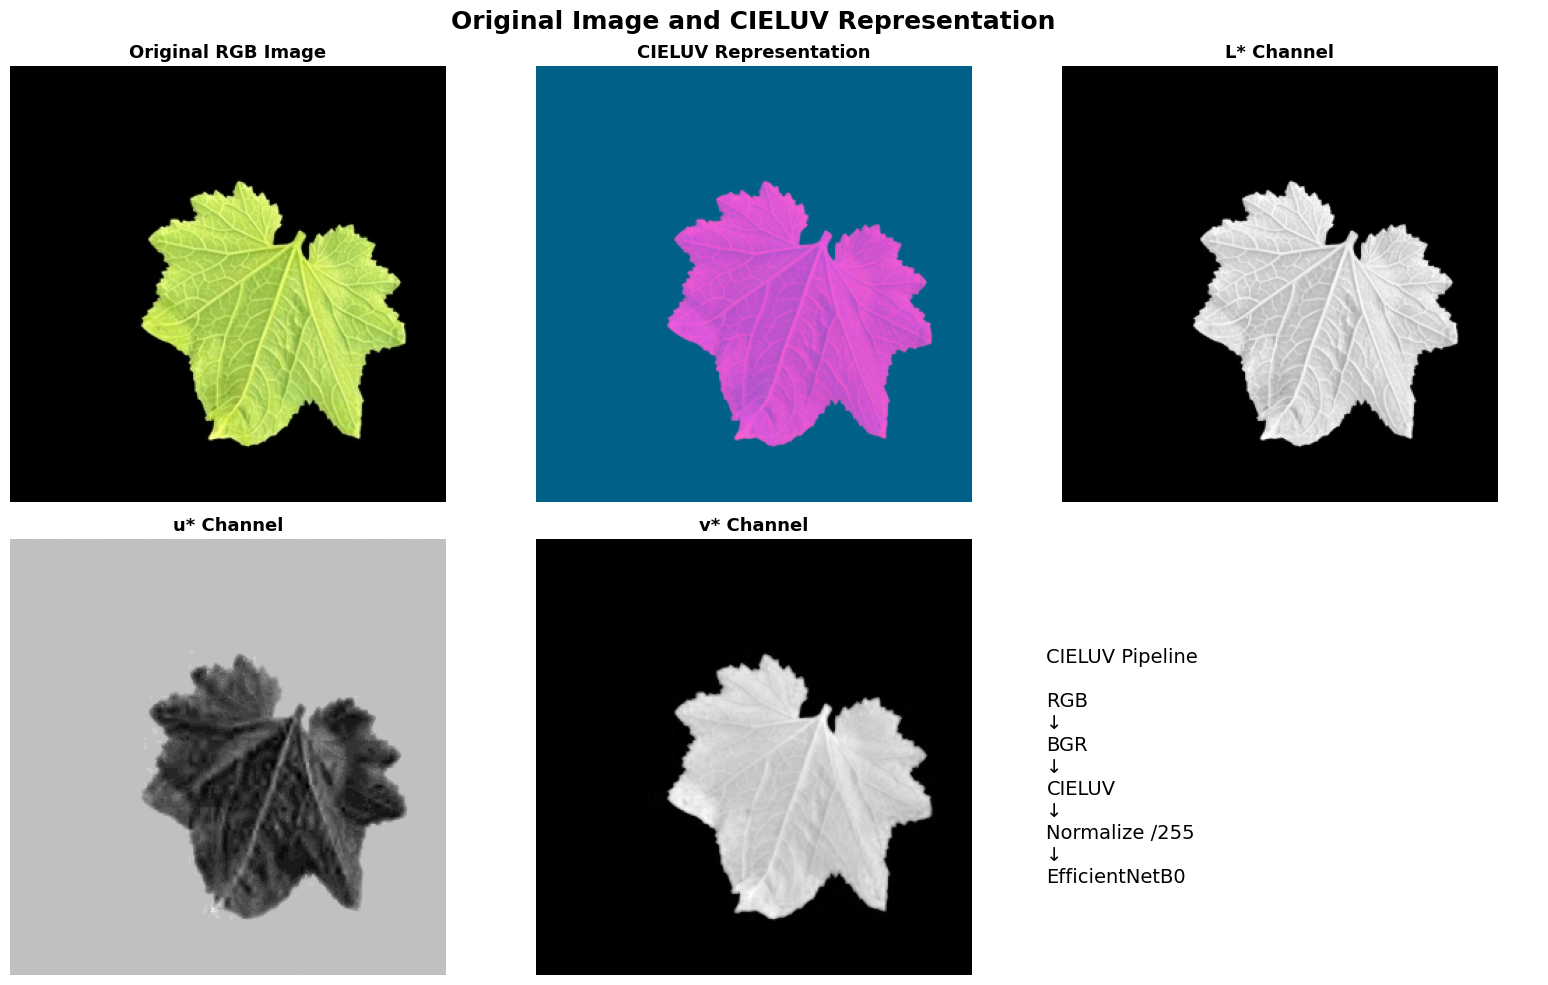

✓ Original image displayed.
✓ CIELUV representation displayed.
✓ L*, u*, v* channels displayed.
✓ Saved: /home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/CIELUV_312/EfficientNetB0_Controlled_FT/Original_vs_CIELUV_Channels.png

CHECKING CIELUV NORMALIZATION
Minimum : 0.000000
Maximum : 0.988235
Mean    : 0.395801
✓ CIELUV normalization confirmed.

CALCULATING CLASS WEIGHTS


E0000 00:00:1790332744.539598  185806 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_18}}


ashgourd_fresh                 : 1.0000
ashgourd_nitrogen              : 1.0000
ashgourd_potassium             : 1.0000
bittergourd_fresh              : 1.0000
bittergourd_nitrogen           : 1.0000
bittergourd_potassium          : 1.0000
snakegourd_fresh               : 1.0000
snakegourd_nitrogen            : 1.0000
snakegourd_potassium           : 1.0000

BUILDING EFFICIENTNETB0
✓ EfficientNetB0 architecture created.

LOADING LOCAL IMAGENET WEIGHTS
Weight file size: 15.93 MB
✓ Local ImageNet weights loaded.
✓ EfficientNetB0 backbone frozen.

MODEL SUMMARY


Model: "CIELUV_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ CIELUV_Input (InputLayer)       │ (None, 312, 312, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CIELUV_to_EfficientNet_Range    │ (None, 312, 312, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ EfficientNetB0_Backbone         │ (None, 10, 10, 1280)   │     4,049,571 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GlobalAveragePooling            │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Head_BatchNormalization         │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_128 (Dense)               │ (None, 128)            │       163,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_BatchNormalization        │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ReLU (ReLU)                     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_0.40 (Dropout)          │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Classification_Output (Dense)   │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...


STAGE 1 - FROZEN BACKBONE

Starting Stage 1...
Monitoring: val_accuracy
Epochs: 20
Epoch 1/20
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.4296 - loss: 1.6019

E0000 00:00:1790332779.121428  185806 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_13}}



Epoch 1: val_accuracy improved from None to 0.60741, saving model to /home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/CIELUV_312/EfficientNetB0_Controlled_FT/best_stage1_val_accuracy.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 41s 571ms/step - accuracy: 0.5222 - loss: 1.2690 - val_accuracy: 0.6074 - val_loss: 1.3010 - learning_rate: 0.0010
Epoch 2/20
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.6594 - loss: 0.8986
Epoch 2: val_accuracy improved from 0.60741 to 0.67407, saving model to /home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/CIELUV_312/EfficientNetB0_Controlled_FT/best_stage1_val_accuracy.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 33s 544ms/step - accuracy: 0.6730 - loss: 0.8589 - val_accuracy: 0.6741 - val_loss: 1.1214 - learning_rate: 0.0010
Epoch 3/20
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.7048 - loss: 0.7545
Epoch 3: val_accuracy improved from 0.67407 to 0.74074, saving model to /home/mtech_atul/atul/Early_Output-20260923T17

E0000 00:00:1790333399.897163  185806 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_18}}


60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.8780 - loss: 0.3459
Epoch 1: val_accuracy improved from None to 0.87160, saving model to /home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/CIELUV_312/EfficientNetB0_Controlled_FT/best_stage2_val_accuracy.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 43s 621ms/step - accuracy: 0.8921 - loss: 0.3259 - val_accuracy: 0.8716 - val_loss: 0.3496 - learning_rate: 1.0000e-06
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.9040 - loss: 0.3142
Epoch 2: val_accuracy did not improve from 0.87160
60/60 ━━━━━━━━━━━━━━━━━━━━ 35s 588ms/step - accuracy: 0.9122 - loss: 0.3003 - val_accuracy: 0.8716 - val_loss: 0.3457 - learning_rate: 1.0000e-06
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.8858 - loss: 0.3258
Epoch 3: val_accuracy improved from 0.87160 to 0.87407, saving model to /home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/CIELUV_312/EfficientNetB0_Controlled_FT/best_stage2_val_

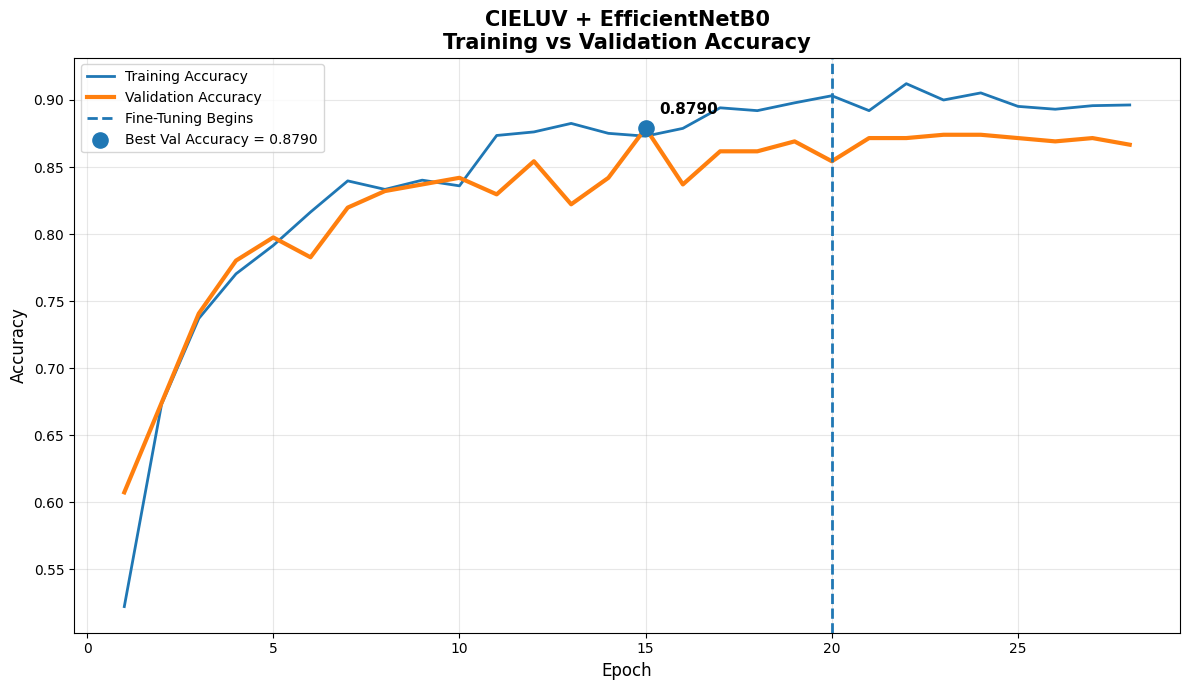

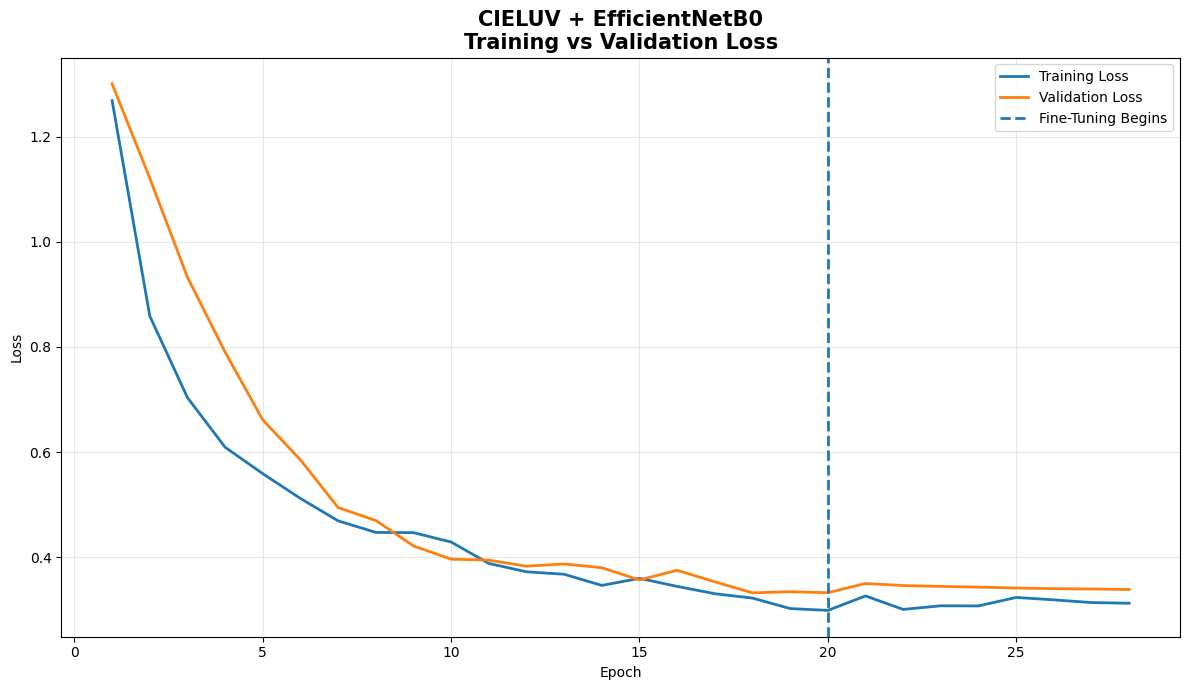


GENERATING TEST PREDICTIONS


E0000 00:00:1790333692.406478  185806 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_13}}
E0000 00:00:1790333699.532577  185806 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),


FINAL TEST RESULTS

Best Validation Accuracy : 0.8790
Test Accuracy            : 0.8741
Macro F1                 : 0.8729
MCC                      : 0.8587

CLASSIFICATION REPORT
                       precision    recall  f1-score   support

       ashgourd_fresh     0.8333    0.7778    0.8046        45
    ashgourd_nitrogen     0.9773    0.9556    0.9663        45
   ashgourd_potassium     0.7755    0.8444    0.8085        45
    bittergourd_fresh     0.7632    0.6444    0.6988        45
 bittergourd_nitrogen     0.7083    0.7556    0.7312        45
bittergourd_potassium     0.9184    1.0000    0.9574        45
     snakegourd_fresh     0.9184    1.0000    0.9574        45
  snakegourd_nitrogen     1.0000    0.9333    0.9655        45
 snakegourd_potassium     0.9773    0.9556    0.9663        45

             accuracy                         0.8741       405
            macro avg     0.8746    0.8741    0.8729       405
         weighted avg     0.8746    0.8741    0.8729       405

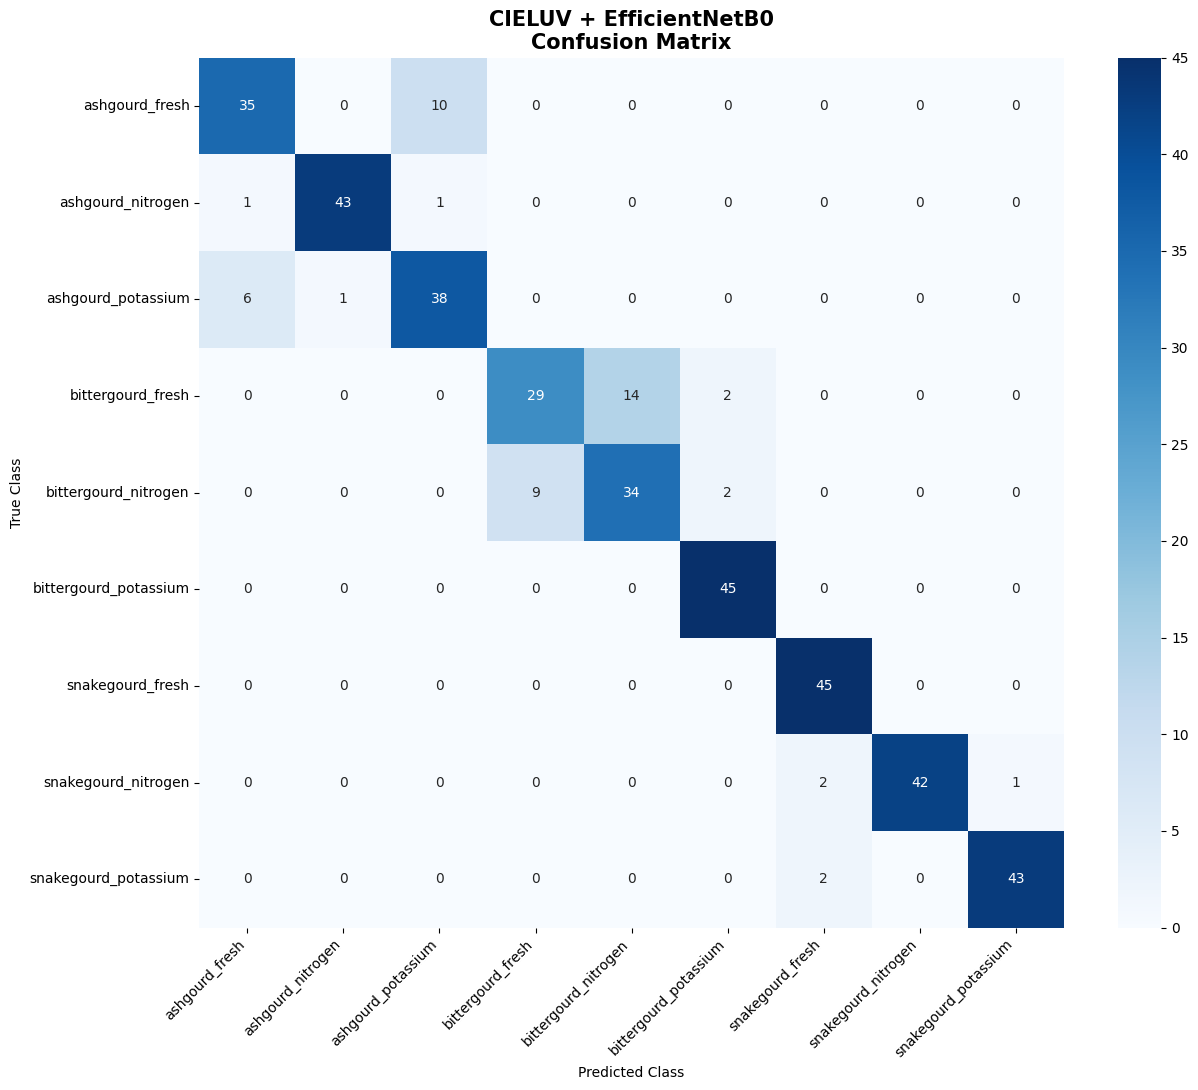


PER-CLASS METRICS
                Class  Precision   Recall       F1  Support
       ashgourd_fresh   0.833333 0.777778 0.804598     45.0
    ashgourd_nitrogen   0.977273 0.955556 0.966292     45.0
   ashgourd_potassium   0.775510 0.844444 0.808511     45.0
    bittergourd_fresh   0.763158 0.644444 0.698795     45.0
 bittergourd_nitrogen   0.708333 0.755556 0.731183     45.0
bittergourd_potassium   0.918367 1.000000 0.957447     45.0
     snakegourd_fresh   0.918367 1.000000 0.957447     45.0
  snakegourd_nitrogen   1.000000 0.933333 0.965517     45.0
 snakegourd_potassium   0.977273 0.955556 0.966292     45.0

TRAINING COMPLETED

Color Space       : CIELUV
Model             : EfficientNetB0
Input Size        : 312 × 312

Best Validation Accuracy:
0.8790

Best Validation Epoch:
15

Test Accuracy:
0.8741

Macro F1:
0.8729

MCC:
0.8587

Validation Accuracy Improvement:
+0.2716

Output Directory:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/CIELUV_312/EfficientN

In [ ]:


import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import regularizers

from tensorflow.keras.applications import EfficientNetB0

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    CSVLogger
)

from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix
)


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)

np.random.seed(SEED)

tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass






BASE_ROOT = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output"
)

TRAIN_DIR = os.path.join(
    BASE_ROOT,
    "Train_256"
)

VAL_DIR = os.path.join(
    BASE_ROOT,
    "Val_resized312"
)

TEST_DIR = os.path.join(
    BASE_ROOT,
    "Test_resized312"
)



LOCAL_WEIGHTS = (
    "/home/mtech_atul/efficientnetb0_notop.h5"
)



# OUTPUT DIRECTORY


OUTPUT_DIR = os.path.join(
    BASE_ROOT,
    "CIELUV_312",
    "EfficientNetB0_Controlled_FT"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


IMG_SIZE = 312

BATCH_SIZE = 32

INITIAL_EPOCHS = 20

FINE_TUNE_EPOCHS = 10

INITIAL_LR = 1e-3

FINE_TUNE_LR = 1e-6

DROPOUT_RATE = 0.40

L2_REG = 1e-4

FINE_TUNE_LAYERS = 30


CLASS_NAMES = [

    "ashgourd_fresh",
    "ashgourd_nitrogen",
    "ashgourd_potassium",

    "bittergourd_fresh",
    "bittergourd_nitrogen",
    "bittergourd_potassium",

    "snakegourd_fresh",
    "snakegourd_nitrogen",
    "snakegourd_potassium"

]

NUM_CLASSES = len(
    CLASS_NAMES
)


print("\n" + "=" * 80)
print("CHECKING PATHS")
print("=" * 80)


paths_to_check = {

    "TRAIN DATASET":
        TRAIN_DIR,

    "VALIDATION DATASET":
        VAL_DIR,

    "TEST DATASET":
        TEST_DIR,

    "EFFICIENTNET WEIGHTS":
        LOCAL_WEIGHTS

}


for name, path in paths_to_check.items():

    print(f"\n{name}:")
    print(path)

    if os.path.exists(path):

        print(" EXISTS")

    else:

        print(" NOT FOUND")


if not os.path.exists(
    LOCAL_WEIGHTS
):

    raise FileNotFoundError(

        "\nEfficientNet weights not found:\n"
        f"{LOCAL_WEIGHTS}"
    )




class Converter:

    def __init__(self):
        pass



    # HSV


    def to_hsv(self, im):

        return cv2.cvtColor(
            im,
            cv2.COLOR_BGR2HSV
        )


    # CIELAB
 

    def to_cielab(self, im):

        return cv2.cvtColor(
            im,
            cv2.COLOR_BGR2Lab
        )



    # CIELUV


    def to_cieluv(self, im):

        return cv2.cvtColor(
            im,
            cv2.COLOR_BGR2Luv
        )



    # NUTRISPACE


    def to_nutrispace(self, im):

        np.seterr(
            invalid="ignore"
        )

        # BGR -> RGB
        im = cv2.cvtColor(
            im,
            cv2.COLOR_BGR2RGB
        )

        def im2double(im):

            info = np.iinfo(
                im.dtype
            )

            return (
                im.astype(
                    np.float64
                )
                /
                info.max
            )


        # Extract RGB channels


        r = im2double(
            im[:, :, 0]
        )

        g = im2double(
            im[:, :, 1]
        )

        b = im2double(
            im[:, :, 2]
        )



        # CAM16 chromatic adaptation transformation
 

        CAT16 = np.matrix(

            "0.401288 0.650173 -0.051461;"
            "-0.250268 1.204414 0.045854;"
            "-0.002079 0.048952 0.953127"

        )


        CAT16_inv = np.linalg.inv(
            CAT16
        )

        # RGB -> XYZ


        X = (

            CAT16_inv[0, 0] * r +

            CAT16_inv[0, 1] * g +

            CAT16_inv[0, 2] * b

        )


        Y = (

            CAT16_inv[1, 0] * r +

            CAT16_inv[1, 1] * g +

            CAT16_inv[1, 2] * b

        )


        Z = (

            CAT16_inv[2, 0] * r +

            CAT16_inv[2, 1] * g +

            CAT16_inv[2, 2] * b

        )


 
        # Reference white point D65


        WhitePoint = np.matrix(
            "95.047 100.000 108.883"
        )


        WhitePointU = (

            4 * WhitePoint[0, 0]

        ) / (

            WhitePoint[0, 0] +

            15 * WhitePoint[0, 1] +

            3 * WhitePoint[0, 2]

        )


     
        # Channel 1


        U = (

            4 * X

        ) / (

            X +

            15 * Y +

            3 * Z

        )


        y = (

            Y /

            WhitePoint[0, 1]

        )


        y_dash = y ** (
            1 / 3
        )


        if y.all() > 0.008856:

            L = (

                116 * y_dash

            ) - 16

        else:

            L = (

                903.3 * y

            )


        Channel_1 = 13 * (

            L *

            (

                U -

                WhitePointU

            )

        )


      
        # Channel 2
      

        Channel_2 = (

            0.40024 * X +

            0.7076 * Y -

            0.08081 * Z

        )



        # Channel 3
  

        def f(t):

            if t.all() > 0.008856:

                return np.real(

                    t ** (1 / 3)

                )

            else:

                return (

                    7.787 * t

                ) + (

                    4 / 29

                )


        xr = (

            X /

            WhitePoint[0, 0]

        )


        yr = (

            Y /

            WhitePoint[0, 1]

        )


        Channel_3 = 500 * (

            f(xr) -

            f(yr)

        )


  
        # Final Nutrispace image
       

        NSPACE = np.zeros(

            (
                len(im),
                len(im),
                3
            )

        )


        NSPACE[:, :, 0] = (
            Channel_1
        )

        NSPACE[:, :, 1] = (
            Channel_2
        )

        NSPACE[:, :, 2] = (
            Channel_3
        )


        return NSPACE


# CREATE CONVERTER


converter = Converter()


print("\n" + "=" * 80)
print("CONVERTER INITIALIZED")
print("=" * 80)

print(
    "✓ HSV converter available"
)

print(
    "✓ CIELAB converter available"
)

print(
    "✓ CIELUV converter available"
)

print(
    "✓ Nutrispace converter available"
)


print("\n" + "=" * 80)
print("LOADING DATASETS")
print("=" * 80)


train_ds = tf.keras.utils.image_dataset_from_directory(

    TRAIN_DIR,

    labels="inferred",

    label_mode="int",

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=SEED
)


val_ds = tf.keras.utils.image_dataset_from_directory(

    VAL_DIR,

    labels="inferred",

    label_mode="int",

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    batch_size=BATCH_SIZE,

    shuffle=False
)


test_ds = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    labels="inferred",

    label_mode="int",

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    batch_size=BATCH_SIZE,

    shuffle=False
)


print(
    "\n✓ Training shuffle: TRUE"
)

print(
    "✓ Validation shuffle: FALSE"
)

print(
    "✓ Test shuffle: FALSE"
)



# CIELUV BATCH CONVERSION


def convert_batch_to_cieluv(
    images,
    labels
):

    def convert_numpy(
        batch
    ):

        output = []

        for image in batch:

     
            # image from TensorFlow is RGB.
         

            image_uint8 = (
                image.astype(
                    np.uint8
                )
            )


            

            bgr_image = cv2.cvtColor(

                image_uint8,

                cv2.COLOR_RGB2BGR

            )


    
            # BGR -> CIELUV
    
 

            luv = converter.to_cieluv(

                bgr_image

            )


  
            # Normalize CIELUV

     

            luv = (

                luv.astype(
                    np.float32
                )

                /

                255.0

            )


            output.append(
                luv
            )


        return np.asarray(

            output,

            dtype=np.float32

        )


    luv_images = tf.numpy_function(

        func=convert_numpy,

        inp=[images],

        Tout=tf.float32

    )


    luv_images.set_shape(

        (
            None,
            IMG_SIZE,
            IMG_SIZE,
            3
        )

    )


    labels = tf.cast(

        labels,

        tf.int32

    )


    return (
        luv_images,
        labels
    )



# APPLY CIELUV CONVERSION


print("\n" + "=" * 80)
print("APPLYING CIELUV CONVERSION")
print("=" * 80)


train_ds_cieluv = train_ds.map(

    convert_batch_to_cieluv,

    num_parallel_calls=tf.data.AUTOTUNE

)


val_ds_cieluv = val_ds.map(

    convert_batch_to_cieluv,

    num_parallel_calls=tf.data.AUTOTUNE

)


test_ds_cieluv = test_ds.map(

    convert_batch_to_cieluv,

    num_parallel_calls=tf.data.AUTOTUNE

)



# PREFETCH


train_ds_cieluv = train_ds_cieluv.prefetch(

    tf.data.AUTOTUNE

)


val_ds_cieluv = val_ds_cieluv.prefetch(

    tf.data.AUTOTUNE

)


test_ds_cieluv = test_ds_cieluv.prefetch(

    tf.data.AUTOTUNE

)


print(
    "✓ CIELUV datasets created."
)



# ORIGINAL RGB + CIELUV REPRESENTATION


print("\n" + "=" * 80)
print("ORIGINAL RGB vs CIELUV")
print("=" * 80)


# Get original image
original_images, original_labels = next(

    iter(train_ds)

)


original_image = (

    original_images[0]

    .numpy()

    .astype(
        np.uint8
    )

)


# RGB -> BGR
original_bgr = cv2.cvtColor(

    original_image,

    cv2.COLOR_RGB2BGR

)


# BGR -> CIELUV
original_cieluv = converter.to_cieluv(

    original_bgr

)


# Normalize
cieluv_normalized = (

    original_cieluv.astype(
        np.float32
    )

    /

    255.0

)



# EXTRACT L*, u*, v* CHANNELS


L_channel = (

    cieluv_normalized[:, :, 0]

)


u_channel = (

    cieluv_normalized[:, :, 1]

)


v_channel = (

    cieluv_normalized[:, :, 2]

)



# DISPLAY ORIGINAL + CIELUV


fig, axes = plt.subplots(

    2,
    3,

    figsize=(16, 10)

)



# Original RGB


axes[0, 0].imshow(
    original_image
)

axes[0, 0].set_title(
    "Original RGB Image",
    fontsize=13,
    fontweight="bold"
)

axes[0, 0].axis(
    "off"
)



# CIELUV representation


axes[0, 1].imshow(

    cieluv_normalized

)

axes[0, 1].set_title(

    "CIELUV Representation",
    fontsize=13,
    fontweight="bold"

)

axes[0, 1].axis(
    "off"
)



# L*
axes[0, 2].imshow(

    L_channel,

    cmap="gray"

)

axes[0, 2].set_title(

    "L* Channel",
    fontsize=13,
    fontweight="bold"

)

axes[0, 2].axis(
    "off"
)


# ------
# u*
# ------

axes[1, 0].imshow(

    u_channel,

    cmap="gray"

)

axes[1, 0].set_title(

    "u* Channel",
    fontsize=13,
    fontweight="bold"

)

axes[1, 0].axis(
    "off"
)


# -------
# v*
# -------

axes[1, 1].imshow(

    v_channel,

    cmap="gray"

)

axes[1, 1].set_title(

    "v* Channel",
    fontsize=13,
    fontweight="bold"

)

axes[1, 1].axis(
    "off"
)



# Text information


axes[1, 2].axis(
    "off"
)


axes[1, 2].text(

    0.05,
    0.75,

    "CIELUV Pipeline\n\n"
    "RGB\n"
    "↓\n"
    "BGR\n"
    "↓\n"
    "CIELUV\n"
    "↓\n"
    "Normalize /255\n"
    "↓\n"
    "EfficientNetB0",

    fontsize=14,

    verticalalignment="top"

)


plt.suptitle(

    "Original Image and CIELUV Representation",

    fontsize=18,

    fontweight="bold"

)


plt.tight_layout()


visualization_path = os.path.join(

    OUTPUT_DIR,

    "Original_vs_CIELUV_Channels.png"

)


plt.savefig(

    visualization_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()


print(
    "✓ Original image displayed."
)

print(
    "✓ CIELUV representation displayed."
)

print(
    "✓ L*, u*, v* channels displayed."
)

print(
    f"✓ Saved: {visualization_path}"
)



# NORMALIZATION CHECK


print("\n" + "=" * 80)
print("CHECKING CIELUV NORMALIZATION")
print("=" * 80)


sample_images, sample_labels = next(

    iter(train_ds_cieluv)

)


luv_min = float(

    tf.reduce_min(
        sample_images
    )

)


luv_max = float(

    tf.reduce_max(
        sample_images
    )

)


luv_mean = float(

    tf.reduce_mean(
        sample_images
    )

)


print(
    f"Minimum : {luv_min:.6f}"
)

print(
    f"Maximum : {luv_max:.6f}"
)

print(
    f"Mean    : {luv_mean:.6f}"
)


if (

    luv_min < 0.0

    or

    luv_max > 1.0

):

    raise ValueError(

        "CIELUV values are outside [0,1]."

    )


print(
    "✓ CIELUV normalization confirmed."
)



# CLASS WEIGHTS


print("\n" + "=" * 80)
print("CALCULATING CLASS WEIGHTS")
print("=" * 80)


train_labels = []


for _, labels in train_ds:

    train_labels.extend(

        labels.numpy().tolist()

    )


train_labels = np.asarray(

    train_labels

)


class_weights_array = compute_class_weight(

    class_weight="balanced",

    classes=np.arange(
        NUM_CLASSES
    ),

    y=train_labels

)


class_weights = {

    i: float(weight)

    for i, weight

    in enumerate(
        class_weights_array
    )

}


for i, weight in class_weights.items():

    print(

        f"{CLASS_NAMES[i]:30s} : "
        f"{weight:.4f}"

    )


print("\n" + "=" * 80)
print("BUILDING EFFICIENTNETB0")
print("=" * 80)


base_model = EfficientNetB0(

    include_top=False,


    weights=None,

    input_shape=(

        IMG_SIZE,

        IMG_SIZE,

        3

    ),

    name="EfficientNetB0_Backbone"

)


print(
    "✓ EfficientNetB0 architecture created."
)



#  LOAD LOCAL IMAGENET WEIGHTS


print("\n" + "=" * 80)
print("LOADING LOCAL IMAGENET WEIGHTS")
print("=" * 80)


weight_size = (

    os.path.getsize(
        LOCAL_WEIGHTS
    )

    /

    (1024 * 1024)

)


print(
    f"Weight file size: "
    f"{weight_size:.2f} MB"
)


base_model.load_weights(

    LOCAL_WEIGHTS

)


print(
    "✓ Local ImageNet weights loaded."
)






base_model.trainable = False


print(
    "✓ EfficientNetB0 backbone frozen."
)


inputs = layers.Input(

    shape=(

        IMG_SIZE,

        IMG_SIZE,

        3

    ),

    name="CIELUV_Input"

)


# CIELUV [0,1] -> [0,255]


x = layers.Rescaling(

    scale=255.0,

    name="CIELUV_to_EfficientNet_Range"

)(inputs)



x = base_model(

    x,

    training=False

)

x = layers.GlobalAveragePooling2D(

    name="GlobalAveragePooling"

)(x)


x = layers.BatchNormalization(

    name="Head_BatchNormalization"

)(x)



# Dense 128


x = layers.Dense(

    128,

    use_bias=False,

    kernel_regularizer=regularizers.l2(

        L2_REG

    ),

    name="Dense_128"

)(x)



# Batch Normalization 2


x = layers.BatchNormalization(

    name="Dense_BatchNormalization"

)(x)


# ReLU


x = layers.ReLU(

    name="ReLU"

)(x)




x = layers.Dropout(

    DROPOUT_RATE,

    name="Dropout_0.40"

)(x)


outputs = layers.Dense(

    NUM_CLASSES,

    activation="softmax",

    kernel_regularizer=regularizers.l2(

        L2_REG

    ),

    name="Classification_Output"

)(x)



# FINAL MODEL


model = models.Model(

    inputs=inputs,

    outputs=outputs,

    name="CIELUV_EfficientNetB0"

)



# MODEL SUMMARY


print("\n" + "=" * 80)
print("MODEL SUMMARY")
print("=" * 80)

model.summary()



# STAGE 1


print("\n" + "=" * 80)
print("STAGE 1 - FROZEN BACKBONE")
print("=" * 80)


optimizer_stage1 = tf.keras.optimizers.Adam(

    learning_rate=INITIAL_LR,

    clipnorm=1.0

)


model.compile(

    optimizer=optimizer_stage1,

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]

)



# STAGE 1 CALLBACKS


stage1_checkpoint = os.path.join(

    OUTPUT_DIR,

    "best_stage1_val_accuracy.keras"

)


stage1_csv = os.path.join(

    OUTPUT_DIR,

    "stage1_training_log.csv"

)


stage1_callbacks = [

    ModelCheckpoint(

        stage1_checkpoint,

        monitor="val_accuracy",

        mode="max",

        save_best_only=True,

        verbose=1

    ),

    ReduceLROnPlateau(

        monitor="val_accuracy",

        mode="max",

        factor=0.5,

        patience=4,

        min_lr=1e-5,

        verbose=1

    ),

    EarlyStopping(

        monitor="val_accuracy",

        mode="max",

        patience=7,

        restore_best_weights=True,

        verbose=1

    ),

    CSVLogger(

        stage1_csv,

        append=False

    )

]



# STAGE 1 TRAINING


print(
    "\nStarting Stage 1..."
)

print(
    "Monitoring: val_accuracy"
)

print(
    f"Epochs: {INITIAL_EPOCHS}"
)


history_stage1 = model.fit(

    train_ds_cieluv,

    validation_data=val_ds_cieluv,

    epochs=INITIAL_EPOCHS,

    class_weight=class_weights,

    callbacks=stage1_callbacks,

    verbose=1

)



# STAGE 1 BEST VALIDATION ACCURACY


stage1_val_acc = (

    history_stage1.history[
        "val_accuracy"
    ]

)


best_stage1_val_acc = max(
    stage1_val_acc
)


best_stage1_epoch = (

    np.argmax(
        stage1_val_acc
    )

    + 1

)


print("\n" + "=" * 80)
print("STAGE 1 VALIDATION ACCURACY")
print("=" * 80)


print(
    f"Best Val Accuracy: "
    f"{best_stage1_val_acc:.4f}"
)


print(
    f"Best Epoch: "
    f"{best_stage1_epoch}"
)



# LOAD BEST STAGE 1 MODEL


if os.path.exists(
    stage1_checkpoint
):

    model = tf.keras.models.load_model(

        stage1_checkpoint

    )

    print(
        "✓ Best Stage 1 model loaded."
    )



# FIND EFFICIENTNET BACKBONE


print("\n" + "=" * 80)
print("LOCATING EFFICIENTNET BACKBONE")
print("=" * 80)


base_model = None


for layer in model.layers:

    if isinstance(

        layer,

        tf.keras.Model

    ):

        if (

            "efficientnet"

            in layer.name.lower()

        ):

            base_model = layer

            break


if base_model is None:

    raise RuntimeError(

        "EfficientNetB0 backbone "
        "could not be located."

    )


print(
    f"✓ Backbone found: "
    f"{base_model.name}"
)



# CONTROLLED FINE-TUNING


print("\n" + "=" * 80)
print("STAGE 2 - CONTROLLED FINE-TUNING")
print("=" * 80)


base_model.trainable = False


total_layers = len(

    base_model.layers

)


print(
    f"Total backbone layers: "
    f"{total_layers}"
)


for layer in base_model.layers[

    -FINE_TUNE_LAYERS:

]:

    if isinstance(

        layer,

        tf.keras.layers.BatchNormalization

    ):

        layer.trainable = False

    else:

        layer.trainable = True


print(
    f"✓ Last {FINE_TUNE_LAYERS} layers "
    "selected."
)

print(
    "✓ BatchNorm layers kept frozen."
)



# PARAMETER COUNT


trainable_params = int(

    np.sum([

        np.prod(
            v.shape
        )

        for v in model.trainable_variables

    ])

)


non_trainable_params = int(

    np.sum([

        np.prod(
            v.shape
        )

        for v in model.non_trainable_variables

    ])

)


print(
    f"Trainable parameters: "
    f"{trainable_params:,}"
)


print(
    f"Non-trainable parameters: "
    f"{non_trainable_params:,}"
)



# STAGE 2 COMPILE


optimizer_stage2 = tf.keras.optimizers.Adam(

    learning_rate=FINE_TUNE_LR,

    clipnorm=1.0

)


model.compile(

    optimizer=optimizer_stage2,

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]

)



# STAGE 2 CALLBACKS


stage2_checkpoint = os.path.join(

    OUTPUT_DIR,

    "best_stage2_val_accuracy.keras"

)


stage2_csv = os.path.join(

    OUTPUT_DIR,

    "stage2_training_log.csv"

)


stage2_callbacks = [

    ModelCheckpoint(

        stage2_checkpoint,

        monitor="val_accuracy",

        mode="max",

        save_best_only=True,

        verbose=1

    ),

    ReduceLROnPlateau(

        monitor="val_accuracy",

        mode="max",

        factor=0.5,

        patience=3,

        min_lr=1e-8,

        verbose=1

    ),

    EarlyStopping(

        monitor="val_accuracy",

        mode="max",

        patience=5,

        restore_best_weights=True,

        verbose=1

    ),

    CSVLogger(

        stage2_csv,

        append=False

    )

]



# STAGE 2 TRAINING


print("\n" + "=" * 80)
print("STARTING STAGE 2")
print("=" * 80)


print(
    "Monitoring: val_accuracy"
)


print(
    f"Maximum epochs: "
    f"{FINE_TUNE_EPOCHS}"
)


history_stage2 = model.fit(

    train_ds_cieluv,

    validation_data=val_ds_cieluv,

    epochs=FINE_TUNE_EPOCHS,

    class_weight=class_weights,

    callbacks=stage2_callbacks,

    verbose=1

)



# LOAD BEST FINAL MODEL


if os.path.exists(

    stage2_checkpoint

):

    model = tf.keras.models.load_model(

        stage2_checkpoint

    )

    print(
        "✓ Best Stage 2 model loaded."
    )



# COMBINE HISTORIES


history = {}


for key in history_stage1.history:

    history[key] = (

        history_stage1.history[key]

        +

        history_stage2.history[key]

    )



# VALIDATION ACCURACY ANALYSIS


all_val_accuracy = (

    history[
        "val_accuracy"
    ]

)


best_val_accuracy = max(

    all_val_accuracy

)


best_val_epoch = (

    np.argmax(
        all_val_accuracy
    )

    + 1

)


initial_val_accuracy = (

    all_val_accuracy[0]

)


final_val_accuracy = (

    all_val_accuracy[-1]

)


val_accuracy_improvement = (

    best_val_accuracy

    -

    initial_val_accuracy

)



# VALIDATION ACCURACY OUTPUT


print("\n" + "=" * 80)
print("VALIDATION ACCURACY IMPROVEMENT")
print("=" * 80)


print(
    f"\nInitial Val Accuracy : "
    f"{initial_val_accuracy:.4f}"
)


print(
    f"Best Val Accuracy    : "
    f"{best_val_accuracy:.4f}"
)


print(
    f"Best Val Epoch       : "
    f"{best_val_epoch}"
)


print(
    f"Final Val Accuracy   : "
    f"{final_val_accuracy:.4f}"
)


print(
    f"\nImprovement from first "
    f"epoch to best epoch: "
    f"{val_accuracy_improvement:+.4f}"
)


if val_accuracy_improvement > 0:

    print(
        "✓ Validation accuracy improved."
    )

elif val_accuracy_improvement == 0:

    print(
        "Validation accuracy did not change."
    )

else:

    print(
        "Validation accuracy did not improve "
        "from the first epoch."
    )



# ACCURACY CURVE


epochs_range = range(

    1,

    len(
        history["accuracy"]
    ) + 1

)


plt.figure(

    figsize=(12, 7)

)


plt.plot(

    epochs_range,

    history["accuracy"],

    label="Training Accuracy",

    linewidth=2

)


plt.plot(

    epochs_range,

    history["val_accuracy"],

    label="Validation Accuracy",

    linewidth=3

)


plt.axvline(

    INITIAL_EPOCHS,

    linestyle="--",

    linewidth=2,

    label="Fine-Tuning Begins"

)


plt.scatter(

    best_val_epoch,

    best_val_accuracy,

    s=120,

    zorder=5,

    label=(

        f"Best Val Accuracy = "
        f"{best_val_accuracy:.4f}"

    )

)


plt.annotate(

    f"{best_val_accuracy:.4f}",

    (

        best_val_epoch,

        best_val_accuracy

    ),

    xytext=(10, 10),

    textcoords="offset points",

    fontsize=11,

    fontweight="bold"

)


plt.xlabel(
    "Epoch",
    fontsize=12
)


plt.ylabel(
    "Accuracy",
    fontsize=12
)


plt.title(

    "CIELUV + EfficientNetB0\n"
    "Training vs Validation Accuracy",

    fontsize=15,

    fontweight="bold"

)


plt.legend()

plt.grid(
    True,
    alpha=0.3
)


plt.tight_layout()


accuracy_plot_path = os.path.join(

    OUTPUT_DIR,

    "Validation_Accuracy_Curve.png"

)


plt.savefig(

    accuracy_plot_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()



# LOSS CURVE


plt.figure(

    figsize=(12, 7)

)


plt.plot(

    epochs_range,

    history["loss"],

    label="Training Loss",

    linewidth=2

)


plt.plot(

    epochs_range,

    history["val_loss"],

    label="Validation Loss",

    linewidth=2

)


plt.axvline(

    INITIAL_EPOCHS,

    linestyle="--",

    linewidth=2,

    label="Fine-Tuning Begins"

)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.title(

    "CIELUV + EfficientNetB0\n"
    "Training vs Validation Loss",

    fontsize=15,

    fontweight="bold"

)


plt.legend()

plt.grid(
    True,
    alpha=0.3
)


plt.tight_layout()


loss_plot_path = os.path.join(

    OUTPUT_DIR,

    "Loss_Curve.png"

)


plt.savefig(

    loss_plot_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()


# TEST PREDICTIONS


print("\n" + "=" * 80)
print("GENERATING TEST PREDICTIONS")
print("=" * 80)


y_true = []

y_pred = []


for images, labels in test_ds_cieluv:

    predictions = model.predict(

        images,

        verbose=0

    )


    predicted_classes = np.argmax(

        predictions,

        axis=1

    )


    y_true.extend(

        labels.numpy()

    )


    y_pred.extend(

        predicted_classes

    )


y_true = np.asarray(
    y_true
)

y_pred = np.asarray(
    y_pred
)



# TEST METRICS


test_accuracy = accuracy_score(

    y_true,

    y_pred

)


macro_f1 = f1_score(

    y_true,

    y_pred,

    average="macro"

)


mcc = matthews_corrcoef(

    y_true,

    y_pred

)



# FINAL TEST RESULTS


print("\n" + "=" * 80)
print("FINAL TEST RESULTS")
print("=" * 80)


print(
    f"\nBest Validation Accuracy : "
    f"{best_val_accuracy:.4f}"
)


print(
    f"Test Accuracy            : "
    f"{test_accuracy:.4f}"
)


print(
    f"Macro F1                 : "
    f"{macro_f1:.4f}"
)


print(
    f"MCC                      : "
    f"{mcc:.4f}"
)



# CLASSIFICATION REPORT


print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)


report = classification_report(

    y_true,

    y_pred,

    target_names=CLASS_NAMES,

    digits=4

)


print(
    report
)


report_path = os.path.join(

    OUTPUT_DIR,

    "classification_report.txt"

)


with open(

    report_path,

    "w"

) as f:

    f.write(
        report
    )



#  CONFUSION MATRIX
cm = confusion_matrix(

    y_true,

    y_pred

)


plt.figure(

    figsize=(13, 11)

)


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=CLASS_NAMES,

    yticklabels=CLASS_NAMES

)


plt.xlabel(
    "Predicted Class"
)


plt.ylabel(
    "True Class"
)


plt.title(

    "CIELUV + EfficientNetB0\n"
    "Confusion Matrix",

    fontsize=15,

    fontweight="bold"

)


plt.xticks(

    rotation=45,

    ha="right"

)


plt.yticks(
    rotation=0
)


plt.tight_layout()


cm_path = os.path.join(

    OUTPUT_DIR,

    "Confusion_Matrix.png"

)


plt.savefig(

    cm_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()



# PER-CLASS METRICS


report_dict = classification_report(

    y_true,

    y_pred,

    target_names=CLASS_NAMES,

    output_dict=True

)


per_class_rows = []


for class_name in CLASS_NAMES:

    per_class_rows.append({

        "Class":
            class_name,

        "Precision":
            report_dict[
                class_name
            ][
                "precision"
            ],

        "Recall":
            report_dict[
                class_name
            ][
                "recall"
            ],

        "F1":
            report_dict[
                class_name
            ][
                "f1-score"
            ],

        "Support":
            report_dict[
                class_name
            ][
                "support"
            ]

    })


per_class_df = pd.DataFrame(

    per_class_rows

)


print("\n" + "=" * 80)
print("PER-CLASS METRICS")
print("=" * 80)


print(

    per_class_df.to_string(
        index=False
    )

)


per_class_path = os.path.join(

    OUTPUT_DIR,

    "Per_Class_Metrics.csv"

)


per_class_df.to_csv(

    per_class_path,

    index=False

)



# FINAL RESULTS CSV


results_df = pd.DataFrame({

    "Model": [
        "EfficientNetB0"
    ],

    "Color_Space": [
        "CIELUV"
    ],

    "Image_Size": [
        IMG_SIZE
    ],

    "Best_Validation_Accuracy": [
        best_val_accuracy
    ],

    "Best_Validation_Epoch": [
        best_val_epoch
    ],

    "Initial_Validation_Accuracy": [
        initial_val_accuracy
    ],

    "Final_Validation_Accuracy": [
        final_val_accuracy
    ],

    "Validation_Accuracy_Improvement": [
        val_accuracy_improvement
    ],

    "Test_Accuracy": [
        test_accuracy
    ],

    "Macro_F1": [
        macro_f1
    ],

    "MCC": [
        mcc
    ],

    "Initial_Epochs": [
        INITIAL_EPOCHS
    ],

    "Fine_Tune_Epochs": [
        len(
            history_stage2.history[
                "loss"
            ]
        )
    ],

    "Initial_LR": [
        INITIAL_LR
    ],

    "Fine_Tune_LR": [
        FINE_TUNE_LR
    ],

    "Dropout": [
        DROPOUT_RATE
    ],

    "Fine_Tune_Layers": [
        FINE_TUNE_LAYERS
    ]

})


results_path = os.path.join(

    OUTPUT_DIR,

    "Final_Results.csv"

)


results_df.to_csv(

    results_path,

    index=False

)



# SAVE FINAL MODEL


final_model_path = os.path.join(

    OUTPUT_DIR,

    "CIELUV_EfficientNetB0_Final.keras"

)


model.save(

    final_model_path

)



# FINAL SUMMARY


print("\n" + "=" * 80)
print("TRAINING COMPLETED")
print("=" * 80)


print(
    "\nColor Space       : CIELUV"
)


print(
    "Model             : EfficientNetB0"
)


print(
    f"Input Size        : "
    f"{IMG_SIZE} × {IMG_SIZE}"
)


print(
    "\nBest Validation Accuracy:"
)


print(
    f"{best_val_accuracy:.4f}"
)


print(
    "\nBest Validation Epoch:"
)


print(
    best_val_epoch
)


print(
    "\nTest Accuracy:"
)


print(
    f"{test_accuracy:.4f}"
)


print(
    "\nMacro F1:"
)


print(
    f"{macro_f1:.4f}"
)


print(
    "\nMCC:"
)


print(
    f"{mcc:.4f}"
)


print(
    "\nValidation Accuracy Improvement:"
)


print(
    f"{val_accuracy_improvement:+.4f}"
)


print(
    "\nOutput Directory:"
)


print(
    OUTPUT_DIR
)


print("\n" + "-" * 80)

print(
    "SAVED FILES:"
)


print(
    "✓ Original_vs_CIELUV_Channels.png"
)


print(
    "✓ Validation_Accuracy_Curve.png"
)


print(
    "✓ Loss_Curve.png"
)


print(
    "✓ Confusion_Matrix.png"
)


print(
    "✓ Per_Class_Metrics.csv"
)


print(
    "✓ Final_Results.csv"
)


print(
    "✓ classification_report.txt"
)


print(
    "✓ stage1_training_log.csv"
)


print(
    "✓ stage2_training_log.csv"
)


print(
    "✓ best_stage1_val_accuracy.keras"
)


print(
    "✓ best_stage2_val_accuracy.keras"
)


print(
    "✓ CIELUV_EfficientNetB0_Final.keras"
)


print("\n" + "=" * 80)
print("DONE")
print("=" * 80)

## CIELUV -- DenceNet



TENSORFLOW / GPU INFORMATION
TensorFlow version: 2.21.0


CHECKING DATASET DIRECTORIES

TRAIN:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Train_256
OK

VALIDATION:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Val_resized312
OK

TEST:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Test_resized312
OK


LOADING TRAINING DATASET
Found 1890 files belonging to 9 classes.

Training data shuffling: ENABLED
Shuffle method: image_dataset_from_directory(shuffle=True)
Extra train_ds.shuffle(): NOT USED


LOADING VALIDATION DATASET
Found 405 files belonging to 9 classes.


LOADING TEST DATASET
Found 405 files belonging to 9 classes.


CLASS INFORMATION
Number of classes: 9
Classes: ['ashgourd_fresh', 'ashgourd_nitrogen', 'ashgourd_potassium', 'bittergourd_fresh', 'bittergourd_nitrogen', 'bittergourd_potassium', 'snakegourd_fresh', 'snakegourd_nitrogen', 'snakegourd_potassium']


APPLYING CIELUV PREPROCESSING


CIELUV SA

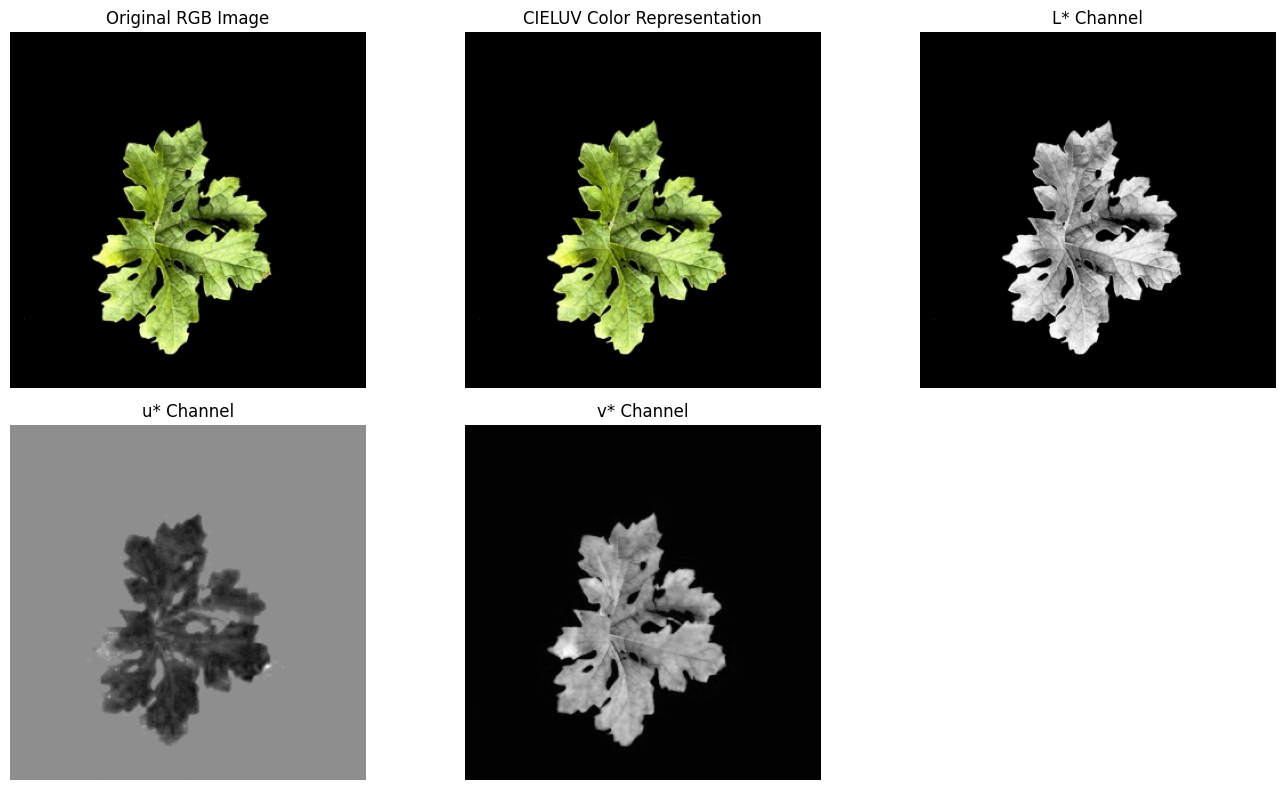


Visualization saved:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/CIELUV_DenseNet121_312_REDUCED_FIXED_PATIENCE2/Original_RGB_vs_CIELUV.png


CALCULATING CLASS WEIGHTS

Class weights:
Class 0: 1.0000
Class 1: 1.0000
Class 2: 1.0000
Class 3: 1.0000
Class 4: 1.0000
Class 5: 1.0000
Class 6: 1.0000
Class 7: 1.0000
Class 8: 1.0000


CREATING DENSENET121
DenseNet121 ImageNet weights loaded.


REDUCED MODEL SUMMARY


Model: "CIELUV_DenseNet121_Reduced"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cieluv_input (InputLayer)       │ (None, 312, 312, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CIELUV_Adapter (Conv2D)         │ (None, 312, 312, 3)    │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CIELUV_BatchNorm                │ (None, 312, 312, 3)    │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CIELUV_to_255 (Rescaling)       │ (None, 312, 312, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ DenseNet_Preprocess             │ (None, 312, 312, 3)    │             0 │
│ (DenseNetPreprocess)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 9, 9, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GlobalAveragePooling            │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Head_BatchNorm                  │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Classification (Dense)          │ (None, 9)              │         9,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,050,846 (26.90 MB)

 Trainable params: 11,288 (44.09 KB)

 Non-trainable params: 7,039,558 (26.85 MB)



STAGE 1
DenseNet121        : FROZEN
CIELUV Adapter     : TRAINABLE
Classification Head: TRAINABLE
Batch Normalization : ENABLED
Training Shuffle    : ENABLED
Extra Shuffle       : DISABLED
Learning Rate       : 0.001
Maximum Epochs      : 20
LR Monitor          : val_accuracy
LR Patience         : 2
LR Factor           : 0.5


STAGE 1 TRAINING

Training data shuffle: ON
Shuffle source: image_dataset_from_directory
Extra train_ds.shuffle(): OFF
ReduceLROnPlateau monitor: val_accuracy
ReduceLROnPlateau patience: 2
Learning rate factor: 0.5


Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3233 - loss: 1.7468
Epoch 1: val_accuracy improved from None to 0.20988, saving model to /home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/CIELUV_DenseNet121_312_REDUCED_FIXED_PATIENCE2/best_stage1_val_accuracy.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.4471 - loss: 1.3779 - val_accuracy: 0.2099 - val_loss: 1.7313 - learning_rate: 0.0010
Epoch 2/20


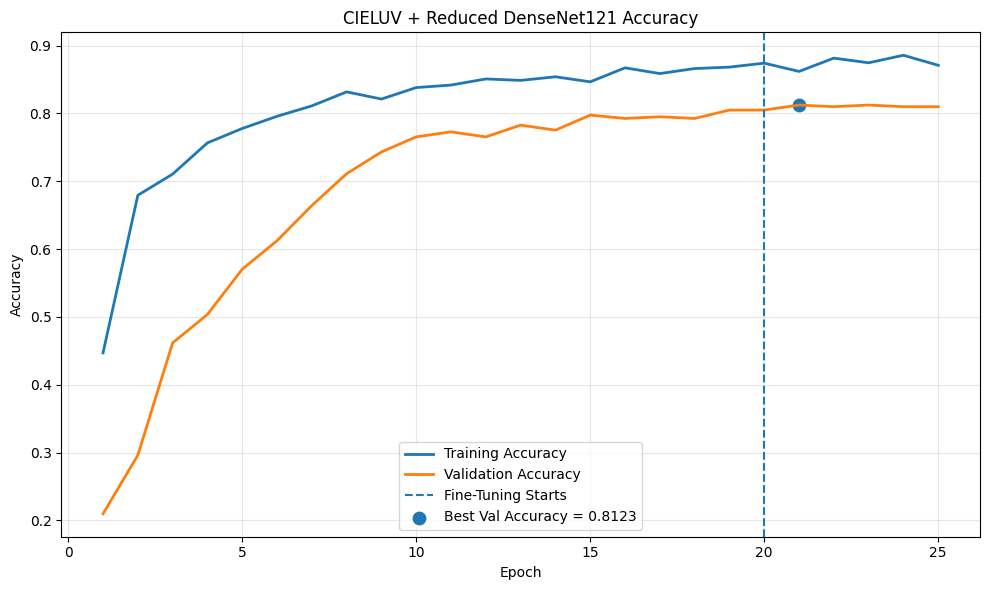

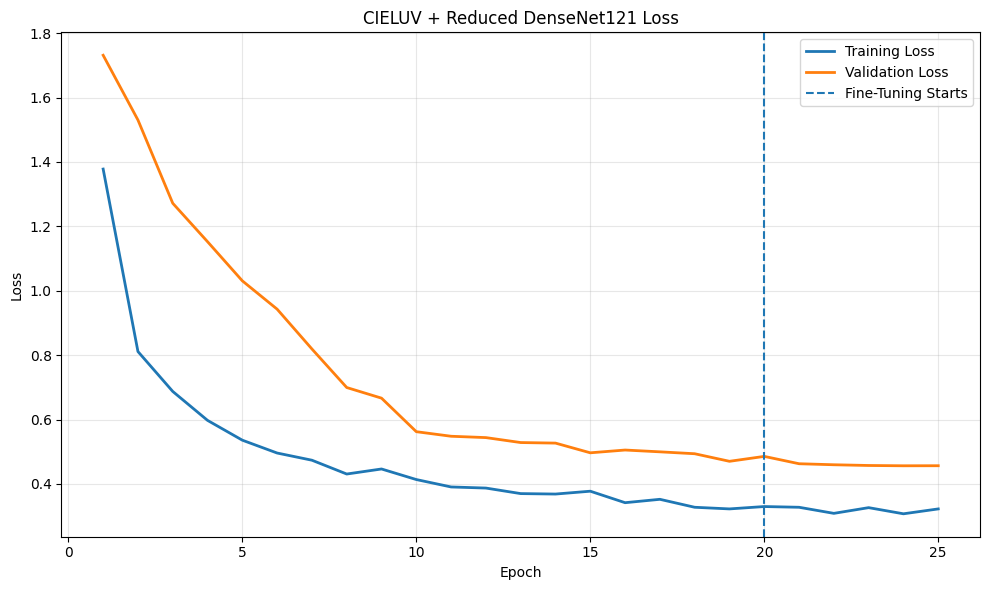



TEST SET EVALUATION
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 793ms/step - accuracy: 0.7753 - loss: 0.5024

Test Loss: 0.5024
Test Accuracy: 0.7753

Generating predictions...

Macro F1 Score: 0.7774
Matthews Correlation Coefficient: 0.7477


CLASSIFICATION REPORT
                       precision    recall  f1-score   support

       ashgourd_fresh     0.6909    0.8444    0.7600        45
    ashgourd_nitrogen     0.9487    0.8222    0.8810        45
   ashgourd_potassium     0.8049    0.7333    0.7674        45
    bittergourd_fresh     0.5208    0.5556    0.5376        45
 bittergourd_nitrogen     0.4773    0.4667    0.4719        45
bittergourd_potassium     0.9535    0.9111    0.9318        45
     snakegourd_fresh     0.8200    0.9111    0.8632        45
  snakegourd_nitrogen     0.8605    0.8222    0.8409        45
 snakegourd_potassium     0.9762    0.9111    0.9425        45

             accuracy                         0.7753       405
            macro avg     0.7836    0.7753    0.77

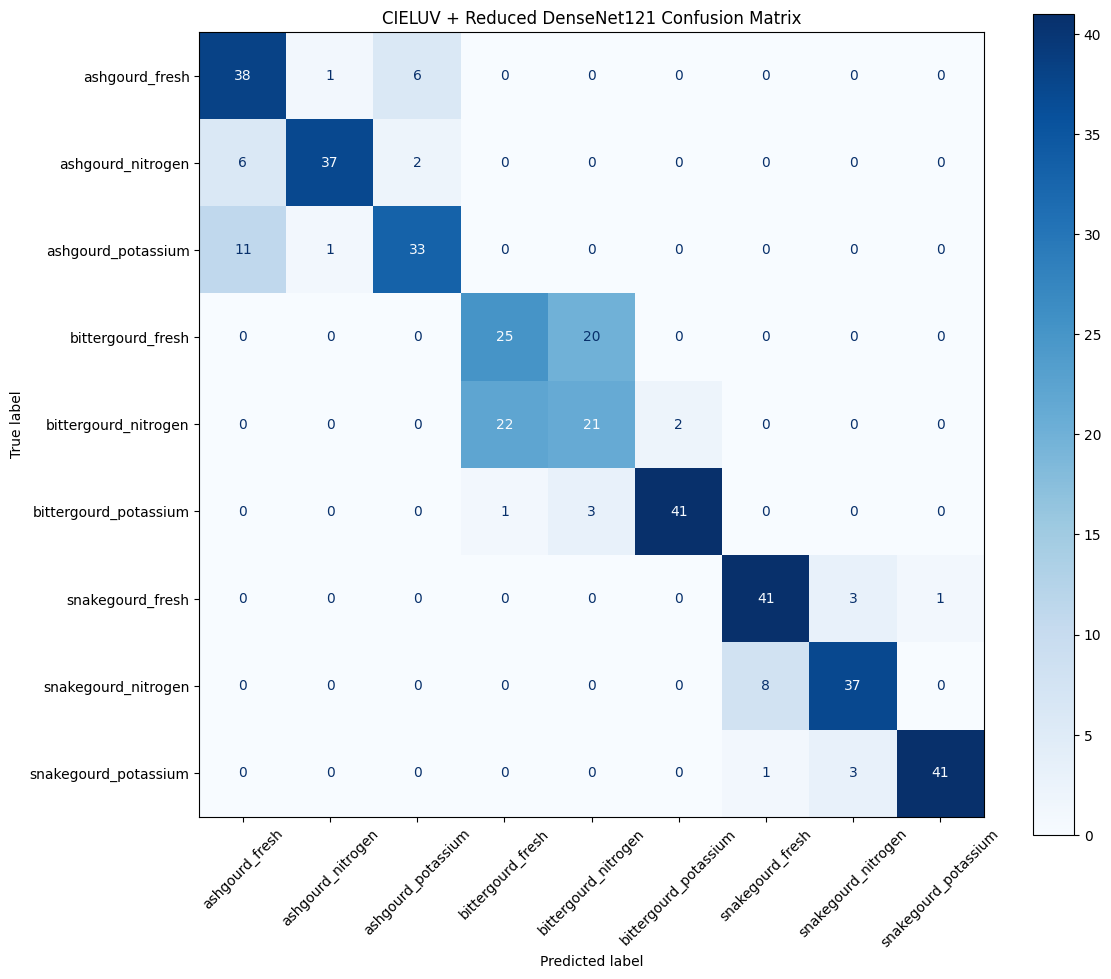



PER-CLASS ACCURACY
ashgourd_fresh: 0.8444
ashgourd_nitrogen: 0.8222
ashgourd_potassium: 0.7333
bittergourd_fresh: 0.5556
bittergourd_nitrogen: 0.4667
bittergourd_potassium: 0.9111
snakegourd_fresh: 0.9111
snakegourd_nitrogen: 0.8222
snakegourd_potassium: 0.9111


VERIFYING KERAS MODEL SERIALIZATION
Model reload successful.
Keras serialization: OK


CIELUV + REDUCED DENSENET121 COMPLETED

Best Validation Accuracy : 0.8123
Test Accuracy           : 0.7753
Macro F1                : 0.7774
MCC                     : 0.7477
Total Epochs Completed  : 25

DenseNet Fine-Tuning    : Last 10 layers
Batch Normalization     : Enabled
Training Shuffling      : Enabled
Extra Explicit Shuffle  : Disabled
ReduceLROnPlateau       : Enabled
LR Monitor              : val_accuracy
LR Patience             : 2
LR Factor               : 0.5
EarlyStopping           : Enabled
CIELUV Adapter          : 1x1 Conv + BatchNorm
Classification Head     : GAP + BatchNorm + Dropout + Softmax
Image Size              : 

In [ ]:


import os
import random
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models, regularizers

from tensorflow.keras.applications import DenseNet121

from tensorflow.keras.callbacks import (
    ReduceLROnPlateau,
    EarlyStopping,
    ModelCheckpoint,
    CSVLogger
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    matthews_corrcoef
)

from sklearn.utils.class_weight import compute_class_weight



SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)

np.random.seed(SEED)

tf.random.set_seed(SEED)


TRAIN_DIR = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/Train_256"
)

VAL_DIR = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/Val_resized312"
)

TEST_DIR = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/Test_resized312"
)


OUTPUT_DIR = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/"
    "CIELUV_DenseNet121_312_REDUCED_FIXED_PATIENCE2"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


IMG_SIZE = (312, 312)

BATCH_SIZE = 32

NUM_CLASSES = 9


DROPOUT_RATE = 0.30

L2_VALUE = 1e-4



# TRAINING PARAMETERS


INITIAL_EPOCHS = 20

FINE_TUNE_EPOCHS = 10

TOTAL_EPOCHS = (
    INITIAL_EPOCHS +
    FINE_TUNE_EPOCHS
)



# LEARNING RATES


STAGE1_LR = 1e-3

STAGE2_LR = 5e-6



# REDUCED FINE-TUNING


FINE_TUNE_LAYERS = 10



# REDUCE LR SETTINGS


LR_FACTOR = 0.5
LR_PATIENCE = 2

STAGE1_MIN_LR = 1e-6

STAGE2_MIN_LR = 1e-8



# EARLY STOPPING


STAGE1_EARLY_STOP_PATIENCE = 6

STAGE2_EARLY_STOP_PATIENCE = 4



# CHECK DATASET DIRECTORIES


print("\n")
print("=" * 70)
print("CHECKING DATASET DIRECTORIES")
print("=" * 70)

for name, path in [

    ("TRAIN", TRAIN_DIR),

    ("VALIDATION", VAL_DIR),

    ("TEST", TEST_DIR)

]:

    print(
        f"\n{name}:"
    )

    print(path)

    if not os.path.isdir(path):

        raise FileNotFoundError(
            f"\nDirectory does not exist:\n{path}"
        )

    print("OK")



print("\n")
print("=" * 70)
print("LOADING TRAINING DATASET")
print("=" * 70)

train_ds = tf.keras.utils.image_dataset_from_directory(

    TRAIN_DIR,

    labels="inferred",

    label_mode="categorical",

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=SEED

)


print(
    "\nTraining data shuffling: ENABLED"
)

print(
    "Shuffle method: image_dataset_from_directory(shuffle=True)"
)

print(
    "Extra train_ds.shuffle(): NOT USED"
)



# LOAD VALIDATION DATASET


print("\n")
print("=" * 70)
print("LOADING VALIDATION DATASET")
print("=" * 70)

val_ds = tf.keras.utils.image_dataset_from_directory(

    VAL_DIR,

    labels="inferred",

    label_mode="categorical",

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False

)



#  LOAD TEST DATASET


print("\n")
print("=" * 70)
print("LOADING TEST DATASET")
print("=" * 70)

test_ds = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    labels="inferred",

    label_mode="categorical",

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False

)


class_names = train_ds.class_names


print("\n")
print("=" * 70)
print("CLASS INFORMATION")
print("=" * 70)

print(
    "Number of classes:",
    len(class_names)
)

print(
    "Classes:",
    class_names
)


if len(class_names) != NUM_CLASSES:

    raise ValueError(

        f"Expected {NUM_CLASSES} classes "

        f"but found {len(class_names)}."

    )


AUTOTUNE = tf.data.AUTOTUNE



# CIELUV CONVERTER


class Converter:

    def to_cieluv(
        self,
        im
    ):

        return cv2.cvtColor(

            im,

            cv2.COLOR_BGR2Luv

        )


converter = Converter()



# RGB -> CIELUV


def rgb_to_cieluv_numpy(
    image
):

    """
    RGB [0,255]
          ↓
        BGR
          ↓
       CIELUV
          ↓
       [0,1]
    """

    image = np.asarray(
        image
    )

    image = np.clip(

        image,

        0,

        255

    ).astype(
        np.uint8
    )



    # RGB -> BGR


    bgr = cv2.cvtColor(

        image,

        cv2.COLOR_RGB2BGR

    )



    # BGR -> CIELUV


    cieluv = converter.to_cieluv(

        bgr

    )



    # Normalize CIELUV


    cieluv = (

        cieluv.astype(
            np.float32
        )

        /

        255.0

    )


    return cieluv



# BATCH RGB -> CIELUV


def convert_batch_rgb_to_cieluv(
    batch
):

    cieluv_batch = np.empty(

        batch.shape,

        dtype=np.float32

    )


    for i in range(

        batch.shape[0]

    ):

        cieluv_batch[i] = (

            rgb_to_cieluv_numpy(

                batch[i]

            )

        )


    return cieluv_batch



# TENSORFLOW CIELUV FUNCTION


def rgb_to_cieluv_normalized(
    images
):

    images = tf.cast(

        images,

        tf.float32

    )


    images = tf.clip_by_value(

        images,

        0.0,

        255.0

    )


    cieluv_images = tf.numpy_function(

        func=convert_batch_rgb_to_cieluv,

        inp=[images],

        Tout=tf.float32

    )


    cieluv_images.set_shape(

        images.shape

    )


    return cieluv_images



# APPLY CIELUV PREPROCESSING


print("\n")
print("=" * 70)
print("APPLYING CIELUV PREPROCESSING")
print("=" * 70)


train_ds_cieluv = train_ds.map(

    lambda x, y: (

        rgb_to_cieluv_normalized(x),

        y

    ),

    num_parallel_calls=AUTOTUNE

)


val_ds_cieluv = val_ds.map(

    lambda x, y: (

        rgb_to_cieluv_normalized(x),

        y

    ),

    num_parallel_calls=AUTOTUNE

)


test_ds_cieluv = test_ds.map(

    lambda x, y: (

        rgb_to_cieluv_normalized(x),

        y

    ),

    num_parallel_calls=AUTOTUNE

)



# PREFETCH


train_ds_cieluv = train_ds_cieluv.prefetch(

    AUTOTUNE

)

val_ds_cieluv = val_ds_cieluv.prefetch(

    AUTOTUNE

)

test_ds_cieluv = test_ds_cieluv.prefetch(

    AUTOTUNE

)


# ============================================================
# 19. CIELUV SANITY CHECK
# ============================================================

print("\n")
print("=" * 70)
print("CIELUV SANITY CHECK")
print("=" * 70)


for sample_images, sample_labels in (

    train_ds_cieluv.take(1)

):

    print(
        "CIELUV shape:",
        sample_images.shape
    )

    print(
        "Minimum:",
        float(
            tf.reduce_min(
                sample_images
            ).numpy()
        )
    )

    print(
        "Maximum:",
        float(
            tf.reduce_max(
                sample_images
            ).numpy()
        )
    )

    print(
        "Mean:",
        float(
            tf.reduce_mean(
                sample_images
            ).numpy()
        )
    )

    break



# ORIGINAL RGB VS CIELUV VISUALIZATION


print("\n")
print("=" * 70)
print("ORIGINAL RGB VS CIELUV")
print("=" * 70)


original_images, original_labels = next(

    iter(train_ds)

)


original_rgb = (

    original_images[0]

    .numpy()

    .astype(np.uint8)

)



# RGB -> CIELUV


cieluv_image = (

    rgb_to_cieluv_numpy(

        original_rgb

    )

)


# Convert to uint8


cieluv_uint8 = (

    np.clip(

        cieluv_image * 255.0,

        0,

        255

    )

    .astype(
        np.uint8
    )

)



# CIELUV channels


L_channel = (

    cieluv_uint8[:, :, 0]

)

U_channel = (

    cieluv_uint8[:, :, 1]

)

V_channel = (

    cieluv_uint8[:, :, 2]

)



# Convert CIELUV back to RGB for visualization


cieluv_rgb_visual = cv2.cvtColor(

    cieluv_uint8,

    cv2.COLOR_Luv2RGB

)



# PLOT


plt.figure(

    figsize=(14, 8)

)


# Original RGB
plt.subplot(

    2,
    3,
    1

)

plt.imshow(

    original_rgb

)

plt.title(

    "Original RGB Image"

)

plt.axis(

    "off"

)


# CIELUV
plt.subplot(

    2,
    3,
    2

)

plt.imshow(

    cieluv_rgb_visual

)

plt.title(

    "CIELUV Color Representation"

)

plt.axis(

    "off"

)


# L*
plt.subplot(

    2,
    3,
    3

)

plt.imshow(

    L_channel,

    cmap="gray"

)

plt.title(

    "L* Channel"

)

plt.axis(

    "off"

)


# u*
plt.subplot(

    2,
    3,
    4

)

plt.imshow(

    U_channel,

    cmap="gray"

)

plt.title(

    "u* Channel"

)

plt.axis(

    "off"

)


# v*
plt.subplot(

    2,
    3,
    5

)

plt.imshow(

    V_channel,

    cmap="gray"

)

plt.title(

    "v* Channel"

)

plt.axis(

    "off"

)


plt.tight_layout()


visualization_path = os.path.join(

    OUTPUT_DIR,

    "Original_RGB_vs_CIELUV.png"

)


plt.savefig(

    visualization_path,

    dpi=250,

    bbox_inches="tight"

)


plt.show()


print(
    "\nVisualization saved:"
)

print(
    visualization_path
)



# CLASS WEIGHTS


print("\n")
print("=" * 70)
print("CALCULATING CLASS WEIGHTS")
print("=" * 70)


all_train_labels = []


for _, labels in train_ds:

    label_indices = np.argmax(

        labels.numpy(),

        axis=1

    )

    all_train_labels.extend(

        label_indices.tolist()

    )


all_train_labels = np.array(

    all_train_labels

)


unique_classes = np.unique(

    all_train_labels

)


class_weights_array = compute_class_weight(

    class_weight="balanced",

    classes=unique_classes,

    y=all_train_labels

)


class_weights = {

    int(cls): float(weight)

    for cls, weight

    in zip(

        unique_classes,

        class_weights_array

    )

}


print(
    "\nClass weights:"
)


for cls, weight in class_weights.items():

    print(

        f"Class {cls}: "
        f"{weight:.4f}"

    )



# CREATE DENSENET121


print("\n")
print("=" * 70)
print("CREATING DENSENET121")
print("=" * 70)


base_model = DenseNet121(

    weights="imagenet",

    include_top=False,

    input_shape=(

        312,
        312,
        3

    )

)


print(
    "DenseNet121 ImageNet weights loaded."
)






base_model.trainable = False

@tf.keras.utils.register_keras_serializable(
    package="CIELUV"
)
class DenseNetPreprocess(
    layers.Layer
):

    def call(
        self,
        inputs
    ):

        return tf.keras.applications.densenet.preprocess_input(

            inputs

        )

    def get_config(self):

        return super().get_config()



def create_cieluv_densenet_model():



    # INPUT


    inputs = layers.Input(

        shape=(

            312,
            312,
            3

        ),

        name="cieluv_input"

    )


    x = layers.Conv2D(

        filters=3,

        kernel_size=1,

        padding="same",

        use_bias=False,

        kernel_regularizer=regularizers.l2(

            L2_VALUE

        ),

        name="CIELUV_Adapter"

    )(inputs)


 
    # Batch Normalization


    x = layers.BatchNormalization(

        name="CIELUV_BatchNorm"

    )(x)



    # CIELUV [0,1] -> [0,255]


    x = layers.Rescaling(

        255.0,

        name="CIELUV_to_255"

    )(x)


    x = DenseNetPreprocess(

        name="DenseNet_Preprocess"

    )(x)



    # DENSENET121


    x = base_model(

        x,

        training=False

    )




    x = layers.GlobalAveragePooling2D(

        name="GlobalAveragePooling"

    )(x)

    x = layers.BatchNormalization(

        name="Head_BatchNorm"

    )(x)





    x = layers.Dropout(

        DROPOUT_RATE,

        name="Dropout"

    )(x)



    # OUTPUT

    outputs = layers.Dense(

        NUM_CLASSES,

        activation="softmax",

        kernel_regularizer=regularizers.l2(

            L2_VALUE

        ),

        name="Classification"

    )(x)



    # MODEL


    model = models.Model(

        inputs=inputs,

        outputs=outputs,

        name="CIELUV_DenseNet121_Reduced"

    )


    return model



# 26. CREATE MODEL


model = create_cieluv_densenet_model()



# MODEL SUMMARY


print("\n")
print("=" * 70)
print("REDUCED MODEL SUMMARY")
print("=" * 70)

model.summary()


# STAGE 1


print("\n")
print("=" * 70)
print("STAGE 1")
print("=" * 70)


print(
    "DenseNet121        : FROZEN"
)

print(
    "CIELUV Adapter     : TRAINABLE"
)

print(
    "Classification Head: TRAINABLE"
)

print(
    "Batch Normalization : ENABLED"
)

print(
    "Training Shuffle    : ENABLED"
)

print(
    "Extra Shuffle       : DISABLED"
)

print(
    "Learning Rate       :",
    STAGE1_LR
)

print(
    "Maximum Epochs      :",
    INITIAL_EPOCHS
)

print(
    "LR Monitor          : val_accuracy"
)

print(
    "LR Patience         :",
    LR_PATIENCE
)

print(
    "LR Factor           :",
    LR_FACTOR
)



# STAGE 1 COMPILE


model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=STAGE1_LR,

        clipnorm=1.0

    ),

    loss="categorical_crossentropy",

    metrics=[

        "accuracy"

    ]

)



# STAGE 1 CALLBACKS


stage1_checkpoint = os.path.join(

    OUTPUT_DIR,

    "best_stage1_val_accuracy.keras"

)


stage1_log = os.path.join(

    OUTPUT_DIR,

    "stage1_log.csv"

)



# Reduce LR when VAL ACCURACY stops improving.
# PATIENCE = 2


reduce_lr_stage1 = ReduceLROnPlateau(

    monitor="val_accuracy",

    mode="max",

    factor=LR_FACTOR,

    patience=LR_PATIENCE,

    min_lr=STAGE1_MIN_LR,

    verbose=1

)


# Early stopping remains separate.


early_stop_stage1 = EarlyStopping(

    monitor="val_accuracy",

    mode="max",

    patience=STAGE1_EARLY_STOP_PATIENCE,

    restore_best_weights=True,

    verbose=1

)



# Save best validation accuracy.


checkpoint_stage1 = ModelCheckpoint(

    filepath=stage1_checkpoint,

    monitor="val_accuracy",

    mode="max",

    save_best_only=True,

    verbose=1

)



# CSV LOGGER


csv_logger_stage1 = CSVLogger(

    stage1_log,

    append=False

)



# STAGE 1 TRAINING


print("\n")
print("=" * 70)
print("STAGE 1 TRAINING")
print("=" * 70)

print(
    "\nTraining data shuffle: ON"
)

print(
    "Shuffle source: image_dataset_from_directory"
)

print(
    "Extra train_ds.shuffle(): OFF"
)

print(
    "ReduceLROnPlateau monitor: val_accuracy"
)

print(
    "ReduceLROnPlateau patience: 2"
)

print(
    "Learning rate factor: 0.5"
)

print(
    "\n"
)


history_stage1 = model.fit(

    train_ds_cieluv,

    validation_data=val_ds_cieluv,

    epochs=INITIAL_EPOCHS,

    class_weight=class_weights,

    callbacks=[

        reduce_lr_stage1,

        early_stop_stage1,

        checkpoint_stage1,

        csv_logger_stage1

    ],

    verbose=1

)



# LOAD BEST STAGE 1 MODEL


if os.path.exists(

    stage1_checkpoint

):

    print(
        "\nLoading best Stage 1 model..."
    )


    model = tf.keras.models.load_model(

        stage1_checkpoint

    )


    print(
        "Best Stage 1 model loaded."
    )



# FIND DENSENET BACKBONE


base_model = None


for layer in model.layers:

    if isinstance(

        layer,

        tf.keras.Model

    ):

        if "densenet" in layer.name.lower():

            base_model = layer

            break


if base_model is None:

    raise RuntimeError(

        "DenseNet121 backbone could not be found."

    )


print(

    "\nDenseNet backbone found:",

    base_model.name

)



# STAGE 2


print("\n")
print("=" * 70)
print("STAGE 2: REDUCED FINE-TUNING")
print("=" * 70)


base_model.trainable = True


fine_tune_at = (

    len(base_model.layers)

    -

    FINE_TUNE_LAYERS

)


print(

    "Total DenseNet layers:",

    len(base_model.layers)

)


print(

    "Trainable DenseNet layers:",

    FINE_TUNE_LAYERS

)


print(

    "Fine-tuning starts at:",

    fine_tune_at

)

for layer_index, layer in enumerate(

    base_model.layers

):

    if layer_index < fine_tune_at:

        layer.trainable = False

    else:

        layer.trainable = True

batchnorm_frozen = 0


for layer in base_model.layers:

    if isinstance(

        layer,

        tf.keras.layers.BatchNormalization

    ):

        layer.trainable = False

        batchnorm_frozen += 1


print(

    "DenseNet BatchNorm layers frozen:",

    batchnorm_frozen

)



# STAGE 2 COMPILE


model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=STAGE2_LR,

        clipnorm=1.0

    ),

    loss="categorical_crossentropy",

    metrics=[

        "accuracy"

    ]

)


print(

    "Stage 2 Learning Rate:",

    STAGE2_LR

)


print(

    "Stage 2 Maximum Epochs:",

    FINE_TUNE_EPOCHS

)



# STAGE 2 CALLBACKS


stage2_checkpoint = os.path.join(

    OUTPUT_DIR,

    "best_stage2_val_accuracy.keras"

)


stage2_log = os.path.join(

    OUTPUT_DIR,

    "stage2_log.csv"

)


# Reduce LR based on validation accuracy.
# PATIENCE = 2


reduce_lr_stage2 = ReduceLROnPlateau(

    monitor="val_accuracy",

    mode="max",

    factor=LR_FACTOR,

    patience=LR_PATIENCE,

    min_lr=STAGE2_MIN_LR,

    verbose=1

)


# Early stopping


early_stop_stage2 = EarlyStopping(

    monitor="val_accuracy",

    mode="max",

    patience=STAGE2_EARLY_STOP_PATIENCE,

    restore_best_weights=True,

    verbose=1

)



# Best validation accuracy checkpoint


checkpoint_stage2 = ModelCheckpoint(

    filepath=stage2_checkpoint,

    monitor="val_accuracy",

    mode="max",

    save_best_only=True,

    verbose=1

)



# CSV LOGGER


csv_logger_stage2 = CSVLogger(

    stage2_log,

    append=False

)



# STAGE 2 TRAINING


print("\n")
print("=" * 70)
print("STAGE 2 TRAINING")
print("=" * 70)

print(
    "\nTraining data shuffle: ON"
)

print(
    "Shuffle source: image_dataset_from_directory"
)

print(
    "Extra train_ds.shuffle(): OFF"
)

print(
    "ReduceLROnPlateau monitor: val_accuracy"
)

print(
    "ReduceLROnPlateau patience: 2"
)

print(
    "Learning rate factor: 0.5"
)

print(
    "\n"
)


history_stage2 = model.fit(

    train_ds_cieluv,

    validation_data=val_ds_cieluv,

    epochs=FINE_TUNE_EPOCHS,

    class_weight=class_weights,

    callbacks=[

        reduce_lr_stage2,

        early_stop_stage2,

        checkpoint_stage2,

        csv_logger_stage2

    ],

    verbose=1

)



# LOAD BEST STAGE 2 MODEL


if os.path.exists(

    stage2_checkpoint

):

    print(

        "\nLoading best Stage 2 model..."

    )


    model = tf.keras.models.load_model(

        stage2_checkpoint

    )


    print(

        "Best Stage 2 model loaded."

    )



# COMBINE HISTORY


train_accuracy = (

    history_stage1.history["accuracy"]

    +

    history_stage2.history["accuracy"]

)


val_accuracy = (

    history_stage1.history["val_accuracy"]

    +

    history_stage2.history["val_accuracy"]

)


train_loss = (

    history_stage1.history["loss"]

    +

    history_stage2.history["loss"]

)


val_loss = (

    history_stage1.history["val_loss"]

    +

    history_stage2.history["val_loss"]

)


actual_total_epochs = len(

    train_accuracy

)


epochs_range = range(

    1,

    actual_total_epochs + 1

)



# VALIDATION ACCURACY SUMMARY


best_val_accuracy = max(

    val_accuracy

)


best_epoch = (

    np.argmax(

        val_accuracy

    )

    +

    1

)


initial_val_accuracy = val_accuracy[0]

final_val_accuracy = val_accuracy[-1]


print("\n")
print("=" * 70)
print("VALIDATION ACCURACY SUMMARY")
print("=" * 70)


print(

    f"Initial Val Accuracy : "

    f"{initial_val_accuracy:.4f}"

)


print(

    f"Best Val Accuracy    : "

    f"{best_val_accuracy:.4f}"

)


print(

    f"Best Epoch           : "

    f"{best_epoch}"

)


print(

    f"Final Val Accuracy   : "

    f"{final_val_accuracy:.4f}"

)


print(

    f"Improvement          : "

    f"{best_val_accuracy - initial_val_accuracy:+.4f}"

)


print("=" * 70)



# ACCURACY GRAPH


plt.figure(

    figsize=(10, 6)

)


plt.plot(

    epochs_range,

    train_accuracy,

    label="Training Accuracy",

    linewidth=2

)


plt.plot(

    epochs_range,

    val_accuracy,

    label="Validation Accuracy",

    linewidth=2

)


plt.axvline(

    x=INITIAL_EPOCHS,

    linestyle="--",

    linewidth=1.5,

    label="Fine-Tuning Starts"

)


plt.scatter(

    best_epoch,

    best_val_accuracy,

    s=80,

    label=(

        f"Best Val Accuracy = "

        f"{best_val_accuracy:.4f}"

    )

)


plt.xlabel(

    "Epoch"

)

plt.ylabel(

    "Accuracy"

)


plt.title(

    "CIELUV + Reduced DenseNet121 Accuracy"

)


plt.legend()

plt.grid(

    True,

    alpha=0.3

)

plt.tight_layout()


accuracy_plot_path = os.path.join(

    OUTPUT_DIR,

    "CIELUV_DenseNet121_Reduced_Accuracy.png"

)


plt.savefig(

    accuracy_plot_path,

    dpi=250,

    bbox_inches="tight"

)


plt.show()



# LOSS GRAPH


plt.figure(

    figsize=(10, 6)

)


plt.plot(

    epochs_range,

    train_loss,

    label="Training Loss",

    linewidth=2

)


plt.plot(

    epochs_range,

    val_loss,

    label="Validation Loss",

    linewidth=2

)


plt.axvline(

    x=INITIAL_EPOCHS,

    linestyle="--",

    linewidth=1.5,

    label="Fine-Tuning Starts"

)


plt.xlabel(

    "Epoch"

)

plt.ylabel(

    "Loss"

)


plt.title(

    "CIELUV + Reduced DenseNet121 Loss"

)


plt.legend()

plt.grid(

    True,

    alpha=0.3

)

plt.tight_layout()


loss_plot_path = os.path.join(

    OUTPUT_DIR,

    "CIELUV_DenseNet121_Reduced_Loss.png"

)


plt.savefig(

    loss_plot_path,

    dpi=250,

    bbox_inches="tight"

)


plt.show()



# TEST EVALUATION


print("\n")
print("=" * 70)
print("TEST SET EVALUATION")
print("=" * 70)


test_loss, test_accuracy = model.evaluate(

    test_ds_cieluv,

    verbose=1

)


print(

    "\nTest Loss:",

    f"{test_loss:.4f}"

)


print(

    "Test Accuracy:",

    f"{test_accuracy:.4f}"

)



# PREDICTIONS


print(

    "\nGenerating predictions..."

)


y_true = []

y_pred = []


for images, labels in test_ds_cieluv:


    predictions = model.predict(

        images,

        verbose=0

    )


    predicted_classes = np.argmax(

        predictions,

        axis=1

    )


    true_classes = np.argmax(

        labels.numpy(),

        axis=1

    )


    y_true.extend(

        true_classes

    )

    y_pred.extend(

        predicted_classes

    )


y_true = np.array(

    y_true

)

y_pred = np.array(

    y_pred

)



# MACRO F1


macro_f1 = f1_score(

    y_true,

    y_pred,

    average="macro"

)


print(

    "\nMacro F1 Score:",

    f"{macro_f1:.4f}"

)



# MCC


mcc = matthews_corrcoef(

    y_true,

    y_pred

)


print(

    "Matthews Correlation Coefficient:",

    f"{mcc:.4f}"

)



# CLASSIFICATION REPORT


print("\n")
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)


classification_text = classification_report(

    y_true,

    y_pred,

    target_names=class_names,

    digits=4,

    zero_division=0

)


print(

    classification_text

)


classification_report_path = os.path.join(

    OUTPUT_DIR,

    "classification_report.txt"

)


with open(

    classification_report_path,

    "w"

) as f:

    f.write(

        classification_text

    )



# CONFUSION MATRIX


cm = confusion_matrix(

    y_true,

    y_pred

)


plt.figure(

    figsize=(12, 10)

)


disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_names

)


disp.plot(

    cmap="Blues",

    xticks_rotation=45,

    ax=plt.gca(),

    values_format="d"

)


plt.title(

    "CIELUV + Reduced DenseNet121 Confusion Matrix"

)


plt.tight_layout()


confusion_matrix_path = os.path.join(

    OUTPUT_DIR,

    "CIELUV_DenseNet121_Reduced_ConfusionMatrix.png"

)


plt.savefig(

    confusion_matrix_path,

    dpi=250,

    bbox_inches="tight"

)


plt.show()



print("\n")
print("=" * 70)
print("PER-CLASS ACCURACY")
print("=" * 70)


per_class_results = []


for i, class_name in enumerate(

    class_names

):

    total = np.sum(

        cm[i]

    )

    correct = cm[i, i]


    if total > 0:

        class_accuracy = (

            correct /

            total

        )

    else:

        class_accuracy = 0.0


    per_class_results.append({

        "Class":

            class_name,

        "Accuracy":

            class_accuracy,

        "Correct":

            correct,

        "Total":

            total

    })


    print(

        f"{class_name}: "

        f"{class_accuracy:.4f}"

    )


per_class_df = pd.DataFrame(

    per_class_results

)


per_class_path = os.path.join(

    OUTPUT_DIR,

    "per_class_accuracy.csv"

)


per_class_df.to_csv(

    per_class_path,

    index=False

)



# SAVE TRAINING HISTORY


history_df = pd.DataFrame({

    "Epoch":
        list(epochs_range),

    "Training_Accuracy":
        train_accuracy,

    "Validation_Accuracy":
        val_accuracy,

    "Training_Loss":
        train_loss,

    "Validation_Loss":
        val_loss

})


history_path = os.path.join(

    OUTPUT_DIR,

    "training_history.csv"

)


history_df.to_csv(

    history_path,

    index=False

)



# FINAL RESULTS


results_df = pd.DataFrame({

    "Model":
        ["DenseNet121"],

    "Color_Space":
        ["CIELUV"],

    "Image_Size":
        ["312x312"],

    "Best_Validation_Accuracy":
        [best_val_accuracy],

    "Best_Validation_Epoch":
        [best_epoch],

    "Final_Validation_Accuracy":
        [final_val_accuracy],

    "Test_Accuracy":
        [test_accuracy],

    "Macro_F1":
        [macro_f1],

    "MCC":
        [mcc],

    "Dropout":
        [DROPOUT_RATE],

    "L2":
        [L2_VALUE],

    "Stage1_LR":
        [STAGE1_LR],

    "Stage2_LR":
        [STAGE2_LR],

    "Stage1_Epochs":
        [INITIAL_EPOCHS],

    "Stage2_Epochs":
        [FINE_TUNE_EPOCHS],

    "Fine_Tuned_Layers":
        [FINE_TUNE_LAYERS],

    "LR_Monitor":
        ["val_accuracy"],

    "LR_Patience":
        [LR_PATIENCE],

    "LR_Factor":
        [LR_FACTOR],

    "Batch_Normalization":
        ["Yes"],

    "Training_Shuffling":
        ["Yes"],

    "Extra_Explicit_Shuffle":
        ["No"],

    "ReduceLROnPlateau":
        ["Yes"]

})


results_path = os.path.join(

    OUTPUT_DIR,

    "final_results.csv"

)


results_df.to_csv(

    results_path,

    index=False

)



# SAVE FINAL MODEL


MODEL_SAVE_PATH = os.path.join(

    OUTPUT_DIR,

    "CIELUV_DenseNet121_312_REDUCED_PATIENCE2.keras"

)


model.save(

    MODEL_SAVE_PATH

)

print("\n")
print("=" * 70)
print("VERIFYING KERAS MODEL SERIALIZATION")
print("=" * 70)


try:

    reloaded_model = tf.keras.models.load_model(

        MODEL_SAVE_PATH

    )

    print(
        "Model reload successful."
    )

    print(
        "Keras serialization: OK"
    )

except Exception as e:

    print(
        "MODEL RELOAD FAILED:"
    )

    print(
        str(e)
    )

    raise



# FINAL OUTPUT


print("\n")
print("=" * 70)
print("CIELUV + REDUCED DENSENET121 COMPLETED")
print("=" * 70)


print(

    f"\nBest Validation Accuracy : "

    f"{best_val_accuracy:.4f}"

)


print(

    f"Test Accuracy           : "

    f"{test_accuracy:.4f}"

)


print(

    f"Macro F1                : "

    f"{macro_f1:.4f}"

)


print(

    f"MCC                     : "

    f"{mcc:.4f}"

)


print(

    f"Total Epochs Completed  : "

    f"{actual_total_epochs}"

)


print(

    "\nDenseNet Fine-Tuning    : "

    f"Last {FINE_TUNE_LAYERS} layers"

)


print(

    "Batch Normalization     : "

    "Enabled"

)


print(

    "Training Shuffling      : "

    "Enabled"

)


print(

    "Extra Explicit Shuffle  : "

    "Disabled"

)


print(

    "ReduceLROnPlateau       : "

    "Enabled"

)


print(

    "LR Monitor              : "

    "val_accuracy"

)


print(

    "LR Patience             : "

    f"{LR_PATIENCE}"

)


print(

    "LR Factor               : "

    f"{LR_FACTOR}"

)


print(

    "EarlyStopping           : "

    "Enabled"

)


print(

    "CIELUV Adapter          : "

    "1x1 Conv + BatchNorm"

)


print(

    "Classification Head     : "

    "GAP + BatchNorm + Dropout + Softmax"

)


print(

    "Image Size              : "

    "312 x 312"

)


print(

    "\nOutput Directory:"

)


print(

    OUTPUT_DIR

)


print(

    "\nSaved files:"

)


print(

    "1. RGB vs CIELUV:",

    visualization_path

)


print(

    "2. Accuracy:",

    accuracy_plot_path

)


print(

    "3. Loss:",

    loss_plot_path

)


print(

    "4. Confusion Matrix:",

    confusion_matrix_path

)


print(

    "5. Classification Report:",

    classification_report_path

)


print(

    "6. Per-Class Accuracy:",

    per_class_path

)


print(

    "7. Training History:",

    history_path

)


print(

    "8. Final Results:",

    results_path

)


print(

    "9. Final Model:",

    MODEL_SAVE_PATH

)

## Nutrispace -- MobileNet



TENSORFLOW / GPU INFORMATION
TensorFlow version: 2.21.0


CHECKING DATASET DIRECTORIES

TRAIN:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Train_256
OK

VALIDATION:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Val_resized312
OK

TEST:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Test_resized312
OK


LOADING TRAINING DATASET
Found 1890 files belonging to 9 classes.


CLASS INFORMATION
Number of classes: 9
Classes: ['ashgourd_fresh', 'ashgourd_nitrogen', 'ashgourd_potassium', 'bittergourd_fresh', 'bittergourd_nitrogen', 'bittergourd_potassium', 'snakegourd_fresh', 'snakegourd_nitrogen', 'snakegourd_potassium']

Training shuffling: ENABLED
Method: image_dataset_from_directory(shuffle=True)
Extra explicit shuffle: DISABLED


LOADING VALIDATION DATASET
Found 405 files belonging to 9 classes.


LOADING TEST DATASET
Found 405 files belonging to 9 classes.


APPLYING NUTRISPACE PREPROCESSING


NUTRISPACE SANITY CH

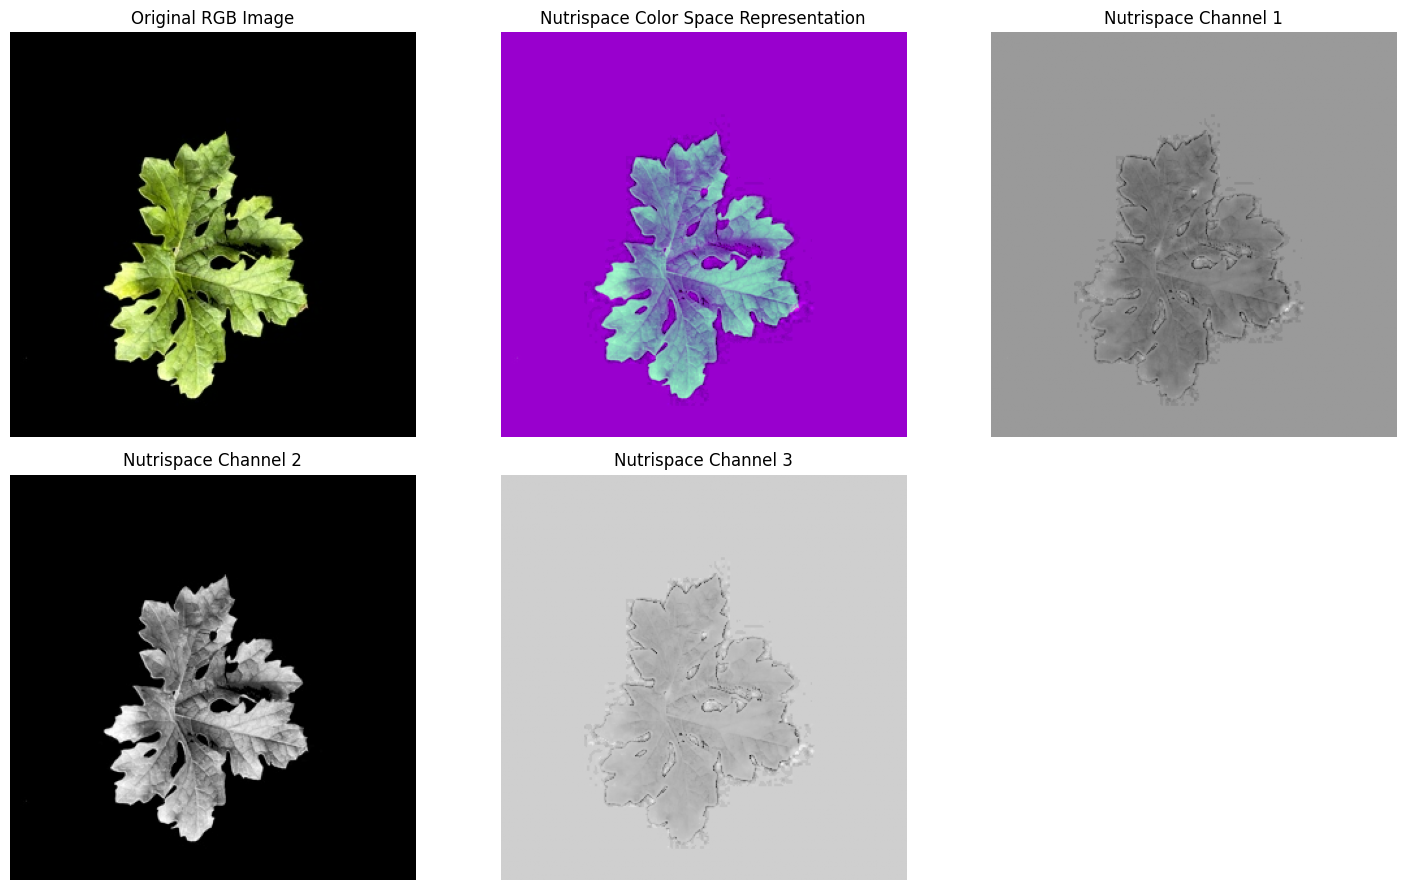


Original image and Nutrispace representation displayed.
Visualization saved:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Nutrispace_MobileNetV2_312_REDUCED_PATIENCE2/Original_RGB_vs_Nutrispace.png


CALCULATING CLASS WEIGHTS

Class weights:
Class 0: 1.0000
Class 1: 1.0000
Class 2: 1.0000
Class 3: 1.0000
Class 4: 1.0000
Class 5: 1.0000
Class 6: 1.0000
Class 7: 1.0000
Class 8: 1.0000


CREATING MOBILENETV2
MobileNetV2 ImageNet weights loaded.


NUTRISPACE + MOBILENETV2 MODEL SUMMARY


Model: "Nutrispace_MobileNetV2_Reduced"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ nutrispace_input (InputLayer)   │ (None, 312, 312, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Nutrispace_Adapter (Conv2D)     │ (None, 312, 312, 3)    │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Nutrispace_BatchNorm            │ (None, 312, 312, 3)    │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Nutrispace_to_255 (Rescaling)   │ (None, 312, 312, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV2_Preprocess          │ (None, 312, 312, 3)    │             0 │
│ (MobileNetPreprocess)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 10, 10, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GlobalAveragePooling            │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Head_BatchNorm                  │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Classification (Dense)          │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,274,654 (8.68 MB)

 Trainable params: 14,104 (55.09 KB)

 Non-trainable params: 2,260,550 (8.62 MB)



STAGE 1
MobileNetV2         : FROZEN
Nutrispace Adapter  : TRAINABLE
Classification Head : TRAINABLE
Batch Normalization : ENABLED
Training Shuffle    : ENABLED
Extra Shuffle       : DISABLED
Learning Rate       : 0.001
Maximum Epochs      : 20
LR Monitor          : val_accuracy
LR Patience         : 2
LR Factor           : 0.5


STAGE 1 TRAINING

Color Space: Nutrispace
Model: MobileNetV2
Training data shuffle: ON
Extra train_ds.shuffle(): OFF
Batch Normalization: ON
ReduceLROnPlateau monitor: val_accuracy
ReduceLROnPlateau patience: 2
Learning rate factor: 0.5
Stage 1 Learning Rate: 0.001


Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - accuracy: 0.3516 - loss: 1.9020
Epoch 1: val_accuracy improved from None to 0.29630, saving model to /home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Nutrispace_MobileNetV2_312_REDUCED_PATIENCE2/best_stage1_val_accuracy.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 53s 808ms/step - accuracy: 0.4635 - loss: 1.4845 - val_accuracy: 0.29

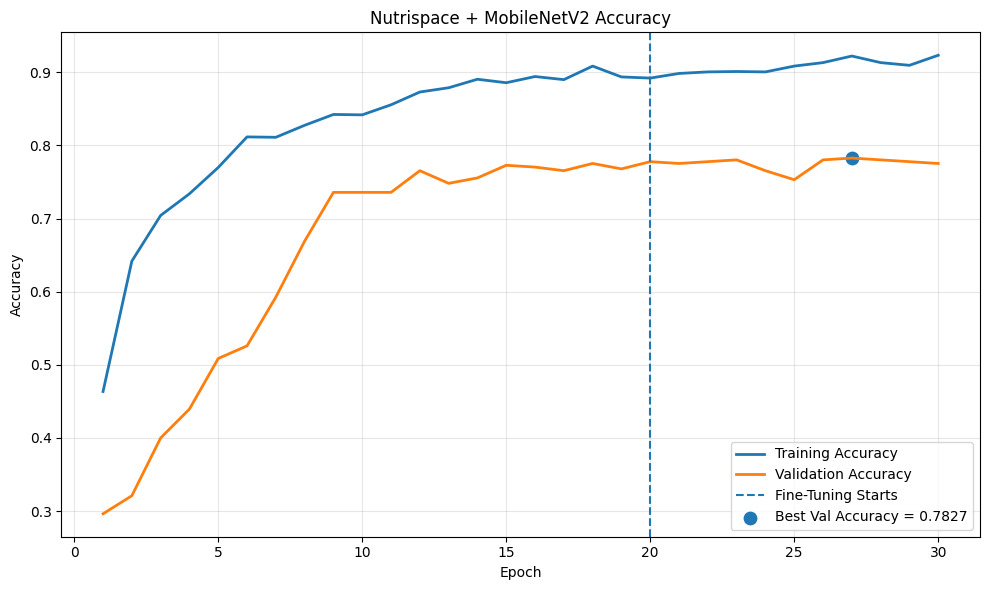

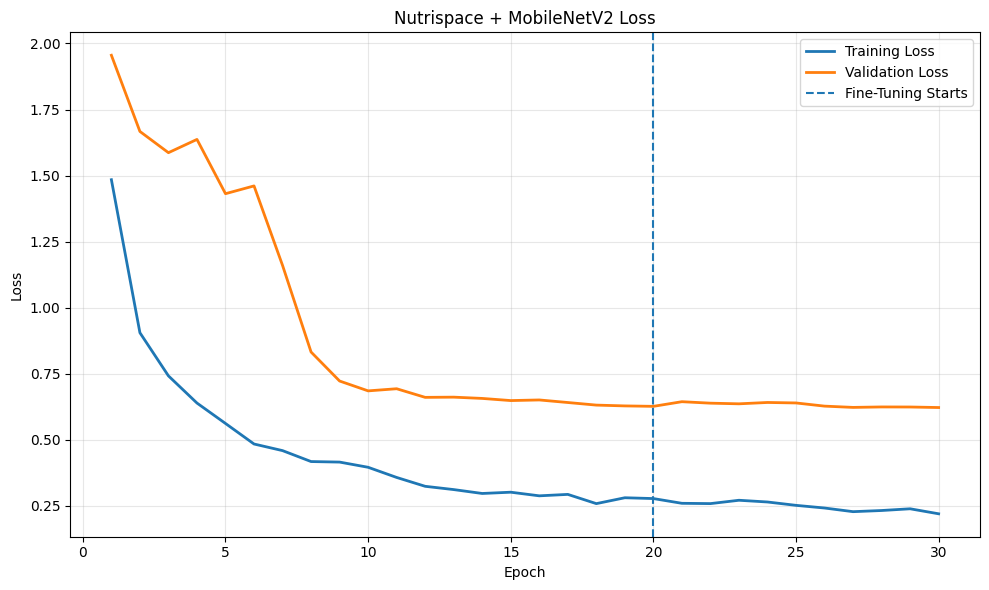



TEST SET EVALUATION
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 308ms/step - accuracy: 0.7556 - loss: 0.6541

Test Loss: 0.6541
Test Accuracy: 0.7556
Test Accuracy %: 75.56%

Generating predictions...

Macro F1 Score: 0.7537
Matthews Correlation Coefficient: 0.7258


CLASSIFICATION REPORT
                       precision    recall  f1-score   support

       ashgourd_fresh     0.5789    0.7333    0.6471        45
    ashgourd_nitrogen     0.8684    0.7333    0.7952        45
   ashgourd_potassium     0.6316    0.5333    0.5783        45
    bittergourd_fresh     0.7174    0.7333    0.7253        45
 bittergourd_nitrogen     0.7436    0.6444    0.6905        45
bittergourd_potassium     0.8627    0.9778    0.9167        45
     snakegourd_fresh     0.7727    0.7556    0.7640        45
  snakegourd_nitrogen     0.7907    0.7556    0.7727        45
 snakegourd_potassium     0.8571    0.9333    0.8936        45

             accuracy                         0.7556       405
            macro avg     0

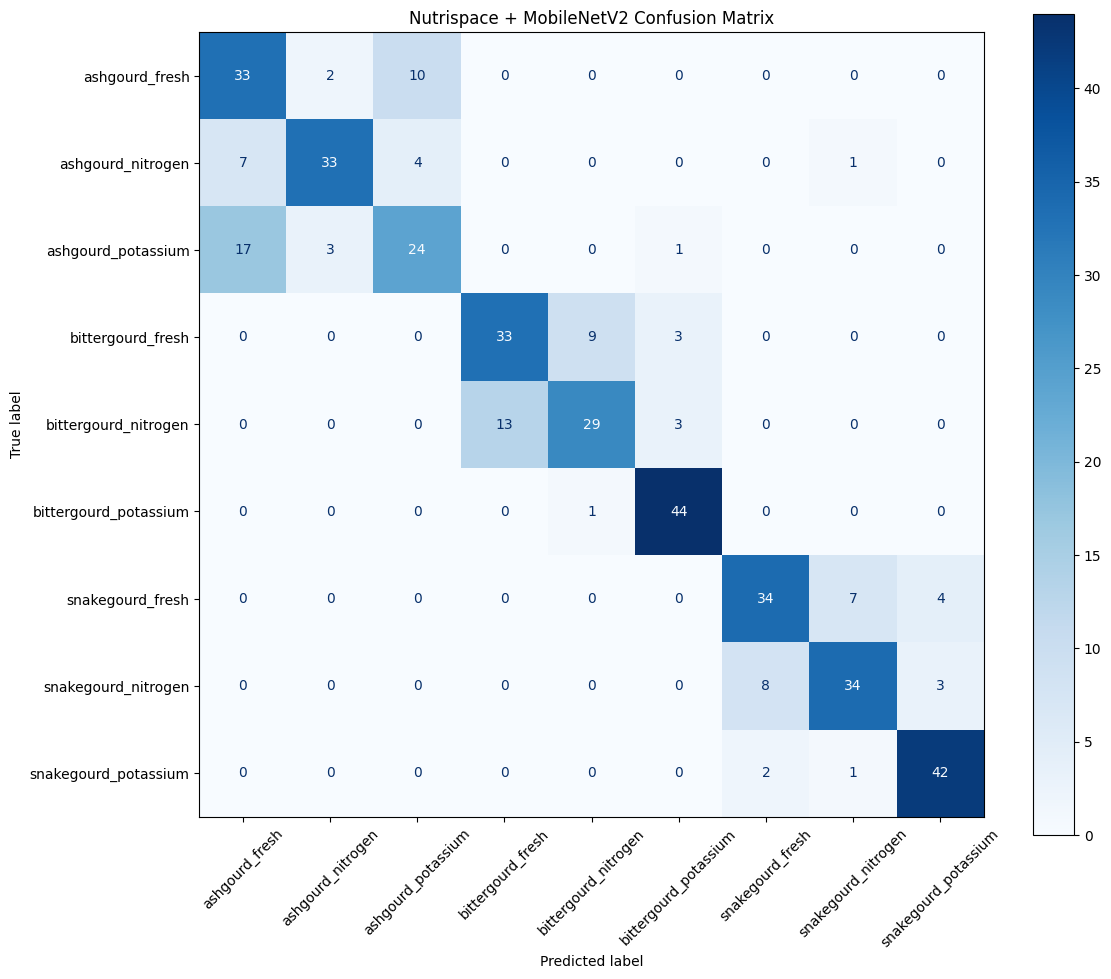



PER-CLASS ACCURACY
ashgourd_fresh: 0.7333 (73.33%)
ashgourd_nitrogen: 0.7333 (73.33%)
ashgourd_potassium: 0.5333 (53.33%)
bittergourd_fresh: 0.7333 (73.33%)
bittergourd_nitrogen: 0.6444 (64.44%)
bittergourd_potassium: 0.9778 (97.78%)
snakegourd_fresh: 0.7556 (75.56%)
snakegourd_nitrogen: 0.7556 (75.56%)
snakegourd_potassium: 0.9333 (93.33%)


VERIFYING KERAS MODEL SERIALIZATION
Model reload successful.
Keras serialization: OK


NUTRISPACE + REDUCED MOBILENETV2 COMPLETED

Best Validation Accuracy : 0.7827
Best Validation Accuracy : 78.27%
Best Epoch               : 27
Test Accuracy             : 0.7556
Test Accuracy             : 75.56%
Macro F1                  : 0.7537
MCC                       : 0.7258
Total Epochs Completed    : 30

--------------------------------------------------
MODEL CONFIGURATION
--------------------------------------------------
Model                     : MobileNetV2
Color Space               : Nutrispace
Image Size                : 312 x 312
Nutrispace RG

In [ ]:


import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.callbacks import (
    ReduceLROnPlateau,
    EarlyStopping,
    ModelCheckpoint,
    CSVLogger
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    matthews_corrcoef
)

from sklearn.utils.class_weight import compute_class_weight



SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


TRAIN_DIR = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/Train_256"
)

VAL_DIR = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/Val_resized312"
)

TEST_DIR = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/Test_resized312"
)





OUTPUT_DIR = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/"
    "Nutrispace_MobileNetV2_312_REDUCED_PATIENCE2"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


IMG_SIZE = (312, 312)

BATCH_SIZE = 32

NUM_CLASSES = 9



DROPOUT_RATE = 0.30

L2_VALUE = 1e-4


INITIAL_EPOCHS = 20

FINE_TUNE_EPOCHS = 10

TOTAL_EPOCHS = (
    INITIAL_EPOCHS +
    FINE_TUNE_EPOCHS
)


STAGE1_LR = 1e-3

STAGE2_LR = 5e-6


FINE_TUNE_LAYERS = 10



LR_FACTOR = 0.5

LR_PATIENCE = 2

STAGE1_MIN_LR = 1e-6

STAGE2_MIN_LR = 1e-8

STAGE1_EARLY_STOP_PATIENCE = 6

STAGE2_EARLY_STOP_PATIENCE = 4


print("\n")
print("=" * 70)
print("CHECKING DATASET DIRECTORIES")
print("=" * 70)


for name, path in [

    ("TRAIN", TRAIN_DIR),

    ("VALIDATION", VAL_DIR),

    ("TEST", TEST_DIR)

]:

    print(
        f"\n{name}:"
    )

    print(path)

    if not os.path.isdir(path):

        raise FileNotFoundError(
            f"\nDirectory does not exist:\n{path}"
        )

    print("OK")


print("=" * 70)
print("LOADING TRAINING DATASET")
print("=" * 70)


train_ds = tf.keras.utils.image_dataset_from_directory(

    TRAIN_DIR,

    labels="inferred",

    label_mode="categorical",

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=SEED

)



# CLASS INFORMATION


class_names = train_ds.class_names


print("\n")
print("=" * 70)
print("CLASS INFORMATION")
print("=" * 70)

print(
    "Number of classes:",
    len(class_names)
)

print(
    "Classes:",
    class_names
)


if len(class_names) != NUM_CLASSES:

    raise ValueError(

        f"Expected {NUM_CLASSES} classes "
        f"but found {len(class_names)}."

    )


print(
    "\nTraining shuffling: ENABLED"
)

print(
    "Method: image_dataset_from_directory(shuffle=True)"
)

print(
    "Extra explicit shuffle: DISABLED"
)



# LOAD VALIDATION DATASET


print("\n")
print("=" * 70)
print("LOADING VALIDATION DATASET")
print("=" * 70)


val_ds = tf.keras.utils.image_dataset_from_directory(

    VAL_DIR,

    labels="inferred",

    label_mode="categorical",

    class_names=class_names,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False

)


# LOAD TEST DATASET


print("\n")
print("=" * 70)
print("LOADING TEST DATASET")
print("=" * 70)


test_ds = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    labels="inferred",

    label_mode="categorical",

    class_names=class_names,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False

)




AUTOTUNE = tf.data.AUTOTUNE


CAM16 = np.array(

    [
        [0.401288,  0.650173, -0.051461],
        [-0.250268, 1.204414,  0.045854],
        [-0.002079, 0.048952,  0.953127]
    ],

    dtype=np.float64

)


CAM16_INV = np.linalg.inv(
    CAM16
)



# D65 REFERENCE WHITE


XR = 0.95047

YR = 1.00000

ZR = 1.08883



# REFERENCE WHITE u


UR = (

    4.0 * XR

    /

    (
        XR +
        15.0 * YR +
        3.0 * ZR
    )

)



# 14. NUTRISPACE HELPER FUNCTION f(t)


def nutrispace_f(t):

    t = np.asarray(
        t,
        dtype=np.float64
    )

    return np.where(

        t > 0.008856,

        np.cbrt(t),

        (
            7.787 * t
            +
            (4.0 / 29.0)
        )

    )


# ============================================================
#  RGB -> NUTRISPACE
# ============================================================
#
# PIPELINE:
#
# RGB [0,255]
#
#       ↓
#
# RGB [0,1]
#
#       ↓
#
# inverse CAM16
#
#       ↓
#
# CIEXYZ
#
#       ↓
#
# Nutrispace Channel 1
# Nutrispace Channel 2
# Nutrispace Channel 3
#
#       ↓
#
# channel-wise normalization
#
#       ↓
#
# [0,1]
#
# ============================================================

def rgb_to_nutrispace_numpy(
    image
):


    # Convert to float64


    image = np.asarray(
        image,
        dtype=np.float64
    )



    # Ensure valid RGB range


    image = np.clip(

        image,

        0.0,

        255.0

    )



    rgb = image / 255.0

    original_shape = rgb.shape


    rgb_flat = rgb.reshape(

        -1,

        3

    )


    xyz_flat = (

        CAM16_INV

        @

        rgb_flat.T

    ).T


    xyz = xyz_flat.reshape(

        original_shape

    )


    X = xyz[:, :, 0]

    Y = xyz[:, :, 1]

    Z = xyz[:, :, 2]



    # STEP 3
    
    # Channel 1 = 13 * L * (u - ur)



    y_ratio = Y / YR


    L = np.where(

        y_ratio > 0.008856,

        (
            116.0 *
            np.cbrt(
                np.maximum(
                    y_ratio,
                    0.0
                )
            )
            -
            16.0
        ),

        (
            903.3 *
            y_ratio
        )

    )


    denominator = (

        X

        +

        15.0 * Y

        +

        3.0 * Z

    )


    denominator = np.where(

        np.abs(denominator) < 1e-12,

        1e-12,

        denominator

    )


    u = (

        4.0 * X

        /

        denominator

    )


    channel_1 = (

        13.0

        *

        L

        *

        (
            u - UR
        )

    )


    # ============
    # STEP 4
    # CHANNEL 2
    # ============
    #
    # Channel 2 =
    #
    # 0.40024 X
    # +
    # 0.7076 Y
    # -
    # 0.08081 Z
    #
    # ===========

    channel_2 = (

        0.40024 * X

        +

        0.7076 * Y

        -

        0.08081 * Z

    )


    # ==========
    # STEP 5
    # CHANNEL 3
    # ==========
    #
    # Channel 3 =
    #
    # 500 [
    #
    # f(X/Xr)
    #
    # -
    #
    # f(Y/Yr)
    #
    # ]
    #
    # ===========

    channel_3 = (

        500.0

        *

        (

            nutrispace_f(
                X / XR
            )

            -

            nutrispace_f(
                Y / YR
            )

        )

    )


    
    # STACK CHANNELS


    nutrispace = np.stack(

        [

            channel_1,

            channel_2,

            channel_3

        ],

        axis=-1

    )



    # REMOVE NaN / INF
 

    nutrispace = np.nan_to_num(

        nutrispace,

        nan=0.0,

        posinf=0.0,

        neginf=0.0

    )



    normalized = np.zeros_like(

        nutrispace,

        dtype=np.float32

    )


    for channel_index in range(3):

        channel = nutrispace[
            :,
            :,
            channel_index
        ]


        channel_min = np.min(
            channel
        )


        channel_max = np.max(
            channel
        )


        difference = (

            channel_max -
            channel_min

        )


        if difference > 1e-12:

            normalized[
                :,
                :,
                channel_index
            ] = (

                (
                    channel -
                    channel_min
                )

                /

                difference

            )

        else:

            normalized[
                :,
                :,
                channel_index
            ] = 0.0


    normalized = np.clip(

        normalized,

        0.0,

        1.0

    )


    return normalized



# BATCH RGB -> NUTRISPACE


def convert_batch_rgb_to_nutrispace(
    batch
):

    batch = np.asarray(
        batch
    )


    nutrispace_batch = np.empty(

        batch.shape,

        dtype=np.float32

    )


    for i in range(

        batch.shape[0]

    ):

        nutrispace_batch[i] = (

            rgb_to_nutrispace_numpy(

                batch[i]

            )

        )


    return nutrispace_batch



# TENSORFLOW NUTRISPACE FUNCTION


def rgb_to_nutrispace_normalized(
    images
):

    images = tf.cast(

        images,

        tf.float32

    )


    images = tf.clip_by_value(

        images,

        0.0,

        255.0

    )


    nutrispace_images = tf.numpy_function(

        func=convert_batch_rgb_to_nutrispace,

        inp=[images],

        Tout=tf.float32

    )


    nutrispace_images.set_shape(

        images.shape

    )


    return nutrispace_images



# APPLY NUTRISPACE PREPROCESSING


print("\n")
print("=" * 70)
print("APPLYING NUTRISPACE PREPROCESSING")
print("=" * 70)


train_ds_nutrispace = train_ds.map(

    lambda x, y: (

        rgb_to_nutrispace_normalized(x),

        y

    ),

    num_parallel_calls=AUTOTUNE

)


val_ds_nutrispace = val_ds.map(

    lambda x, y: (

        rgb_to_nutrispace_normalized(x),

        y

    ),

    num_parallel_calls=AUTOTUNE

)


test_ds_nutrispace = test_ds.map(

    lambda x, y: (

        rgb_to_nutrispace_normalized(x),

        y

    ),

    num_parallel_calls=AUTOTUNE

)



# PREFETCH


train_ds_nutrispace = (

    train_ds_nutrispace.prefetch(
        AUTOTUNE
    )

)


val_ds_nutrispace = (

    val_ds_nutrispace.prefetch(
        AUTOTUNE
    )

)


test_ds_nutrispace = (

    test_ds_nutrispace.prefetch(
        AUTOTUNE
    )

)



# NUTRISPACE SANITY CHECK


print("\n")
print("=" * 70)
print("NUTRISPACE SANITY CHECK")
print("=" * 70)


for sample_images, sample_labels in (

    train_ds_nutrispace.take(1)

):

    print(
        "Nutrispace shape:",
        sample_images.shape
    )

    print(
        "Minimum:",
        float(
            tf.reduce_min(
                sample_images
            ).numpy()
        )
    )

    print(
        "Maximum:",
        float(
            tf.reduce_max(
                sample_images
            ).numpy()
        )
    )

    print(
        "Mean:",
        float(
            tf.reduce_mean(
                sample_images
            ).numpy()
        )
    )

    break


print(
    "\nExpected Nutrispace normalized range:"
)

print(
    "0.0 to 1.0"
)



# ORIGINAL RGB VS NUTRISPACE VISUALIZATION


print("\n")
print("=" * 70)
print("ORIGINAL RGB VS NUTRISPACE COLOR SPACE")
print("=" * 70)


original_images, original_labels = next(

    iter(train_ds)

)


original_rgb = (

    original_images[0]

    .numpy()

    .astype(np.uint8)

)


nutrispace_image = (

    rgb_to_nutrispace_numpy(

        original_rgb

    )

)



# EXTRACT CHANNELS


nutri_channel_1 = (

    nutrispace_image[
        :,
        :,
        0
    ]

)


nutri_channel_2 = (

    nutrispace_image[
        :,
        :,
        1
    ]

)


nutri_channel_3 = (

    nutrispace_image[
        :,
        :,
        2
    ]

)



# PLOT


plt.figure(

    figsize=(15, 9)

)



# ORIGINAL RGB


plt.subplot(
    2,
    3,
    1
)

plt.imshow(
    original_rgb
)

plt.title(
    "Original RGB Image"
)

plt.axis(
    "off"
)


# NUTRISPACE


plt.subplot(
    2,
    3,
    2
)

plt.imshow(
    nutrispace_image
)

plt.title(
    "Nutrispace Color Space Representation"
)

plt.axis(
    "off"
)



# CHANNEL 1


plt.subplot(
    2,
    3,
    3
)

plt.imshow(

    nutri_channel_1,

    cmap="gray"

)

plt.title(
    "Nutrispace Channel 1"
)

plt.axis(
    "off"
)



# CHANNEL 2


plt.subplot(
    2,
    3,
    4
)

plt.imshow(

    nutri_channel_2,

    cmap="gray"

)

plt.title(
    "Nutrispace Channel 2"
)

plt.axis(
    "off"
)



# CHANNEL 3


plt.subplot(
    2,
    3,
    5
)

plt.imshow(

    nutri_channel_3,

    cmap="gray"

)

plt.title(
    "Nutrispace Channel 3"
)

plt.axis(
    "off"
)


plt.tight_layout()


visualization_path = os.path.join(

    OUTPUT_DIR,

    "Original_RGB_vs_Nutrispace.png"

)


plt.savefig(

    visualization_path,

    dpi=250,

    bbox_inches="tight"

)


plt.show()


print(
    "\nOriginal image and Nutrispace representation displayed."
)

print(
    "Visualization saved:"
)

print(
    visualization_path
)



# CLASS WEIGHTS


print("\n")
print("=" * 70)
print("CALCULATING CLASS WEIGHTS")
print("=" * 70)


all_train_labels = []


for _, labels_batch in train_ds:

    label_indices = np.argmax(

        labels_batch.numpy(),

        axis=1

    )


    all_train_labels.extend(

        label_indices.tolist()

    )


all_train_labels = np.array(

    all_train_labels

)


unique_classes = np.unique(

    all_train_labels

)


class_weights_array = compute_class_weight(

    class_weight="balanced",

    classes=unique_classes,

    y=all_train_labels

)


class_weights = {

    int(cls): float(weight)

    for cls, weight in zip(

        unique_classes,

        class_weights_array

    )

}


print(
    "\nClass weights:"
)


for cls, weight in class_weights.items():

    print(

        f"Class {cls}: "
        f"{weight:.4f}"

    )



# CREATE MOBILENETV2


print("\n")
print("=" * 70)
print("CREATING MOBILENETV2")
print("=" * 70)


base_model = MobileNetV2(

    weights="imagenet",

    include_top=False,

    input_shape=(

        312,
        312,
        3

    )

)


print(
    "MobileNetV2 ImageNet weights loaded."
)



base_model.trainable = False


@tf.keras.utils.register_keras_serializable(
    package="Nutrispace"
)
class MobileNetPreprocess(
    layers.Layer
):

    def call(
        self,
        inputs
    ):

        return (

            tf.keras.applications.mobilenet_v2.preprocess_input(

                inputs

            )

        )


    def get_config(
        self
    ):

        return super().get_config()



# CREATE NUTRISPACE + MOBILENET MODEL


def create_nutrispace_mobilenet_model():



    # INPUT


    inputs = layers.Input(

        shape=(

            312,
            312,
            3

        ),

        name="nutrispace_input"

    )


    x = layers.Conv2D(

        filters=3,

        kernel_size=1,

        padding="same",

        use_bias=False,

        kernel_regularizer=regularizers.l2(

            L2_VALUE

        ),

        name="Nutrispace_Adapter"

    )(inputs)



    # BATCH NORMALIZATION


    x = layers.BatchNormalization(

        name="Nutrispace_BatchNorm"

    )(x)

    x = layers.Rescaling(

        255.0,

        name="Nutrispace_to_255"

    )(x)

    x = MobileNetPreprocess(

        name="MobileNetV2_Preprocess"

    )(x)
    x = base_model(

        x,

        training=False

    )




    x = layers.GlobalAveragePooling2D(

        name="GlobalAveragePooling"

    )(x)


  

    x = layers.BatchNormalization(

        name="Head_BatchNorm"

    )(x)


    x = layers.Dropout(

        DROPOUT_RATE,

        name="Dropout"

    )(x)




    outputs = layers.Dense(

        NUM_CLASSES,

        activation="softmax",

        kernel_regularizer=regularizers.l2(

            L2_VALUE

        ),

        name="Classification"

    )(x)

    model = models.Model(

        inputs=inputs,

        outputs=outputs,

        name="Nutrispace_MobileNetV2_Reduced"

    )


    return model



# CREATE MODEL


model = create_nutrispace_mobilenet_model()

print("\n")
print("=" * 70)
print("NUTRISPACE + MOBILENETV2 MODEL SUMMARY")
print("=" * 70)


model.summary()

print("\n")
print("=" * 70)
print("STAGE 1")
print("=" * 70)


print(
    "MobileNetV2         : FROZEN"
)

print(
    "Nutrispace Adapter  : TRAINABLE"
)

print(
    "Classification Head : TRAINABLE"
)

print(
    "Batch Normalization : ENABLED"
)

print(
    "Training Shuffle    : ENABLED"
)

print(
    "Extra Shuffle       : DISABLED"
)

print(
    "Learning Rate       :",
    STAGE1_LR
)

print(
    "Maximum Epochs      :",
    INITIAL_EPOCHS
)

print(
    "LR Monitor          : val_accuracy"
)

print(
    "LR Patience         :",
    LR_PATIENCE
)

print(
    "LR Factor           :",
    LR_FACTOR
)



# STAGE 1 COMPILE


model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=STAGE1_LR,

        clipnorm=1.0

    ),

    loss="categorical_crossentropy",

    metrics=[

        "accuracy"

    ]

)



# STAGE 1 CALLBACK PATHS


stage1_checkpoint = os.path.join(

    OUTPUT_DIR,

    "best_stage1_val_accuracy.keras"

)


stage1_log = os.path.join(

    OUTPUT_DIR,

    "stage1_log.csv"

)


reduce_lr_stage1 = ReduceLROnPlateau(

    monitor="val_accuracy",

    mode="max",

    factor=LR_FACTOR,

    patience=LR_PATIENCE,

    min_lr=STAGE1_MIN_LR,

    verbose=1

)


# STAGE 1 EARLY STOPPING


early_stop_stage1 = EarlyStopping(

    monitor="val_accuracy",

    mode="max",

    patience=STAGE1_EARLY_STOP_PATIENCE,

    restore_best_weights=True,

    verbose=1

)


checkpoint_stage1 = ModelCheckpoint(

    filepath=stage1_checkpoint,

    monitor="val_accuracy",

    mode="max",

    save_best_only=True,

    verbose=1

)



# STAGE 1 CSV LOGGER


csv_logger_stage1 = CSVLogger(

    stage1_log,

    append=False

)



# STAGE 1 TRAINING


print("\n")
print("=" * 70)
print("STAGE 1 TRAINING")
print("=" * 70)


print(
    "\nColor Space: Nutrispace"
)

print(
    "Model: MobileNetV2"
)

print(
    "Training data shuffle: ON"
)

print(
    "Extra train_ds.shuffle(): OFF"
)

print(
    "Batch Normalization: ON"
)

print(
    "ReduceLROnPlateau monitor: val_accuracy"
)

print(
    "ReduceLROnPlateau patience: 2"
)

print(
    "Learning rate factor: 0.5"
)

print(
    "Stage 1 Learning Rate:",
    STAGE1_LR
)

print(
    "\n"
)


history_stage1 = model.fit(

    train_ds_nutrispace,

    validation_data=val_ds_nutrispace,

    epochs=INITIAL_EPOCHS,

    class_weight=class_weights,

    callbacks=[

        reduce_lr_stage1,

        early_stop_stage1,

        checkpoint_stage1,

        csv_logger_stage1

    ],

    verbose=1

)


# LOAD BEST STAGE 1 MODEL


if os.path.exists(

    stage1_checkpoint

):

    print(
        "\nLoading best Stage 1 model..."
    )


    model = tf.keras.models.load_model(

        stage1_checkpoint

    )


    print(
        "Best Stage 1 model loaded."
    )



# FIND MOBILENETV2 BACKBONE


base_model = None


for layer in model.layers:

    if isinstance(

        layer,

        tf.keras.Model

    ):

        if "mobilenet" in layer.name.lower():

            base_model = layer

            break


if base_model is None:

    raise RuntimeError(

        "MobileNetV2 backbone could not be found."

    )


print(

    "\nMobileNetV2 backbone found:",

    base_model.name

)



# STAGE 2


print("\n")
print("=" * 70)
print("STAGE 2: REDUCED FINE-TUNING")
print("=" * 70)





base_model.trainable = True


fine_tune_at = (

    len(base_model.layers)

    -

    FINE_TUNE_LAYERS

)


print(

    "Total MobileNetV2 layers:",

    len(base_model.layers)

)


print(

    "Requested final layers:",

    FINE_TUNE_LAYERS

)


print(

    "Fine-tuning starts at index:",

    fine_tune_at

)



for layer_index, layer in enumerate(

    base_model.layers

):

    if layer_index < fine_tune_at:

        layer.trainable = False

    else:

        layer.trainable = True


batchnorm_frozen = 0


for layer in base_model.layers:

    if isinstance(

        layer,

        tf.keras.layers.BatchNormalization

    ):

        layer.trainable = False

        batchnorm_frozen += 1


print(

    "MobileNetV2 BatchNorm layers frozen:",

    batchnorm_frozen

)

actual_trainable_layers = [

    layer.name

    for layer in base_model.layers

    if layer.trainable

]


print(
    "\nActual trainable MobileNetV2 layers:"
)


for name in actual_trainable_layers:

    print(
        name
    )


print(

    "\nActual number of trainable backbone layers:",

    len(actual_trainable_layers)

)


# STAGE 2 COMPILE


model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=STAGE2_LR,

        clipnorm=1.0

    ),

    loss="categorical_crossentropy",

    metrics=[

        "accuracy"

    ]

)


print(

    "\nStage 2 Learning Rate:",

    STAGE2_LR

)


print(

    "Stage 2 Maximum Epochs:",

    FINE_TUNE_EPOCHS

)


# 41. STAGE 2 CALLBACK PATHS

stage2_checkpoint = os.path.join(

    OUTPUT_DIR,

    "best_stage2_val_accuracy.keras"

)


stage2_log = os.path.join(

    OUTPUT_DIR,

    "stage2_log.csv"

)

reduce_lr_stage2 = ReduceLROnPlateau(

    monitor="val_accuracy",

    mode="max",

    factor=LR_FACTOR,

    patience=LR_PATIENCE,

    min_lr=STAGE2_MIN_LR,

    verbose=1

)



#  STAGE 2 EARLY STOPPING


early_stop_stage2 = EarlyStopping(

    monitor="val_accuracy",

    mode="max",

    patience=STAGE2_EARLY_STOP_PATIENCE,

    restore_best_weights=True,

    verbose=1

)


checkpoint_stage2 = ModelCheckpoint(

    filepath=stage2_checkpoint,

    monitor="val_accuracy",

    mode="max",

    save_best_only=True,

    verbose=1

)

csv_logger_stage2 = CSVLogger(

    stage2_log,

    append=False

)

print("\n")
print("=" * 70)
print("STAGE 2 TRAINING")
print("=" * 70)


print(
    "\nColor Space: Nutrispace"
)

print(
    "Model: MobileNetV2"
)

print(
    "Training data shuffle: ON"
)

print(
    "Extra train_ds.shuffle(): OFF"
)

print(
    "ReduceLROnPlateau monitor: val_accuracy"
)

print(
    "ReduceLROnPlateau patience: 2"
)

print(
    "Learning rate factor: 0.5"
)

print(
    "Stage 2 Learning Rate:",
    STAGE2_LR
)

print(
    "\n"
)


history_stage2 = model.fit(

    train_ds_nutrispace,

    validation_data=val_ds_nutrispace,

    epochs=FINE_TUNE_EPOCHS,

    class_weight=class_weights,

    callbacks=[

        reduce_lr_stage2,

        early_stop_stage2,

        checkpoint_stage2,

        csv_logger_stage2

    ],

    verbose=1

)



# LOAD BEST STAGE 2 MODEL


if os.path.exists(

    stage2_checkpoint

):

    print(

        "\nLoading best Stage 2 model..."

    )


    model = tf.keras.models.load_model(

        stage2_checkpoint

    )


    print(

        "Best Stage 2 model loaded."

    )



# COMBINE HISTORY


train_accuracy = (

    history_stage1.history["accuracy"]

    +

    history_stage2.history["accuracy"]

)


val_accuracy = (

    history_stage1.history["val_accuracy"]

    +

    history_stage2.history["val_accuracy"]

)


train_loss = (

    history_stage1.history["loss"]

    +

    history_stage2.history["loss"]

)


val_loss = (

    history_stage1.history["val_loss"]

    +

    history_stage2.history["val_loss"]

)


actual_total_epochs = len(

    train_accuracy

)


epochs_range = range(

    1,

    actual_total_epochs + 1

)



# VALIDATION ACCURACY SUMMARY


best_val_accuracy = max(

    val_accuracy

)


best_epoch = (

    np.argmax(

        val_accuracy

    )

    +

    1

)


initial_val_accuracy = val_accuracy[0]

final_val_accuracy = val_accuracy[-1]


print("\n")
print("=" * 70)
print("VALIDATION ACCURACY SUMMARY")
print("=" * 70)


print(

    f"Initial Val Accuracy : "
    f"{initial_val_accuracy:.4f}"

)


print(

    f"Best Val Accuracy    : "
    f"{best_val_accuracy:.4f}"

)


print(

    f"Best Val Accuracy %  : "
    f"{best_val_accuracy * 100:.2f}%"

)


print(

    f"Best Epoch           : "
    f"{best_epoch}"

)


print(

    f"Final Val Accuracy   : "
    f"{final_val_accuracy:.4f}"

)


print(

    f"Improvement          : "
    f"{best_val_accuracy - initial_val_accuracy:+.4f}"

)


print("=" * 70)



# ACCURACY GRAPH


plt.figure(

    figsize=(10, 6)

)


plt.plot(

    epochs_range,

    train_accuracy,

    label="Training Accuracy",

    linewidth=2

)


plt.plot(

    epochs_range,

    val_accuracy,

    label="Validation Accuracy",

    linewidth=2

)


plt.axvline(

    x=len(
        history_stage1.history["accuracy"]
    ),

    linestyle="--",

    linewidth=1.5,

    label="Fine-Tuning Starts"

)


plt.scatter(

    best_epoch,

    best_val_accuracy,

    s=80,

    label=(

        f"Best Val Accuracy = "
        f"{best_val_accuracy:.4f}"

    )

)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)


plt.title(

    "Nutrispace + MobileNetV2 Accuracy"

)


plt.legend()

plt.grid(

    True,

    alpha=0.3

)

plt.tight_layout()


accuracy_plot_path = os.path.join(

    OUTPUT_DIR,

    "Nutrispace_MobileNetV2_Accuracy.png"

)


plt.savefig(

    accuracy_plot_path,

    dpi=250,

    bbox_inches="tight"

)


plt.show()


# LOSS GRAPH


plt.figure(

    figsize=(10, 6)

)


plt.plot(

    epochs_range,

    train_loss,

    label="Training Loss",

    linewidth=2

)


plt.plot(

    epochs_range,

    val_loss,

    label="Validation Loss",

    linewidth=2

)


plt.axvline(

    x=len(
        history_stage1.history["loss"]
    ),

    linestyle="--",

    linewidth=1.5,

    label="Fine-Tuning Starts"

)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)


plt.title(

    "Nutrispace + MobileNetV2 Loss"

)


plt.legend()

plt.grid(

    True,

    alpha=0.3

)

plt.tight_layout()


loss_plot_path = os.path.join(

    OUTPUT_DIR,

    "Nutrispace_MobileNetV2_Loss.png"

)


plt.savefig(

    loss_plot_path,

    dpi=250,

    bbox_inches="tight"

)


plt.show()



# TEST EVALUATION


print("\n")
print("=" * 70)
print("TEST SET EVALUATION")
print("=" * 70)


test_loss, test_accuracy = model.evaluate(

    test_ds_nutrispace,

    verbose=1

)


print(

    "\nTest Loss:",

    f"{test_loss:.4f}"

)


print(

    "Test Accuracy:",

    f"{test_accuracy:.4f}"

)


print(

    "Test Accuracy %:",

    f"{test_accuracy * 100:.2f}%"

)


# PREDICTIONS


print(

    "\nGenerating predictions..."

)


y_true = []

y_pred = []


for images, labels_batch in test_ds_nutrispace:


    predictions = model.predict(

        images,

        verbose=0

    )


    predicted_classes = np.argmax(

        predictions,

        axis=1

    )


    true_classes = np.argmax(

        labels_batch.numpy(),

        axis=1

    )


    y_true.extend(

        true_classes

    )


    y_pred.extend(

        predicted_classes

    )


y_true = np.array(

    y_true

)


y_pred = np.array(

    y_pred

)



# MACRO F1


macro_f1 = f1_score(

    y_true,

    y_pred,

    average="macro"

)


print(

    "\nMacro F1 Score:",

    f"{macro_f1:.4f}"

)


mcc = matthews_corrcoef(

    y_true,

    y_pred

)


print(

    "Matthews Correlation Coefficient:",

    f"{mcc:.4f}"

)



# CLASSIFICATION REPORT


print("\n")
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)


classification_text = classification_report(

    y_true,

    y_pred,

    target_names=class_names,

    digits=4,

    zero_division=0

)


print(

    classification_text

)


classification_report_path = os.path.join(

    OUTPUT_DIR,

    "classification_report.txt"

)


with open(

    classification_report_path,

    "w"

) as f:

    f.write(

        classification_text

    )



# CONFUSION MATRIX


cm = confusion_matrix(

    y_true,

    y_pred

)


plt.figure(

    figsize=(12, 10)

)


disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_names

)


disp.plot(

    cmap="Blues",

    xticks_rotation=45,

    ax=plt.gca(),

    values_format="d"

)


plt.title(

    "Nutrispace + MobileNetV2 Confusion Matrix"

)


plt.tight_layout()


confusion_matrix_path = os.path.join(

    OUTPUT_DIR,

    "Nutrispace_MobileNetV2_ConfusionMatrix.png"

)


plt.savefig(

    confusion_matrix_path,

    dpi=250,

    bbox_inches="tight"

)


plt.show()



# PER-CLASS ACCURACY


print("\n")
print("=" * 70)
print("PER-CLASS ACCURACY")
print("=" * 70)


per_class_results = []


for i, class_name in enumerate(

    class_names

):

    total = np.sum(

        cm[i]

    )


    correct = cm[i, i]


    if total > 0:

        class_accuracy = (

            correct /

            total

        )

    else:

        class_accuracy = 0.0


    per_class_results.append({

        "Class":
            class_name,

        "Accuracy":
            class_accuracy,

        "Correct":
            correct,

        "Total":
            total

    })


    print(

        f"{class_name}: "
        f"{class_accuracy:.4f} "
        f"({class_accuracy * 100:.2f}%)"

    )


per_class_df = pd.DataFrame(

    per_class_results

)


per_class_path = os.path.join(

    OUTPUT_DIR,

    "per_class_accuracy.csv"

)


per_class_df.to_csv(

    per_class_path,

    index=False

)



# SAVE TRAINING HISTORY


history_df = pd.DataFrame({

    "Epoch":
        list(epochs_range),

    "Training_Accuracy":
        train_accuracy,

    "Validation_Accuracy":
        val_accuracy,

    "Training_Loss":
        train_loss,

    "Validation_Loss":
        val_loss

})


history_path = os.path.join(

    OUTPUT_DIR,

    "training_history.csv"

)


history_df.to_csv(

    history_path,

    index=False

)



# FINAL RESULTS


results_df = pd.DataFrame({

    "Model":
        ["MobileNetV2"],

    "Color_Space":
        ["Nutrispace"],

    "Image_Size":
        ["312x312"],

    "Best_Validation_Accuracy":
        [best_val_accuracy],

    "Best_Validation_Epoch":
        [best_epoch],

    "Final_Validation_Accuracy":
        [final_val_accuracy],

    "Test_Accuracy":
        [test_accuracy],

    "Macro_F1":
        [macro_f1],

    "MCC":
        [mcc],

    "Dropout":
        [DROPOUT_RATE],

    "L2":
        [L2_VALUE],

    "Stage1_LR":
        [STAGE1_LR],

    "Stage2_LR":
        [STAGE2_LR],

    "Stage1_Epochs":
        [INITIAL_EPOCHS],

    "Stage2_Epochs":
        [FINE_TUNE_EPOCHS],

    "Fine_Tune_Last_Layers":
        [FINE_TUNE_LAYERS],

    "LR_Monitor":
        ["val_accuracy"],

    "LR_Patience":
        [LR_PATIENCE],

    "LR_Factor":
        [LR_FACTOR],

    "Batch_Normalization":
        ["Yes"],

    "Training_Shuffling":
        ["Yes"],

    "Extra_Explicit_Shuffle":
        ["No"],

    "Nutrispace_Normalization":
        ["Channel-wise 0-1"],

    "Model_Input_Range":
        ["-1 to 1"],

    "ReduceLROnPlateau":
        ["Yes"]

})


results_path = os.path.join(

    OUTPUT_DIR,

    "final_results.csv"

)


results_df.to_csv(

    results_path,

    index=False

)



# SAVE FINAL MODEL


MODEL_SAVE_PATH = os.path.join(

    OUTPUT_DIR,

    "Nutrispace_MobileNetV2_312_REDUCED_PATIENCE2.keras"

)


model.save(

    MODEL_SAVE_PATH

)


print("\n")
print("=" * 70)
print("VERIFYING KERAS MODEL SERIALIZATION")
print("=" * 70)


try:

    reloaded_model = tf.keras.models.load_model(

        MODEL_SAVE_PATH

    )


    print(
        "Model reload successful."
    )


    print(
        "Keras serialization: OK"
    )


except Exception as e:

    print(
        "MODEL RELOAD FAILED:"
    )


    print(
        str(e)
    )


    raise



#  FINAL OUTPUT


print("\n")
print("=" * 70)
print("NUTRISPACE + REDUCED MOBILENETV2 COMPLETED")
print("=" * 70)


print(

    f"\nBest Validation Accuracy : "
    f"{best_val_accuracy:.4f}"

)


print(

    f"Best Validation Accuracy : "
    f"{best_val_accuracy * 100:.2f}%"

)


print(

    f"Best Epoch               : "
    f"{best_epoch}"

)


print(

    f"Test Accuracy             : "
    f"{test_accuracy:.4f}"

)


print(

    f"Test Accuracy             : "
    f"{test_accuracy * 100:.2f}%"

)


print(

    f"Macro F1                  : "
    f"{macro_f1:.4f}"

)


print(

    f"MCC                       : "
    f"{mcc:.4f}"

)


print(

    f"Total Epochs Completed    : "
    f"{actual_total_epochs}"

)


print(
    "\n--------------------------------------------------"
)

print(
    "MODEL CONFIGURATION"
)

print(
    "--------------------------------------------------"
)


print(

    "Model                     : "
    "MobileNetV2"

)


print(

    "Color Space               : "
    "Nutrispace"

)


print(

    "Image Size                : "
    "312 x 312"

)


print(

    "Nutrispace RGB Input      : "
    "[0,1]"

)


print(

    "Nutrispace Normalization  : "
    "[0,1]"

)


print(

    "MobileNetV2 Input         : "
    "[-1,1]"

)


print(

    "MobileNet Fine-Tuning     : "
    f"Last {FINE_TUNE_LAYERS} layers"

)


print(

    "MobileNet BatchNorm       : "
    "Frozen during fine-tuning"

)


print(

    "Batch Normalization       : "
    "Enabled"

)


print(

    "Dropout                   : "
    f"{DROPOUT_RATE}"

)


print(

    "L2 Regularization         : "
    f"{L2_VALUE}"

)


print(
    "\n--------------------------------------------------"
)

print(
    "TRAINING CONFIGURATION"
)

print(
    "--------------------------------------------------"
)


print(

    "Training Shuffling        : "
    "Enabled"

)


print(

    "Shuffle Method            : "
    "image_dataset_from_directory(shuffle=True)"

)


print(

    "Extra Explicit Shuffle    : "
    "Disabled"

)


print(

    "Stage 1 Epochs            : "
    f"{INITIAL_EPOCHS}"

)


print(

    "Stage 2 Epochs            : "
    f"{FINE_TUNE_EPOCHS}"

)


print(

    "Stage 1 Learning Rate     : "
    f"{STAGE1_LR}"

)


print(

    "Stage 2 Learning Rate     : "
    f"{STAGE2_LR}"

)


print(

    "ReduceLROnPlateau         : "
    "Enabled"

)


print(

    "LR Monitor                : "
    "val_accuracy"

)


print(

    "LR Patience               : "
    f"{LR_PATIENCE}"

)


print(

    "LR Factor                 : "
    f"{LR_FACTOR}"

)


print(

    "EarlyStopping             : "
    "Enabled"

)


print(
    "\n--------------------------------------------------"
)

print(
    "NUTRISPACE VISUALIZATION"
)

print(
    "--------------------------------------------------"
)


print(

    "Original RGB Image        : "
    "Displayed"

)


print(

    "Nutrispace Representation : "
    "Displayed"

)


print(

    "Nutrispace Channel 1      : "
    "Displayed"

)


print(

    "Nutrispace Channel 2      : "
    "Displayed"

)


print(

    "Nutrispace Channel 3      : "
    "Displayed"

)


print(
    "\nOutput Directory:"
)

print(

    OUTPUT_DIR

)


print(
    "\nSaved files:"
)


print(

    "1. Original RGB vs Nutrispace:",

    visualization_path

)


print(

    "2. Accuracy Plot:",

    accuracy_plot_path

)


print(

    "3. Loss Plot:",

    loss_plot_path

)


print(

    "4. Confusion Matrix:",

    confusion_matrix_path

)


print(

    "5. Classification Report:",

    classification_report_path

)


print(

    "6. Per-Class Accuracy:",

    per_class_path

)


print(

    "7. Training History:",

    history_path

)


print(

    "8. Final Results:",

    results_path

)


print(

    "9. Final Model:",

    MODEL_SAVE_PATH

)


## Reducing overfitting Nutrispace



TENSORFLOW / GPU INFORMATION
TensorFlow version: 2.21.0


EXPERIMENT CONFIGURATION
Model                    : Nutrispace + MobileNetV2
Image size               : 312 x 312
Data augmentation        : DISABLED
1x1 adapter              : DISABLED
Per-image min-max        : DISABLED
Global train normalization: ENABLED
MobileNet RGB preprocess : DISABLED
Stage 1 LR               : 0.001
Stage 1 epochs           : 20
Stage 2 LR               : 1e-05
Stage 2 epochs           : 20
Fine-tune layers         : 10
Label smoothing          : 0.5
Dropout                  : 0.2
L2                       : 0.0005


CHECKING DATASET DIRECTORIES

TRAIN:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Train_256
OK

VALIDATION:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Val_resized312
OK

TEST:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Test_resized312
OK


LOADING TRAINING DATASET
Found 1890 files belonging to 9 classes.


CL

/tmp/ipykernel_306078/1938997933.py:1582: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(




MODEL SUMMARY


Model: "Nutrispace_MobileNetV2_Dropout04_LabelSmooth05"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Nutrispace_Input (InputLayer)   │ (None, 312, 312, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Nutrispace_Standardized         │ (None, 312, 312, 3)    │             0 │
│ (NutrispaceInput)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 10, 10, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GlobalAveragePooling            │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Classification_BatchNorm        │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Classification_Dropout          │ (None, 1280)           │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Classification_Output (Dense)   │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,274,633 (8.68 MB)

 Trainable params: 14,089 (55.04 KB)

 Non-trainable params: 2,260,544 (8.62 MB)



STAGE 1 CONFIGURATION
Backbone       : FROZEN
Learning Rate  : 0.001
Epochs         : 20
Label smoothing: 0.5


STARTING STAGE 1
Epochs: 20
Learning Rate: 0.001
Backbone: FROZEN
Data augmentation: DISABLED
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 695ms/step - accuracy: 0.2921 - loss: 2.6421
Epoch 1: val_accuracy improved from None to 0.27901, saving model to /home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Nutrispace_MobileNetV2_Dropout04_LabelSmooth05/stage1_best_val_accuracy.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 32s 911ms/step - accuracy: 0.3910 - loss: 2.4648 - val_accuracy: 0.2790 - val_loss: 2.1050 - learning_rate: 0.0010
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 740ms/step - accuracy: 0.5440 - loss: 2.1725
Epoch 2: val_accuracy improved from 0.27901 to 0.51111, saving model to /home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Nutrispace_MobileNetV2_Dropout04_LabelSmooth05/stage1_best_val_accuracy.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 29s 926ms/st

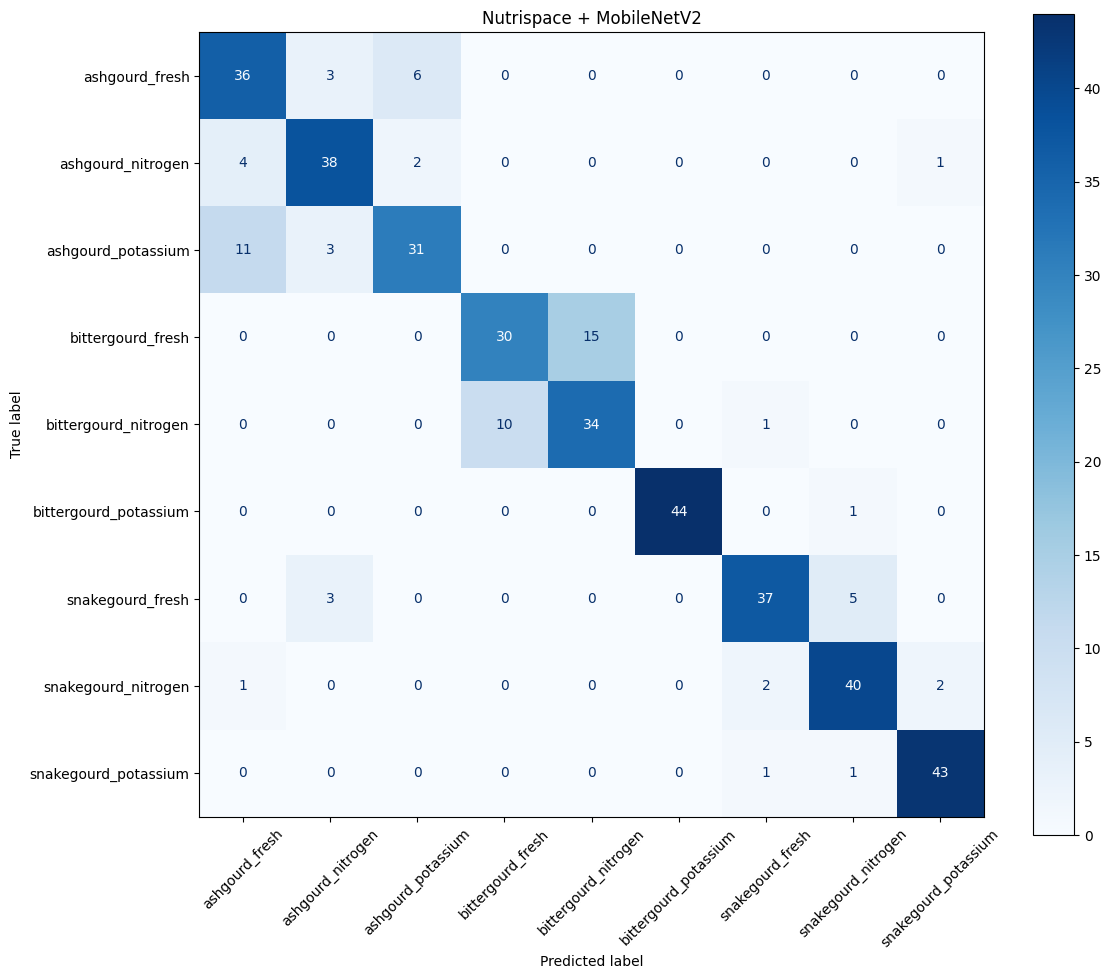

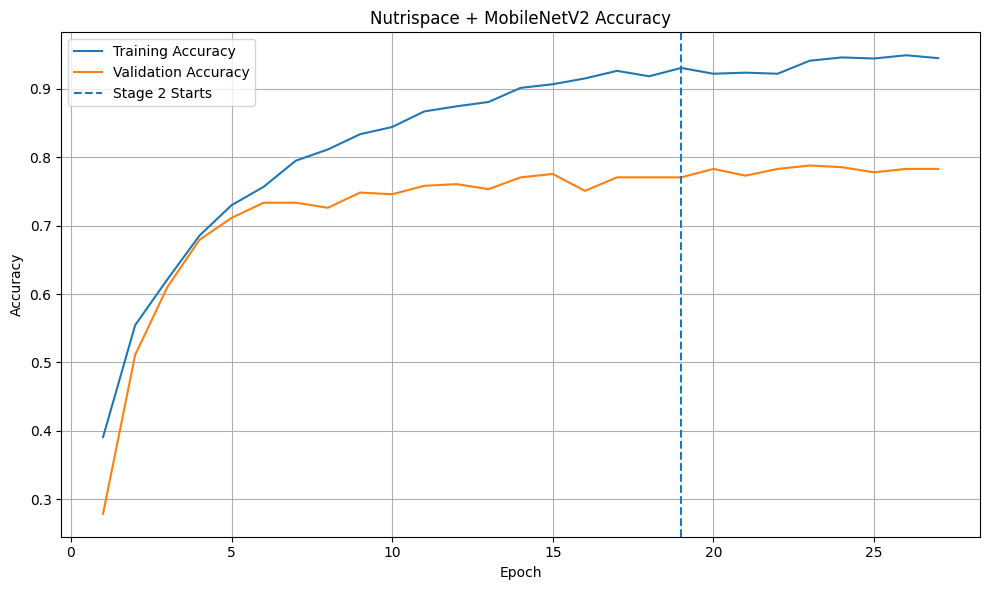

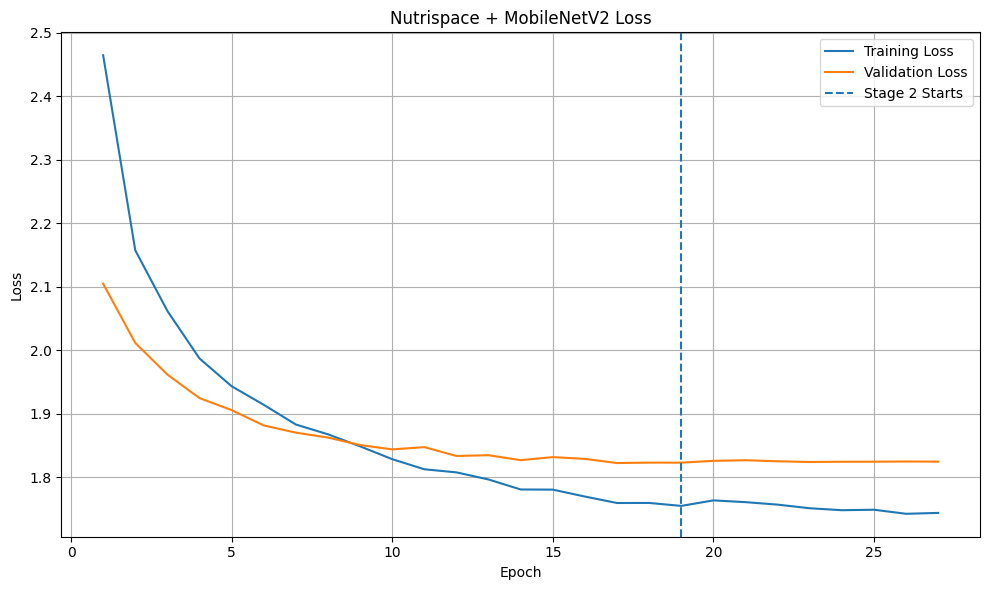



FINAL EXPERIMENT SUMMARY
Model: Nutrispace + MobileNetV2
Image size: 312 x 312
Data augmentation: DISABLED
1x1 adapter: REMOVED
Per-image min-max: REMOVED
Global train normalization: ENABLED
MobileNet RGB preprocess: DISABLED
Stage 1: 20 epochs @ 0.001
Stage 2: 20 epochs @ 1e-05
Fine-tuned layers: 10
Label smoothing: 0.5
Test Accuracy: 82.22%
Macro F1: 0.8222
MCC: 0.8004
Best Validation Accuracy: 78.77%
Best Validation Epoch: 23


All results saved to:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Nutrispace_MobileNetV2_Dropout04_LabelSmooth05


In [ ]:
import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau,
    EarlyStopping,
    ModelCheckpoint,
    CSVLogger
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    matthews_corrcoef
)


SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


print("\n")
print("=" * 75)
print("TENSORFLOW / GPU INFORMATION")
print("=" * 75)

print(
    "TensorFlow version:",
    tf.__version__
)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print(
        "GPUs detected:",
        len(gpus)
    )

    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(
                gpu,
                True
            )
        except Exception:
            pass
else:
    print(
        "WARNING: No GPU detected."
    )

print("=" * 75)


TRAIN_DIR = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/Train_256"
)

VAL_DIR = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/Val_resized312"
)

TEST_DIR = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/Test_resized312"
)


OUTPUT_DIR = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/"
    "Nutrispace_MobileNetV2_Dropout04_LabelSmooth05"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


IMG_SIZE = (
    312,
    312
)

BATCH_SIZE = 64
NUM_CLASSES = 9

DROPOUT_RATE = 0.2
L2_VALUE = 5e-4

STAGE1_EPOCHS = 20
STAGE2_EPOCHS = 20

TOTAL_EPOCHS = (
    STAGE1_EPOCHS +
    STAGE2_EPOCHS
)

STAGE1_LR = 1e-3
STAGE2_LR = 1e-5

FINE_TUNE_LAYERS = 10

LR_FACTOR = 0.3
LR_PATIENCE = 2

STAGE1_MIN_LR = 1e-5
STAGE2_MIN_LR = 1e-7

EARLY_STOP_PATIENCE = 4

LABEL_SMOOTHING = 0.50


print("\n")
print("=" * 75)
print("EXPERIMENT CONFIGURATION")
print("=" * 75)

print(
    "Model                    : Nutrispace + MobileNetV2"
)

print(
    "Image size               : 312 x 312"
)

print(
    "Data augmentation        : DISABLED"
)

print(
    "1x1 adapter              : DISABLED"
)

print(
    "Per-image min-max        : DISABLED"
)

print(
    "Global train normalization: ENABLED"
)

print(
    "MobileNet RGB preprocess : DISABLED"
)

print(
    "Stage 1 LR               :",
    STAGE1_LR
)

print(
    "Stage 1 epochs           :",
    STAGE1_EPOCHS
)

print(
    "Stage 2 LR               :",
    STAGE2_LR
)

print(
    "Stage 2 epochs           :",
    STAGE2_EPOCHS
)

print(
    "Fine-tune layers         :",
    FINE_TUNE_LAYERS
)

print(
    "Label smoothing          :",
    LABEL_SMOOTHING
)

print(
    "Dropout                  :",
    DROPOUT_RATE
)

print(
    "L2                       :",
    L2_VALUE
)

print("=" * 75)


print("\n")
print("=" * 75)
print("CHECKING DATASET DIRECTORIES")
print("=" * 75)

for name, path in [
    ("TRAIN", TRAIN_DIR),
    ("VALIDATION", VAL_DIR),
    ("TEST", TEST_DIR)
]:
    print(
        f"\n{name}:"
    )

    print(path)

    if not os.path.isdir(path):
        raise FileNotFoundError(
            f"\nDirectory does not exist:\n{path}"
        )

    print("OK")


print("\n")
print("=" * 75)
print("LOADING TRAINING DATASET")
print("=" * 75)

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)


class_names = train_ds.class_names


print("\n")
print("=" * 75)
print("CLASS INFORMATION")
print("=" * 75)

print(
    "Number of classes:",
    len(class_names)
)

print(
    "Classes:",
    class_names
)

if len(class_names) != NUM_CLASSES:
    raise ValueError(
        f"Expected {NUM_CLASSES} classes "
        f"but found {len(class_names)}."
    )


print("\n")
print("=" * 75)
print("LOADING VALIDATION DATASET")
print("=" * 75)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


print("\n")
print("=" * 75)
print("LOADING TEST DATASET")
print("=" * 75)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


print("\n")
print("=" * 75)
print("DATASET BATCH INFORMATION")
print("=" * 75)

train_batches = tf.data.experimental.cardinality(
    train_ds
).numpy()

val_batches = tf.data.experimental.cardinality(
    val_ds
).numpy()

test_batches = tf.data.experimental.cardinality(
    test_ds
).numpy()

print(
    "Training batches   :",
    train_batches
)

print(
    "Validation batches :",
    val_batches
)

print(
    "Testing batches    :",
    test_batches
)

print("\n")

print(
    "Training shuffle   : ENABLED"
)

print(
    "Validation shuffle : DISABLED"
)

print(
    "Test shuffle       : DISABLED"
)


AUTOTUNE = tf.data.AUTOTUNE


CAM16 = np.array(
    [
        [
            0.401288,
            0.650173,
            -0.051461
        ],
        [
            -0.250268,
            1.204414,
            0.045854
        ],
        [
            -0.002079,
            0.048952,
            0.953127
        ]
    ],
    dtype=np.float64
)


CAM16_INV = np.linalg.inv(CAM16)


XR = 0.95047
YR = 1.00000
ZR = 1.08883


UR = (
    4.0 *
    XR /
    (
        XR +
        15.0 * YR +
        3.0 * ZR
    )
)


def nutrispace_f(t):

    t = np.asarray(
        t,
        dtype=np.float64
    )

    return np.where(
        t > 0.008856,
        np.cbrt(t),
        (
            7.787 * t +
            (4.0 / 29.0)
        )
    )


def rgb_to_nutrispace_numpy(image):

    image = np.asarray(
        image,
        dtype=np.float64
    )

    image = np.clip(
        image,
        0.0,
        255.0
    )

    rgb = image / 255.0

    original_shape = rgb.shape

    rgb_flat = rgb.reshape(
        -1,
        3
    )

    xyz_flat = (
        CAM16_INV @ rgb_flat.T
    ).T

    xyz = xyz_flat.reshape(
        original_shape
    )

    X = xyz[:, :, 0]
    Y = xyz[:, :, 1]
    Z = xyz[:, :, 2]

    y_ratio = (
        Y /
        YR
    )

    L = np.where(
        y_ratio > 0.008856,
        (
            116.0 *
            np.cbrt(
                np.maximum(
                    y_ratio,
                    0.0
                )
            )
            -
            16.0
        ),
        (
            903.3 *
            y_ratio
        )
    )

    denominator = (
        X +
        15.0 * Y +
        3.0 * Z
    )

    denominator = np.where(
        np.abs(denominator) < 1e-12,
        1e-12,
        denominator
    )

    u = (
        4.0 *
        X /
        denominator
    )

    channel_1 = (
        13.0 *
        L *
        (
            u -
            UR
        )
    )

    channel_2 = (
        0.40024 *
        X
        +
        0.7076 *
        Y
        -
        0.08081 *
        Z
    )

    channel_3 = (
        500.0 *
        (
            nutrispace_f(
                X / XR
            )
            -
            nutrispace_f(
                Y / YR
            )
        )
    )

    nutrispace = np.stack(
        [
            channel_1,
            channel_2,
            channel_3
        ],
        axis=-1
    )

    nutrispace = np.nan_to_num(
        nutrispace,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    return nutrispace.astype(
        np.float32
    )


def convert_batch_rgb_to_nutrispace(batch):

    batch = np.asarray(batch)

    output = np.empty(
        batch.shape,
        dtype=np.float32
    )

    for i in range(
        batch.shape[0]
    ):
        output[i] = (
            rgb_to_nutrispace_numpy(
                batch[i]
            )
        )

    return output


def rgb_to_nutrispace(images):

    images = tf.cast(
        images,
        tf.float32
    )

    images = tf.clip_by_value(
        images,
        0.0,
        255.0
    )

    result = tf.numpy_function(
        func=convert_batch_rgb_to_nutrispace,
        inp=[images],
        Tout=tf.float32
    )

    result.set_shape(
        images.shape
    )

    return result


print("\n")
print("=" * 75)
print("CONVERTING TRAINING DATA TO NUTRISPACE")
print("=" * 75)

print(
    "Additional augmentation: DISABLED"
)

train_ds_nutrispace_raw = train_ds.map(
    lambda x, y: (
        rgb_to_nutrispace(x),
        y
    ),
    num_parallel_calls=AUTOTUNE
)


print("\n")
print("=" * 75)
print("CONVERTING VALIDATION DATA TO NUTRISPACE")
print("=" * 75)

val_ds_nutrispace_raw = val_ds.map(
    lambda x, y: (
        rgb_to_nutrispace(x),
        y
    ),
    num_parallel_calls=AUTOTUNE
)


print("\n")
print("=" * 75)
print("CONVERTING TEST DATA TO NUTRISPACE")
print("=" * 75)

test_ds_nutrispace_raw = test_ds.map(
    lambda x, y: (
        rgb_to_nutrispace(x),
        y
    ),
    num_parallel_calls=AUTOTUNE
)


print("\n")
print("=" * 75)
print("CALCULATING GLOBAL NUTRISPACE STATISTICS")
print("=" * 75)

print(
    "Using TRAINING DATA ONLY..."
)

sum_channels = np.zeros(
    3,
    dtype=np.float64
)

sum_squared_channels = np.zeros(
    3,
    dtype=np.float64
)

pixel_count = 0

for images, labels in train_ds_nutrispace_raw:

    images_np = images.numpy().astype(
        np.float64
    )

    pixels = images_np.reshape(
        -1,
        3
    )

    sum_channels += np.sum(
        pixels,
        axis=0
    )

    sum_squared_channels += np.sum(
        pixels ** 2,
        axis=0
    )

    pixel_count += pixels.shape[0]


nutrispace_mean = (
    sum_channels /
    pixel_count
)

nutrispace_variance = (
    (
        sum_squared_channels /
        pixel_count
    )
    -
    (
        nutrispace_mean ** 2
    )
)

nutrispace_variance = np.maximum(
    nutrispace_variance,
    1e-12
)

nutrispace_std = np.sqrt(
    nutrispace_variance
)


print("\n")

print(
    "Training pixels used:",
    pixel_count
)

print(
    "\nGlobal Nutrispace statistics:"
)

print(
    f"Channel 1 Mean: "
    f"{nutrispace_mean[0]:.6f}"
)

print(
    f"Channel 1 Std : "
    f"{nutrispace_std[0]:.6f}"
)

print(
    f"\nChannel 2 Mean: "
    f"{nutrispace_mean[1]:.6f}"
)

print(
    f"Channel 2 Std : "
    f"{nutrispace_std[1]:.6f}"
)

print(
    f"\nChannel 3 Mean: "
    f"{nutrispace_mean[2]:.6f}"
)

print(
    f"Channel 3 Std : "
    f"{nutrispace_std[2]:.6f}"
)


mean_tensor = tf.constant(
    nutrispace_mean,
    dtype=tf.float32
)

std_tensor = tf.constant(
    nutrispace_std,
    dtype=tf.float32
)


def normalize_nutrispace(
    images,
    labels
):

    images = tf.cast(
        images,
        tf.float32
    )

    normalized = (
        images -
        mean_tensor
    ) / std_tensor

    return (
        normalized,
        labels
    )


train_ds_nutrispace = (
    train_ds_nutrispace_raw
    .map(
        normalize_nutrispace,
        num_parallel_calls=AUTOTUNE
    )
)

val_ds_nutrispace = (
    val_ds_nutrispace_raw
    .map(
        normalize_nutrispace,
        num_parallel_calls=AUTOTUNE
    )
)

test_ds_nutrispace = (
    test_ds_nutrispace_raw
    .map(
        normalize_nutrispace,
        num_parallel_calls=AUTOTUNE
    )
)


train_ds_nutrispace = (
    train_ds_nutrispace
    .prefetch(AUTOTUNE)
)

val_ds_nutrispace = (
    val_ds_nutrispace
    .prefetch(AUTOTUNE)
)

test_ds_nutrispace = (
    test_ds_nutrispace
    .prefetch(AUTOTUNE)
)


print("\n")
print("=" * 75)
print("NORMALIZED NUTRISPACE SANITY CHECK")
print("=" * 75)

sample_images, sample_labels = next(
    iter(
        train_ds_nutrispace
    )
)

print(
    "Batch shape:",
    sample_images.shape
)

print(
    "Data type:",
    sample_images.dtype
)

for channel in range(3):

    channel_data = (
        sample_images[
            :, :, :, channel
        ]
    )

    print(
        f"\nChannel {channel + 1}:"
    )

    print(
        "Minimum:",
        float(
            tf.reduce_min(
                channel_data
            ).numpy()
        )
    )

    print(
        "Maximum:",
        float(
            tf.reduce_max(
                channel_data
            ).numpy()
        )
    )

    print(
        "Mean:",
        float(
            tf.reduce_mean(
                channel_data
            ).numpy()
        )
    )

    print(
        "Std:",
        float(
            tf.math.reduce_std(
                channel_data
            ).numpy()
        )
    )


@tf.keras.utils.register_keras_serializable(
    package="Nutrispace"
)
class NutrispaceInput(
    layers.Layer
):

    def __init__(
        self,
        **kwargs
    ):
        super().__init__(
            **kwargs
        )

    def call(
        self,
        inputs
    ):
        return tf.cast(
            inputs,
            tf.float32
        )

    def get_config(
        self
    ):
        return super().get_config()


print("\n")
print("=" * 75)
print("CREATING MOBILENETV2")
print("=" * 75)

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(
        IMG_SIZE[0],
        IMG_SIZE[1],
        3
    )
)

base_model.trainable = False


inputs = layers.Input(
    shape=(
        IMG_SIZE[0],
        IMG_SIZE[1],
        3
    ),
    name="Nutrispace_Input"
)

x = NutrispaceInput(
    name="Nutrispace_Standardized"
)(inputs)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D(
    name="GlobalAveragePooling"
)(x)

x = layers.BatchNormalization(
    name="Classification_BatchNorm"
)(x)

x = layers.Dropout(
    DROPOUT_RATE,
    name="Classification_Dropout"
)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    kernel_regularizer=regularizers.l2(
        L2_VALUE
    ),
    name="Classification_Output"
)(x)


model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="Nutrispace_MobileNetV2_Dropout04_LabelSmooth05"
)


print("\n")
print("=" * 75)
print("MODEL SUMMARY")
print("=" * 75)

model.summary()


loss_function = (
    tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=LABEL_SMOOTHING
    )
)


print("\n")
print("=" * 75)
print("STAGE 1 CONFIGURATION")
print("=" * 75)

print(
    "Backbone       : FROZEN"
)

print(
    "Learning Rate  :",
    STAGE1_LR
)

print(
    "Epochs         :",
    STAGE1_EPOCHS
)

print(
    "Label smoothing:",
    LABEL_SMOOTHING
)


model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=STAGE1_LR
    ),
    loss=loss_function,
    metrics=[
        "accuracy"
    ]
)


stage1_checkpoint = os.path.join(
    OUTPUT_DIR,
    "stage1_best_val_accuracy.keras"
)

stage1_csv = os.path.join(
    OUTPUT_DIR,
    "stage1_training_log.csv"
)


stage1_callbacks = [

    ModelCheckpoint(
        stage1_checkpoint,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=LR_FACTOR,
        patience=LR_PATIENCE,
        min_lr=STAGE1_MIN_LR,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=EARLY_STOP_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    CSVLogger(
        stage1_csv,
        append=False
    )
]


print("\n")
print("=" * 75)
print("STARTING STAGE 1")
print("=" * 75)

print(
    "Epochs:",
    STAGE1_EPOCHS
)

print(
    "Learning Rate:",
    STAGE1_LR
)

print(
    "Backbone:",
    "FROZEN"
)

print(
    "Data augmentation:",
    "DISABLED"
)

print("=" * 75)


history_stage1 = model.fit(
    train_ds_nutrispace,
    validation_data=val_ds_nutrispace,
    epochs=STAGE1_EPOCHS,
    callbacks=stage1_callbacks,
    verbose=1
)


if os.path.exists(
    stage1_checkpoint
):

    print("\n")

    print(
        "Loading best Stage 1 model..."
    )

    model = tf.keras.models.load_model(
        stage1_checkpoint,
        custom_objects={
            "NutrispaceInput":
            NutrispaceInput
        },
        compile=False
    )


base_model = None

for layer in model.layers:

    if isinstance(
        layer,
        tf.keras.Model
    ):

        if (
            "mobilenetv2"
            in layer.name.lower()
        ):

            base_model = layer

            break


if base_model is None:
    raise ValueError(
        "Could not find MobileNetV2 "
        "backbone inside the model."
    )


print("\n")
print("=" * 75)
print("PREPARING STAGE 2")
print("=" * 75)


base_model.trainable = True

for layer in base_model.layers:
    layer.trainable = False


for layer in base_model.layers[
    -FINE_TUNE_LAYERS:
]:

    if isinstance(
        layer,
        layers.BatchNormalization
    ):

        layer.trainable = False

    else:

        layer.trainable = True


print("\n")
print("=" * 75)
print("TRAINABLE MOBILE NET V2 LAYERS")
print("=" * 75)

trainable_count = 0

for layer in base_model.layers:

    if layer.trainable:

        print(
            "TRAINABLE:",
            layer.name
        )

        trainable_count += 1


print("\n")

print(
    "Trainable backbone layers:",
    trainable_count
)


print("\n")
print("=" * 75)
print("STAGE 2 CONFIGURATION")
print("=" * 75)

print(
    "Fine-tuning layers:",
    FINE_TUNE_LAYERS
)

print(
    "Learning Rate:",
    STAGE2_LR
)

print(
    "Epochs:",
    STAGE2_EPOCHS
)

print(
    "BatchNorm:",
    "FROZEN"
)

print("=" * 75)


model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=STAGE2_LR
    ),
    loss=loss_function,
    metrics=[
        "accuracy"
    ]
)


stage2_checkpoint = os.path.join(
    OUTPUT_DIR,
    "stage2_best_val_accuracy.keras"
)

stage2_csv = os.path.join(
    OUTPUT_DIR,
    "stage2_training_log.csv"
)


stage2_callbacks = [

    ModelCheckpoint(
        stage2_checkpoint,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=LR_FACTOR,
        patience=LR_PATIENCE,
        min_lr=STAGE2_MIN_LR,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=EARLY_STOP_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    CSVLogger(
        stage2_csv,
        append=False
    )
]


print("\n")
print("=" * 75)
print("STARTING STAGE 2")
print("=" * 75)

stage1_epochs_ran = len(
    history_stage1.history.get(
        "accuracy",
        []
    )
)

stage2_total_epochs = (
    stage1_epochs_ran +
    STAGE2_EPOCHS
)

print(
    "Stage 2 starts from Epoch:",
    stage1_epochs_ran + 1
)

print(
    "Final Epoch:",
    TOTAL_EPOCHS
)

print(
    "Learning Rate:",
    STAGE2_LR
)

print(
    "Fine-tuned Layers:",
    FINE_TUNE_LAYERS
)

print("=" * 75)


history_stage2 = model.fit(
    train_ds_nutrispace,
    validation_data=val_ds_nutrispace,
    initial_epoch=stage1_epochs_ran,
    epochs=stage2_total_epochs,
    callbacks=stage2_callbacks,
    verbose=1
)


if os.path.exists(
    stage2_checkpoint
):

    print("\n")

    print(
        "Loading best Stage 2 model..."
    )

    model = tf.keras.models.load_model(
        stage2_checkpoint,
        custom_objects={
            "NutrispaceInput":
            NutrispaceInput
        },
        compile=False
    )


final_model_path = os.path.join(
    OUTPUT_DIR,
    "Nutrispace_MobileNetV2_Dropout04_LabelSmooth05_FINAL.keras"
)

model.save(
    final_model_path
)


print("\n")
print("=" * 75)
print("FINAL MODEL SAVED")
print("=" * 75)

print(
    final_model_path
)


model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=STAGE2_LR
    ),
    loss=loss_function,
    metrics=[
        "accuracy"
    ]
)


print("\n")
print("=" * 75)
print("TEST EVALUATION")
print("=" * 75)

test_loss, test_accuracy = model.evaluate(
    test_ds_nutrispace,
    verbose=1
)


print("\n")
print("=" * 75)
print("TEST RESULTS")
print("=" * 75)

print(
    f"Test Loss     : {test_loss:.4f}"
)

print(
    f"Test Accuracy : {test_accuracy:.4f}"
)

print(
    f"Test Accuracy : "
    f"{test_accuracy * 100:.2f}%"
)


print("\n")
print("=" * 75)
print("GENERATING TEST PREDICTIONS")
print("=" * 75)

y_true = []
y_pred = []

for images, labels in test_ds_nutrispace:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    true_classes = np.argmax(
        labels.numpy(),
        axis=1
    )

    y_pred.extend(
        predicted_classes
    )

    y_true.extend(
        true_classes
    )


y_true = np.array(
    y_true
)

y_pred = np.array(
    y_pred
)


print("\n")
print("=" * 75)
print("CLASSIFICATION REPORT")
print("=" * 75)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(
    report
)


report_path = os.path.join(
    OUTPUT_DIR,
    "classification_report.txt"
)

with open(
    report_path,
    "w"
) as f:

    f.write(
        report
    )


macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

print(
    "\nMacro F1:",
    f"{macro_f1:.4f}"
)


mcc = matthews_corrcoef(
    y_true,
    y_pred
)

print(
    "MCC:",
    f"{mcc:.4f}"
)


cm = confusion_matrix(
    y_true,
    y_pred
)


print("\n")
print("=" * 75)
print("CONFUSION MATRIX")
print("=" * 75)

print(cm)


plt.figure(
    figsize=(12, 10)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=45,
    cmap="Blues",
    ax=plt.gca(),
    colorbar=True
)

plt.title(
    "Nutrispace + MobileNetV2"
)

plt.tight_layout()

cm_path = os.path.join(
    OUTPUT_DIR,
    "confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


stage1_accuracy = (
    history_stage1
    .history
    .get(
        "accuracy",
        []
    )
)

stage1_val_accuracy = (
    history_stage1
    .history
    .get(
        "val_accuracy",
        []
    )
)

stage1_loss = (
    history_stage1
    .history
    .get(
        "loss",
        []
    )
)

stage1_val_loss = (
    history_stage1
    .history
    .get(
        "val_loss",
        []
    )
)

stage2_accuracy = (
    history_stage2
    .history
    .get(
        "accuracy",
        []
    )
)

stage2_val_accuracy = (
    history_stage2
    .history
    .get(
        "val_accuracy",
        []
    )
)

stage2_loss = (
    history_stage2
    .history
    .get(
        "loss",
        []
    )
)

stage2_val_loss = (
    history_stage2
    .history
    .get(
        "val_loss",
        []
    )
)


all_accuracy = (
    stage1_accuracy +
    stage2_accuracy
)

all_val_accuracy = (
    stage1_val_accuracy +
    stage2_val_accuracy
)

all_loss = (
    stage1_loss +
    stage2_loss
)

all_val_loss = (
    stage1_val_loss +
    stage2_val_loss
)


epochs = range(
    1,
    len(all_accuracy) + 1
)


best_val_accuracy = max(
    all_val_accuracy
)

best_val_epoch = (
    np.argmax(
        all_val_accuracy
    )
    + 1
)


plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs,
    all_accuracy,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    all_val_accuracy,
    label="Validation Accuracy"
)

plt.axvline(
    x=stage1_epochs_ran,
    linestyle="--",
    label="Stage 2 Starts"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Nutrispace + MobileNetV2 Accuracy"
)

plt.legend()

plt.grid(
    True
)

plt.tight_layout()

accuracy_path = os.path.join(
    OUTPUT_DIR,
    "accuracy_curve.png"
)

plt.savefig(
    accuracy_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs,
    all_loss,
    label="Training Loss"
)

plt.plot(
    epochs,
    all_val_loss,
    label="Validation Loss"
)

plt.axvline(
    x=stage1_epochs_ran,
    linestyle="--",
    label="Stage 2 Starts"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Nutrispace + MobileNetV2 Loss"
)

plt.legend()

plt.grid(
    True
)

plt.tight_layout()

loss_path = os.path.join(
    OUTPUT_DIR,
    "loss_curve.png"
)

plt.savefig(
    loss_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


results_path = os.path.join(
    OUTPUT_DIR,
    "final_results.txt"
)

with open(
    results_path,
    "w"
) as f:

    f.write(
        "Nutrispace + MobileNetV2\n"
    )

    f.write(
        "========================================\n"
    )

    f.write(
        f"Image Size: {IMG_SIZE}\n"
    )

    f.write(
        "Data Augmentation: DISABLED\n"
    )

    f.write(
        "1x1 Adapter: DISABLED\n"
    )

    f.write(
        "Per-image Min-Max: DISABLED\n"
    )

    f.write(
        "Global Training Normalization: ENABLED\n"
    )

    f.write(
        "MobileNet preprocess_input: DISABLED\n"
    )

    f.write(
        f"Stage 1 LR: {STAGE1_LR}\n"
    )

    f.write(
        f"Stage 1 Epochs: {STAGE1_EPOCHS}\n"
    )

    f.write(
        f"Stage 2 LR: {STAGE2_LR}\n"
    )

    f.write(
        f"Stage 2 Epochs: {STAGE2_EPOCHS}\n"
    )

    f.write(
        f"Fine Tune Layers: {FINE_TUNE_LAYERS}\n"
    )

    f.write(
        f"Label Smoothing: {LABEL_SMOOTHING}\n"
    )

    f.write(
        f"Test Accuracy: "
        f"{test_accuracy * 100:.2f}%\n"
    )

    f.write(
        f"Macro F1: "
        f"{macro_f1:.4f}\n"
    )

    f.write(
        f"MCC: "
        f"{mcc:.4f}\n"
    )

    f.write(
        f"Best Validation Accuracy: "
        f"{best_val_accuracy * 100:.2f}%\n"
    )

    f.write(
        f"Best Validation Epoch: "
        f"{best_val_epoch}\n"
    )


print("\n")
print("=" * 75)
print("FINAL EXPERIMENT SUMMARY")
print("=" * 75)

print(
    "Model:",
    "Nutrispace + MobileNetV2"
)

print(
    "Image size:",
    "312 x 312"
)

print(
    "Data augmentation:",
    "DISABLED"
)

print(
    "1x1 adapter:",
    "REMOVED"
)

print(
    "Per-image min-max:",
    "REMOVED"
)

print(
    "Global train normalization:",
    "ENABLED"
)

print(
    "MobileNet RGB preprocess:",
    "DISABLED"
)

print(
    "Stage 1:",
    f"{STAGE1_EPOCHS} epochs @ {STAGE1_LR}"
)

print(
    "Stage 2:",
    f"{STAGE2_EPOCHS} epochs @ {STAGE2_LR}"
)

print(
    "Fine-tuned layers:",
    FINE_TUNE_LAYERS
)

print(
    "Label smoothing:",
    LABEL_SMOOTHING
)

print(
    "Test Accuracy:",
    f"{test_accuracy * 100:.2f}%"
)

print(
    "Macro F1:",
    f"{macro_f1:.4f}"
)

print(
    "MCC:",
    f"{mcc:.4f}"
)

print(
    "Best Validation Accuracy:",
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    "Best Validation Epoch:",
    best_val_epoch
)

print("=" * 75)

print("\n")

print(
    "All results saved to:"
)

print(
    OUTPUT_DIR
)

print("=" * 75)

## Nutrispace -- EfficientNet



TENSORFLOW / GPU INFORMATION
TensorFlow version: 2.21.0


EXPERIMENT CONFIGURATION
Model                    : Nutrispace + EfficientNetB0
Image size               : 312 x 312
Data augmentation        : DISABLED
1x1 adapter              : DISABLED
Per-image min-max        : DISABLED
Global train normalization: ENABLED
EfficientNet RGB preprocess : DISABLED
Stage 1 LR               : 0.001
Stage 1 epochs           : 20
Stage 2 LR               : 1e-05
Stage 2 epochs           : 20
Fine-tune layers         : 10
Label smoothing          : 0.5
Dropout                  : 0.3
L2                       : 0.0005


CHECKING DATASET DIRECTORIES

TRAIN:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Train_256
OK

VALIDATION:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Val_resized312
OK

TEST:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Test_resized312
OK


LOADING TRAINING DATASET
Found 1890 files belonging to 9 classes

Model: "Nutrispace_EfficientNetB0_Dropout03_LabelSmooth05"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Nutrispace_Input (InputLayer)   │ (None, 312, 312, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Nutrispace_Standardized         │ (None, 312, 312, 3)    │             0 │
│ (NutrispaceInput)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 10, 10, 1280)   │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GlobalAveragePooling            │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Classification_BatchNorm        │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Classification_Dropout          │ (None, 1280)           │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Classification_Output (Dense)   │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,066,220 (15.51 MB)

 Trainable params: 14,089 (55.04 KB)

 Non-trainable params: 4,052,131 (15.46 MB)



STAGE 1 CONFIGURATION
Backbone       : FROZEN
Learning Rate  : 0.001
Epochs         : 20
Label smoothing: 0.5


STARTING STAGE 1
Epochs: 20
Learning Rate: 0.001
Backbone: FROZEN
Data augmentation: DISABLED
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 933ms/step - accuracy: 0.2135 - loss: 2.4207
Epoch 1: val_accuracy improved from None to 0.14074, saving model to /home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Nutrispace_EfficientNetB0_Dropout03_LabelSmooth05/stage1_best_val_accuracy.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.2794 - loss: 2.3315 - val_accuracy: 0.1407 - val_loss: 2.1755 - learning_rate: 0.0010
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 915ms/step - accuracy: 0.4121 - loss: 2.1926
Epoch 2: val_accuracy improved from 0.14074 to 0.20247, saving model to /home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Nutrispace_EfficientNetB0_Dropout03_LabelSmooth05/stage1_best_val_accuracy.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/st

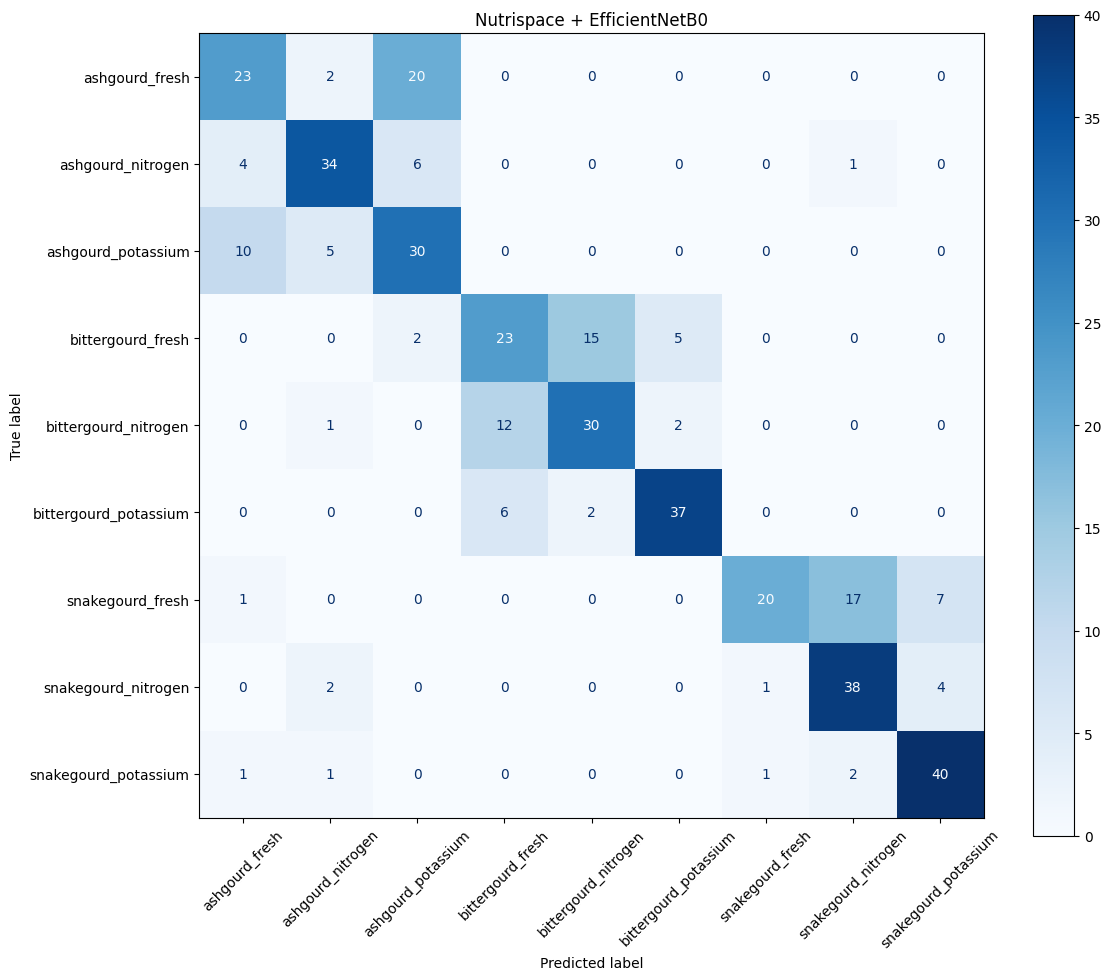

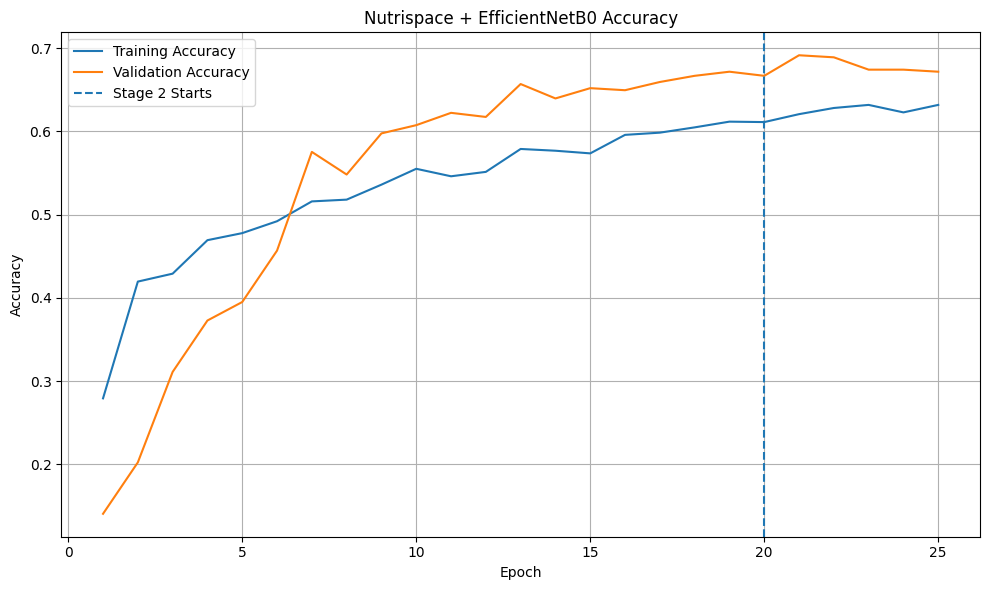

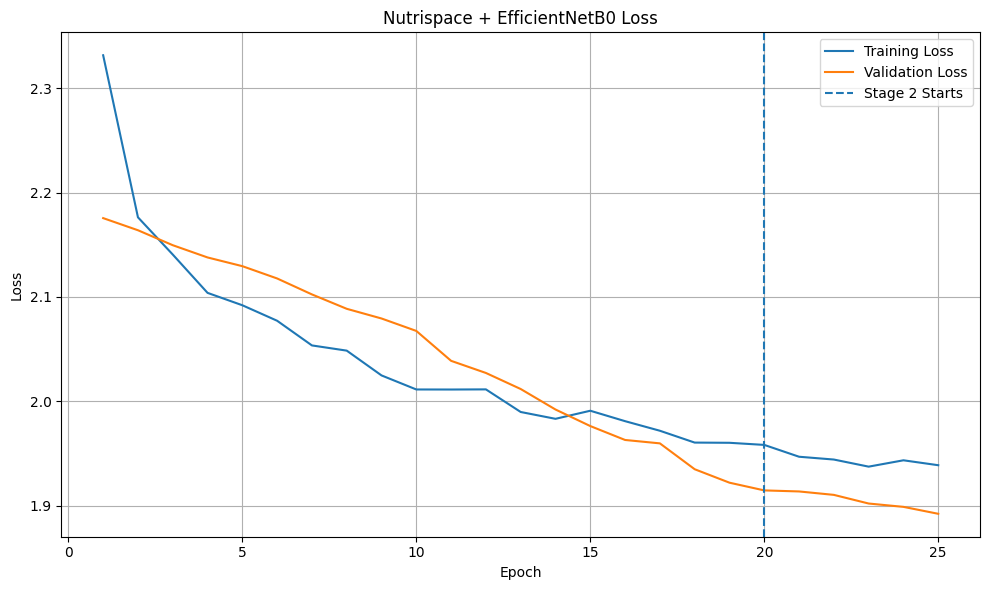



FINAL EXPERIMENT SUMMARY
Model: Nutrispace + EfficientNetB0
Image size: 312 x 312
Data augmentation: DISABLED
1x1 adapter: REMOVED
Per-image min-max: REMOVED
Global train normalization: ENABLED
EfficientNet RGB preprocess: DISABLED
Stage 1: 20 epochs @ 0.001
Stage 2: 20 epochs @ 1e-05
Fine-tuned layers: 10
Label smoothing: 0.5
Test Accuracy: 67.90%
Macro F1: 0.6747
MCC: 0.6410
Best Validation Accuracy: 69.14%
Best Validation Epoch: 21


All results saved to:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Nutrispace_EfficientNetB0_Dropout03_LabelSmooth05


In [ ]:
import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau,
    EarlyStopping,
    ModelCheckpoint,
    CSVLogger
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    matthews_corrcoef
)


SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


print("\n")
print("=" * 75)
print("TENSORFLOW / GPU INFORMATION")
print("=" * 75)

print(
    "TensorFlow version:",
    tf.__version__
)

gpus = tf.config.list_physical_devices("GPU")

if gpus:

    print(
        "GPUs detected:",
        len(gpus)
    )

    for gpu in gpus:

        try:
            tf.config.experimental.set_memory_growth(
                gpu,
                True
            )

        except Exception:
            pass

else:

    print(
        "WARNING: No GPU detected."
    )

print("=" * 75)


TRAIN_DIR = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/Train_256"
)

VAL_DIR = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/Val_resized312"
)

TEST_DIR = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/Test_resized312"
)


OUTPUT_DIR = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/"
    "Nutrispace_EfficientNetB0_Dropout03_LabelSmooth05"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


IMG_SIZE = (
    312,
    312
)

BATCH_SIZE = 64
NUM_CLASSES = 9

DROPOUT_RATE = 0.30
L2_VALUE = 5e-4

STAGE1_EPOCHS = 20
STAGE2_EPOCHS = 20

TOTAL_EPOCHS = (
    STAGE1_EPOCHS +
    STAGE2_EPOCHS
)

STAGE1_LR = 0.001
STAGE2_LR = 0.00001

FINE_TUNE_LAYERS = 10

LR_FACTOR = 0.3
LR_PATIENCE = 2

STAGE1_MIN_LR = 1e-5
STAGE2_MIN_LR = 1e-7

EARLY_STOP_PATIENCE = 4

LABEL_SMOOTHING = 0.50


print("\n")
print("=" * 75)
print("EXPERIMENT CONFIGURATION")
print("=" * 75)

print(
    "Model                    : Nutrispace + EfficientNetB0"
)

print(
    "Image size               : 312 x 312"
)

print(
    "Data augmentation        : DISABLED"
)

print(
    "1x1 adapter              : DISABLED"
)

print(
    "Per-image min-max        : DISABLED"
)

print(
    "Global train normalization: ENABLED"
)

print(
    "EfficientNet RGB preprocess : DISABLED"
)

print(
    "Stage 1 LR               :",
    STAGE1_LR
)

print(
    "Stage 1 epochs           :",
    STAGE1_EPOCHS
)

print(
    "Stage 2 LR               :",
    STAGE2_LR
)

print(
    "Stage 2 epochs           :",
    STAGE2_EPOCHS
)

print(
    "Fine-tune layers         :",
    FINE_TUNE_LAYERS
)

print(
    "Label smoothing          :",
    LABEL_SMOOTHING
)

print(
    "Dropout                  :",
    DROPOUT_RATE
)

print(
    "L2                       :",
    L2_VALUE
)

print("=" * 75)


print("\n")
print("=" * 75)
print("CHECKING DATASET DIRECTORIES")
print("=" * 75)

for name, path in [
    ("TRAIN", TRAIN_DIR),
    ("VALIDATION", VAL_DIR),
    ("TEST", TEST_DIR)
]:

    print(
        f"\n{name}:"
    )

    print(
        path
    )

    if not os.path.isdir(path):

        raise FileNotFoundError(
            f"\nDirectory does not exist:\n{path}"
        )

    print(
        "OK"
    )


print("\n")
print("=" * 75)
print("LOADING TRAINING DATASET")
print("=" * 75)

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)


class_names = train_ds.class_names


print("\n")
print("=" * 75)
print("CLASS INFORMATION")
print("=" * 75)

print(
    "Number of classes:",
    len(class_names)
)

print(
    "Classes:",
    class_names
)

if len(class_names) != NUM_CLASSES:

    raise ValueError(
        f"Expected {NUM_CLASSES} classes "
        f"but found {len(class_names)}."
    )


print("\n")
print("=" * 75)
print("LOADING VALIDATION DATASET")
print("=" * 75)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


print("\n")
print("=" * 75)
print("LOADING TEST DATASET")
print("=" * 75)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


print("\n")
print("=" * 75)
print("DATASET BATCH INFORMATION")
print("=" * 75)

train_batches = tf.data.experimental.cardinality(
    train_ds
).numpy()

val_batches = tf.data.experimental.cardinality(
    val_ds
).numpy()

test_batches = tf.data.experimental.cardinality(
    test_ds
).numpy()

print(
    "Training batches   :",
    train_batches
)

print(
    "Validation batches :",
    val_batches
)

print(
    "Testing batches    :",
    test_batches
)

print("\n")

print(
    "Training shuffle   : ENABLED"
)

print(
    "Validation shuffle : DISABLED"
)

print(
    "Test shuffle       : DISABLED"
)


AUTOTUNE = tf.data.AUTOTUNE


CAM16 = np.array(
    [
        [
            0.401288,
            0.650173,
            -0.051461
        ],
        [
            -0.250268,
            1.204414,
            0.045854
        ],
        [
            -0.002079,
            0.048952,
            0.953127
        ]
    ],
    dtype=np.float64
)


CAM16_INV = np.linalg.inv(
    CAM16
)


XR = 0.95047
YR = 1.00000
ZR = 1.08883


UR = (
    4.0
    *
    XR
    /
    (
        XR
        +
        15.0 * YR
        +
        3.0 * ZR
    )
)


def nutrispace_f(t):

    t = np.asarray(
        t,
        dtype=np.float64
    )

    return np.where(
        t > 0.008856,
        np.cbrt(t),
        (
            7.787 * t
            +
            (4.0 / 29.0)
        )
    )


def rgb_to_nutrispace_numpy(
    image
):

    image = np.asarray(
        image,
        dtype=np.float64
    )

    image = np.clip(
        image,
        0.0,
        255.0
    )

    rgb = image / 255.0

    original_shape = rgb.shape

    rgb_flat = rgb.reshape(
        -1,
        3
    )

    xyz_flat = (
        CAM16_INV
        @
        rgb_flat.T
    ).T

    xyz = xyz_flat.reshape(
        original_shape
    )

    X = xyz[:, :, 0]
    Y = xyz[:, :, 1]
    Z = xyz[:, :, 2]

    y_ratio = (
        Y
        /
        YR
    )

    L = np.where(
        y_ratio > 0.008856,
        (
            116.0
            *
            np.cbrt(
                np.maximum(
                    y_ratio,
                    0.0
                )
            )
            -
            16.0
        ),
        (
            903.3
            *
            y_ratio
        )
    )

    denominator = (
        X
        +
        15.0 * Y
        +
        3.0 * Z
    )

    denominator = np.where(
        np.abs(
            denominator
        )
        <
        1e-12,
        1e-12,
        denominator
    )

    u = (
        4.0
        *
        X
        /
        denominator
    )

    channel_1 = (
        13.0
        *
        L
        *
        (
            u
            -
            UR
        )
    )

    channel_2 = (
        0.40024
        *
        X
        +
        0.7076
        *
        Y
        -
        0.08081
        *
        Z
    )

    channel_3 = (
        500.0
        *
        (
            nutrispace_f(
                X / XR
            )
            -
            nutrispace_f(
                Y / YR
            )
        )
    )

    nutrispace = np.stack(
        [
            channel_1,
            channel_2,
            channel_3
        ],
        axis=-1
    )

    nutrispace = np.nan_to_num(
        nutrispace,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    return nutrispace.astype(
        np.float32
    )


def convert_batch_rgb_to_nutrispace(
    batch
):

    batch = np.asarray(
        batch
    )

    output = np.empty(
        batch.shape,
        dtype=np.float32
    )

    for i in range(
        batch.shape[0]
    ):

        output[i] = (
            rgb_to_nutrispace_numpy(
                batch[i]
            )
        )

    return output


def rgb_to_nutrispace(
    images
):

    images = tf.cast(
        images,
        tf.float32
    )

    images = tf.clip_by_value(
        images,
        0.0,
        255.0
    )

    result = tf.numpy_function(
        func=convert_batch_rgb_to_nutrispace,
        inp=[images],
        Tout=tf.float32
    )

    result.set_shape(
        images.shape
    )

    return result


print("\n")
print("=" * 75)
print("CONVERTING TRAINING DATA TO NUTRISPACE")
print("=" * 75)

print(
    "Additional augmentation: DISABLED"
)

train_ds_nutrispace_raw = train_ds.map(
    lambda x, y: (
        rgb_to_nutrispace(x),
        y
    ),
    num_parallel_calls=AUTOTUNE
)


print("\n")
print("=" * 75)
print("CONVERTING VALIDATION DATA TO NUTRISPACE")
print("=" * 75)

val_ds_nutrispace_raw = val_ds.map(
    lambda x, y: (
        rgb_to_nutrispace(x),
        y
    ),
    num_parallel_calls=AUTOTUNE
)


print("\n")
print("=" * 75)
print("CONVERTING TEST DATA TO NUTRISPACE")
print("=" * 75)

test_ds_nutrispace_raw = test_ds.map(
    lambda x, y: (
        rgb_to_nutrispace(x),
        y
    ),
    num_parallel_calls=AUTOTUNE
)


print("\n")
print("=" * 75)
print("CALCULATING GLOBAL NUTRISPACE STATISTICS")
print("=" * 75)

print(
    "Using TRAINING DATA ONLY..."
)

sum_channels = np.zeros(
    3,
    dtype=np.float64
)

sum_squared_channels = np.zeros(
    3,
    dtype=np.float64
)

pixel_count = 0


for images, labels in train_ds_nutrispace_raw:

    images_np = images.numpy().astype(
        np.float64
    )

    pixels = images_np.reshape(
        -1,
        3
    )

    sum_channels += np.sum(
        pixels,
        axis=0
    )

    sum_squared_channels += np.sum(
        pixels ** 2,
        axis=0
    )

    pixel_count += pixels.shape[0]


nutrispace_mean = (
    sum_channels
    /
    pixel_count
)


nutrispace_variance = (
    (
        sum_squared_channels
        /
        pixel_count
    )
    -
    (
        nutrispace_mean ** 2
    )
)

nutrispace_variance = np.maximum(
    nutrispace_variance,
    1e-12
)


nutrispace_std = np.sqrt(
    nutrispace_variance
)


print("\n")

print(
    "Training pixels used:",
    pixel_count
)

print(
    "\nGlobal Nutrispace statistics:"
)

print(
    f"Channel 1 Mean: "
    f"{nutrispace_mean[0]:.6f}"
)

print(
    f"Channel 1 Std : "
    f"{nutrispace_std[0]:.6f}"
)

print(
    f"\nChannel 2 Mean: "
    f"{nutrispace_mean[1]:.6f}"
)

print(
    f"Channel 2 Std : "
    f"{nutrispace_std[1]:.6f}"
)

print(
    f"\nChannel 3 Mean: "
    f"{nutrispace_mean[2]:.6f}"
)

print(
    f"Channel 3 Std : "
    f"{nutrispace_std[2]:.6f}"
)


mean_tensor = tf.constant(
    nutrispace_mean,
    dtype=tf.float32
)

std_tensor = tf.constant(
    nutrispace_std,
    dtype=tf.float32
)


def normalize_nutrispace(
    images,
    labels
):

    images = tf.cast(
        images,
        tf.float32
    )

    normalized = (
        images
        -
        mean_tensor
    ) / std_tensor

    return (
        normalized,
        labels
    )


train_ds_nutrispace = (
    train_ds_nutrispace_raw
    .map(
        normalize_nutrispace,
        num_parallel_calls=AUTOTUNE
    )
)


val_ds_nutrispace = (
    val_ds_nutrispace_raw
    .map(
        normalize_nutrispace,
        num_parallel_calls=AUTOTUNE
    )
)


test_ds_nutrispace = (
    test_ds_nutrispace_raw
    .map(
        normalize_nutrispace,
        num_parallel_calls=AUTOTUNE
    )
)


train_ds_nutrispace = (
    train_ds_nutrispace
    .prefetch(AUTOTUNE)
)

val_ds_nutrispace = (
    val_ds_nutrispace
    .prefetch(AUTOTUNE)
)

test_ds_nutrispace = (
    test_ds_nutrispace
    .prefetch(AUTOTUNE)
)


print("\n")
print("=" * 75)
print("NORMALIZED NUTRISPACE SANITY CHECK")
print("=" * 75)

sample_images, sample_labels = next(
    iter(
        train_ds_nutrispace
    )
)

print(
    "Batch shape:",
    sample_images.shape
)

print(
    "Data type:",
    sample_images.dtype
)


for channel in range(3):

    channel_data = (
        sample_images[
            :, :, :, channel
        ]
    )

    print(
        f"\nChannel {channel + 1}:"
    )

    print(
        "Minimum:",
        float(
            tf.reduce_min(
                channel_data
            ).numpy()
        )
    )

    print(
        "Maximum:",
        float(
            tf.reduce_max(
                channel_data
            ).numpy()
        )
    )

    print(
        "Mean:",
        float(
            tf.reduce_mean(
                channel_data
            ).numpy()
        )
    )

    print(
        "Std:",
        float(
            tf.math.reduce_std(
                channel_data
            ).numpy()
        )
    )


@tf.keras.utils.register_keras_serializable(
    package="Nutrispace"
)
class NutrispaceInput(
    layers.Layer
):

    def __init__(
        self,
        **kwargs
    ):

        super().__init__(
            **kwargs
        )

    def call(
        self,
        inputs
    ):

        return tf.cast(
            inputs,
            tf.float32
        )

    def get_config(
        self
    ):

        return super().get_config()


print("\n")
print("=" * 75)
print("CREATING EFFICIENTNETB0")
print("=" * 75)

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(
        IMG_SIZE[0],
        IMG_SIZE[1],
        3
    )
)


base_model.trainable = False


inputs = layers.Input(
    shape=(
        IMG_SIZE[0],
        IMG_SIZE[1],
        3
    ),
    name="Nutrispace_Input"
)


x = NutrispaceInput(
    name="Nutrispace_Standardized"
)(inputs)


x = base_model(
    x,
    training=False
)


x = layers.GlobalAveragePooling2D(
    name="GlobalAveragePooling"
)(x)


x = layers.BatchNormalization(
    name="Classification_BatchNorm"
)(x)


x = layers.Dropout(
    DROPOUT_RATE,
    name="Classification_Dropout"
)(x)


outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    kernel_regularizer=regularizers.l2(
        L2_VALUE
    ),
    name="Classification_Output"
)(x)


model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="Nutrispace_EfficientNetB0_Dropout03_LabelSmooth05"
)


print("\n")
print("=" * 75)
print("MODEL SUMMARY")
print("=" * 75)

model.summary()


loss_function = (
    tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=LABEL_SMOOTHING
    )
)


print("\n")
print("=" * 75)
print("STAGE 1 CONFIGURATION")
print("=" * 75)

print(
    "Backbone       : FROZEN"
)

print(
    "Learning Rate  :",
    STAGE1_LR
)

print(
    "Epochs         :",
    STAGE1_EPOCHS
)

print(
    "Label smoothing:",
    LABEL_SMOOTHING
)


model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=STAGE1_LR
    ),
    loss=loss_function,
    metrics=[
        "accuracy"
    ]
)


stage1_checkpoint = os.path.join(
    OUTPUT_DIR,
    "stage1_best_val_accuracy.keras"
)


stage1_csv = os.path.join(
    OUTPUT_DIR,
    "stage1_training_log.csv"
)


stage1_callbacks = [

    ModelCheckpoint(
        stage1_checkpoint,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=LR_FACTOR,
        patience=LR_PATIENCE,
        min_lr=STAGE1_MIN_LR,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=EARLY_STOP_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    CSVLogger(
        stage1_csv,
        append=False
    )
]


print("\n")
print("=" * 75)
print("STARTING STAGE 1")
print("=" * 75)

print(
    "Epochs:",
    STAGE1_EPOCHS
)

print(
    "Learning Rate:",
    STAGE1_LR
)

print(
    "Backbone:",
    "FROZEN"
)

print(
    "Data augmentation:",
    "DISABLED"
)

print("=" * 75)


history_stage1 = model.fit(
    train_ds_nutrispace,
    validation_data=val_ds_nutrispace,
    epochs=STAGE1_EPOCHS,
    callbacks=stage1_callbacks,
    verbose=1
)


if os.path.exists(
    stage1_checkpoint
):

    print("\n")

    print(
        "Loading best Stage 1 model..."
    )

    model = tf.keras.models.load_model(
        stage1_checkpoint,
        custom_objects={
            "NutrispaceInput":
            NutrispaceInput
        },
        compile=False
    )


base_model = None


for layer in model.layers:

    if isinstance(
        layer,
        tf.keras.Model
    ):

        if (
            "efficientnetb0"
            in layer.name.lower()
        ):

            base_model = layer

            break


if base_model is None:

    raise ValueError(
        "Could not find EfficientNetB0 "
        "backbone inside the model."
    )


print("\n")
print("=" * 75)
print("PREPARING STAGE 2")
print("=" * 75)


base_model.trainable = True


for layer in base_model.layers:

    layer.trainable = False


for layer in base_model.layers[
    -FINE_TUNE_LAYERS:
]:

    if isinstance(
        layer,
        layers.BatchNormalization
    ):

        layer.trainable = False

    else:

        layer.trainable = True


print("\n")
print("=" * 75)
print("TRAINABLE EFFICIENT NET B0 LAYERS")
print("=" * 75)


trainable_count = 0


for layer in base_model.layers:

    if layer.trainable:

        print(
            "TRAINABLE:",
            layer.name
        )

        trainable_count += 1


print("\n")

print(
    "Trainable backbone layers:",
    trainable_count
)


print("\n")
print("=" * 75)
print("STAGE 2 CONFIGURATION")
print("=" * 75)

print(
    "Fine-tuning layers:",
    FINE_TUNE_LAYERS
)

print(
    "Learning Rate:",
    STAGE2_LR
)

print(
    "Epochs:",
    STAGE2_EPOCHS
)

print(
    "BatchNorm:",
    "FROZEN"
)

print("=" * 75)


model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=STAGE2_LR
    ),
    loss=loss_function,
    metrics=[
        "accuracy"
    ]
)


stage2_checkpoint = os.path.join(
    OUTPUT_DIR,
    "stage2_best_val_accuracy.keras"
)


stage2_csv = os.path.join(
    OUTPUT_DIR,
    "stage2_training_log.csv"
)


stage2_callbacks = [

    ModelCheckpoint(
        stage2_checkpoint,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=LR_FACTOR,
        patience=LR_PATIENCE,
        min_lr=STAGE2_MIN_LR,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=EARLY_STOP_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    CSVLogger(
        stage2_csv,
        append=False
    )
]


print("\n")
print("=" * 75)
print("STARTING STAGE 2")
print("=" * 75)


stage1_epochs_ran = len(
    history_stage1.history.get(
        "accuracy",
        []
    )
)


stage2_total_epochs = (
    stage1_epochs_ran +
    STAGE2_EPOCHS
)


print(
    "Stage 2 starts from Epoch:",
    stage1_epochs_ran + 1
)

print(
    "Final Epoch:",
    TOTAL_EPOCHS
)

print(
    "Learning Rate:",
    STAGE2_LR
)

print(
    "Fine-tuned Layers:",
    FINE_TUNE_LAYERS
)

print("=" * 75)


history_stage2 = model.fit(
    train_ds_nutrispace,
    validation_data=val_ds_nutrispace,
    initial_epoch=stage1_epochs_ran,
    epochs=stage2_total_epochs,
    callbacks=stage2_callbacks,
    verbose=1
)


if os.path.exists(
    stage2_checkpoint
):

    print("\n")

    print(
        "Loading best Stage 2 model..."
    )

    model = tf.keras.models.load_model(
        stage2_checkpoint,
        custom_objects={
            "NutrispaceInput":
            NutrispaceInput
        },
        compile=False
    )


final_model_path = os.path.join(
    OUTPUT_DIR,
    "Nutrispace_EfficientNetB0_Dropout03_LabelSmooth05_FINAL.keras"
)


model.save(
    final_model_path
)


print("\n")
print("=" * 75)
print("FINAL MODEL SAVED")
print("=" * 75)

print(
    final_model_path
)


model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=STAGE2_LR
    ),
    loss=loss_function,
    metrics=[
        "accuracy"
    ]
)


print("\n")
print("=" * 75)
print("TEST EVALUATION")
print("=" * 75)


test_loss, test_accuracy = model.evaluate(
    test_ds_nutrispace,
    verbose=1
)


print("\n")
print("=" * 75)
print("TEST RESULTS")
print("=" * 75)

print(
    f"Test Loss     : {test_loss:.4f}"
)

print(
    f"Test Accuracy : {test_accuracy:.4f}"
)

print(
    f"Test Accuracy : "
    f"{test_accuracy * 100:.2f}%"
)


print("\n")
print("=" * 75)
print("GENERATING TEST PREDICTIONS")
print("=" * 75)


y_true = []
y_pred = []


for images, labels in test_ds_nutrispace:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    true_classes = np.argmax(
        labels.numpy(),
        axis=1
    )

    y_pred.extend(
        predicted_classes
    )

    y_true.extend(
        true_classes
    )


y_true = np.array(
    y_true
)

y_pred = np.array(
    y_pred
)


print("\n")
print("=" * 75)
print("CLASSIFICATION REPORT")
print("=" * 75)


report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)


print(
    report
)


report_path = os.path.join(
    OUTPUT_DIR,
    "classification_report.txt"
)


with open(
    report_path,
    "w"
) as f:

    f.write(
        report
    )


macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)


print(
    "\nMacro F1:",
    f"{macro_f1:.4f}"
)


mcc = matthews_corrcoef(
    y_true,
    y_pred
)


print(
    "MCC:",
    f"{mcc:.4f}"
)


cm = confusion_matrix(
    y_true,
    y_pred
)


print("\n")
print("=" * 75)
print("CONFUSION MATRIX")
print("=" * 75)


print(
    cm
)


plt.figure(
    figsize=(12, 10)
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)


disp.plot(
    xticks_rotation=45,
    cmap="Blues",
    ax=plt.gca(),
    colorbar=True
)


plt.title(
    "Nutrispace + EfficientNetB0"
)

plt.tight_layout()


cm_path = os.path.join(
    OUTPUT_DIR,
    "confusion_matrix.png"
)


plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


stage1_accuracy = (
    history_stage1
    .history
    .get(
        "accuracy",
        []
    )
)


stage1_val_accuracy = (
    history_stage1
    .history
    .get(
        "val_accuracy",
        []
    )
)


stage1_loss = (
    history_stage1
    .history
    .get(
        "loss",
        []
    )
)


stage1_val_loss = (
    history_stage1
    .history
    .get(
        "val_loss",
        []
    )
)


stage2_accuracy = (
    history_stage2
    .history
    .get(
        "accuracy",
        []
    )
)


stage2_val_accuracy = (
    history_stage2
    .history
    .get(
        "val_accuracy",
        []
    )
)


stage2_loss = (
    history_stage2
    .history
    .get(
        "loss",
        []
    )
)


stage2_val_loss = (
    history_stage2
    .history
    .get(
        "val_loss",
        []
    )
)


all_accuracy = (
    stage1_accuracy
    +
    stage2_accuracy
)


all_val_accuracy = (
    stage1_val_accuracy
    +
    stage2_val_accuracy
)


all_loss = (
    stage1_loss
    +
    stage2_loss
)


all_val_loss = (
    stage1_val_loss
    +
    stage2_val_loss
)


epochs = range(
    1,
    len(all_accuracy) + 1
)


best_val_accuracy = max(
    all_val_accuracy
)


best_val_epoch = (
    np.argmax(
        all_val_accuracy
    )
    +
    1
)


plt.figure(
    figsize=(10, 6)
)


plt.plot(
    epochs,
    all_accuracy,
    label="Training Accuracy"
)


plt.plot(
    epochs,
    all_val_accuracy,
    label="Validation Accuracy"
)


plt.axvline(
    x=stage1_epochs_ran,
    linestyle="--",
    label="Stage 2 Starts"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Nutrispace + EfficientNetB0 Accuracy"
)

plt.legend()

plt.grid(
    True
)

plt.tight_layout()


accuracy_path = os.path.join(
    OUTPUT_DIR,
    "accuracy_curve.png"
)


plt.savefig(
    accuracy_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


plt.figure(
    figsize=(10, 6)
)


plt.plot(
    epochs,
    all_loss,
    label="Training Loss"
)


plt.plot(
    epochs,
    all_val_loss,
    label="Validation Loss"
)


plt.axvline(
    x=stage1_epochs_ran,
    linestyle="--",
    label="Stage 2 Starts"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Nutrispace + EfficientNetB0 Loss"
)

plt.legend()

plt.grid(
    True
)

plt.tight_layout()


loss_path = os.path.join(
    OUTPUT_DIR,
    "loss_curve.png"
)


plt.savefig(
    loss_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


results_path = os.path.join(
    OUTPUT_DIR,
    "final_results.txt"
)


with open(
    results_path,
    "w"
) as f:

    f.write(
        "Nutrispace + EfficientNetB0\n"
    )

    f.write(
        "========================================\n"
    )

    f.write(
        f"Image Size: {IMG_SIZE}\n"
    )

    f.write(
        "Data Augmentation: DISABLED\n"
    )

    f.write(
        "1x1 Adapter: DISABLED\n"
    )

    f.write(
        "Per-image Min-Max: DISABLED\n"
    )

    f.write(
        "Global Training Normalization: ENABLED\n"
    )

    f.write(
        "EfficientNet preprocess_input: DISABLED\n"
    )

    f.write(
        f"Stage 1 LR: {STAGE1_LR}\n"
    )

    f.write(
        f"Stage 1 Epochs: {STAGE1_EPOCHS}\n"
    )

    f.write(
        f"Stage 2 LR: {STAGE2_LR}\n"
    )

    f.write(
        f"Stage 2 Epochs: {STAGE2_EPOCHS}\n"
    )

    f.write(
        f"Fine Tune Layers: {FINE_TUNE_LAYERS}\n"
    )

    f.write(
        f"Label Smoothing: {LABEL_SMOOTHING}\n"
    )

    f.write(
        f"Test Accuracy: "
        f"{test_accuracy * 100:.2f}%\n"
    )

    f.write(
        f"Macro F1: "
        f"{macro_f1:.4f}\n"
    )

    f.write(
        f"MCC: "
        f"{mcc:.4f}\n"
    )

    f.write(
        f"Best Validation Accuracy: "
        f"{best_val_accuracy * 100:.2f}%\n"
    )

    f.write(
        f"Best Validation Epoch: "
        f"{best_val_epoch}\n"
    )


print("\n")
print("=" * 75)
print("FINAL EXPERIMENT SUMMARY")
print("=" * 75)


print(
    "Model:",
    "Nutrispace + EfficientNetB0"
)

print(
    "Image size:",
    "312 x 312"
)

print(
    "Data augmentation:",
    "DISABLED"
)

print(
    "1x1 adapter:",
    "REMOVED"
)

print(
    "Per-image min-max:",
    "REMOVED"
)

print(
    "Global train normalization:",
    "ENABLED"
)

print(
    "EfficientNet RGB preprocess:",
    "DISABLED"
)

print(
    "Stage 1:",
    f"{STAGE1_EPOCHS} epochs @ {STAGE1_LR}"
)

print(
    "Stage 2:",
    f"{STAGE2_EPOCHS} epochs @ {STAGE2_LR}"
)

print(
    "Fine-tuned layers:",
    FINE_TUNE_LAYERS
)

print(
    "Label smoothing:",
    LABEL_SMOOTHING
)

print(
    "Test Accuracy:",
    f"{test_accuracy * 100:.2f}%"
)

print(
    "Macro F1:",
    f"{macro_f1:.4f}"
)

print(
    "MCC:",
    f"{mcc:.4f}"
)

print(
    "Best Validation Accuracy:",
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    "Best Validation Epoch:",
    best_val_epoch
)

print("=" * 75)

print("\n")

print(
    "All results saved to:"
)

print(
    OUTPUT_DIR
)

print("=" * 75)

## Nutrispace -- DenceNet121



TENSORFLOW / GPU INFORMATION
TensorFlow version: 2.21.0


EXPERIMENT CONFIGURATION
Model                    : Nutrispace + DenseNet121
Image size               : 312 x 312
Data augmentation        : DISABLED
1x1 adapter              : DISABLED
Per-image min-max        : DISABLED
Global train normalization: ENABLED
DenseNet preprocessing   : DISABLED
Stage 1 LR               : 0.001
Stage 1 epochs           : 20
Stage 2 LR               : 1e-05
Stage 2 epochs           : 20
Fine-tune layers         : 10
Label smoothing          : 0.5
Dropout                  : 0.3
L2                       : 0.0005
Reduce LR factor         : 0.3


CHECKING DATASET DIRECTORIES

TRAIN:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Train_256
OK

VALIDATION:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Val_resized312
OK

TEST:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Test_resized312
OK


LOADING TRAINING DATASET
Found 1890 fil

Model: "Nutrispace_DenseNet121_Dropout03_LabelSmooth05"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Nutrispace_Input (InputLayer)   │ (None, 312, 312, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Nutrispace_Standardized         │ (None, 312, 312, 3)    │             0 │
│ (NutrispaceInput)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 9, 9, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GlobalAveragePooling            │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Classification_BatchNorm        │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Classification_Dropout          │ (None, 1024)           │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Classification_Output (Dense)   │ (None, 9)              │         9,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,050,825 (26.90 MB)

 Trainable params: 11,273 (44.04 KB)

 Non-trainable params: 7,039,552 (26.85 MB)



STAGE 1 CONFIGURATION
Backbone       : FROZEN
Learning Rate  : 0.001
Epochs         : 20
Label smoothing: 0.5


STARTING STAGE 1
Epochs: 20
Learning Rate: 0.001
Backbone: FROZEN
Data augmentation: DISABLED
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2645 - loss: 2.4582
Epoch 1: val_accuracy improved from None to 0.38765, saving model to /home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Nutrispace_DenseNet121_Dropout03_LabelSmooth05/stage1_best_val_accuracy.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.3757 - loss: 2.3083 - val_accuracy: 0.3877 - val_loss: 2.0870 - learning_rate: 0.0010
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5284 - loss: 2.1011
Epoch 2: val_accuracy improved from 0.38765 to 0.51605, saving model to /home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Nutrispace_DenseNet121_Dropout03_LabelSmooth05/stage1_best_val_accuracy.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accurac

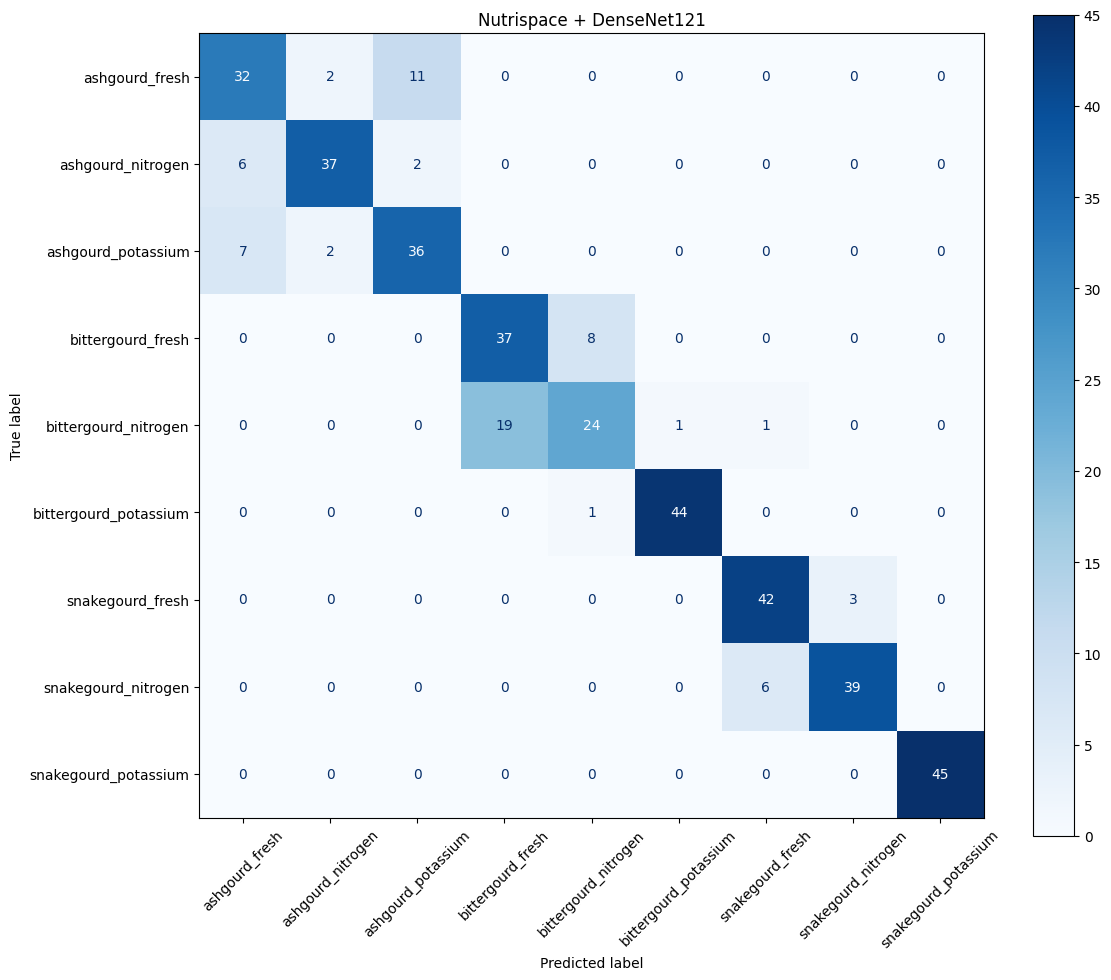

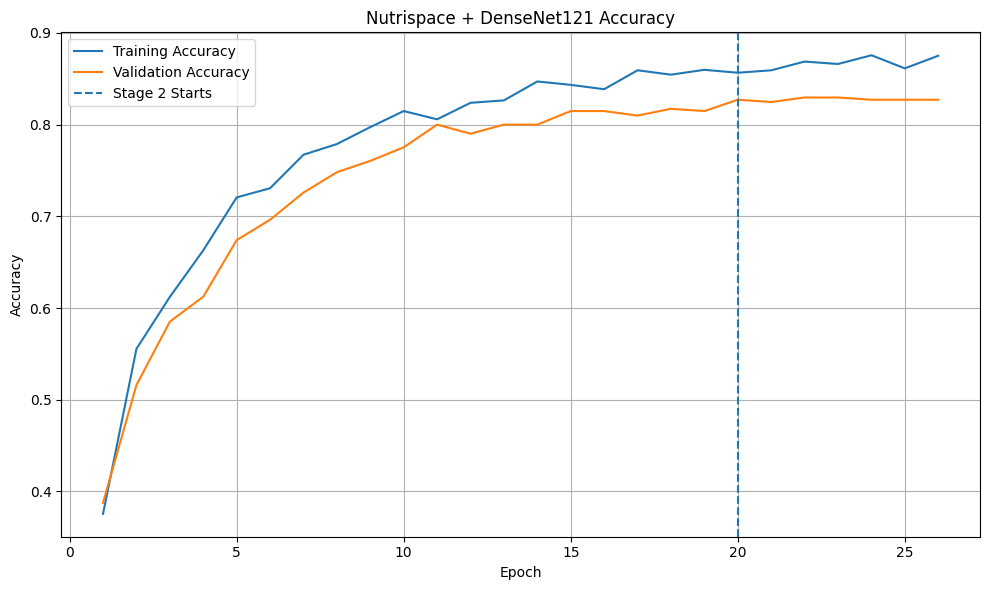

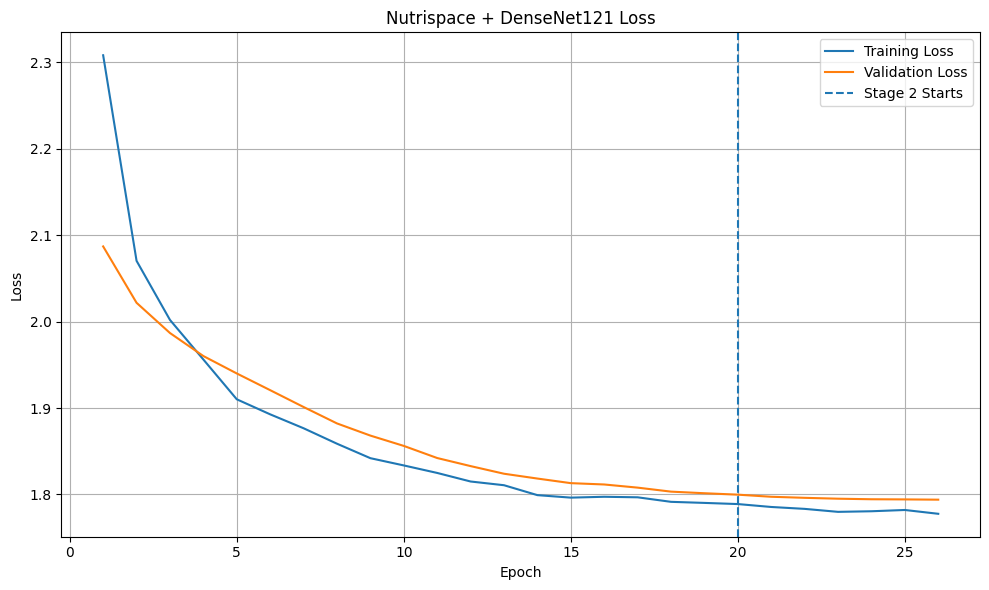



FINAL EXPERIMENT SUMMARY
Model: Nutrispace + DenseNet121
Image size: 312 x 312
Data augmentation: DISABLED
1x1 adapter: REMOVED
Per-image min-max: REMOVED
Global train normalization: ENABLED
DenseNet preprocessing: DISABLED
Stage 1: 20 epochs @ 0.001
Stage 2: 20 epochs @ 1e-05
Fine-tuned layers: 10
Dropout: 0.3
L2: 0.0005
Label smoothing: 0.5
ReduceLROnPlateau factor: 0.3
Test Accuracy: 82.96%
Macro F1: 0.8282
MCC: 0.8092
Best Validation Accuracy: 82.96%
Best Validation Epoch: 22


All results saved to:
/home/mtech_atul/atul/Early_Output-20260923T172757Z-1-001/Early_Output/Nutrispace_DenseNet121_Dropout03_LabelSmooth05


In [ ]:
import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import regularizers
from tensorflow.keras.applications import DenseNet121

from tensorflow.keras.callbacks import (
    ReduceLROnPlateau,
    EarlyStopping,
    ModelCheckpoint,
    CSVLogger
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    matthews_corrcoef
)


SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


print("\n")
print("=" * 75)
print("TENSORFLOW / GPU INFORMATION")
print("=" * 75)

print(
    "TensorFlow version:",
    tf.__version__
)

gpus = tf.config.list_physical_devices("GPU")

if gpus:

    print(
        "GPUs detected:",
        len(gpus)
    )

    for gpu in gpus:

        try:

            tf.config.experimental.set_memory_growth(
                gpu,
                True
            )

        except Exception:

            pass

else:

    print(
        "WARNING: No GPU detected."
    )

print("=" * 75)


TRAIN_DIR = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/Train_256"
)

VAL_DIR = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/Val_resized312"
)

TEST_DIR = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/Test_resized312"
)


OUTPUT_DIR = (
    "/home/mtech_atul/atul/"
    "Early_Output-20260923T172757Z-1-001/"
    "Early_Output/"
    "Nutrispace_DenseNet121_Dropout03_LabelSmooth05"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


IMG_SIZE = (
    312,
    312
)

BATCH_SIZE = 64
NUM_CLASSES = 9


DROPOUT_RATE = 0.30
L2_VALUE = 5e-4


STAGE1_EPOCHS = 20
STAGE2_EPOCHS = 20

TOTAL_EPOCHS = (
    STAGE1_EPOCHS
    +
    STAGE2_EPOCHS
)


STAGE1_LR = 0.001
STAGE2_LR = 0.00001


FINE_TUNE_LAYERS = 10


LR_FACTOR = 0.3
LR_PATIENCE = 2

STAGE1_MIN_LR = 1e-5
STAGE2_MIN_LR = 1e-7


EARLY_STOP_PATIENCE = 4


LABEL_SMOOTHING = 0.50


print("\n")
print("=" * 75)
print("EXPERIMENT CONFIGURATION")
print("=" * 75)

print(
    "Model                    : Nutrispace + DenseNet121"
)

print(
    "Image size               : 312 x 312"
)

print(
    "Data augmentation        : DISABLED"
)

print(
    "1x1 adapter              : DISABLED"
)

print(
    "Per-image min-max        : DISABLED"
)

print(
    "Global train normalization: ENABLED"
)

print(
    "DenseNet preprocessing   : DISABLED"
)

print(
    "Stage 1 LR               :",
    STAGE1_LR
)

print(
    "Stage 1 epochs           :",
    STAGE1_EPOCHS
)

print(
    "Stage 2 LR               :",
    STAGE2_LR
)

print(
    "Stage 2 epochs           :",
    STAGE2_EPOCHS
)

print(
    "Fine-tune layers         :",
    FINE_TUNE_LAYERS
)

print(
    "Label smoothing          :",
    LABEL_SMOOTHING
)

print(
    "Dropout                  :",
    DROPOUT_RATE
)

print(
    "L2                       :",
    L2_VALUE
)

print(
    "Reduce LR factor         :",
    LR_FACTOR
)

print("=" * 75)


print("\n")
print("=" * 75)
print("CHECKING DATASET DIRECTORIES")
print("=" * 75)

for name, path in [
    ("TRAIN", TRAIN_DIR),
    ("VALIDATION", VAL_DIR),
    ("TEST", TEST_DIR)
]:

    print(
        f"\n{name}:"
    )

    print(
        path
    )

    if not os.path.isdir(path):

        raise FileNotFoundError(
            f"\nDirectory does not exist:\n{path}"
        )

    print(
        "OK"
    )


print("\n")
print("=" * 75)
print("LOADING TRAINING DATASET")
print("=" * 75)

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)


class_names = train_ds.class_names

print("\n")
print("=" * 75)
print("CLASS INFORMATION")
print("=" * 75)

print(
    "Number of classes:",
    len(class_names)
)

print(
    "Classes:",
    class_names
)

if len(class_names) != NUM_CLASSES:

    raise ValueError(
        f"Expected {NUM_CLASSES} classes "
        f"but found {len(class_names)}."
    )


print("\n")
print("=" * 75)
print("LOADING VALIDATION DATASET")
print("=" * 75)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


print("\n")
print("=" * 75)
print("LOADING TEST DATASET")
print("=" * 75)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


print("\n")
print("=" * 75)
print("DATASET BATCH INFORMATION")
print("=" * 75)

train_batches = tf.data.experimental.cardinality(
    train_ds
).numpy()

val_batches = tf.data.experimental.cardinality(
    val_ds
).numpy()

test_batches = tf.data.experimental.cardinality(
    test_ds
).numpy()

print(
    "Training batches   :",
    train_batches
)

print(
    "Validation batches :",
    val_batches
)

print(
    "Testing batches    :",
    test_batches
)

print(
    "\nTraining shuffle   : ENABLED"
)

print(
    "Validation shuffle : DISABLED"
)

print(
    "Test shuffle       : DISABLED"
)


AUTOTUNE = tf.data.AUTOTUNE


CAM16 = np.array(
    [
        [
            0.401288,
            0.650173,
            -0.051461
        ],
        [
            -0.250268,
            1.204414,
            0.045854
        ],
        [
            -0.002079,
            0.048952,
            0.953127
        ]
    ],
    dtype=np.float64
)


CAM16_INV = np.linalg.inv(
    CAM16
)


XR = 0.95047
YR = 1.00000
ZR = 1.08883


UR = (
    4.0
    *
    XR
    /
    (
        XR
        +
        15.0 * YR
        +
        3.0 * ZR
    )
)


def nutrispace_f(t):

    t = np.asarray(
        t,
        dtype=np.float64
    )

    return np.where(
        t > 0.008856,
        np.cbrt(t),
        (
            7.787 * t
            +
            (4.0 / 29.0)
        )
    )


def rgb_to_nutrispace_numpy(
    image
):

    image = np.asarray(
        image,
        dtype=np.float64
    )

    image = np.clip(
        image,
        0.0,
        255.0
    )

    rgb = image / 255.0

    original_shape = rgb.shape

    rgb_flat = rgb.reshape(
        -1,
        3
    )

    xyz_flat = (
        CAM16_INV
        @
        rgb_flat.T
    ).T

    xyz = xyz_flat.reshape(
        original_shape
    )

    X = xyz[:, :, 0]
    Y = xyz[:, :, 1]
    Z = xyz[:, :, 2]

    y_ratio = (
        Y
        /
        YR
    )

    L = np.where(
        y_ratio > 0.008856,
        (
            116.0
            *
            np.cbrt(
                np.maximum(
                    y_ratio,
                    0.0
                )
            )
            -
            16.0
        ),
        (
            903.3
            *
            y_ratio
        )
    )

    denominator = (
        X
        +
        15.0 * Y
        +
        3.0 * Z
    )

    denominator = np.where(
        np.abs(
            denominator
        )
        <
        1e-12,
        1e-12,
        denominator
    )

    u = (
        4.0
        *
        X
        /
        denominator
    )

    channel_1 = (
        13.0
        *
        L
        *
        (
            u
            -
            UR
        )
    )

    channel_2 = (
        0.40024
        *
        X
        +
        0.7076
        *
        Y
        -
        0.08081
        *
        Z
    )

    channel_3 = (
        500.0
        *
        (
            nutrispace_f(
                X / XR
            )
            -
            nutrispace_f(
                Y / YR
            )
        )
    )

    nutrispace = np.stack(
        [
            channel_1,
            channel_2,
            channel_3
        ],
        axis=-1
    )

    nutrispace = np.nan_to_num(
        nutrispace,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    return nutrispace.astype(
        np.float32
    )


def convert_batch_rgb_to_nutrispace(
    batch
):

    batch = np.asarray(
        batch
    )

    output = np.empty(
        batch.shape,
        dtype=np.float32
    )

    for i in range(
        batch.shape[0]
    ):

        output[i] = (
            rgb_to_nutrispace_numpy(
                batch[i]
            )
        )

    return output


def rgb_to_nutrispace(
    images
):

    images = tf.cast(
        images,
        tf.float32
    )

    images = tf.clip_by_value(
        images,
        0.0,
        255.0
    )

    result = tf.numpy_function(
        func=convert_batch_rgb_to_nutrispace,
        inp=[images],
        Tout=tf.float32
    )

    result.set_shape(
        images.shape
    )

    return result


print("\n")
print("=" * 75)
print("CONVERTING TRAINING DATA TO NUTRISPACE")
print("=" * 75)

print(
    "Additional augmentation: DISABLED"
)

train_ds_nutrispace_raw = train_ds.map(
    lambda x, y: (
        rgb_to_nutrispace(x),
        y
    ),
    num_parallel_calls=AUTOTUNE
)


print("\n")
print("=" * 75)
print("CONVERTING VALIDATION DATA TO NUTRISPACE")
print("=" * 75)

val_ds_nutrispace_raw = val_ds.map(
    lambda x, y: (
        rgb_to_nutrispace(x),
        y
    ),
    num_parallel_calls=AUTOTUNE
)


print("\n")
print("=" * 75)
print("CONVERTING TEST DATA TO NUTRISPACE")
print("=" * 75)

test_ds_nutrispace_raw = test_ds.map(
    lambda x, y: (
        rgb_to_nutrispace(x),
        y
    ),
    num_parallel_calls=AUTOTUNE
)


print("\n")
print("=" * 75)
print("CALCULATING GLOBAL NUTRISPACE STATISTICS")
print("=" * 75)

print(
    "Using TRAINING DATA ONLY..."
)

sum_channels = np.zeros(
    3,
    dtype=np.float64
)

sum_squared_channels = np.zeros(
    3,
    dtype=np.float64
)

pixel_count = 0

for images, labels in train_ds_nutrispace_raw:

    images_np = images.numpy().astype(
        np.float64
    )

    pixels = images_np.reshape(
        -1,
        3
    )

    sum_channels += np.sum(
        pixels,
        axis=0
    )

    sum_squared_channels += np.sum(
        pixels ** 2,
        axis=0
    )

    pixel_count += pixels.shape[0]


nutrispace_mean = (
    sum_channels
    /
    pixel_count
)


nutrispace_variance = (
    (
        sum_squared_channels
        /
        pixel_count
    )
    -
    (
        nutrispace_mean ** 2
    )
)

nutrispace_variance = np.maximum(
    nutrispace_variance,
    1e-12
)


nutrispace_std = np.sqrt(
    nutrispace_variance
)


print("\n")
print(
    "Training pixels used:",
    pixel_count
)

print(
    "\nGlobal Nutrispace statistics:"
)

print(
    f"Channel 1 Mean: "
    f"{nutrispace_mean[0]:.6f}"
)

print(
    f"Channel 1 Std : "
    f"{nutrispace_std[0]:.6f}"
)

print(
    f"\nChannel 2 Mean: "
    f"{nutrispace_mean[1]:.6f}"
)

print(
    f"Channel 2 Std : "
    f"{nutrispace_std[1]:.6f}"
)

print(
    f"\nChannel 3 Mean: "
    f"{nutrispace_mean[2]:.6f}"
)

print(
    f"Channel 3 Std : "
    f"{nutrispace_std[2]:.6f}"
)


mean_tensor = tf.constant(
    nutrispace_mean,
    dtype=tf.float32
)

std_tensor = tf.constant(
    nutrispace_std,
    dtype=tf.float32
)


def normalize_nutrispace(
    images,
    labels
):

    images = tf.cast(
        images,
        tf.float32
    )

    normalized = (
        images
        -
        mean_tensor
    ) / std_tensor

    return (
        normalized,
        labels
    )


train_ds_nutrispace = (
    train_ds_nutrispace_raw
    .map(
        normalize_nutrispace,
        num_parallel_calls=AUTOTUNE
    )
)


val_ds_nutrispace = (
    val_ds_nutrispace_raw
    .map(
        normalize_nutrispace,
        num_parallel_calls=AUTOTUNE
    )
)


test_ds_nutrispace = (
    test_ds_nutrispace_raw
    .map(
        normalize_nutrispace,
        num_parallel_calls=AUTOTUNE
    )
)


train_ds_nutrispace = (
    train_ds_nutrispace
    .prefetch(AUTOTUNE)
)

val_ds_nutrispace = (
    val_ds_nutrispace
    .prefetch(AUTOTUNE)
)

test_ds_nutrispace = (
    test_ds_nutrispace
    .prefetch(AUTOTUNE)
)


print("\n")
print("=" * 75)
print("NORMALIZED NUTRISPACE SANITY CHECK")
print("=" * 75)

sample_images, sample_labels = next(
    iter(
        train_ds_nutrispace
    )
)

print(
    "Batch shape:",
    sample_images.shape
)

print(
    "Data type:",
    sample_images.dtype
)

for channel in range(3):

    channel_data = (
        sample_images[
            :, :, :, channel
        ]
    )

    print(
        f"\nChannel {channel + 1}:"
    )

    print(
        "Minimum:",
        float(
            tf.reduce_min(
                channel_data
            ).numpy()
        )
    )

    print(
        "Maximum:",
        float(
            tf.reduce_max(
                channel_data
            ).numpy()
        )
    )

    print(
        "Mean:",
        float(
            tf.reduce_mean(
                channel_data
            ).numpy()
        )
    )

    print(
        "Std:",
        float(
            tf.math.reduce_std(
                channel_data
            ).numpy()
        )
    )


@tf.keras.utils.register_keras_serializable(
    package="Nutrispace"
)
class NutrispaceInput(
    layers.Layer
):

    def __init__(
        self,
        **kwargs
    ):

        super().__init__(
            **kwargs
        )

    def call(
        self,
        inputs
    ):

        return tf.cast(
            inputs,
            tf.float32
        )

    def get_config(
        self
    ):

        return super().get_config()


print("\n")
print("=" * 75)
print("CREATING DENSENET121")
print("=" * 75)

base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(
        IMG_SIZE[0],
        IMG_SIZE[1],
        3
    )
)


base_model.trainable = False


inputs = layers.Input(
    shape=(
        IMG_SIZE[0],
        IMG_SIZE[1],
        3
    ),
    name="Nutrispace_Input"
)


x = NutrispaceInput(
    name="Nutrispace_Standardized"
)(inputs)


x = base_model(
    x,
    training=False
)


x = layers.GlobalAveragePooling2D(
    name="GlobalAveragePooling"
)(x)


x = layers.BatchNormalization(
    name="Classification_BatchNorm"
)(x)


x = layers.Dropout(
    DROPOUT_RATE,
    name="Classification_Dropout"
)(x)


outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    kernel_regularizer=regularizers.l2(
        L2_VALUE
    ),
    name="Classification_Output"
)(x)


model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="Nutrispace_DenseNet121_Dropout03_LabelSmooth05"
)


print("\n")
print("=" * 75)
print("MODEL SUMMARY")
print("=" * 75)

model.summary()


loss_function = (
    tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=LABEL_SMOOTHING
    )
)


print("\n")
print("=" * 75)
print("STAGE 1 CONFIGURATION")
print("=" * 75)

print(
    "Backbone       : FROZEN"
)

print(
    "Learning Rate  :",
    STAGE1_LR
)

print(
    "Epochs         :",
    STAGE1_EPOCHS
)

print(
    "Label smoothing:",
    LABEL_SMOOTHING
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=STAGE1_LR
    ),
    loss=loss_function,
    metrics=[
        "accuracy"
    ]
)


stage1_checkpoint = os.path.join(
    OUTPUT_DIR,
    "stage1_best_val_accuracy.keras"
)

stage1_csv = os.path.join(
    OUTPUT_DIR,
    "stage1_training_log.csv"
)


stage1_callbacks = [

    ModelCheckpoint(
        stage1_checkpoint,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=LR_FACTOR,
        patience=LR_PATIENCE,
        min_lr=STAGE1_MIN_LR,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=EARLY_STOP_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    CSVLogger(
        stage1_csv,
        append=False
    )
]


print("\n")
print("=" * 75)
print("STARTING STAGE 1")
print("=" * 75)

print(
    "Epochs:",
    STAGE1_EPOCHS
)

print(
    "Learning Rate:",
    STAGE1_LR
)

print(
    "Backbone:",
    "FROZEN"
)

print(
    "Data augmentation:",
    "DISABLED"
)

print("=" * 75)

history_stage1 = model.fit(
    train_ds_nutrispace,
    validation_data=val_ds_nutrispace,
    epochs=STAGE1_EPOCHS,
    callbacks=stage1_callbacks,
    verbose=1
)


if os.path.exists(
    stage1_checkpoint
):

    print("\n")

    print(
        "Loading best Stage 1 model..."
    )

    model = tf.keras.models.load_model(
        stage1_checkpoint,
        custom_objects={
            "NutrispaceInput":
            NutrispaceInput
        },
        compile=False
    )


base_model = None

for layer in model.layers:

    if isinstance(
        layer,
        tf.keras.Model
    ):

        if (
            "densenet121"
            in layer.name.lower()
        ):

            base_model = layer

            break


if base_model is None:

    raise ValueError(
        "Could not find DenseNet121 "
        "backbone inside the model."
    )


print("\n")
print("=" * 75)
print("PREPARING STAGE 2")
print("=" * 75)

base_model.trainable = True


for layer in base_model.layers:

    layer.trainable = False


for layer in base_model.layers[
    -FINE_TUNE_LAYERS:
]:

    if isinstance(
        layer,
        layers.BatchNormalization
    ):

        layer.trainable = False

    else:

        layer.trainable = True


print("\n")
print("=" * 75)
print("TRAINABLE DENSENET121 LAYERS")
print("=" * 75)

trainable_count = 0

for layer in base_model.layers:

    if layer.trainable:

        print(
            "TRAINABLE:",
            layer.name
        )

        trainable_count += 1

print("\n")

print(
    "Trainable backbone layers:",
    trainable_count
)


print("\n")
print("=" * 75)
print("STAGE 2 CONFIGURATION")
print("=" * 75)

print(
    "Fine-tuning layers:",
    FINE_TUNE_LAYERS
)

print(
    "Learning Rate:",
    STAGE2_LR
)

print(
    "Epochs:",
    STAGE2_EPOCHS
)

print(
    "BatchNorm:",
    "FROZEN"
)

print("=" * 75)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=STAGE2_LR
    ),
    loss=loss_function,
    metrics=[
        "accuracy"
    ]
)


stage2_checkpoint = os.path.join(
    OUTPUT_DIR,
    "stage2_best_val_accuracy.keras"
)

stage2_csv = os.path.join(
    OUTPUT_DIR,
    "stage2_training_log.csv"
)


stage2_callbacks = [

    ModelCheckpoint(
        stage2_checkpoint,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=LR_FACTOR,
        patience=LR_PATIENCE,
        min_lr=STAGE2_MIN_LR,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=EARLY_STOP_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    CSVLogger(
        stage2_csv,
        append=False
    )
]


print("\n")
print("=" * 75)
print("STARTING STAGE 2")
print("=" * 75)

stage1_epochs_ran = len(
    history_stage1.history.get(
        "accuracy",
        []
    )
)

stage2_total_epochs = (
    stage1_epochs_ran
    +
    STAGE2_EPOCHS
)

print(
    "Stage 2 starts from Epoch:",
    stage1_epochs_ran + 1
)

print(
    "Final Epoch:",
    stage2_total_epochs
)

print(
    "Learning Rate:",
    STAGE2_LR
)

print(
    "Fine-tuned Layers:",
    FINE_TUNE_LAYERS
)

print("=" * 75)

history_stage2 = model.fit(
    train_ds_nutrispace,
    validation_data=val_ds_nutrispace,
    initial_epoch=stage1_epochs_ran,
    epochs=stage2_total_epochs,
    callbacks=stage2_callbacks,
    verbose=1
)


if os.path.exists(
    stage2_checkpoint
):

    print("\n")

    print(
        "Loading best Stage 2 model..."
    )

    model = tf.keras.models.load_model(
        stage2_checkpoint,
        custom_objects={
            "NutrispaceInput":
            NutrispaceInput
        },
        compile=False
    )


final_model_path = os.path.join(
    OUTPUT_DIR,
    "Nutrispace_DenseNet121_Dropout03_LabelSmooth05_FINAL.keras"
)

model.save(
    final_model_path
)

print("\n")
print("=" * 75)
print("FINAL MODEL SAVED")
print("=" * 75)

print(
    final_model_path
)


model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=STAGE2_LR
    ),
    loss=loss_function,
    metrics=[
        "accuracy"
    ]
)


print("\n")
print("=" * 75)
print("TEST EVALUATION")
print("=" * 75)

test_loss, test_accuracy = model.evaluate(
    test_ds_nutrispace,
    verbose=1
)

print("\n")
print("=" * 75)
print("TEST RESULTS")
print("=" * 75)

print(
    f"Test Loss     : {test_loss:.4f}"
)

print(
    f"Test Accuracy : {test_accuracy:.4f}"
)

print(
    f"Test Accuracy : "
    f"{test_accuracy * 100:.2f}%"
)


print("\n")
print("=" * 75)
print("GENERATING TEST PREDICTIONS")
print("=" * 75)

y_true = []
y_pred = []

for images, labels in test_ds_nutrispace:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    true_classes = np.argmax(
        labels.numpy(),
        axis=1
    )

    y_pred.extend(
        predicted_classes
    )

    y_true.extend(
        true_classes
    )


y_true = np.array(
    y_true
)

y_pred = np.array(
    y_pred
)


print("\n")
print("=" * 75)
print("CLASSIFICATION REPORT")
print("=" * 75)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(
    report
)

report_path = os.path.join(
    OUTPUT_DIR,
    "classification_report.txt"
)

with open(
    report_path,
    "w"
) as f:

    f.write(
        report
    )


macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

print(
    "\nMacro F1:",
    f"{macro_f1:.4f}"
)


mcc = matthews_corrcoef(
    y_true,
    y_pred
)

print(
    "MCC:",
    f"{mcc:.4f}"
)


cm = confusion_matrix(
    y_true,
    y_pred
)

print("\n")
print("=" * 75)
print("CONFUSION MATRIX")
print("=" * 75)

print(
    cm
)

plt.figure(
    figsize=(12, 10)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=45,
    cmap="Blues",
    ax=plt.gca(),
    colorbar=True
)

plt.title(
    "Nutrispace + DenseNet121"
)

plt.tight_layout()

cm_path = os.path.join(
    OUTPUT_DIR,
    "confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


stage1_accuracy = (
    history_stage1
    .history
    .get(
        "accuracy",
        []
    )
)

stage1_val_accuracy = (
    history_stage1
    .history
    .get(
        "val_accuracy",
        []
    )
)

stage1_loss = (
    history_stage1
    .history
    .get(
        "loss",
        []
    )
)

stage1_val_loss = (
    history_stage1
    .history
    .get(
        "val_loss",
        []
    )
)

stage2_accuracy = (
    history_stage2
    .history
    .get(
        "accuracy",
        []
    )
)

stage2_val_accuracy = (
    history_stage2
    .history
    .get(
        "val_accuracy",
        []
    )
)

stage2_loss = (
    history_stage2
    .history
    .get(
        "loss",
        []
    )
)

stage2_val_loss = (
    history_stage2
    .history
    .get(
        "val_loss",
        []
    )
)

all_accuracy = (
    stage1_accuracy
    +
    stage2_accuracy
)

all_val_accuracy = (
    stage1_val_accuracy
    +
    stage2_val_accuracy
)

all_loss = (
    stage1_loss
    +
    stage2_loss
)

all_val_loss = (
    stage1_val_loss
    +
    stage2_val_loss
)

epochs = range(
    1,
    len(all_accuracy)
    +
    1
)


best_val_accuracy = max(
    all_val_accuracy
)

best_val_epoch = (
    np.argmax(
        all_val_accuracy
    )
    +
    1
)


plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs,
    all_accuracy,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    all_val_accuracy,
    label="Validation Accuracy"
)

plt.axvline(
    x=stage1_epochs_ran,
    linestyle="--",
    label="Stage 2 Starts"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Nutrispace + DenseNet121 Accuracy"
)

plt.legend()

plt.grid(
    True
)

plt.tight_layout()

accuracy_path = os.path.join(
    OUTPUT_DIR,
    "accuracy_curve.png"
)

plt.savefig(
    accuracy_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs,
    all_loss,
    label="Training Loss"
)

plt.plot(
    epochs,
    all_val_loss,
    label="Validation Loss"
)

plt.axvline(
    x=stage1_epochs_ran,
    linestyle="--",
    label="Stage 2 Starts"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Nutrispace + DenseNet121 Loss"
)

plt.legend()

plt.grid(
    True
)

plt.tight_layout()

loss_path = os.path.join(
    OUTPUT_DIR,
    "loss_curve.png"
)

plt.savefig(
    loss_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


results_path = os.path.join(
    OUTPUT_DIR,
    "final_results.txt"
)

with open(
    results_path,
    "w"
) as f:

    f.write(
        "Nutrispace + DenseNet121\n"
    )

    f.write(
        "========================================\n"
    )

    f.write(
        f"Image Size: {IMG_SIZE}\n"
    )

    f.write(
        "Data Augmentation: DISABLED\n"
    )

    f.write(
        "1x1 Adapter: DISABLED\n"
    )

    f.write(
        "Per-image Min-Max: DISABLED\n"
    )

    f.write(
        "Global Training Normalization: ENABLED\n"
    )

    f.write(
        "DenseNet preprocessing: DISABLED\n"
    )

    f.write(
        f"Dropout: {DROPOUT_RATE}\n"
    )

    f.write(
        f"L2: {L2_VALUE}\n"
    )

    f.write(
        f"Stage 1 LR: {STAGE1_LR}\n"
    )

    f.write(
        f"Stage 1 Epochs: {STAGE1_EPOCHS}\n"
    )

    f.write(
        f"Stage 2 LR: {STAGE2_LR}\n"
    )

    f.write(
        f"Stage 2 Epochs: {STAGE2_EPOCHS}\n"
    )

    f.write(
        f"Fine Tune Layers: {FINE_TUNE_LAYERS}\n"
    )

    f.write(
        f"Label Smoothing: {LABEL_SMOOTHING}\n"
    )

    f.write(
        f"Reduce LR Factor: {LR_FACTOR}\n"
    )

    f.write(
        f"Test Accuracy: "
        f"{test_accuracy * 100:.2f}%\n"
    )

    f.write(
        f"Macro F1: "
        f"{macro_f1:.4f}\n"
    )

    f.write(
        f"MCC: "
        f"{mcc:.4f}\n"
    )

    f.write(
        f"Best Validation Accuracy: "
        f"{best_val_accuracy * 100:.2f}%\n"
    )

    f.write(
        f"Best Validation Epoch: "
        f"{best_val_epoch}\n"
    )


print("\n")
print("=" * 75)
print("FINAL EXPERIMENT SUMMARY")
print("=" * 75)

print(
    "Model:",
    "Nutrispace + DenseNet121"
)

print(
    "Image size:",
    "312 x 312"
)

print(
    "Data augmentation:",
    "DISABLED"
)

print(
    "1x1 adapter:",
    "REMOVED"
)

print(
    "Per-image min-max:",
    "REMOVED"
)

print(
    "Global train normalization:",
    "ENABLED"
)

print(
    "DenseNet preprocessing:",
    "DISABLED"
)

print(
    "Stage 1:",
    f"{STAGE1_EPOCHS} epochs @ {STAGE1_LR}"
)

print(
    "Stage 2:",
    f"{STAGE2_EPOCHS} epochs @ {STAGE2_LR}"
)

print(
    "Fine-tuned layers:",
    FINE_TUNE_LAYERS
)

print(
    "Dropout:",
    DROPOUT_RATE
)

print(
    "L2:",
    L2_VALUE
)

print(
    "Label smoothing:",
    LABEL_SMOOTHING
)

print(
    "ReduceLROnPlateau factor:",
    LR_FACTOR
)

print(
    "Test Accuracy:",
    f"{test_accuracy * 100:.2f}%"
)

print(
    "Macro F1:",
    f"{macro_f1:.4f}"
)

print(
    "MCC:",
    f"{mcc:.4f}"
)

print(
    "Best Validation Accuracy:",
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    "Best Validation Epoch:",
    best_val_epoch
)

print("=" * 75)

print("\n")

print(
    "All results saved to:"
)

print(
    OUTPUT_DIR
)

print("=" * 75)